In [3]:
import pandas as pd
import os

current_dir = os.path.abspath('.')
root_dir = os.path.dirname(current_dir) 
file_path = os.path.join(root_dir, 'data', 'creditcard_pret_ingestion.csv')
    
# Charger le CSV dans un DataFrame
df = pd.read_csv(file_path)
df_initial = df.copy()


In [4]:
df = df.set_index('ID')
print(df.columns.tolist())
initial_col=df.columns.tolist()

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']


In [5]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
THRESHOLD = 1_000_000
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# 1. FILTRAGE DES LIGNES
mask_large_payment = df[payment_columns].ge(THRESHOLD).any(axis=1)
df_large_payments = df[mask_large_payment].copy()

print(f"--- RÉSULTATS ---")
print(f"Nombre total de lignes avec au moins un paiement >= {THRESHOLD:,} : {len(df_large_payments)}")

if len(df_large_payments) == 0:
    print("Aucune ligne trouvée. Vérifie l'échelle de tes données.")
else:
    # 2. AFFICHAGE CLASSIQUE (sans .T)
    print(f"\n--- Exemple de 10 lignes (format classique) ---")
    
    # On peut limiter le nombre de colonnes affichées si le dataframe est très large
    # Sinon, pandas l'affichera tel quel
    print(df_large_payments.head(10))


--- RÉSULTATS ---
Nombre total de lignes avec au moins un paiement >= 1,000,000 : 4

--- Exemple de 10 lignes (format classique) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
ID                                                                            
5297      500000    2          1         1   33     -2     -2     -1     -1   
25732      80000    2          3         1   37      0      0     -2     -2   
28004     510000    2          1         2   30     -1     -1     -1     -1   
28717     340000    2          1         3   42     -1     -1     -1     -1   

       PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
ID            ...                                                        
5297      -2  ...     121757      97115     377217      4366   1684259   
25732     -2  ...        632        632     124542       215   1024516   
28004      0  ...     163628     117475     116656    493358   1227082   
28717     -1  ...     

Les paiements de +1M semblent incohérents avec leur contexte, les cartes voient leur plafond exploser.  
Même si ces 4 lignes seront un bruit imperceptibles pour les modèles, les répartitions et stats sont complètement déformées par ces anomalies.  
En terme de métier, il n'est pas impossible de dépasser le plafond maximum d'une carte de crédit d'un certain pourcentage, mais ici, on parle de plusieurs fois le plafond autorisé

In [7]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
THRESHOLD = 500000
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# 1. FILTRAGE DES LIGNES
mask_large_payment = df[payment_columns].ge(THRESHOLD).any(axis=1)
df_large_payments = df[mask_large_payment].copy()

print(f"--- RÉSULTATS ---")
print(f"Nombre total de lignes avec au moins un paiement >= {THRESHOLD:,} : {len(df_large_payments)}")

if len(df_large_payments) == 0:
    print("Aucune ligne trouvée. Vérifie l'échelle de tes données.")
else:
    # 2. AFFICHAGE CLASSIQUE (sans .T)
    print(f"\n--- Exemple de 10 lignes (format classique) ---")
    
    # On peut limiter le nombre de colonnes affichées si le dataframe est très large
    # Sinon, pandas l'affichera tel quel
    print(df_large_payments.head(10))


--- RÉSULTATS ---
Nombre total de lignes avec au moins un paiement >= 500,000 : 11

--- Exemple de 10 lignes (format classique) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
ID                                                                            
507       500000    2          2         2   43     -1     -1     -1      0   
2198     1000000    2          1         1   47      0      0      0     -1   
5297      500000    2          1         1   33     -2     -2     -1     -1   
12331     300000    1          2         1   37      1     -1      2      0   
14512     500000    1          1         2   30     -1     -1     -1      0   
14514     460000    2          1         1   43     -2     -2     -1      0   
24687     730000    1          2         1   37      0      0      0      0   
25732      80000    2          3         1   37      0      0     -2     -2   
27441     500000    1          1         1   35      2      0      0     -1   

Pour les paiements à +500 000 NT$, le constat est plus mitigé pour les lignes entre 500 00 et 1 000 000
**=> les montants de +1M nT$ ressemblent fortement à des anomalies, je supprime ces 4 lignes

In [8]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes à filtrer
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
# Filtrer pour ne garder que celles qui existent dans le dataframe
cols_presentes = [c for c in cols_pay if c in df.columns]

if len(cols_presentes) > 0:
    # Seuil de suppression
    seuil_suppression = 1_000_000
    
    # 2. Identification des lignes à supprimer
    # On crée un masque qui est True si AU MOINS une colonne PAY_AMT dépasse le seuil
    is_outlier = False
    for col in cols_presentes:
        is_outlier = is_outlier | (df[col] > seuil_suppression)
        
    nb_lignes_avant = len(df)
    
    # 3. Suppression
    df_cleaned = df[~is_outlier].copy()
    nb_lignes_apres = len(df_cleaned)
    nb_supprimees = nb_lignes_avant - nb_lignes_apres
    
    print(f"--- Nettoyage des Paiements Anormaux (> 1M) ---")
    print(f"Lignes avant : {nb_lignes_avant}")
    print(f"Lignes supprimées : {nb_supprimees} ({(nb_supprimees/nb_lignes_avant)*100:.2f}%)")
    print(f"Lignes restantes : {nb_lignes_apres}")

    # Affichage des colonnes concernées pour vérifier qu'elles ont bien été nettoyées
    print("\nValeurs max par colonne PAY_AMT après nettoyage :")
    for col in cols_presentes:
        if col in df_cleaned.columns:
            print(f"{col}: {df_cleaned[col].max()}")

else:
    print("Aucune colonne PAY_AMT trouvée.")

df = df_cleaned

--- Nettoyage des Paiements Anormaux (> 1M) ---
Lignes avant : 30000
Lignes supprimées : 4 (0.01%)
Lignes restantes : 29996

Valeurs max par colonne PAY_AMT après nettoyage :
PAY_AMT1: 505000
PAY_AMT2: 580464
PAY_AMT3: 896040
PAY_AMT4: 528897
PAY_AMT5: 426529
PAY_AMT6: 528666


In [9]:
import pandas as pd

# 1. Définir les colonnes de montants payés
cols_paiements = [f'PAY_AMT{i}' for i in range(1, 7)]

# 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 2.1

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 2.1 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())
    
    # 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 1.2

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 1.2 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())
    
    # 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 5

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 5 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())

Nombre de lignes potentiellement incohérentes pour une limite à 2.1 x le plafond: 12


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,
3554,40000,32228,38904,4235,87230,72647,65070,8040,4235,87230,3000,10000,4317,0
5844,10000,885,1475,780,390,780,390,1475,780,0,31250,0,0,0
7419,20000,-1213,30322,20033,19871,15410,18969,52082,15800,2000,20085,39070,25000,0
7640,20000,-739,-5978,16089,14457,20106,10258,0,42400,289,201,410,0,1
7667,20000,34213,30100,25871,21970,18669,19669,0,0,0,0,1000,53301,1


Nombre de lignes potentiellement incohérentes pour une limite à 1.2 x le plafond: 78


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,
291,280000,898,898,325,898,325,-339603,898,325,898,325,0,345293,1
991,50000,58300,59727,142,29886,30510,31276,7876,161,74354,927,1089,9100,0
1740,20000,15789,21698,21054,20355,19980,3470,6500,0,0,10000,25065,177,0
1844,20000,18803,18376,19342,19081,19799,18718,36147,1281,658,1000,1000,760,1
3184,260000,200716,203751,205530,-170000,171696,174151,8812,9158,0,497000,10000,7000,0


Nombre de lignes potentiellement incohérentes pour une limite à 5 x le plafond: 0


In [10]:
import pandas as pd

# 1. Définition des colonnes concernées
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
col_plafond = 'LIMIT_BAL'

# Filtrer pour ne garder que les colonnes présentes dans le dataframe
cols_presentes = [c for c in cols_bill if c in df.columns]

if col_plafond not in df.columns:
    print(f"Attention : La colonne '{col_plafond}' est manquante.")
elif len(cols_presentes) == 0:
    print(f"Attention : Aucune colonne BILL_AMT trouvée.")
else:
    # 2. Calcul du seuil par ligne (2.1 * LIMIT_BAL)
    # On filtre d'abord les plafonds valides (> 0) pour éviter les divisions/errements logiques
    df_valide = df[df[col_plafond] > 0].copy()
    
    if len(df_valide) == 0:
        print("Aucune limite de crédit valide trouvée.")
    else:
        # On identifie les lignes où AU MOINS UN des BILL_AMT dépasse le seuil
        is_outlier = False
        for col in cols_presentes:
            # Condition : Valeur > 2.1 * LIMIT_BAL
            is_outlier = is_outlier | (df_valide[col] > (2.1 * df_valide[col_plafond]))
        
        # On ajoute la colonne 'Is_Outlier' au dataframe pour analyse détaillée si besoin
        df_valide['Depasse_Plafond_X2.1'] = is_outlier
        
        # 3. Comptage
        nb_lignes_totales = len(df)
        nb_depassements = is_outlier.sum()
        
        print(f"--- Analyse de Dépassement de Plafond ---")
        print(f"Total lignes dans le dataset : {nb_lignes_totales}")
        print(f"Lignes avec AU MOINS un BILL_AMT > 2.1 * LIMIT_BAL : {nb_depassements}")
        
        if nb_lignes_totales > 0:
            pourcentage = (nb_depassements / nb_lignes_totales) * 100
            print(f"Pourcentage de la population concernée : {pourcentage:.2f}%")

    # Optionnel : Afficher un échantillon des cas extrêmes pour vérifier leur nature
    if nb_depassements > 0:
        df_extremes = df_valide[(df_valide['Depasse_Plafond_X2.1'])].head(10)
        print("\nExemple de lignes dépassant le seuil (10 premiers cas) :")
        print(df_extremes.to_string())

--- Analyse de Dépassement de Plafond ---
Total lignes dans le dataset : 29996
Lignes avec AU MOINS un BILL_AMT > 2.1 * LIMIT_BAL : 40
Pourcentage de la population concernée : 0.13%

Exemple de lignes dépassant le seuil (10 premiers cas) :
      LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  Depasse_Plafond_X2.1
ID                                                                                                                                                                                                                                                
671       30000    2          2         2   34      2     -1      2      2      2      2      99568      32326      31840      37075      37662      36904     33000     33000      5810      1325         0      3095     0                  True
969       20000    2          2

Dans le domaine des crédits renouvelables, il est rare de dépasser son plafond de plus de 100% mais c'est possible. Ce qui est compliqué, c'est de dépasser 120% du plafond.  Les valeurs supérieures à cette limite sont probablement erronnées.  
Cependant dans ce dataset, on voit des clients payer en avance, des décalages de comptabilisation dans les paiements, des clients qui remboursent intégralement leur carte chaque mois ; alors la limite de 120% (dépassée pour 78 clients) devient sévère.  
Fixer une limite raisonnable à 2 fois la limite en ajoutant une petite marge sécurise sur le nettoyage et garantit de vraiment éliminer les lignes contenant des erreurs de type (montant compté x 100, montants saisis plusieurs fois par erreur).  La seule explication à ceci serait un abaissement du plafond sur la période mais il est impossible d'avoir la moindre information sur la temporalité de ce montant maximum autorisé.  
L'analyse des lignes ne montre pas d'aberrations dans les montants
Si j'applique le même filtre sur les encours et que j'observe un échantillon de quelques lignes, je ne détecte pas d'anormalité de comportement dans les paiements et les encours utilisés, on remarque en effet une envolée de l'encours mais rien n'indique une erreur de montant. Supprimer ces lignes de fort dépassement du plafong supprimerait une catégorie de clients non justifiée ici.  
La raison la plus probable ici semble être une baisse du plafond autorisé.  
=> **je ne nettoie pas ces lignes qui ne présentent pas suffisamment d'anomalies**

In [11]:
# Créer la liste des colonnes à analyser
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== ANALYSE DES RETARDS DE PAIEMENT ===")

# Analyser chaque colonne de paiement
results = {}
total_records = len(df)

for col in pay_columns:
    # Compter les valeurs strictement inférieures à -1
    count_less_than_neg1 = (df[col] < -1).sum()
    percentage_less_than_neg1 = (count_less_than_neg1 / total_records) * 100
    
    # Compter les valeurs égales à 0
    count_zeros = (df[col] == 0).sum()
    percentage_zeros = (count_zeros / total_records) * 100
    
    # Statistiques générales
    min_val = df[col].min()
    max_val = df[col].max()
    mean_val = df[col].mean()
    
    results[col] = {
        'count_less_than_neg1': count_less_than_neg1,
        'percentage_less_than_neg1': percentage_less_than_neg1,
        'count_zeros': count_zeros,
        'percentage_zeros': percentage_zeros,
        'min': min_val,
        'max': max_val,
        'mean': mean_val
    }
    
    print(f"\n{col}:")
    print(f"  - Nombre de valeurs < -1: {count_less_than_neg1}")
    print(f"  - Pourcentage < -1: {percentage_less_than_neg1:.2f}%")
    print(f"  - Nombre de valeurs = 0: {count_zeros}")
    print(f"  - Pourcentage = 0: {percentage_zeros:.2f}%")
    print(f"  - Valeur minimale: {min_val}")
    print(f"  - Valeur maximale: {max_val}")
    print(f"  - Moyenne: {mean_val:.2f}")
    
    # Afficher quelques exemples de valeurs < -1
    if count_less_than_neg1 > 0:
        negative_values = df[df[col] < -1][col].head()
        print(f"  - Exemples (< -1): {negative_values.tolist()}")

print("\n=== ANALYSE SPÉCIFIQUE ===")
print("Nombre de valeurs strictement inférieures à -1 dans chaque colonne :")

total_negative = 0
total_zeros = 0

for col in pay_columns:
    count_negative = (df[col] < -1).sum()
    count_zero = (df[col] == 0).sum()
    
    total_negative += count_negative
    total_zeros += count_zero
    
    print(f"  {col}: {count_negative} valeurs < -1, {count_zero} valeurs = 0")

print(f"\nTotal de toutes les valeurs < -1: {total_negative}")
print(f"Total de toutes les valeurs = 0: {total_zeros}")
    

=== ANALYSE DES RETARDS DE PAIEMENT ===

PAY_1:
  - Nombre de valeurs < -1: 2758
  - Pourcentage < -1: 9.19%
  - Nombre de valeurs = 0: 14736
  - Pourcentage = 0: 49.13%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.02
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_2:
  - Nombre de valeurs < -1: 3781
  - Pourcentage < -1: 12.61%
  - Nombre de valeurs = 0: 15729
  - Pourcentage = 0: 52.44%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.13
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_3:
  - Nombre de valeurs < -1: 4084
  - Pourcentage < -1: 13.62%
  - Nombre de valeurs = 0: 15764
  - Pourcentage = 0: 52.55%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.17
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_4:
  - Nombre de valeurs < -1: 4347
  - Pourcentage < -1: 14.49%
  - Nombre de valeurs = 0: 16455
  - Pourcentage = 0: 54.86%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.22
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_

In [12]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg2 = df[pay_columns].eq(-2).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -2 : {count_all_neg2}")

Nombre de lignes contenant uniquement des -2 : 2109


In [13]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_neg2 = df[pay_columns].eq(-2).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -2 : {count_at_least_one_neg2}")

Nombre de lignes contenant au moins un -2 : 6559


In [14]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg1 = df[pay_columns].eq(-1).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -1 : {count_all_neg1}")

Nombre de lignes contenant uniquement des -1 : 1992


In [15]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -1
count_at_least_one_neg1 = df[pay_columns].eq(-1).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -1 : {count_at_least_one_neg1}")

Nombre de lignes contenant au moins un -1 : 10224


In [16]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_0 = df[pay_columns].eq(0).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des 0 : {count_all_0}")

Nombre de lignes contenant uniquement des 0 : 9821


In [17]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_0 = df[pay_columns].eq(0).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un 0 : {count_at_least_one_0}")

Nombre de lignes contenant au moins un 0 : 21170


### approche de compréhention  
Je cherche à comprendre à quoi correspondent les valeurs '-2', '-1' et '0' des colonnes 'PAY_n'.  
Ces 3 valeurs signifient-elles la même chose ? Représentent-elles des retards mal saisis ?  
Selon la documentation du dataset, '-1' signifie client à jour et des entiers positifs représentent le nombre de mois de retard de paiement  
Je regarde pour ces 3 valeurs à quoi cela peut correspondre en terme de paiements et d'encours

In [18]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES VALEURS DE PAIEMENT ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n")

# Pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {bill_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne BILL_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== ANALYSE DES VALEURS DE PAIEMENT (PAY_AMT) ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de PAY_AMT_n")

# Pour chaque paire de colonnes PAY_AMT
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {pay_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne PAY_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== STATISTIQUES GÉNÉRALES ===")
# Afficher les statistiques générales pour chaque colonne
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n{pay_col} :")
    print(f"  - Moyenne de {bill_amt_col} : {df[bill_amt_col].mean():.2f}")
    print(f"  - Écart-type de {bill_amt_col} : {df[bill_amt_col].std():.2f}")
    print(f"  - Nombre total de valeurs : {len(df)}")

=== ANALYSE DES VALEURS DE PAIEMENT ===
Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n

--- PAY_1 vs BILL_AMT2 ---
  Moyenne de BILL_AMT2 quand PAY_1 = 0 : 74243.24
  Moyenne de BILL_AMT2 quand PAY_1 = -1 : 10926.87
  Moyenne de BILL_AMT2 quand PAY_1 = -2 : 8620.00
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT2 pour PAY_1 = 0 : [14027, 48233, 57069]
    Valeurs BILL_AMT2 pour PAY_1 = -1 : [1725, 5670, 21670]
    Valeurs BILL_AMT2 pour PAY_1 = -2 : [0, 19420, 4152]

--- PAY_2 vs BILL_AMT3 ---
  Moyenne de BILL_AMT3 quand PAY_2 = 0 : 69475.20
  Moyenne de BILL_AMT3 quand PAY_2 = -1 : 11464.68
  Moyenne de BILL_AMT3 quand PAY_2 = -2 : 6187.23
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT3 pour PAY_2 = 0 : [13559, 49291, 35835]
    Valeurs BILL_AMT3 pour PAY_2 = -1 : [601, 9966, 316]
    Valeurs BILL_AMT3 pour PAY_2 = -2 : [0, 0, 0]

--- PAY_3 vs BILL_AMT4 ---
  Moyenne de BILL_AMT4 quand PAY_3 = 0 : 64280.66
  Moyenn

Tendances à ce que les montants payés baissent quand PAY_n = -2  
C'est plus marquant sur l'encours, il diminue drastiquement en moyenne à mesure que PAY_n est négatif  
Je regarde la proportion de 0 ou négatifs dans les encours et les paiements

In [19]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===")
print("Proportion de valeurs égales à 0 dans PAY_AMT et BILL_AMT pour chaque valeur de PAY_n")

# Analyse pour chaque colonne PAY_n
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    total_records = len(df)
    
    print(f"\n--- {pay_col} ---")
    
    # Pour chaque valeur de PAY_n, calculer la proportion de 0 dans PAY_AMT
    print(f"Proportion de 0 dans {pay_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Même analyse pour BILL_AMT
    print(f"Proportion de <=0 dans {bill_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")

print("\n=== ANALYSE COMPARATIVE ===")
print("Résumé des proportions de 0 pour chaque situation")

# Résumé par situation
situations = ['0', '-1', '-2']
for situation in situations:
    print(f"\n--- Situation {situation} ---")
    
    for i in range(len(pay_columns)):
        pay_col = pay_columns[i]
        pay_amt_col = pay_amt_columns[i]
        bill_amt_col = bill_amt_columns[i]
        
        if situation == '0':
            condition = df[pay_col] == 0
        elif situation == '-1':
            condition = df[pay_col] == -1
        else:  # situation == '-2'
            condition = df[pay_col] == -2
        
        total_with_situation = condition.sum()
        
        if total_with_situation > 0:
            # Pour PAY_AMT
            zeros_in_pay_amt = (condition & (df[pay_amt_col] == 0)).sum()
            percentage_pay_amt = (zeros_in_pay_amt / total_with_situation) * 100
            
            # Pour BILL_AMT
            zeros_in_bill_amt = (condition & (df[bill_amt_col] == 0)).sum()
            percentage_bill_amt = (zeros_in_bill_amt / total_with_situation) * 100
            
            print(f"  {pay_col}: PAY_AMT={percentage_pay_amt:.2f}%, BILL_AMT={percentage_bill_amt:.2f}%")

=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===
Proportion de valeurs égales à 0 dans PAY_AMT et BILL_AMT pour chaque valeur de PAY_n

--- PAY_1 ---
Proportion de 0 dans PAY_AMT1 :
  Quand PAY_1 = 0 : 261 sur 14736 (1.77%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -1 : 1022 sur 5684 (17.98%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -2 : 912 sur 2758 (33.07%) de valeurs nulles dans PAY_AMT1
Proportion de <=0 dans BILL_AMT2 :
  Quand PAY_1 = 0 : 281 sur 14736 (1.91%) de valeurs <=0 dans BILL_AMT2
  Quand PAY_1 = -1 : 703 sur 5684 (12.37%) de valeurs <=0 dans BILL_AMT2
  Quand PAY_1 = -2 : 951 sur 2758 (34.48%) de valeurs <=0 dans BILL_AMT2

--- PAY_2 ---
Proportion de 0 dans PAY_AMT2 :
  Quand PAY_2 = 0 : 1000 sur 15729 (6.36%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -1 : 1195 sur 6048 (19.76%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -2 : 1822 sur 3781 (48.19%) de valeurs nulles dans PAY_AMT2
Proportion de <=0 dans BILL_AMT3 :
  Quand PAY_2 = 0 : 542 sur 15

La proportion d'encours non utilisé augmente fortement à mesure que PAY_n est négatif  
Regardons à l'inverse : quelles valeurs de PAY_n quand PAY_AMT = 0 ou BIL_AMT <=0

In [20]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn <= 0 ou PAY_AMTn-1 = 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} <= 0 :")
    mask_bill_zero = df[bill_amt_col] <= 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} <= 0")
    
    # Analyse quand PAY_AMT_n-1 = 0
    print(f"Répartition de {pay_col} quand {pay_amt_col} = 0 :")
    mask_pay_zero = df[pay_amt_col] == 0
    count_with_pay_zero = mask_pay_zero.sum()
    
    if count_with_pay_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_pay_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_pay_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_pay_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {pay_amt_col} = 0")
       


=== ANALYSE DES TRANSITIONS INVERSES ===
Répartition des valeurs de PAY_n-1 quand BILL_AMTn <= 0 ou PAY_AMTn-1 = 0

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 <= 0 :
  - PAY_1 = -2 : 951 sur 3173 (29.97%)
  - PAY_1 = -1 : 703 sur 3173 (22.16%)
  - PAY_1 = 0 : 281 sur 3173 (8.86%)
  - PAY_1 = 1 : 1175 sur 3173 (37.03%)
  - PAY_1 = 2 : 63 sur 3173 (1.99%)
Répartition de PAY_1 quand PAY_AMT1 = 0 :
  - PAY_1 = -2 : 912 sur 5249 (17.37%)
  - PAY_1 = -1 : 1022 sur 5249 (19.47%)
  - PAY_1 = 0 : 261 sur 5249 (4.97%)
  - PAY_1 = 1 : 2190 sur 5249 (41.72%)
  - PAY_1 = 2 : 545 sur 5249 (10.38%)
  - PAY_1 = 3 : 199 sur 5249 (3.79%)
  - PAY_1 = 4 : 58 sur 5249 (1.10%)
  - PAY_1 = 5 : 23 sur 5249 (0.44%)
  - PAY_1 = 6 : 11 sur 5249 (0.21%)
  - PAY_1 = 7 : 9 sur 5249 (0.17%)
  - PAY_1 = 8 : 19 sur 5249 (0.36%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 <= 0 :
  - PAY_2 = -2 : 1873 sur 3525 (53.13%)
  - PAY_2 = -1 : 920 sur 3525 (26.10%)
  - PAY_2 = 0 : 542 sur 3525 (15.38%)
  - PAY_2

Un phénomène incohérent au premier abord est visible ici : un retard est constaté alors qu'il n'y a pas d'encours, surtout en PAY_1. Le niveau de retard ne dépasse cependant jamais 2 mois, 2 possibilités à exploiter :
- anomalie dans la colonne PAY_n
- anomalie dans la colonne BILL_AMTn-1  
Pour ajuster mes théories, je vais regarder uniquement BILL_AMTn-1 == 0 et BILL_AMTn-1 < 0

In [21]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn = 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    mask_bill_zero = df[bill_amt_col] == 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")
    
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print('----------------------------------------------')
print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn < 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    mask_bill_zero = df[bill_amt_col] < 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")


=== ANALYSE DES TRANSITIONS INVERSES ===
Répartition des valeurs de PAY_n-1 quand BILL_AMTn = 0

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 = 0 :
  - PAY_2 = -2 : 1555 sur 2870 (54.18%)
  - PAY_2 = -1 : 712 sur 2870 (24.81%)
  - PAY_2 = 0 : 461 sur 2870 (16.06%)
  - PAY_2 = 1 : 5 sur 2870 (0.17%)
  - PAY_2 = 2 : 137 sur 2870 (4.77%)

--- PAY_3 ---
Répartition de PAY_3 quand BILL_AMT4 = 0 :
  - PAY_3 = -2 : 1927 sur 3195 (60.31%)
  - PAY_3 = -1 : 697 sur 3195 (21.82%)
  - PAY_3 = 0 : 443 sur 3195 (13.87%)
  - PAY_3 = 2 : 128 sur 3195 (4.01%)

--- PAY_4 ---
Répartition de PAY_4 quand BILL_AMT5 = 0 :
  - PAY_4 = -2 : 2211 sur 3506 (63.06%)
  - PAY_4 = -1 : 718 sur 3506 (20.48%)
  - PAY_4 = 0 : 497 sur 3506 (14.18%)
  - PAY_4 = 2 : 80 sur 

Pour aller plus loin, j'ai besoin de voir les valeurs de PAY_n antérieures (<= 0 [à jour] ou > 0 [retard])

In [22]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# 1. Analyse pour BILL_AMT = 0
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===")
for pay_col, bill_amt_col in zip(pay_columns, bill_amt_columns):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] == 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")

# 2. Analyse pour BILL_AMT < 0
print("\n----------------------------------------------")
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT < 0 ===")
for pay_col, bill_amt_col in zip(pay_columns, bill_amt_columns):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] < 0  # Correction : ajout du < 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")

=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 = 0 :
  - PAY_2 = -2 : 1555 sur 2870 (54.18%)
  - PAY_2 = -1 : 712 sur 2870 (24.81%)
  - PAY_2 = 0 : 461 sur 2870 (16.06%)
  - PAY_2 = 1 : 5 sur 2870 (0.17%)
  - PAY_2 = 2 : 137 sur 2870 (4.77%)

--- PAY_3 ---
Répartition de PAY_3 quand BILL_AMT4 = 0 :
  - PAY_3 = -2 : 1927 sur 3195 (60.31%)
  - PAY_3 = -1 : 697 sur 3195 (21.82%)
  - PAY_3 = 0 : 443 sur 3195 (13.87%)
  - PAY_3 = 2 : 128 sur 3195 (4.01%)

--- PAY_4 ---
Répartition de PAY_4 quand BILL_AMT5 = 0 :
  - PAY_4 = -2 : 2211 sur 3506 (63.06%)
  - PAY_4 = -1 : 718 sur 3506 (20.48%)
  - PAY_4 = 0 : 497 sur 3506 (14.18%)
  - PAY_4 = 2 : 80 sur 3506 (2.28%)

--- PAY_5 ---
Répartition 

nouvelle approche : regarder la valeur antérieure de PAY_n dans ces cas précis  

In [23]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# 1. Analyse pour BILL_AMT = 0
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===")
for i, (pay_col, bill_amt_col) in enumerate(zip(pay_columns, bill_amt_columns)):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] == 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
            
            # Ajout de l'analyse de PAY_{n+1} si possible
            if i < len(pay_columns) - 1:  # Si ce n'est pas la dernière colonne
                next_pay_col = pay_columns[i + 1]
                print(f"    Proportions de {next_pay_col} pour les lignes où {pay_col} = {value} :")
                
                # Filtrer les lignes avec la valeur spécifique
                specific_mask = (df[bill_amt_col] == 0) & (df[pay_col] == value)
                next_total = specific_mask.sum()
                
                if next_total > 0:
                    # Calculer les proportions > 0 et <= 0 pour PAY_{n+1}
                    next_values = df[specific_mask][next_pay_col]
                    count_greater_zero = (next_values > 0).sum()
                    count_less_equal_zero = (next_values <= 0).sum()
                    
                    percentage_greater_zero = (count_greater_zero / next_total) * 100
                    percentage_less_equal_zero = (count_less_equal_zero / next_total) * 100
                    
                    print(f"      - {next_pay_col} > 0 : {count_greater_zero} sur {next_total} ({percentage_greater_zero:.2f}%)")
                    print(f"      - {next_pay_col} <= 0 : {count_less_equal_zero} sur {next_total} ({percentage_less_equal_zero:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")

print("\n----------------------------------------------")
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT < 0 ===")

# 2. Analyse pour BILL_AMT < 0
for i, (pay_col, bill_amt_col) in enumerate(zip(pay_columns, bill_amt_columns)):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] < 0  # Correction : masque pour les valeurs strictement négatives
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
            
            # Ajout de l'analyse de PAY_{n+1} si possible
            if i < len(pay_columns) - 1:  # Si ce n'est pas la dernière colonne
                next_pay_col = pay_columns[i + 1]
                print(f"    Proportions de {next_pay_col} pour les lignes où {pay_col} = {value} :")
                
                # Filtrer les lignes avec la valeur spécifique
                specific_mask = (df[bill_amt_col] < 0) & (df[pay_col] == value)
                next_total = specific_mask.sum()
                
                if next_total > 0:
                    # Calculer les proportions > 0 et <= 0 pour PAY_{n+1}
                    next_values = df[specific_mask][next_pay_col]
                    count_greater_zero = (next_values > 0).sum()
                    count_less_equal_zero = (next_values <= 0).sum()
                    
                    percentage_greater_zero = (count_greater_zero / next_total) * 100
                    percentage_less_equal_zero = (count_less_equal_zero / next_total) * 100
                    
                    print(f"      - {next_pay_col} > 0 : {count_greater_zero} sur {next_total} ({percentage_greater_zero:.2f}%)")
                    print(f"      - {next_pay_col} <= 0 : {count_less_equal_zero} sur {next_total} ({percentage_less_equal_zero:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")

=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
    Proportions de PAY_2 pour les lignes où PAY_1 = -2 :
      - PAY_2 > 0 : 0 sur 737 (0.00%)
      - PAY_2 <= 0 : 737 sur 737 (100.00%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
    Proportions de PAY_2 pour les lignes où PAY_1 = -1 :
      - PAY_2 > 0 : 0 sur 526 (0.00%)
      - PAY_2 <= 0 : 526 sur 526 (100.00%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 0 :
      - PAY_2 > 0 : 0 sur 234 (0.00%)
      - PAY_2 <= 0 : 234 sur 234 (100.00%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 1 :
      - PAY_2 > 0 : 6 sur 957 (0.63%)
      - PAY_2 <= 0 : 951 sur 957 (99.37%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 2 :
      - PAY_2 > 0 : 52 sur 52 (100.00%)
      - PAY_2 <= 0 : 0 sur 52 (0.00%)

--- PAY_2 ---

In [24]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DANS LES COLONNES PAY_N ===")

# Calcul de la répartition pour chaque colonne
for col in pay_columns:
    print(f"\n--- {col} ---")
    value_counts = df[col].value_counts().sort_index()
    
    for value, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  - Valeur {value} : {count} sur {len(df)} ({percentage:.2f}%)")

print(f"\n=== RÉPARTITION CUMULÉE DE TOUTES LES COLONNES PAY_N ===")

# Répartition cumulative de toutes les valeurs
all_values = []
value_counts_cumul = {}

for col in pay_columns:
    values = df[col].value_counts()
    for value, count in values.items():
        if value not in value_counts_cumul:
            value_counts_cumul[value] = 0
        value_counts_cumul[value] += count

# Afficher la répartition cumulative
total_rows = len(df)
for value in sorted(value_counts_cumul.keys()):
    percentage = (value_counts_cumul[value] / total_rows) * 100 /6
    print(f"  - Valeur {value} : {value_counts_cumul[value]} sur {total_rows} ({percentage:.2f}%)")

=== RÉPARTITION DES VALEURS DANS LES COLONNES PAY_N ===

--- PAY_1 ---
  - Valeur -2 : 2758 sur 29996 (9.19%)
  - Valeur -1 : 5684 sur 29996 (18.95%)
  - Valeur 0 : 14736 sur 29996 (49.13%)
  - Valeur 1 : 3688 sur 29996 (12.29%)
  - Valeur 2 : 2667 sur 29996 (8.89%)
  - Valeur 3 : 322 sur 29996 (1.07%)
  - Valeur 4 : 76 sur 29996 (0.25%)
  - Valeur 5 : 26 sur 29996 (0.09%)
  - Valeur 6 : 11 sur 29996 (0.04%)
  - Valeur 7 : 9 sur 29996 (0.03%)
  - Valeur 8 : 19 sur 29996 (0.06%)

--- PAY_2 ---
  - Valeur -2 : 3781 sur 29996 (12.61%)
  - Valeur -1 : 6048 sur 29996 (20.16%)
  - Valeur 0 : 15729 sur 29996 (52.44%)
  - Valeur 1 : 28 sur 29996 (0.09%)
  - Valeur 2 : 3927 sur 29996 (13.09%)
  - Valeur 3 : 326 sur 29996 (1.09%)
  - Valeur 4 : 99 sur 29996 (0.33%)
  - Valeur 5 : 25 sur 29996 (0.08%)
  - Valeur 6 : 12 sur 29996 (0.04%)
  - Valeur 7 : 20 sur 29996 (0.07%)
  - Valeur 8 : 1 sur 29996 (0.00%)

--- PAY_3 ---
  - Valeur -2 : 4084 sur 29996 (13.62%)
  - Valeur -1 : 5935 sur 29996 (19.7

Ici, le taux d'incident sur la période (part des codifications PAY_n = 2) est divisé par 2,5 quand la facture exigible BILL_AMT(n+1) est nulle ou négative.  


J'ai besoin de 'voir' des lignes de données pour comprendre le fonctionnement de ce dataset, de la banque

In [25]:
mask = (df['PAY_5'] == 2) & (df['BILL_AMT6'] <= 0)
df[mask].head(15)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1289,20000,2,3,1,48,1,2,2,3,2,...,17055,10400,0,2700,1400,0,0,0,0,1
1630,50000,1,3,2,31,0,0,0,0,2,...,38286,37543,0,1566,2000,3800,0,1546,0,0
4982,240000,1,3,1,43,-1,-1,2,2,2,...,2500,2500,0,2500,0,0,0,0,0,1
5513,200000,2,3,1,69,2,2,2,2,2,...,2500,0,0,0,0,0,0,0,0,1
5732,200000,2,1,2,48,-2,-2,-2,-1,2,...,5000,5000,0,0,0,5000,0,0,0,0
6156,30000,2,1,2,24,-1,-1,-1,-1,2,...,323,158,-1027,165,165,323,0,0,5527,1
7323,360000,1,2,1,30,2,2,2,2,2,...,2500,0,0,0,0,0,0,0,0,1
8106,500000,2,1,1,34,-2,-2,-1,2,2,...,3500,0,0,0,3500,0,0,0,0,1
9692,130000,2,1,2,29,-1,3,2,2,2,...,78,78,-121,0,0,0,0,0,0,0


La mise à jour de PAY_n lors d'un incident ou d'une régularisation ne semble pas toujours immédiate

In [26]:
df.head(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
6,50000,1,1,2,37,0,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,500000,1,1,2,29,0,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
8,100000,2,2,2,23,0,-1,-1,0,0,...,221,-159,567,380,601,0,581,1687,1542,0
9,140000,2,3,1,28,0,0,2,0,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0


=== HISTOGRAMMES DES VALEURS PAY_N ===


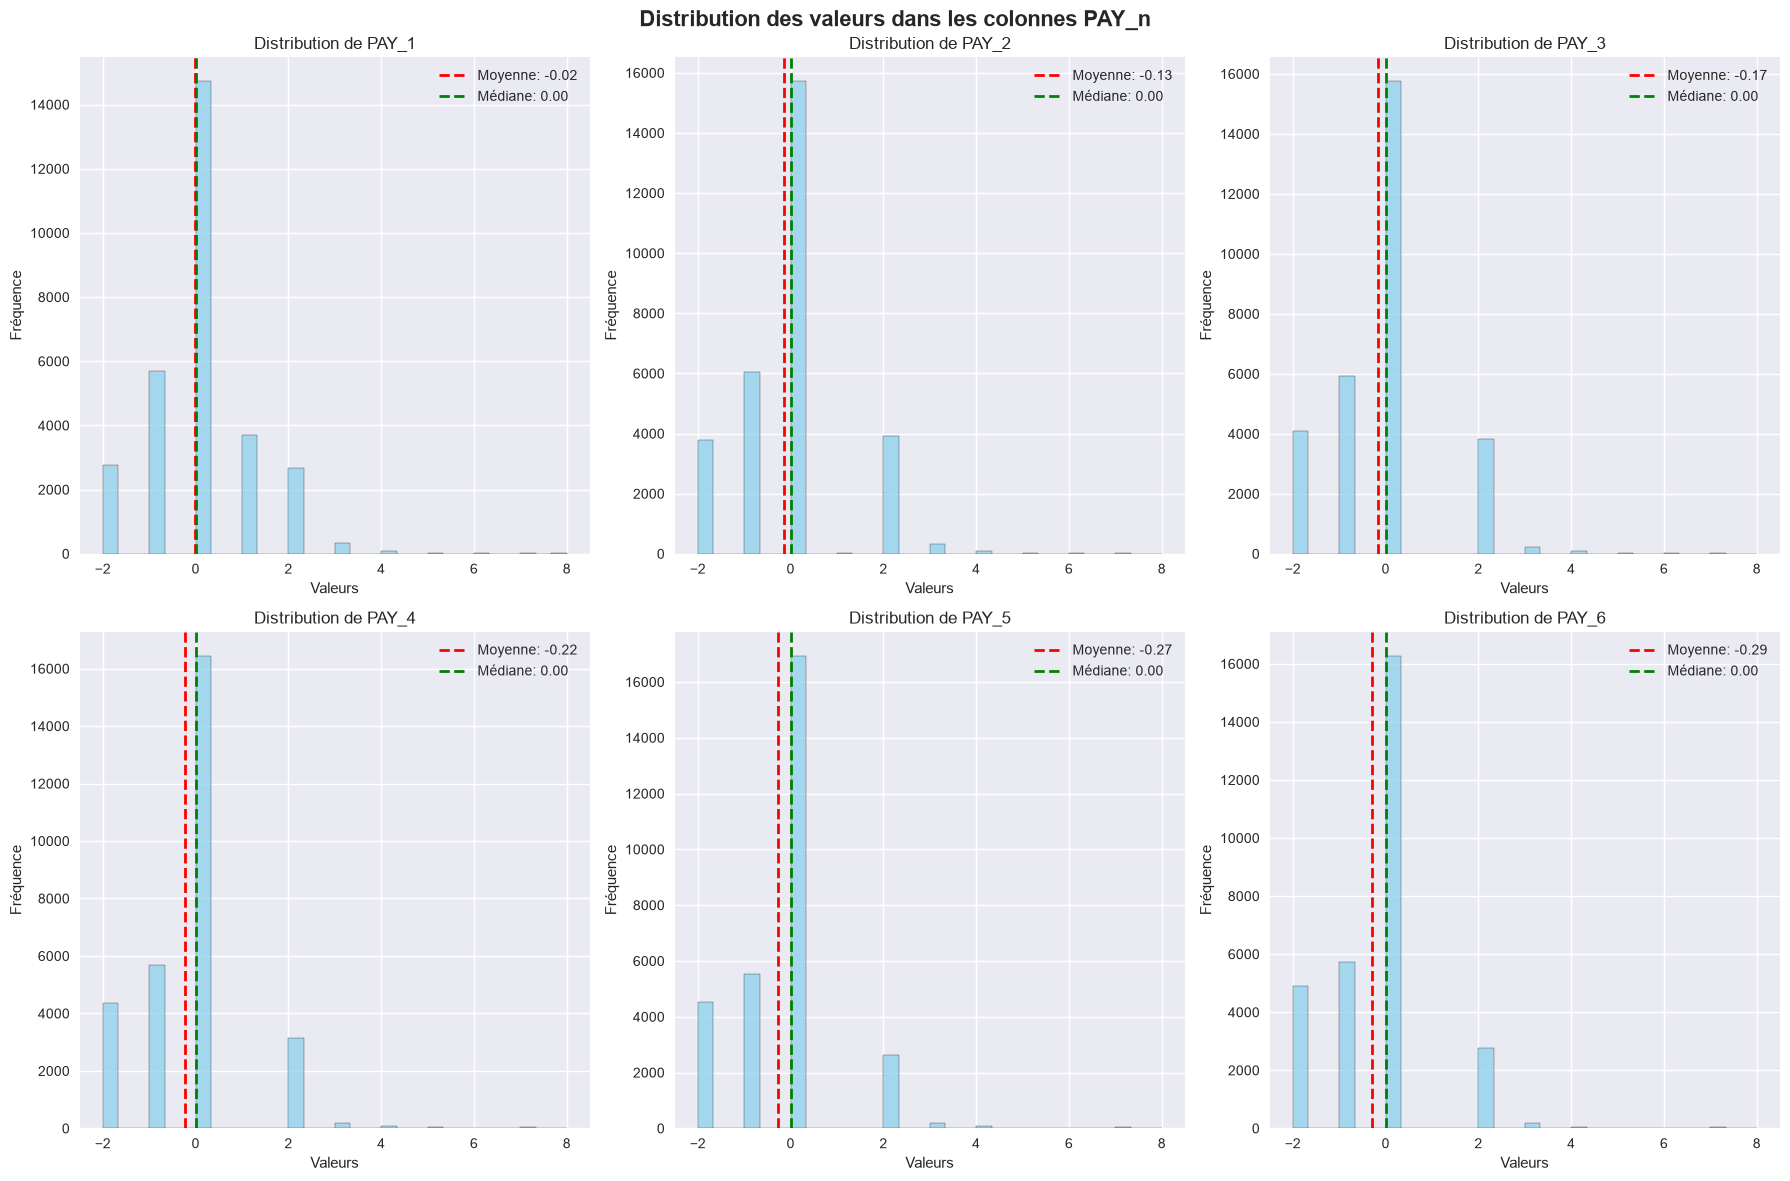


=== HISTOGRAMME CUMULÉ ===


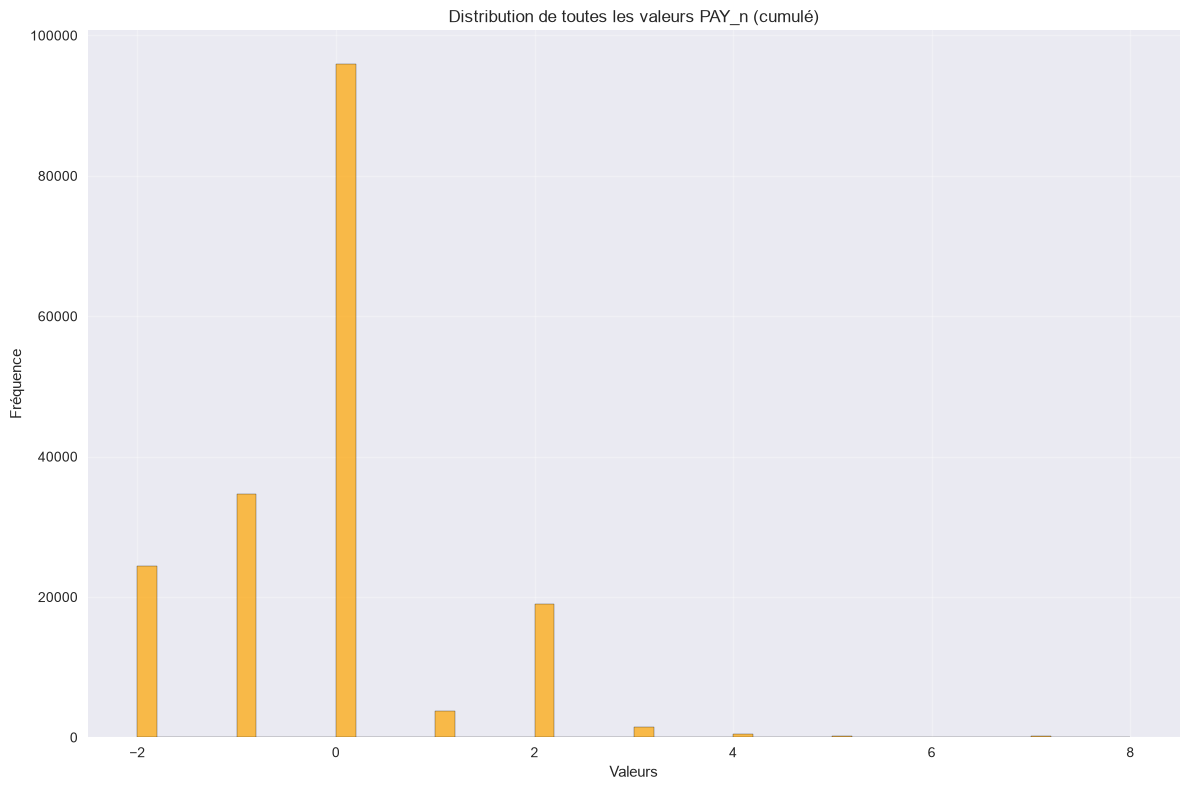

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== HISTOGRAMMES DES VALEURS PAY_N ===")

# Configuration du style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution des valeurs dans les colonnes PAY_n', fontsize=16, fontweight='bold')

# Création des histogrammes pour chaque colonne
for i, col in enumerate(pay_columns):
    row = i // 3
    col_idx = i % 3
    
    # Filtrer les valeurs non nulles pour l'histogramme
    data = df[col].dropna()
    
    axes[row, col_idx].hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution de {col}')
    axes[row, col_idx].set_xlabel('Valeurs')
    axes[row, col_idx].set_ylabel('Fréquence')
    
    # Ajout des statistiques
    mean_val = data.mean()
    median_val = data.median()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                              label=f'Moyenne: {mean_val:.2f}')
    axes[row, col_idx].axvline(median_val, color='green', linestyle='--', linewidth=2, 
                              label=f'Médiane: {median_val:.2f}')
    axes[row, col_idx].legend()

# Cacher l'axe vide si nécessaire
if len(pay_columns) < 6:
    axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== HISTOGRAMME CUMULÉ ===")
# Histogramme cumulé de toutes les colonnes - CORRECTION
fig, ax = plt.subplots(figsize=(12, 8))

# Rassembler toutes les valeurs (pas de cumulative=True)
all_values = []
for col in pay_columns:
    all_values.extend(df[col].dropna())

# Créer l'histogramme standard avec toutes les données
ax.hist(all_values, bins=50, alpha=0.7, color='orange', edgecolor='black')
ax.set_title('Distribution de toutes les valeurs PAY_n (cumulé)')
ax.set_xlabel('Valeurs')
ax.set_ylabel('Fréquence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Codification 1 (PAY_n = 1)** : analyses et interprétations déplacées dans [05_04_EDA_codification1.ipynb](05_04_EDA_codification1.ipynb) (annexe), où cette codification est étudiée en détail.

PAY_1 contient beaucoup de '1' alors que cette valeur est qausi absente des autres colonnes, et nombre d'entre eux ne sont pas justifiés  
Avant de tenter un nettoyage, je constate une tendance de codification légèrement différente de ce qui est décrit dans la documentation  
Si on écarte les erreurs humaines, informatiques et autres, il se dégage une certaine tendance concernant les valeurs de PAY_n :
- -2 correspond à des comptes majoritairement inactifs
- -1 et 0 correspondent à des comptes ayant un fonctionnement sain ne présentant pas de retard
- 1 correspond à une sorte d'alerte sur le compte (fin d'un retard, activation ou réactivation d'un compte), il ne semble pas forcemment correspondre à une échéance de retard
- 2 et + correspondent à des comptes avec retards, en effet un incident fait basculer la note directement à 2
Ces indications sont très importantes pour la représentation des ensembles et la creéations des features pour les futurs modèles de prédiction  
Dans le cas ou 1 signifie que la banque a reçu une information interne ou externe concernant le compte, il apparaît délicat de corriger cette colonne.

Le défaut de paiement futur 'dpnm' est de 22% dans le dataset.  
Une banque ne survivrait pas plusieurs mois avec un taux de défaillance aussi élevé, on peut s'interroger sur l'origine du dataset et de son éventuel biais, surtout mis en relation avec la forte proportion de PAY_1 = 1.  
Ceci est à mettre dans le contexte suivant : une crise importante a eu lieu en 2005 à Taïwan sur le crédit avec un emballement soudain de son usage et du taux de défaut.

In [28]:
# Afficher la proportion de dpnm == 1 alors que BILL_AMT1 <= 0
print("=== ANALYSE DE dpnm LORSQUE BILL_AMT1 <= 0 ===")

# Création des masques
mask_bill_zero = df['BILL_AMT1'] <= 0
total_with_bill_zero = mask_bill_zero.sum()

print(f"Nombre total de lignes où BILL_AMT1 <= 0 : {total_with_bill_zero}")

if total_with_bill_zero > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df['BILL_AMT1'] <= 0) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_bill_zero) * 100
    
    print(f"Nombre de lignes où BILL_AMT1 <= 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où BILL_AMT1 <= 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_bill_zero]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où BILL_AMT1 <= 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_bill_zero) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_bill_zero} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_bill_zero > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec BILL_AMT1 <= 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_bill_zero].head(5)
    print("Premières lignes où BILL_AMT1 <= 0 :")
    print(sample_rows[['BILL_AMT1', 'dpnm']])
    
else:
    print("Aucune ligne ne correspond à la condition BILL_AMT1 <= 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("BILL_AMT1 <= 0", df['BILL_AMT1'] <= 0),
    ("BILL_AMT1 > 0", df['BILL_AMT1'] > 0),
    ("BILL_AMT1 < 0", df['BILL_AMT1'] < 0)
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE BILL_AMT1 <= 0 ===
Nombre total de lignes où BILL_AMT1 <= 0 : 2598
Nombre de lignes où BILL_AMT1 <= 0 ET dpnm == 1 : 643
Proportion de dpnm == 1 parmi les lignes où BILL_AMT1 <= 0 : 24.75%

Répartition complète de dpnm pour les lignes où BILL_AMT1 <= 0 :
  - dpnm = 0 : 1955 sur 2598 (75.25%)
  - dpnm = 1 : 643 sur 2598 (24.75%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec BILL_AMT1 <= 0 : 24.75%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 2.63%

=== EXEMPLES DE LIGNES ===
Premières lignes où BILL_AMT1 <= 0 :
    BILL_AMT1  dpnm
ID                 
10          0     0
19          0     0
20          0     0
27       -109     1
39          0     1

=== ANALYSE COMPARATIVE ===

BILL_AMT1 <= 0 :
  - dpn

Ces résultats sont extrêmement illogiques, une banque ne peut pas avoir un incident de paiement futur sans encours.  
Cela est surtout un bruit conséquent que les modèles ne pourront pas atténuer. De plus, pour une banque, c'est la sécurisation de l'encours réel qui compte

In [29]:
# Afficher la proportion de dpnm == 1 alors que TOUS les BILL_AMTn < 0
print("=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn < 0 ===")

# Création des listes de colonnes
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Trouver les lignes où TOUS les BILL_AMTn sont < 0
mask_all_bill_neg = df[bill_amt_columns].lt(0).all(axis=1)
total_with_all_bill_neg = mask_all_bill_neg.sum()

print(f"Nombre total de lignes où TOUS les BILL_AMTn < 0 : {total_with_all_bill_neg}")

if total_with_all_bill_neg > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df[bill_amt_columns].lt(0).all(axis=1)) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_all_bill_neg) * 100
    
    print(f"Nombre de lignes où TOUS les BILL_AMTn < 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn < 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_all_bill_neg]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où TOUS les BILL_AMTn < 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_all_bill_neg) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_all_bill_neg} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_all_bill_neg > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn < 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_all_bill_neg].head(5)
    print("Premières lignes où TOUS les BILL_AMTn < 0 :")
    print(sample_rows[['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'dpnm']])
else:
    print("Aucune ligne ne correspond à la condition TOUS les BILL_AMTn < 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("TOUS les BILL_AMTn < 0", df[bill_amt_columns].lt(0).all(axis=1)),
    ("AU MOINS UN BILL_AMTn < 0", df[bill_amt_columns].lt(0).any(axis=1)),
    ("TOUS les BILL_AMTn > 0", df[bill_amt_columns].gt(0).all(axis=1))
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn < 0 ===
Nombre total de lignes où TOUS les BILL_AMTn < 0 : 88
Nombre de lignes où TOUS les BILL_AMTn < 0 ET dpnm == 1 : 26
Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn < 0 : 29.55%

Répartition complète de dpnm pour les lignes où TOUS les BILL_AMTn < 0 :
  - dpnm = 0 : 62 sur 88 (70.45%)
  - dpnm = 1 : 26 sur 88 (29.55%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn < 0 : 29.55%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 7.42%

=== EXEMPLES DE LIGNES ===
Premières lignes où TOUS les BILL_AMTn < 0 :
     BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  dpnm
ID                                                              
110       -103    

In [30]:
# Afficher la proportion de dpnm == 1 alors que TOUS les BILL_AMTn == 0
print("=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn == 0 ===")

# Création des listes de colonnes
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Trouver les lignes où TOUS les BILL_AMTn sont == 0
mask_all_bill_zero = df[bill_amt_columns].eq(0).all(axis=1)
total_with_all_bill_zero = mask_all_bill_zero.sum()

print(f"Nombre total de lignes où TOUS les BILL_AMTn == 0 : {total_with_all_bill_zero}")

if total_with_all_bill_zero > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df[bill_amt_columns].eq(0).all(axis=1)) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_all_bill_zero) * 100
    
    print(f"Nombre de lignes où TOUS les BILL_AMTn == 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn == 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_all_bill_zero]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où TOUS les BILL_AMTn == 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_all_bill_zero) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_all_bill_zero} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_all_bill_zero > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn == 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_all_bill_zero].head(5)
    print("Premières lignes où TOUS les BILL_AMTn == 0 :")
    print(sample_rows[['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'dpnm']])
    
else:
    print("Aucune ligne ne correspond à la condition TOUS les BILL_AMTn == 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("TOUS les BILL_AMTn == 0", df[bill_amt_columns].eq(0).all(axis=1)),
    ("TOUS les BILL_AMTn <= 0", df[bill_amt_columns].le(0).all(axis=1)),
    ("AU MOINS UN BILL_AMTn == 0", df[bill_amt_columns].eq(0).any(axis=1)),
    ("TOUS les BILL_AMTn > 0", df[bill_amt_columns].gt(0).all(axis=1))
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn == 0 ===
Nombre total de lignes où TOUS les BILL_AMTn == 0 : 866
Nombre de lignes où TOUS les BILL_AMTn == 0 ET dpnm == 1 : 317
Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn == 0 : 36.61%

Répartition complète de dpnm pour les lignes où TOUS les BILL_AMTn == 0 :
  - dpnm = 0 : 549 sur 866 (63.39%)
  - dpnm = 1 : 317 sur 866 (36.61%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn == 0 : 36.61%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 14.48%

=== EXEMPLES DE LIGNES ===
Premières lignes où TOUS les BILL_AMTn == 0 :
     BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  dpnm
ID                                                              
19  

Aucune information n'existe sur internet ni dans l'étude originelle de 2009 sur ces incidents de paiement qui ne semblent pas concerner un encours. Si on raisonne logique métier, nous cherchons à sécuriser un encours et à prévoir le défaut de paiement réel.  
Il conviendra donc de ne pas inclure ces comptes inactifs dans les modèles d'apprentissage et de ne pas prédire le risque de défaut sur un crédit non utilisé.

**Codification 1 (PAY_n = 1)** : analyses et interprétations déplacées dans [05_04_EDA_codification1.ipynb](05_04_EDA_codification1.ipynb) (annexe), où cette codification est étudiée en détail.

Un tableau de dispersion ici n'a pas beaucoup d'intéret.  
Je fais un heatmap.  

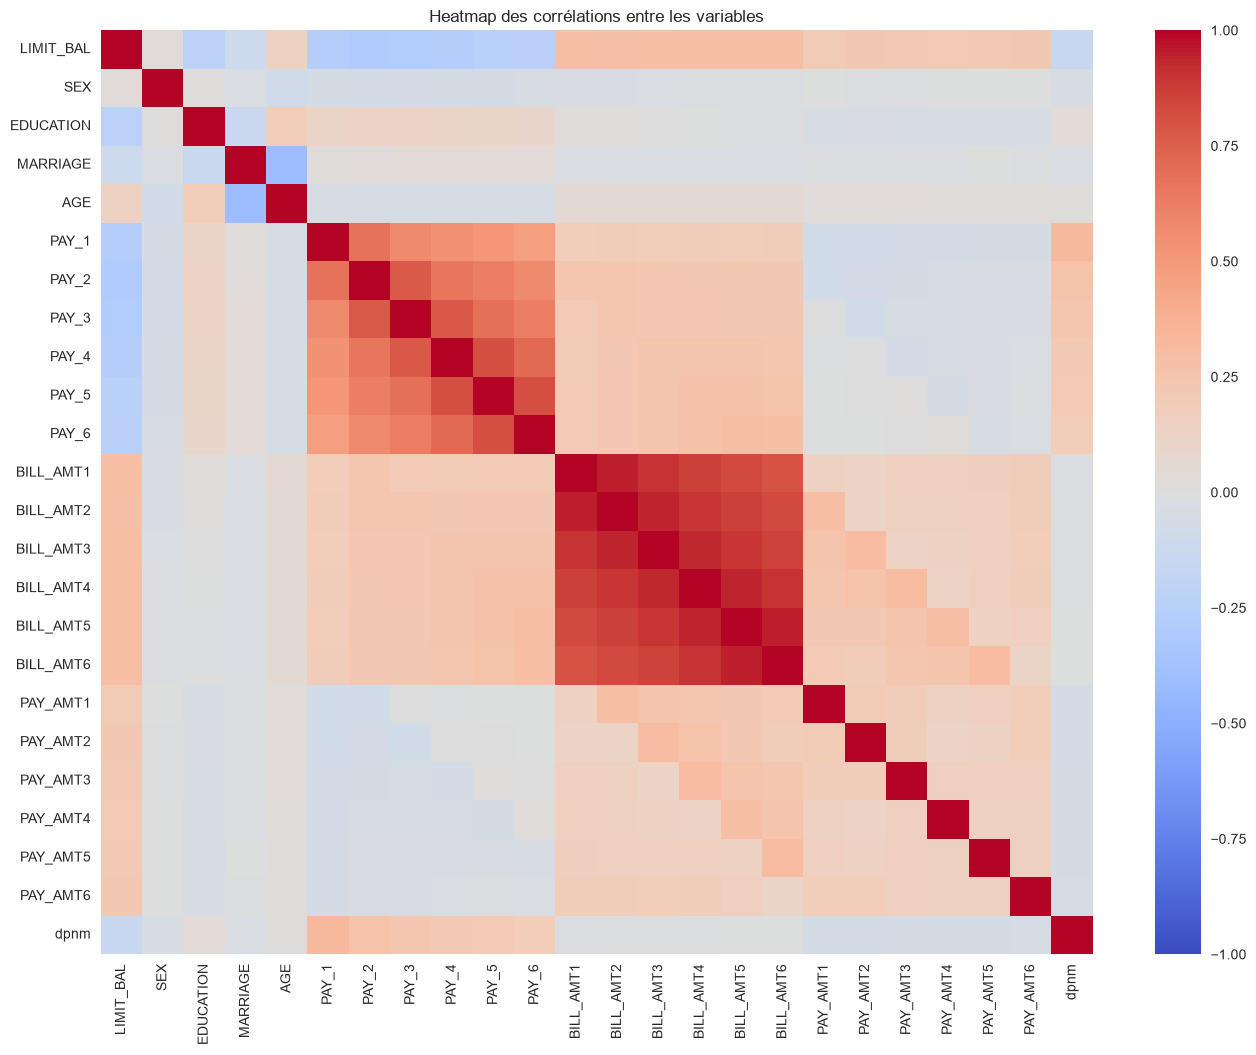

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assurez-vous que 'df' est votre DataFrame contenant les variables mentionnées
# Exemple : df = pd.read_csv('votre_fichier.csv')

# Sélectionner les variables pour la heatmap
variables = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 
             'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 
             'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']

# Calculer la matrice de corrélation
correlation_matrix = df[variables].corr()

# Créer la heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap des corrélations entre les variables')
plt.show()

on voit des tendances, parfois contre intuitives :
- le défaut de paiement est plus important sur les plus petits plafond de crédit
- le défaut de paiement est directement lié avec le retard d'échéances
- les retards de paiement sont plus importants/fréquents quand l'encours augmente

y a t il un seuil de montant payé ou montant payé / encours à partir duquel la banque considère l'échéance payée ?  
Je commence par regarder si des montants sont payés alors que les encours sont négatifs ou nuls  

Analyse des cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :
Cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :
                         Paire  Nombre d'observations  Moyenne PAY_AMT1  Moyenne BILL_AMT2  Ratio moyen  Moyenne PAY_AMT2  Moyenne BILL_AMT3  Moyenne PAY_AMT3  Moyenne BILL_AMT4  Moyenne PAY_AMT4  Moyenne BILL_AMT5  Moyenne PAY_AMT5  Moyenne BILL_AMT6
PAY_AMT1 > 0 et BILL_AMT2 <= 0                    144           2264.22           -2187.69      -103.50               NaN                NaN               NaN                NaN               NaN                NaN               NaN                NaN
PAY_AMT2 > 0 et BILL_AMT3 <= 0                    161               NaN                NaN      -158.93           4486.48            -2823.0               NaN                NaN               NaN                NaN               NaN                NaN
PAY_AMT3 > 0 et BILL_AMT4 <= 0                    171               NaN                NaN      -117.55               NaN                NaN        

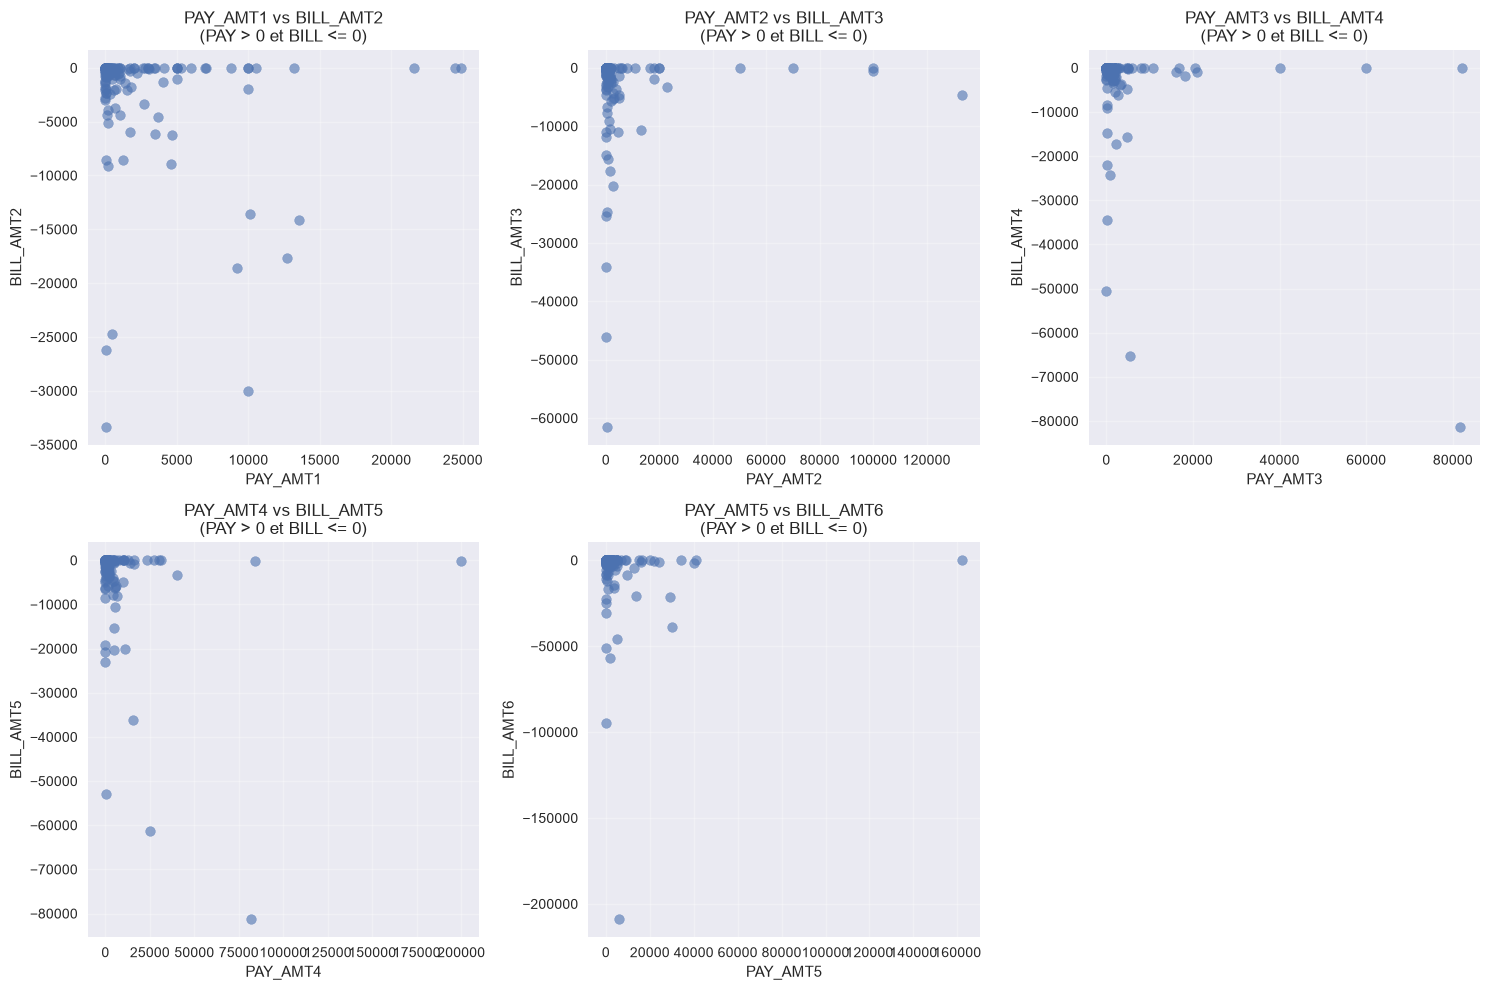


Analyse des cas extrêmes :

PAY_AMT1 / BILL_AMT2:
  Nombre de cas : 144
  PAY max : 24890
  BILL min : -33350

PAY_AMT2 / BILL_AMT3:
  Nombre de cas : 161
  PAY max : 133122
  BILL min : -61506

PAY_AMT3 / BILL_AMT4:
  Nombre de cas : 171
  PAY max : 82150
  BILL min : -81334

PAY_AMT4 / BILL_AMT5:
  Nombre de cas : 178
  PAY max : 200000
  BILL min : -81334

PAY_AMT5 / BILL_AMT6:
  Nombre de cas : 177
  PAY max : 162000
  BILL min : -209051

Résumé global :
Total de cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 : 831


In [32]:
import pandas as pd
import numpy as np

# Vérification des cas où PAY_AMTn est positif mais BILL_AMTn+1 <= 0
print("Analyse des cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :")

# Colonnes de paiement et de facturation
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Création d'une liste pour stocker les résultats
results = []

for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Identifier les lignes où PAY_AMTn > 0 ET BILL_AMTn+1 <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    filtered_data = df[condition]
    
    count = len(filtered_data)
    if count > 0:
        # Calcul des statistiques sur ces données
        mean_pay = filtered_data[pay_col].mean()
        mean_bill = filtered_data[bill_col].mean()
        
        results.append({
            'Paire': f'{pay_col} > 0 et {bill_col} <= 0',
            'Nombre d\'observations': count,
            f'Moyenne {pay_col}': round(mean_pay, 2),
            f'Moyenne {bill_col}': round(mean_bill, 2),
            'Ratio moyen': round(mean_pay / mean_bill * 100, 2) if mean_bill != 0 else None
        })
    else:
        results.append({
            'Paire': f'{pay_col} > 0 et {bill_col} <= 0',
            'Nombre d\'observations': 0,
            f'Moyenne {pay_col}': None,
            f'Moyenne {bill_col}': None,
            'Ratio moyen': None
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :")
print(results_df.to_string(index=False))

# Analyse plus détaillée : compter combien de fois chaque condition est remplie
print("\nAnalyse globale des conditions :")

# Compter les cas pour chaque paire
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Cas 1 : PAY_AMTn > 0 et BILL_AMTn+1 <= 0
    condition1 = (df[pay_col] > 0) & (df[bill_col] <= 0)
    
    # Cas 2 : PAY_AMTn <= 0 et BILL_AMTn+1 > 0  
    condition2 = (df[pay_col] <= 0) & (df[bill_col] > 0)
    
    # Cas 3 : PAY_AMTn > 0 et BILL_AMTn+1 > 0
    condition3 = (df[pay_col] > 0) & (df[bill_col] > 0)
    
    # Cas 4 : PAY_AMTn <= 0 et BILL_AMTn+1 <= 0
    condition4 = (df[pay_col] <= 0) & (df[bill_col] <= 0)
    
    print(f"\n{pay_col} / {bill_col}:")
    print(f"  PAY > 0 et BILL <= 0 : {condition1.sum()}")
    print(f"  PAY <= 0 et BILL > 0 : {condition2.sum()}")
    print(f"  PAY > 0 et BILL > 0 : {condition3.sum()}")
    print(f"  PAY <= 0 et BILL <= 0 : {condition4.sum()}")

# Visualisation de la distribution des paiements et factures
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Histogramme pour chaque paire
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    plt.subplot(2, 3, i+1)
    
    # Filtrer les données pour cette paire
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    data = df[condition]
    
    if len(data) > 0:
        plt.scatter(data[pay_col], data[bill_col], alpha=0.6)
        plt.xlabel(f'{pay_col}')
        plt.ylabel(f'{bill_col}')
        plt.title(f'{pay_col} vs {bill_col}\n(PAY > 0 et BILL <= 0)')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Aucune donnée', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{pay_col} vs {bill_col}\n(PAY > 0 et BILL <= 0)')

plt.tight_layout()
plt.show()

# Analyse des cas extrêmes
print("\nAnalyse des cas extrêmes :")

# Identifier les valeurs maximales et minimales dans chaque colonne
for pay_col, bill_col in zip(payment_columns, bill_columns):
    print(f"\n{pay_col} / {bill_col}:")
    
    # Cas où PAY > 0 et BILL <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    extreme_data = df[condition]
    
    if len(extreme_data) > 0:
        print(f"  Nombre de cas : {len(extreme_data)}")
        print(f"  PAY max : {extreme_data[pay_col].max()}")
        print(f"  BILL min : {extreme_data[bill_col].min()}")
    else:
        print("  Aucun cas trouvé")

# Résumé global
print("\nRésumé global :")
total_cases = sum([len(df[(df[pay_col] > 0) & (df[bill_col] <= 0)]) 
                   for pay_col, bill_col in zip(payment_columns, bill_columns)])
print(f"Total de cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 : {total_cases}")

trouver une mensualité payée sur un encours nul ou négatif est un non-sens métier  
les anomalies sont elles groupées sur 200 lignes ou sont elles 1000 lignes distinctes ?

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. INITIALISATION DES VARIABLES
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Ensemble global pour compter les LIGNES DISTINCTES
unique_problematic_lines = set()

# Dictionnaire pour stocker les indices spécifiques à chaque paire (utile pour l'analyse détaillée)
pairs_indices = {}

print("Analyse des paiements effectués sur un encours <= 0 :\n")

# Itération sur chaque mois pour identifier les conditions
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Condition : Paiement > 0 ET Encours (Facture précédente) <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    
    # Récupération des indices de lignes pour cette paire spécifique
    current_indices = set(df[condition].index)
    
    # Ajout à l'ensemble global (gère l'unicité automatique)
    unique_problematic_lines.update(current_indices)
    
    print(f"--- {pay_col} vs {bill_col} ---")
    print(f"Lignes spécifiques à cette paire : {len(current_indices)}")
    
    pairs_indices[f"{pay_col} (sur {bill_col})"] = current_indices

# 2. RÉSULTAT PRINCIPAL : NOMBRE DE LIGNES DISTINCTES
print("\n" + "="*50)
print(f"TOTAL DES LIGNES DISTINCTES AVEC AU MOINS UN PAIEMENT SUR ENCOURS <= 0")
print(f"Nombre de clients/lignes concernés : {len(unique_problematic_lines)}")
print(f"Pourcentage du dataset : {len(unique_problematic_lines)/len(df)*100:.2f}%")
print("="*50)

# Récupération des index sous forme de liste pour manipuler le DataFrame
list_unique_lines = list(unique_problematic_lines)

# 3. AFFICHAGE D'UN EXEMPLE DE 10 LIGNES
print("\n--- Exemple de 10 lignes concernées ---")
# On prend les 10 premiers index trouvés
if len(list_unique_lines) > 0:
    sample_indices = list_unique_lines[:10]
    
    # Sélection des colonnes pertinentes pour l'analyse visuelle
    columns_to_show = payment_columns + bill_columns + ['SEX', 'EDUCATION', 'MARRIAGE']
    
    df_sample = df.loc[sample_indices, columns_to_show].copy()
    
    # Pour plus de clarté, on colorie ou indique simplement les données brutes
    print(df_sample.to_string())
else:
    print("Aucune ligne concernée.")

# 4. ANALYSE DE LA RÉCURRENCE (Optionnel mais informatif)
recurrence = {line: 0 for line in unique_problematic_lines}
for indices_set in pairs_indices.values():
    for line in indices_set:
        recurrence[line] += 1

clients_multi_fois = {line: count for line, count in recurrence.items() if count > 1}
print(f"\n--- Analyse de récurrence ---")
print(f"Lignes concernées par PLUSIEURS mois : {len(clients_multi_fois)}")

# 5. TABLEAU RÉCAPITULATIF STATISTIQUE PAR PAIRE (sur l'ensemble unique)
stats_list = []
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Intersection : lignes qui ont payé >0 sur cette facture <=0 ET qui sont dans notre ensemble global
    valid_indices = pairs_indices[f"{pay_col} (sur {bill_col})"].intersection(unique_problematic_lines)
    
    if len(valid_indices) > 0:
        sub_df = df.loc[list(valid_indices)]
        mean_pay = sub_df[pay_col].mean()
        std_pay = sub_df[pay_col].std()
        
        stats_list.append({
            'Paire': f'{pay_col} / {bill_col}',
            'Nb Lignes Distinctes dans ce lot': len(valid_indices),
            'Moyenne Payée': round(mean_pay, 2),
            'Ecart-Type': round(std_pay, 2)
        })

if stats_list:
    df_stats = pd.DataFrame(stats_list)
    print("\n--- Tableau détaillé par paire (sur les lignes distinctes globales) ---")
    print(df_stats.to_string(index=False))

Analyse des paiements effectués sur un encours <= 0 :

--- PAY_AMT1 vs BILL_AMT2 ---
Lignes spécifiques à cette paire : 144
--- PAY_AMT2 vs BILL_AMT3 ---
Lignes spécifiques à cette paire : 161
--- PAY_AMT3 vs BILL_AMT4 ---
Lignes spécifiques à cette paire : 171
--- PAY_AMT4 vs BILL_AMT5 ---
Lignes spécifiques à cette paire : 178
--- PAY_AMT5 vs BILL_AMT6 ---
Lignes spécifiques à cette paire : 177

TOTAL DES LIGNES DISTINCTES AVEC AU MOINS UN PAIEMENT SUR ENCOURS <= 0
Nombre de clients/lignes concernés : 690
Pourcentage du dataset : 2.30%

--- Exemple de 10 lignes concernées ---
       PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  SEX  EDUCATION  MARRIAGE
ID                                                                                                                                      
12293      5000     15066      5007         0      3000     113974     126194      17832      -3000          0    2          2         2
8198

Les 10 lignes montrées en exemple montrent clairement un remboursement trop important qui a mené à un encours négatif.  
Ces lignes atypiques correspondent en grande partie à des situations plausibles.  
Je n'y touche pas

In [34]:
import pandas as pd
import numpy as np

# Définition des colonnes
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("Calcul des ratios conditionnels (uniquement si BILL > 0) :\n")

for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    new_col_name = f"ratio_brut_PAY_BILL{pay_col.replace('PAY_AMT', '')}"
    
    # Création de la nouvelle colonne initialisée à NaN
    df[new_col_name] = np.nan
    
    # Sélection des lignes où la facture (dénominateur) est strictement positive
    valid_mask = df[bill_col] > 0
    
    if valid_mask.any():
        # Calcul du ratio uniquement sur les lignes valides
        # On évite ainsi la division par zéro ou par un négatif
        df.loc[valid_mask, new_col_name] = (df.loc[valid_mask, pay_col] / df.loc[valid_mask, bill_col]) * 100
        
        print(f"- {new_col_name}: Calculé sur {valid_mask.sum()} lignes valides")
    else:
        print(f"- {new_col_name}: Aucune facture positive trouvée ({bill_col} <= 0 pour tous), colonne vide (NaN).")

# Affichage des nouvelles colonnes créées
print("\nNouvelles colonnes créées :")
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    new_col_name = f"ratio_brut_PAY_BILL{pay_col.replace('PAY_AMT', '')}"
    print(f"- {new_col_name}")

# Vérification rapide pour voir combien de NaN il y a dans une colonne exemple
example_col = 'ratio_brut_PAY_BILL1'
print(f"\nVérification sur '{example_col}':")
print(f" - Valeurs valides (non-NaN) : {df[example_col].notna().sum()}")
print(f" - Valeurs NaN : {df[example_col].isna().sum()}")

Calcul des ratios conditionnels (uniquement si BILL > 0) :

- ratio_brut_PAY_BILL1: Calculé sur 26823 lignes valides
- ratio_brut_PAY_BILL2: Calculé sur 26471 lignes valides
- ratio_brut_PAY_BILL3: Calculé sur 26126 lignes valides
- ratio_brut_PAY_BILL4: Calculé sur 25835 lignes valides
- ratio_brut_PAY_BILL5: Calculé sur 25288 lignes valides

Nouvelles colonnes créées :
- ratio_brut_PAY_BILL1
- ratio_brut_PAY_BILL2
- ratio_brut_PAY_BILL3
- ratio_brut_PAY_BILL4
- ratio_brut_PAY_BILL5

Vérification sur 'ratio_brut_PAY_BILL1':
 - Valeurs valides (non-NaN) : 26823
 - Valeurs NaN : 3173


In [35]:
import pandas as pd
import numpy as np

# Définition des colonnes de ratio
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(payment_columns, bill_columns)]

# Liste pour stocker les statistiques par colonne
stats_data = []

print("--- Statistiques Descriptives des Ratios ---\n")

for col in ratio_columns:
    # On filtre les valeurs non NaN pour éviter les erreurs de calcul
    clean_values = df[col].dropna()
    
    if len(clean_values) > 0:
        min_val = clean_values.min()
        mean_val = clean_values.mean()
        median_val = clean_values.median()
        max_val = clean_values.max()
        
        stats_data.append({
            'Colonne': col,
            'Min': round(min_val, 2),
            'Moyenne': round(mean_val, 2),
            'Médiane': round(median_val, 2),
            'Max': round(max_val, 2)
        })

# Création du DataFrame de statistiques
df_stats = pd.DataFrame(stats_data)

print(df_stats.to_string(index=False))

# Optionnel : Afficher la distribution globale de toutes ces colonnes combinées
all_ratios = df[ratio_columns].stack().dropna()
print(f"\n--- Statistiques Globales (tous ratios confondus) ---")
print(f"Min Global: {all_ratios.min():.2f}")
print(f"Moyenne Globale: {all_ratios.mean():.2f}")
print(f"Médiane Globale: {all_ratios.median():.2f}")
print(f"Max Global: {all_ratios.max():.2f}")

--- Statistiques Descriptives des Ratios ---

             Colonne  Min  Moyenne  Médiane       Max
ratio_brut_PAY_BILL1  0.0    52.97     7.83 444433.33
ratio_brut_PAY_BILL2  0.0    73.52     7.75 500100.00
ratio_brut_PAY_BILL3  0.0    52.11     6.17 444433.33
ratio_brut_PAY_BILL4  0.0    34.89     5.17  12970.51
ratio_brut_PAY_BILL5  0.0    42.18     5.59  69065.52

--- Statistiques Globales (tous ratios confondus) ---
Min Global: 0.00
Moyenne Globale: 51.30
Médiane Globale: 6.57
Max Global: 500100.00


In [36]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(payment_columns, bill_columns)]

# 1. Compter les lignes avec au moins un ratio > 100%
count_high_ratio = df[ratio_columns].gt(100).any(axis=1).sum()

print(f"Nombre de lignes montrant un ratio > 100% : {count_high_ratio}")

# 2. Afficher les détails (optionnel, pour vérifier)
if count_high_ratio > 0:
    df_with_high_ratio = df[df[ratio_columns].gt(100).any(axis=1)]
    print("\n--- Exemple de lignes concernées ---")
    # On montre les ratios concernés surlignés
    cols_display = ratio_columns
    print(df_with_high_ratio[cols_display].head(5).to_string())

Nombre de lignes montrant un ratio > 100% : 5934

--- Exemple de lignes concernées ---
    ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                              
5              35.273369            102.360820             47.755492             47.007208              3.601485
8             100.000000            100.000000              0.000000                   NaN            297.530864
11             23.561868              0.216802              1.989654             16.411379            100.187617
12            100.682972            100.000000            100.774921            100.062817              0.000000
18              4.201415              5.137083            108.371150            341.530055            100.000000


In [37]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(payment_columns, bill_columns)]

# 1. Compter les lignes avec au moins un ratio > 120%
count_high_ratio = df[ratio_columns].gt(120).any(axis=1).sum()

print(f"Nombre de lignes montrant un ratio > 120% : {count_high_ratio}")

# 2. Afficher les détails (optionnel, pour vérifier)
if count_high_ratio > 0:
    df_with_high_ratio = df[df[ratio_columns].gt(120).any(axis=1)]
    print("\n--- Exemple de lignes concernées ---")
    # On montre les ratios concernés surlignés
    cols_display = ratio_columns
    print(df_with_high_ratio[cols_display].head(5).to_string())

Nombre de lignes montrant un ratio > 120% : 1445

--- Exemple de lignes concernées ---
    ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                              
8             100.000000            100.000000              0.000000                   NaN            297.530864
18              4.201415              5.137083            108.371150            341.530055            100.000000
27                   NaN            386.100386                   NaN            393.700787                   NaN
38             15.296757             13.715215             33.903087                   NaN            255.471597
62              5.585623              2.995510              6.054002             14.188422            361.445783


In [38]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(payment_columns, bill_columns)]

# 1. Filtrage des lignes avec au moins un ratio > 1000%
mask_extreme_ratio = df[ratio_columns].gt(1000).any(axis=1)
df_with_high_ratio = df[mask_extreme_ratio]

print(f"Nombre de lignes montrant un ratio > 1000% : {len(df_with_high_ratio)}")

# 2. Affichage des lignes complètes
if len(df_with_high_ratio) > 0:
    print("\n--- Lignes complètes avec Ratio > 1000% ---")
    # On affiche les 5 premières lignes pour l'exemple
    # Tu peux enlever .head(5) si tu veux tout voir (attention à la longueur)
    print(df_with_high_ratio.head(5).to_string())
else:
    print("Aucune ligne trouvée.")

Nombre de lignes montrant un ratio > 1000% : 89

--- Lignes complètes avec Ratio > 1000% ---
     LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                                                                                                                                                                                                                                                       
344     180000    1          1         1   39      0      0     -1      0      0     -1     274731     281713     242063     122295      -1005       1005     11000    145000     26000         0    101005      1898     0              3.904683      

--- Analyse des Valeurs Aberrantes ---

             Colonne  Min Aberrant  Max Aberrant  Nombre d'aberrations  Borne Basse (Q1-1.5*IQR)  Borne Haute (Q3+1.5*IQR)
ratio_brut_PAY_BILL1    248.819876 444433.333333                    78                   -139.29                    243.58
ratio_brut_PAY_BILL2    245.766773 500100.000000                    89                   -139.40                    243.64
ratio_brut_PAY_BILL3    233.333333 444433.333333                   104                   -134.17                    233.30
ratio_brut_PAY_BILL4    201.827676  12970.512821                   132                   -115.26                    201.64
ratio_brut_PAY_BILL5    246.366559  69065.517241                    92                   -140.81                    244.49


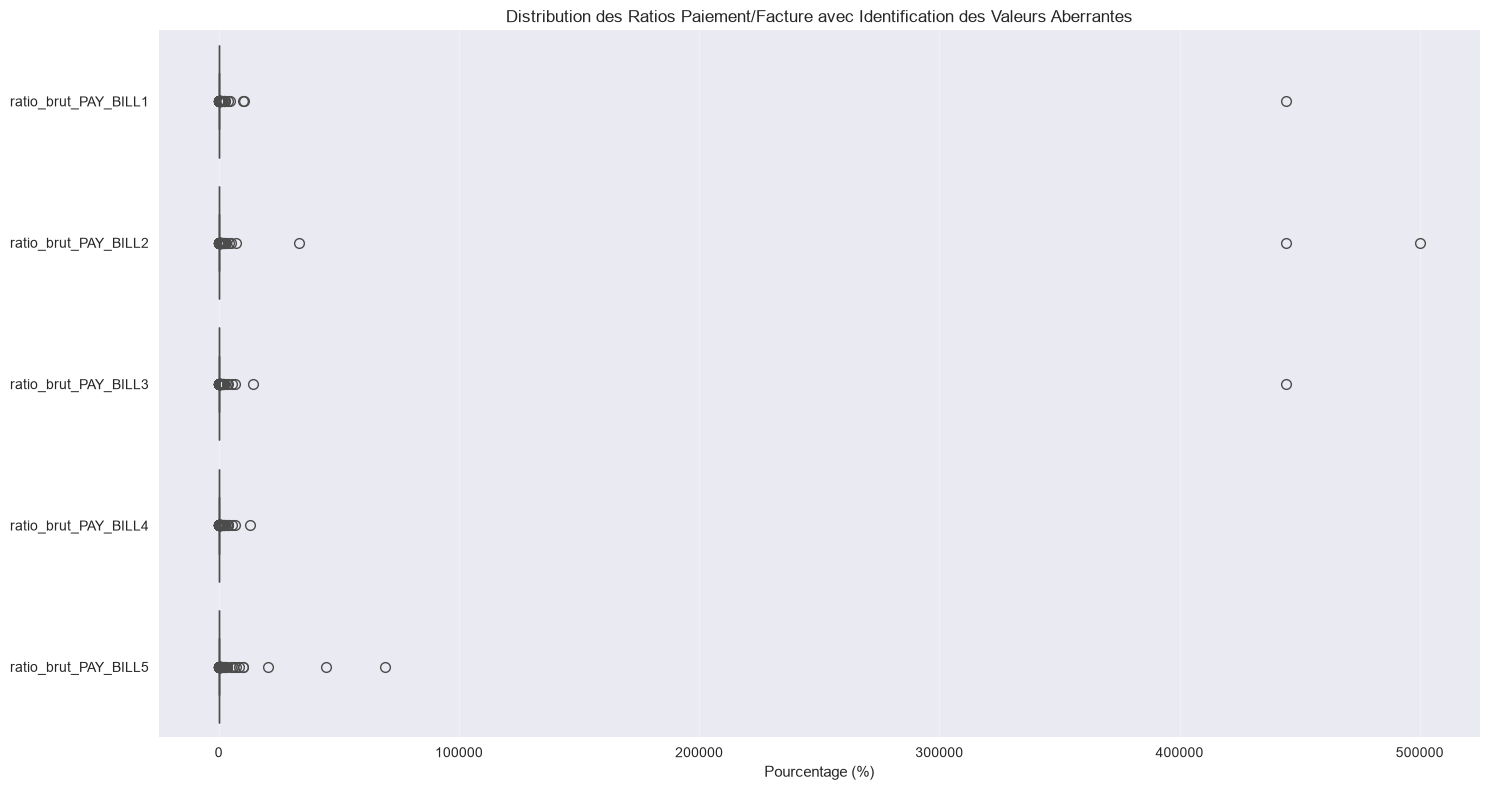

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ratio_columns = [f"ratio_brut_PAY_BILL{pay.replace('PAY_AMT', '')}" for pay, bill in zip(
    ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5'],
    ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
)]

# 1. DÉFINITION DES VALEURS ABERRANTES (Outliers)
# Une valeur est aberrante si elle est < Q1 - 1.5*IQR ou > Q3 + 1.5*IQR
def find_outliers_stats(df_col):
    """Calcule les bornes d'aberration pour une série de données"""
    q1 = df_col.quantile(0.25)
    q3 = df_col.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

# Liste pour stocker les résultats statistiques par colonne
outlier_stats = []

print("--- Analyse des Valeurs Aberrantes ---\n")

for col in ratio_columns:
    # On travaille sur les données non nulles/NaN
    clean_data = df[col].dropna()
    
    if len(clean_data) < 10: 
        continue
        
    lower, upper = find_outliers_stats(clean_data)
    
    # Identification des valeurs aberrantes
    outliers = clean_data[(clean_data < lower) | (clean_data > upper)]
    
    outlier_stats.append({
        'Colonne': col,
        'Min Aberrant': min(outliers) if len(outliers) > 0 else None,
        'Max Aberrant': max(outliers) if len(outliers) > 0 else None,
        'Nombre d\'aberrations': len(outliers),
        'Borne Basse (Q1-1.5*IQR)': round(lower, 2),
        'Borne Haute (Q3+1.5*IQR)': round(upper, 2)
    })

# Tableau récapitulatif des aberrations
df_outliers = pd.DataFrame(outlier_stats)
print(df_outliers.to_string(index=False))

# 2. VISUALISATION DES VALEURS ABERRANTES (Boxplots)
plt.figure(figsize=(15, 8))

# On filtre le dataframe pour ne garder que les colonnes de ratio
df_ratios = df[ratio_columns]

# Boxplot global pour voir la distribution et identifier visuellement les points aberrants (losanges)
sns.boxplot(data=df_ratios, patch_artist=True, orient='h')
plt.title('Distribution des Ratios Paiement/Facture avec Identification des Valeurs Aberrantes')
plt.xlabel('Pourcentage (%)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



pour l'ID 344 on devine une anomalie : la somme due passe de 1005 à -1005 et le client a payé 101005, une coquille s'est probablement glissé dans le paiement.  
Les autres lignes ne présentent pas d'anomalie qui saute aux yeux.  
Corriger des lignes manuellement est impossible.  
Les modes de paiement et habitudes de 2005 suggèrent que les clients payaient parfois avec un peu d'avance ou un peu de retard et créent des distorsions sur certaines période.  De plus, certains paiements pouvaient être saisis à la main dans des bureau de tabac ou des bureaux de poste. Ces features ne sont pas exploitables en tant que tel pour visualisation, comparaison, mais des modèles de ML pourraient y voir les tendances.  
Il faudrait peut etre créer une sorte de feature glissante où on regarde plusieurs mois pour lisser les extremes et les décalages de paiements.  
Appliquons la meme limite de 2,1 que pour les paiements sur plafond pour voir ce qu'on trouve :  

In [40]:
import pandas as pd

# 1. Définition des colonnes cibles
colonnes_ratio = [
    'ratio_brut_PAY_BILL1',
    'ratio_brut_PAY_BILL2',
    'ratio_brut_PAY_BILL3',
    'ratio_brut_PAY_BILL4',
    'ratio_brut_PAY_BILL5'
]

# Filtrer pour ne garder que celles qui existent dans ton dataframe
colonnes_presentes = [col for col in colonnes_ratio if col in df.columns]

if len(colonnes_presentes) > 0:
    # 2. Identification des lignes où AU MOINS une colonne est > 210
    # On crée un masque (booléen True/False) pour chaque colonne
    masque_anomalies = pd.Series([False] * len(df), index=df.index)
    
    for col in colonnes_presentes:
        # Condition stricte : > 210 (donc plus de 210%)
        masque_anomalies = masque_anomalies | (df[col] > 210)
    
    nb_lignes_totales = len(df)
    nb_anomalies = masque_anomalies.sum()

    print(f"--- Analyse des Ratios de Paiement > 210% ---")
    print(f"Total lignes dans le dataset : {nb_lignes_totales}")
    print(f"Lignes avec AU MOINS un ratio > 210 : {nb_anomalies}")
    
    if nb_anomalies > 0:
        # 3. Extraction et affichage des 10 lignes complètes
        # On trie par la valeur maximale de ces ratios pour voir les cas les plus extrêmes en premier
        df_anomalies = df[masque_anomalies].copy()
        
        # On calcule le max de ces colonnes pour chaque ligne afin de trier
        df_anomalies['Max_Ratio'] = df_anomalies[colonnes_presentes].max(axis=1)
        df_anomalies_sorted = df_anomalies.sort_values(by='Max_Ratio', ascending=False)
        
        # On affiche les 10 premières lignes complètes
        print("\n--- Les 10 cas extrêmes (Raisonnements possibles : Rattrapage de dette ou Erreur) ---")
        print(df_anomalies_sorted.head(10).drop(columns=['Max_Ratio']).to_string())
    else:
        print("\nAucune ligne trouvée avec un ratio > 210.")

else:
    print("Colonnes de ratio non trouvées dans le dataframe.")

--- Analyse des Ratios de Paiement > 210% ---
Total lignes dans le dataset : 29996
Lignes avec AU MOINS un ratio > 210 : 486

--- Les 10 cas extrêmes (Raisonnements possibles : Rattrapage de dette ou Erreur) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                                                                                                                                                                                                                                                         
21349      70000    1          1         1   67      1     -1     -1      2      2      2        275        400          2  

480 lignes présentent un paiement > 210% du montant dû le mois précédent, soit 1.6% du dataset.  
Des anomalies flagrantes apparaissent sur certaines lignes ci dessus (encore des montant multipliés par 100 par exemple).  
On peut retranscrire ce qu'on a dit sur les paiements et leur délai de comptabilisation également pour les utilisations car si un client retire de l'argent à un bureau de poste, il se peut que le montant soit mal saisi, ne soit pas comptabilisé pour le mois en cours...  
Corriger ces lignes aberrantes est impossible.  
Mais on pourrait limiter ces valeurs extrêmes en ne calculant les colonnes ratios qu'à partir non pas de BILL_AMT > 0 mais un autre montant par exemple 100 :  



--- Analyse des Valeurs Aberrantes avec Volumétrie (BILL_AMT >= 100) ---

             Colonne  Lignes Initiales  Lignes Conservées  Lignes Filtrées (<100) % Filtré  Aberrations (IQR)  Borne Basse  Borne Haute
ratio_brut_PAY_BILL1             26823              26758                      65    0.24%                 70      -139.30       243.58
ratio_brut_PAY_BILL2             26471              26411                      60    0.23%                 82      -139.40       243.64
ratio_brut_PAY_BILL3             26126              26071                      55    0.21%                 99      -131.96       229.62
ratio_brut_PAY_BILL4             25835              25761                      74    0.29%                157      -110.86       194.31
ratio_brut_PAY_BILL5             25288              25220                      68    0.27%                 84      -140.81       244.49


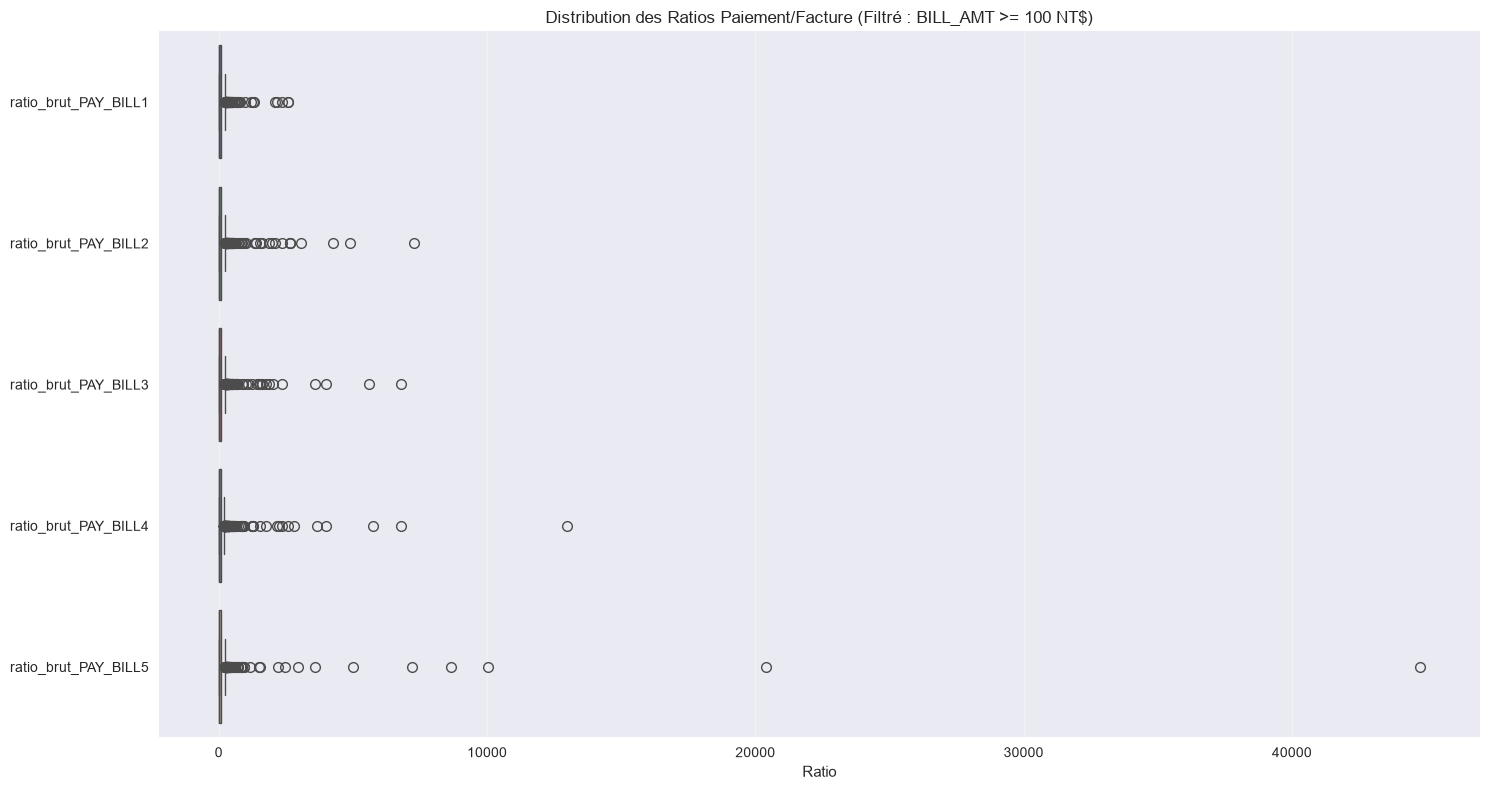

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pairs = [
    ('PAY_AMT1', 'BILL_AMT2'),
    ('PAY_AMT2', 'BILL_AMT3'),
    ('PAY_AMT3', 'BILL_AMT4'),
    ('PAY_AMT4', 'BILL_AMT5'),
    ('PAY_AMT5', 'BILL_AMT6')
]

outlier_stats = []
df_ratios_filtered = pd.DataFrame()

print("--- Analyse des Valeurs Aberrantes avec Volumétrie (BILL_AMT >= 100) ---\n")

for pay_col, bill_col in pairs:
    ratio_col = f"ratio_brut_PAY_BILL{pay_col.replace('PAY_AMT', '')}"
    
    # Masque appliqué à la facture du mois correspondant
    mask = df[bill_col] >= 100
    
    # Population initiale non nulle sur ce ratio
    raw_data = df[ratio_col].dropna()
    n_initial = len(raw_data)
    
    # Population conservée après masque (BILL_AMT >= 100)
    clean_data = df.loc[mask, ratio_col].dropna()
    n_kept = len(clean_data)
    
    # Volumétrie éliminée par le masque
    n_eliminated = n_initial - n_kept
    pct_eliminated = (n_eliminated / n_initial * 100) if n_initial > 0 else 0.0
    
    # Stockage des valeurs filtrées pour la visualisation
    df_ratios_filtered[ratio_col] = df[ratio_col].where(mask)
    
    if n_kept < 10: 
        continue
        
    lower, upper = find_outliers_stats(clean_data)
    
    # Outliers statistiques (IQR) sur la population filtrée
    outliers = clean_data[(clean_data < lower) | (clean_data > upper)]
    
    outlier_stats.append({
        'Colonne': ratio_col,
        'Lignes Initiales': n_initial,
        'Lignes Conservées': n_kept,
        'Lignes Filtrées (<100)': n_eliminated,
        '% Filtré': f"{pct_eliminated:.2f}%",
        'Aberrations (IQR)': len(outliers),
        'Borne Basse': round(lower, 2),
        'Borne Haute': round(upper, 2)
    })

# Tableau récapitulatif
df_outliers = pd.DataFrame(outlier_stats)
print(df_outliers.to_string(index=False))

# Visualisation des Boxplots (sur données filtrées)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_ratios_filtered, patch_artist=True, orient='h')
plt.title('Distribution des Ratios Paiement/Facture (Filtré : BILL_AMT >= 100 NT$)')
plt.xlabel('Ratio')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Même à 200 de cut off, 2 valeurs sortent du lot à 20 000 et 45 000%.  
Afin de vérifier la cohérence, regardons quelques lignes en détail

In [42]:
import pandas as pd
import numpy as np

# 1. Définition stricte des colonnes de ratio et de leur dénominateur BILL_AMT correspondante
paires = [
    ('ratio_brut_PAY_BILL1', 'BILL_AMT2'),
    ('ratio_brut_PAY_BILL2', 'BILL_AMT3'),
    ('ratio_brut_PAY_BILL3', 'BILL_AMT4'),
    ('ratio_brut_PAY_BILL4', 'BILL_AMT5'),
    ('ratio_brut_PAY_BILL5', 'BILL_AMT6')
]

lignes_anormales_details = []

print("--- Analyse : Ratios > 1000% avec Facture BILL_AMT >= 100 ---\n")

for col_ratio, col_bill in paires:
    if col_ratio not in df.columns or col_bill not in df.columns:
        continue
    
    # Condition 1 : Le ratio est extrêmement élevé (> 1000)
    condition_ratio = df[col_ratio] > 1000
    
    # Condition 2 : La facture associée est structurante (>= 100)
    condition_facture = df[col_bill] >= 100
    
    # Intersection stricte
    mask_anomalie = condition_ratio & condition_facture
    
    nb_cas = mask_anomalie.sum()
    
    if nb_cas > 0:
        print(f"[{col_ratio}] : {nb_cas} cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000")
        
        df_cas = df[mask_anomalie].copy()
        df_cas['Source_Ratio'] = col_ratio
        df_cas['Facture_Source'] = col_bill
        
        # Tri pour voir les plus extrêmes
        df_cas = df_cas.sort_values(by=col_ratio, ascending=False)
        
        lignes_anormales_details.append(df_cas.head(10))

# 3. Affichage Global
if lignes_anormales_details:
    df_anomalies_final = pd.concat(lignes_anormales_details).drop_duplicates()
    
    print(f"\n--- Résumé Global ---")
    print(f"Total de cas uniques identifiés : {len(df_anomalies_final)}")
    
    print(f"\n--- Les 10 lignes les plus extrêmes (Complètes) ---")
    display_data = df_anomalies_final.head(10).drop(columns=['Source_Ratio', 'Facture_Source'])
    
    # Affichage de toutes les colonnes pour vérification
    print(display_data.to_string())

else:
    print("\n--- RÉSULTAT NÉGATIF ---")
    print("Aucune ligne ne répond à la fois à : Ratio > 1000 ET BILL_AMT >= 100.")
    print("Conclusion : Les ratios > 1000% sont exclusivement liés à des factures < 100€ (micro-dettes).")
    
    # Vérification complémentaire : combien de ratios > 1000 existent sans filtre de facture ?
    total_extremes = 0
    for col_ratio, _ in paires:
        if col_ratio in df.columns:
            total_extremes += (df[col_ratio] > 1000).sum()
    
    print(f"\nTotal de ratios > 1000 sur tout le dataset (sans filtre facture) : {total_extremes}")

--- Analyse : Ratios > 1000% avec Facture BILL_AMT >= 100 ---

[ratio_brut_PAY_BILL1] : 8 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_brut_PAY_BILL2] : 17 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_brut_PAY_BILL3] : 16 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_brut_PAY_BILL4] : 16 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_brut_PAY_BILL5] : 13 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000

--- Résumé Global ---
Total de cas uniques identifiés : 48

--- Les 10 lignes les plus extrêmes (Complètes) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5
ID                                                                                                          

pas d'anomalie visible en terme métier => aucune modification à faire.  
**solution pour exploiter ces statistiques**
Appliquer un masque pour les graphiques du type BILL_AMTn >= 100
**Définition retenue** (identique à `02_01_nettoyage`, utilisée par l'EDA, Streamlit et le ML) : `ratio_PAY_BILLn` = PAY_AMTn / BILL_AMT(n+1) en %, écrêté entre 0 et 200 %, et 100 % si aucune facture n'était exigible. Plus de valeurs aberrantes ni de NaN pour le ML.  
Le ratio brut (`ratio_brut_PAY_BILLn`) ne sert qu'à l'étude des valeurs aberrantes ci-dessus.

In [43]:
# Définition unique retenue (identique à 02_01_nettoyage) : ratio_PAY_BILLn = PAY_AMTn / BILL_AMT(n+1) en %,
# écrêté entre 0 et 200 %, et 100 % si aucune facture n'était exigible (BILL_AMT(n+1) <= 0).
# Le ratio brut (ratio_brut_PAY_BILLn) ne sert qu'à l'étude des valeurs aberrantes ci-dessus.
for n in range(1, 6):
    bill = df[f'BILL_AMT{n+1}']
    ratio = (df[f'PAY_AMT{n}'] / bill.where(bill > 0) * 100).clip(lower=0, upper=200)
    df[f'ratio_PAY_BILL{n}'] = ratio.fillna(100)

def ratios_affichables(d, cols):
    """Ratios de paiement à afficher dans les graphiques : uniquement quand une facture était exigible
    (BILL_AMT(n+1) > 0). La colonne ratio_PAY_BILLn garde sa définition unique (100 % sans facture
    exigible, voir docs/colonnes_creees.md) : ce filtre ne sert qu'à l'affichage."""
    out = d[cols].copy()
    for col in cols:
        n = int(col.replace('ratio_PAY_BILL', ''))
        out[col] = out[col].where(d[f'BILL_AMT{n + 1}'] > 0)
    return out

df[[f'ratio_PAY_BILL{n}' for n in range(1, 6)]].describe().round(2)


,ratio_PAY_BILL1,ratio_PAY_BILL2,ratio_PAY_BILL3,ratio_PAY_BILL4,ratio_PAY_BILL5
count,29996.00,29996.00,29996.00,29996.00,29996.00
mean,41.19,42.13,41.23,41.21,43.85
std,45.92,46.34,46.68,46.99,47.29
min,0.00,0.00,0.00,0.00,0.00
25%,4.47,4.46,3.79,3.64,3.81
50%,10.15,10.37,8.43,7.69,9.04
75%,100.00,100.00,100.00,100.00,100.00
max,200.00,200.00,200.00,200.00,200.00


Analyse des ratios avec PAY_n <= 0 :
Statistiques pour les valeurs où PAY_n <= 0 :
        Colonne  Moyenne (PAY_n <= 0)  Minimum (PAY_n <= 0)  Médiane (PAY_n <= 0)  Maximum (PAY_n <= 0)  Nombre d'observations
ratio_PAY_BILL1                 37.88                   0.0                  9.67                 200.0                  21243
ratio_PAY_BILL2                 38.25                   0.0                  8.96                 200.0                  22223
ratio_PAY_BILL3                 35.87                   0.0                  7.07                 200.0                  22084
ratio_PAY_BILL4                 34.83                   0.0                  5.77                 200.0                  22434
ratio_PAY_BILL5                 36.50                   0.0                  6.36                 200.0                  22381


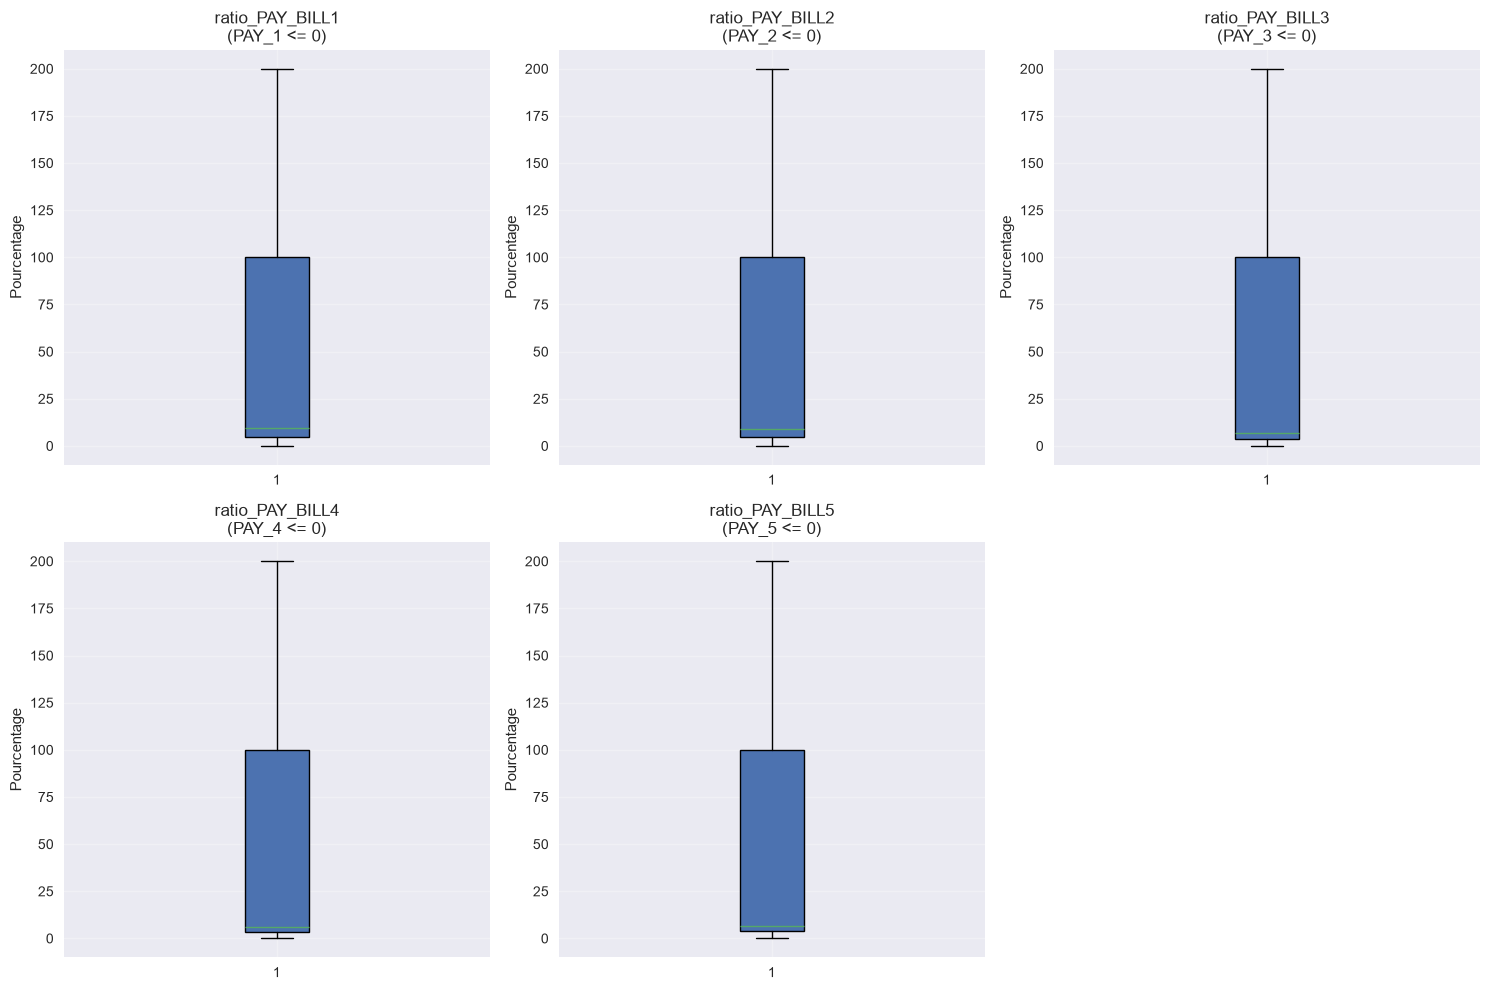

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supposons que les colonnes ratio_PAY_BILL1, etc. existent déjà
# Création de la liste des colonnes ratio existantes
ratio_columns = ['ratio_PAY_BILL1', 'ratio_PAY_BILL2', 
                 'ratio_PAY_BILL3', 'ratio_PAY_BILL4', 
                 'ratio_PAY_BILL5']
df_aff = ratios_affichables(df, ratio_columns)  # affichage : factures exigibles seulement

# Analyse statistique pour les valeurs où PAY_n <= 0
print("Analyse des ratios avec PAY_n <= 0 :")

# Création d'une liste pour stocker les résultats
results = []

for col in ratio_columns:
    # Pour chaque colonne ratio, je dois identifier la colonne PAY_n correspondante
    # Exemple : ratio_PAY_BILL1 -> PAY_n = PAY_1
    # On extrait le numéro de la colonne PAY
    pay_n_col = f"PAY_{col.replace('ratio_PAY_BILL', '')}"  # Ex: ratio_PAY_BILL1 -> PAY_1
    
    # Filtrer les données où PAY_n <= 0
    filtered_data = df_aff.loc[df[pay_n_col] <= 0, col].dropna()
    
    if len(filtered_data) > 0:
        mean_val = filtered_data.mean()
        min_val = filtered_data.min()
        median_val = filtered_data.median()
        max_val = filtered_data.max()
        count = len(filtered_data)
        
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n <= 0)': round(mean_val, 2) if not pd.isna(mean_val) else None,
            'Minimum (PAY_n <= 0)': round(min_val, 2) if not pd.isna(min_val) else None,
            'Médiane (PAY_n <= 0)': round(median_val, 2) if not pd.isna(median_val) else None,
            'Maximum (PAY_n <= 0)': round(max_val, 2) if not pd.isna(max_val) else None,
            'Nombre d\'observations': count
        })
    else:
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n <= 0)': None,
            'Minimum (PAY_n <= 0)': None,
            'Médiane (PAY_n <= 0)': None,
            'Maximum (PAY_n <= 0)': None,
            'Nombre d\'observations': 0
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Statistiques pour les valeurs où PAY_n <= 0 :")
print(results_df.to_string(index=False))

# Boxplot individuel pour chaque colonne
plt.figure(figsize=(15, 10))

for i, col in enumerate(ratio_columns):
    plt.subplot(2, 3, i+1)
    
    # Identifier la colonne PAY_n correspondante
    pay_n_col = f"PAY_{col.replace('ratio_PAY_BILL', '')}"  # Ex: ratio_PAY_BILL1 -> PAY_1
    
    # Filtrer les données où PAY_n <= 0
    filtered_data = df_aff.loc[df[pay_n_col] <= 0, col].dropna().dropna()
    
    if len(filtered_data) > 0:
        plt.boxplot(filtered_data, patch_artist=True)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} <= 0)')
        plt.ylabel('Pourcentage')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Pas de données\n(PAY_n > 0)', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} <= 0)')

plt.tight_layout()
plt.show()



Ces mesures nous apprennent qu'il n'est pas possible de trouver un seuil de remboursement à partir duquel la banque considère que le client est à jour

Analyse des ratios avec PAY_n > 0 :

Statistiques pour les valeurs où PAY_n > 0 :
        Colonne  Moyenne (PAY_n > 0)  Minimum (PAY_n > 0)  Médiane (PAY_n > 0)  Maximum (PAY_n > 0)  Nombre d'observations
ratio_PAY_BILL1                20.36                  0.0                 4.51                200.0                   5580
ratio_PAY_BILL2                14.40                  0.0                 4.52                200.0                   4248
ratio_PAY_BILL3                14.26                  0.0                 3.92                200.0                   4042
ratio_PAY_BILL4                11.41                  0.0                 3.76                200.0                   3401
ratio_PAY_BILL5                 9.44                  0.0                 3.87                200.0                   2907


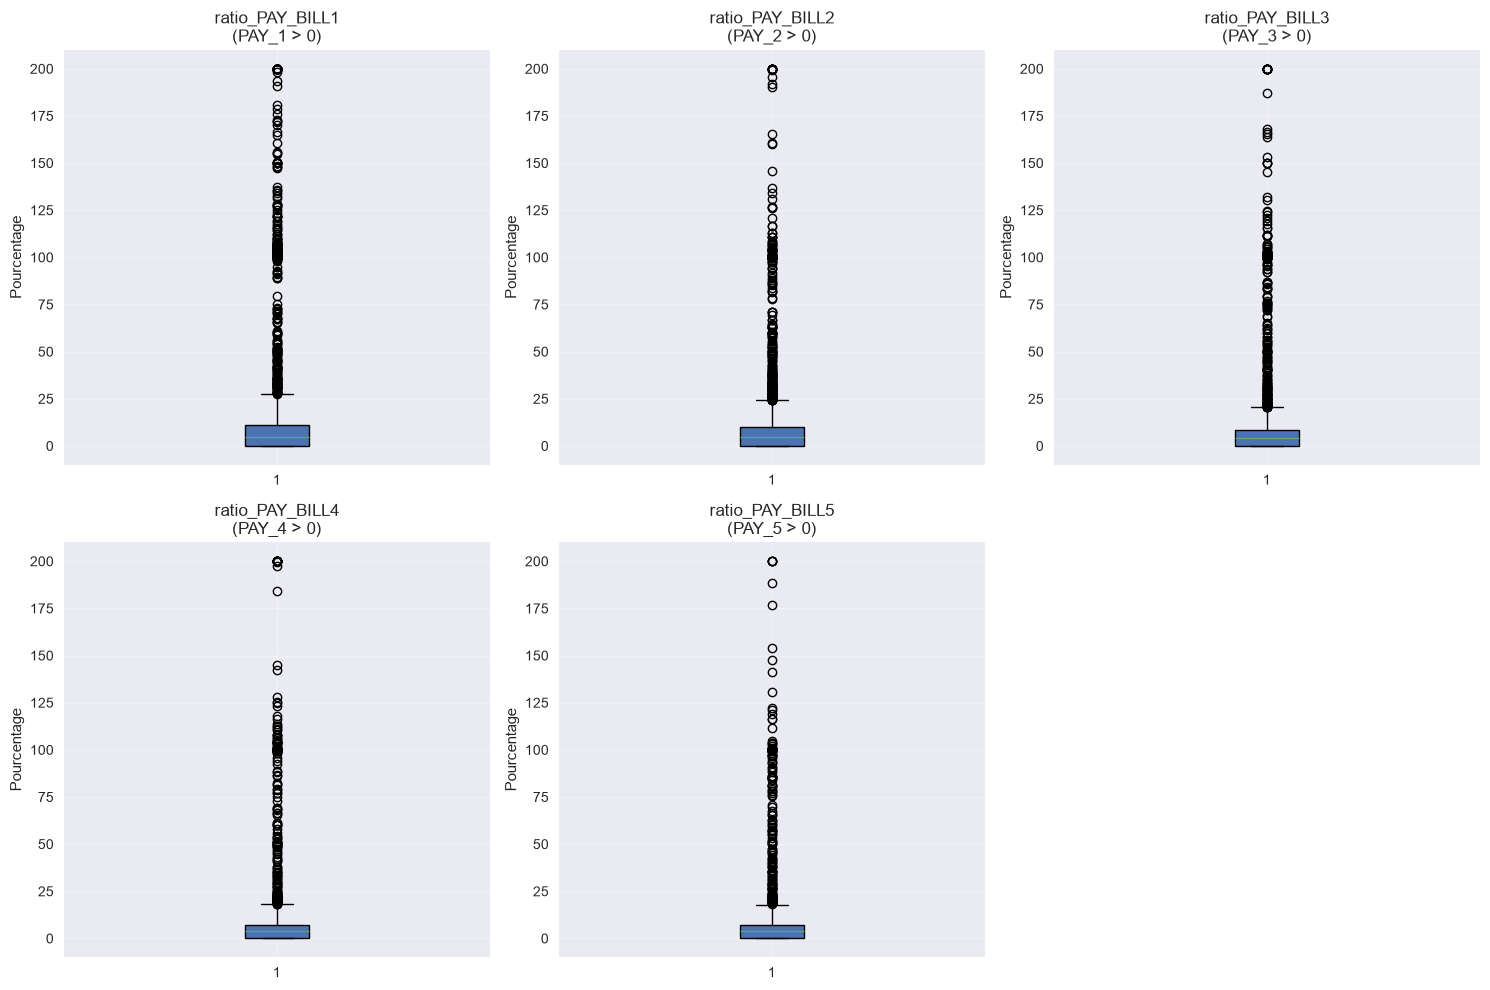

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Définition des colonnes ratio existantes
ratio_columns = ['ratio_PAY_BILL1', 'ratio_PAY_BILL2', 
                 'ratio_PAY_BILL3', 'ratio_PAY_BILL4', 
                 'ratio_PAY_BILL5']
df_aff = ratios_affichables(df, ratio_columns)  # affichage : factures exigibles seulement

# Analyse statistique pour les valeurs où PAY_n > 0
print("Analyse des ratios avec PAY_n > 0 :\n")

results = []

for col in ratio_columns:
    # Identification de la colonne PAY_n correspondante (ex: PAY_1, PAY_2...)
    pay_n_col = f"PAY_{col.replace('ratio_PAY_BILL', '')}"  # Ex: ratio_PAY_BILL1 -> PAY_1
    
    # Filtrer les données où PAY_n > 0 (Attention à l'espace dans '> 0')
    filtered_data = df_aff.loc[df[pay_n_col] > 0, col].dropna()
    
    if len(filtered_data) > 0:
        mean_val = filtered_data.mean()
        min_val = filtered_data.min()
        median_val = filtered_data.median()
        max_val = filtered_data.max()
        count = len(filtered_data)
        
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n > 0)': round(mean_val, 2) if not pd.isna(mean_val) else None,
            'Minimum (PAY_n > 0)': round(min_val, 2) if not pd.isna(min_val) else None,
            'Médiane (PAY_n > 0)': round(median_val, 2) if not pd.isna(median_val) else None,
            'Maximum (PAY_n > 0)': round(max_val, 2) if not pd.isna(max_val) else None,
            'Nombre d\'observations': count
        })
    else:
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n > 0)': None,
            'Minimum (PAY_n > 0)': None,
            'Médiane (PAY_n > 0)': None,
            'Maximum (PAY_n > 0)': None,
            'Nombre d\'observations': 0
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Statistiques pour les valeurs où PAY_n > 0 :")
print(results_df.to_string(index=False))

# Boxplot individuel pour chaque colonne
plt.figure(figsize=(15, 10))

for i, col in enumerate(ratio_columns):
    plt.subplot(2, 3, i+1)
    
    # Identifier la colonne PAY_n correspondante
    pay_n_col = f"PAY_{col.replace('ratio_PAY_BILL', '')}"  # Ex: ratio_PAY_BILL1 -> PAY_1
    
    # Filtrer les données où PAY_n > 0 et retirer les NaN du ratio
    filtered_data = df_aff.loc[df[pay_n_col] > 0, col].dropna().dropna()
    
    if len(filtered_data) > 0:
        plt.boxplot(filtered_data, patch_artist=True)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} > 0)')
        plt.ylabel('Pourcentage')
        plt.grid(True, alpha=0.3)
    else:
        # Correction du texte affiché quand il n'y a pas de données
        plt.text(0.5, 0.5, 'Pas de données\n(PAY_n <= 0)', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} > 0)')

plt.tight_layout()
plt.show()

Le ratio de remboursement baisse drastiquement pour les dossiers toppés avec incidents

--- Analyse Focus Zone 0-20% ---
Distribution par Bucket (0-20%) :

Condition  PAY <= 0  PAY > 0
Bucket                      
[0, 1)         5625     6765
[1, 2)          568      150
[2, 3)         2913      343
[3, 4)        19840     2605
[4, 5)        13843     2389
[5, 6)         6650     1015
[6, 7)         3756      645
[7, 8)         3351      870
[8, 9)         2533      732
[9, 10)        1873      421
[10, 11)       1703      306
[11, 12)       1354      277
[12, 13)       1129      215
[13, 14)        942      177
[14, 15)        870      161


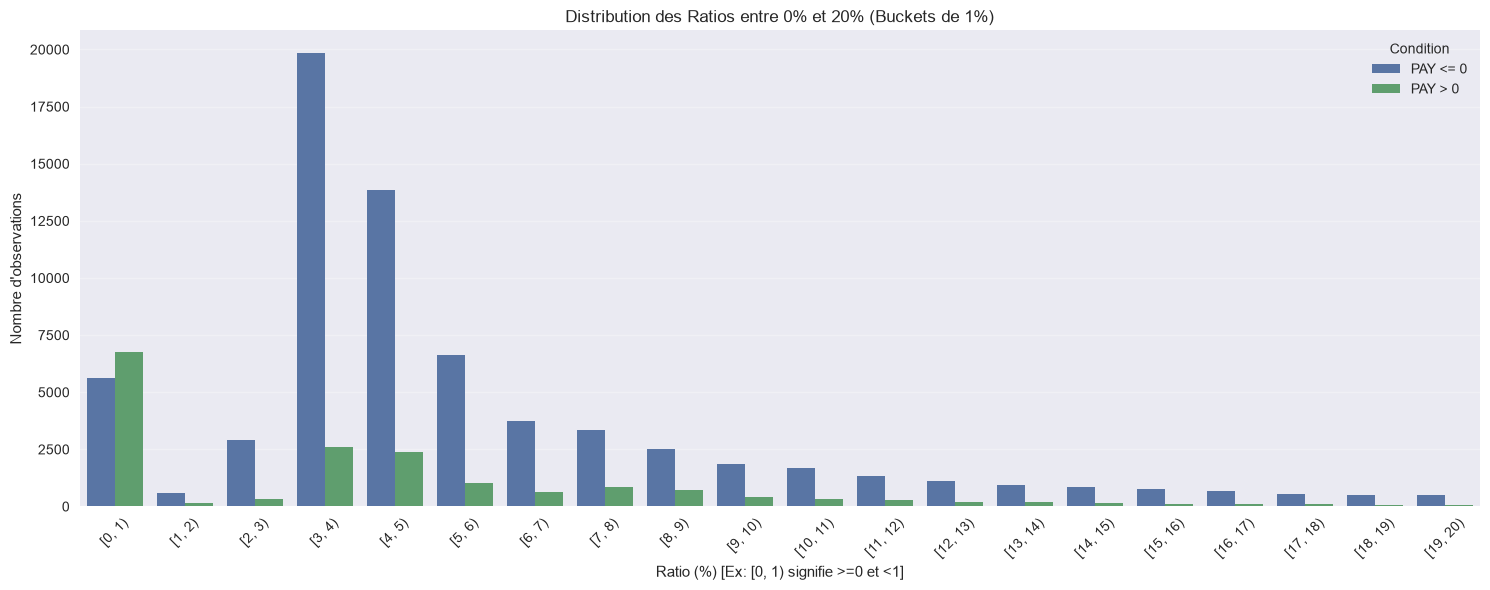


Pourcentage global PAY > 0 avec Ratio >= 20% : 13.11%
Pourcentage global PAY <= 0 avec Ratio >= 20% : 36.64%


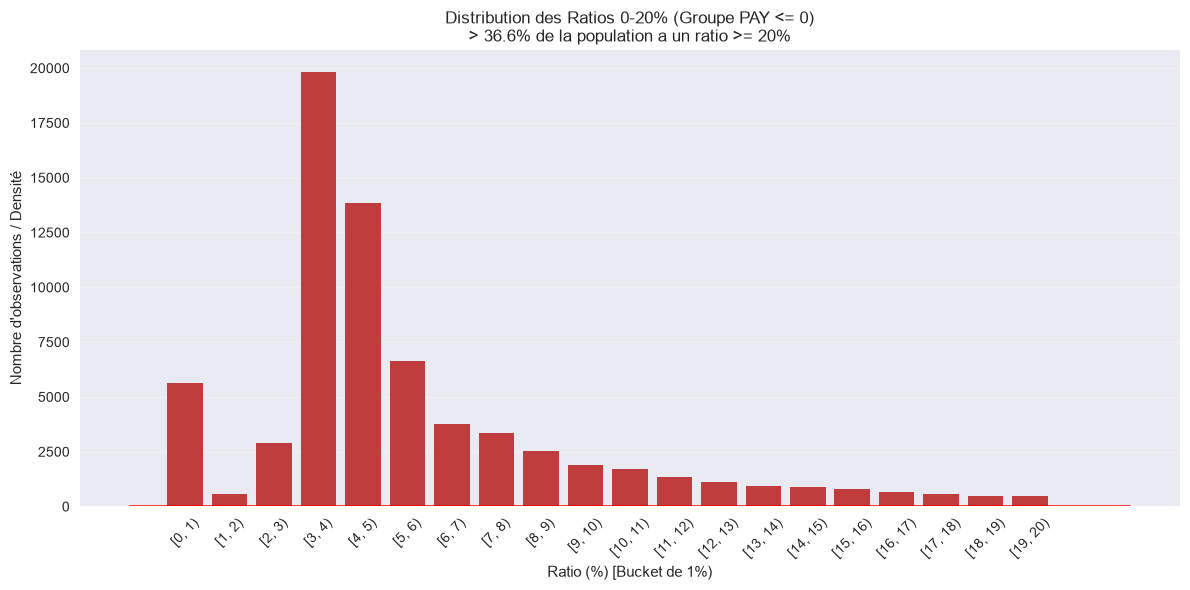

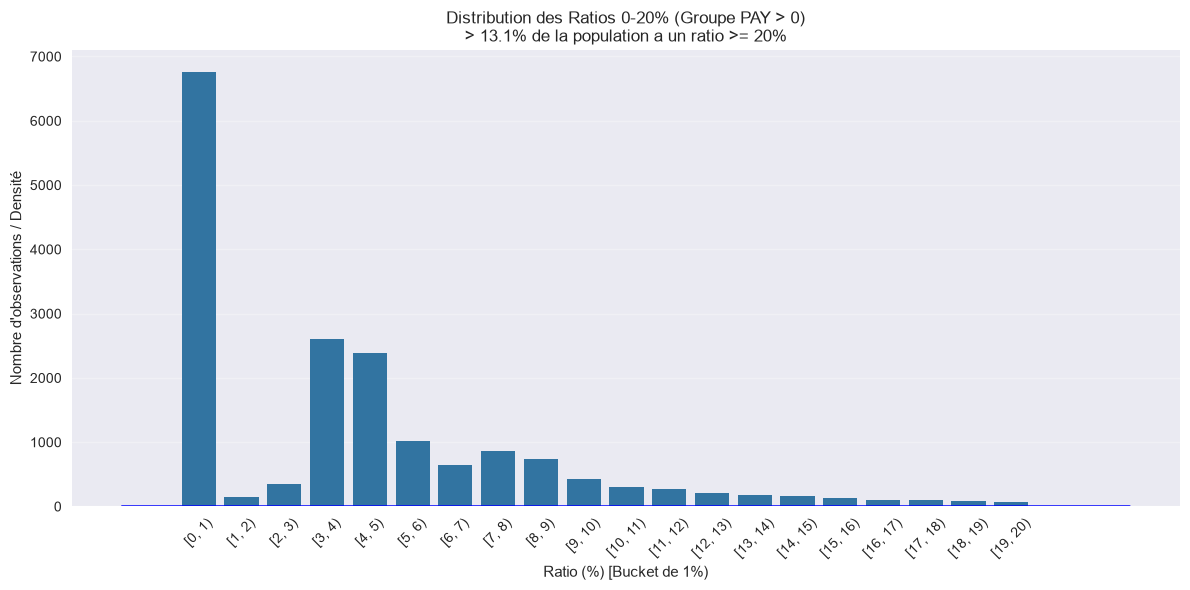

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes définies
ratio_columns = [
    'ratio_PAY_BILL1', 
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# On prépare une liste plate pour stocker toutes les lignes de données
data_all = []
print("--- Analyse Focus Zone 0-20% ---")

for col_ratio in ratio_columns:
    # 1. Identifier la colonne PAY associée
    pay_part = col_ratio.split('_to_')[0] 
    base_pay = pay_part.replace('ratio_', '') 
    n = base_pay.replace('PAY_BILL', '') 
    
    # On construit le nom de la colonne PAY correspondante (ex: 'PAY1')
    col_pay = f"PAY_{n}" 
    
    # Vérification de sécurité avec fallback
    if col_pay not in df.columns:
        col_pay_fallback = f"PAY_AMT{n}"
        if col_pay_fallback in df.columns:
            col_pay = col_pay_fallback
        else:
            print(f"Avertissement: Colonne {col_pay} et {col_pay_fallback} non trouvées pour {col_ratio}")
            continue

    # 2. Extraction des données
    bill_col_target = f'BILL_AMT{int(n)+1}'
    
    # On considère le ratio valide si Bill > 0
    mask_valid = df[col_ratio].notna() & (df[bill_col_target] > 0)
    valid_ratios = df.loc[mask_valid, col_ratio].dropna()
    
    if len(valid_ratios) == 0:
        continue

    # 3. Filtre de la zone d'intérêt (0% à 20%)
    mask_zone = (valid_ratios >= 0) & (valid_ratios < 20)
    ratios_in_zone = valid_ratios[mask_zone]
    
    if len(ratios_in_zone) == 0:
        continue
        
    # 4. Condition sur le paiement PAY_n
    pay_values = df.loc[valid_ratios.index, col_pay]
    
    for is_positive in [True, False]:
        if is_positive:
            cond_name = "PAY > 0"
            cond_mask = pay_values > 0
        else:
            cond_name = "PAY <= 0"
            cond_mask = pay_values <= 0
            
        data_cond = ratios_in_zone[cond_mask]
        
        if len(data_cond) > 0:
            # Création des buckets de 1%
            bins_edges = np.arange(0, 21, 1) 
            buckets = pd.cut(data_cond, bins=bins_edges, right=False, include_lowest=True)
            
            df_temp = pd.DataFrame({
                'Ratio_Value': data_cond.values,
                'Bucket': buckets.astype(str),
                'Condition': cond_name
            })
            data_all.append(df_temp)

# --- Traitement Global et Premier Graphique (Non modifié) ---
if not data_all:
    print("Aucune donnée trouvée dans la zone 0-20%.")
else:
    df_all_buckets = pd.concat(data_all, ignore_index=True)
    
    # Définition de l'ordre explicite des catégories
    levels = [f"[{i}, {i+1})" for i in range(0, 20)]
    df_all_buckets['Bucket'] = pd.Categorical(df_all_buckets['Bucket'], categories=levels, ordered=True)

    # Tableau récapitulatif
    df_counts = df_all_buckets.groupby(['Bucket', 'Condition']).size().unstack(fill_value=0)
    print("Distribution par Bucket (0-20%) :\n")
    print(df_counts.head(15)) 

    # --- GRAPHIQUE 1 : Barplot global 0-20% (PAY > 0 ET PAY <= 0 confondus) ---
    plt.figure(figsize=(15, 6))
    counts = df_all_buckets.value_counts(['Bucket', 'Condition'])
    
    sns.barplot(
        x=counts.index.get_level_values('Bucket'), 
        y=counts.values, 
        hue=counts.index.get_level_values('Condition')
    )
    
    plt.title('Distribution des Ratios entre 0% et 20% (Buckets de 1%)')
    plt.xlabel('Ratio (%) [Ex: [0, 1) signifie >=0 et <1]')
    plt.ylabel('Nombre d\'observations')
    plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45) 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- GRAPHIQUES 2 & 3 : Séparés par Condition avec Statistiques > 20% ---
    
    # Réinitialisation pour cumul brut
    cum_high_pos = 0
    cum_total_pos = 0
    cum_high_neg = 0
    cum_total_neg = 0

    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_BILL', '') 
        col_pay_name = f"PAY_{n_str}"
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio]
            pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
            
            # Groupe PAY > 0
            mask_pos = pay_vals > 0
            cum_total_pos += mask_pos.sum()
            # On compte ceux qui sont >= 20
            vals_pos = valid_ratios_all[mask_pos]
            cum_high_pos += vals_pos[(vals_pos >= 20)].notna().sum()

            # Groupe PAY <= 0
            mask_neg = pay_vals <= 0
            cum_total_neg += mask_neg.sum()
            vals_neg = valid_ratios_all[mask_neg]
            cum_high_neg += vals_neg[(vals_neg >= 20)].notna().sum()

    # Pourcentages finaux
    final_pct_high_pos = (cum_high_pos / cum_total_pos * 100) if cum_total_pos > 0 else 0
    final_pct_high_neg = (cum_high_neg / cum_total_neg * 100) if cum_total_neg > 0 else 0

    print(f"\nPourcentage global PAY > 0 avec Ratio >= 20% : {final_pct_high_pos:.2f}%")
    print(f"Pourcentage global PAY <= 0 avec Ratio >= 20% : {final_pct_high_neg:.2f}%")

    # --- GRAPHIQUE 2 : Zoom pour PAY <= 0 ---
    df_neg = df_all_buckets[df_all_buckets['Condition'] == 'PAY <= 0'].copy()
    if len(df_neg) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_neg['Bucket'] = pd.Categorical(df_neg['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_neg = df_neg.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_neg.index.get_level_values('Bucket'), 
            y=counts_neg.values, 
            color='#d62728' # Rouge
        )
        
        # Courbe KDE sur les données brutes du groupe
        if len(df_neg) > 0:
            sns.kdeplot(data=df_neg[df_neg['Ratio_Value'] < 20], x='Ratio_Value', color='red')

        plt.title(f'Distribution des Ratios 0-20% (Groupe PAY <= 0)\n> {final_pct_high_neg:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Pas de données dans le groupe PAY <= 0 pour afficher le graphique.")

    # --- GRAPHIQUE 3 : Zoom pour PAY > 0 ---
    df_pos = df_all_buckets[df_all_buckets['Condition'] == 'PAY > 0'].copy()
    if len(df_pos) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_pos['Bucket'] = pd.Categorical(df_pos['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_pos = df_pos.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_pos.index.get_level_values('Bucket'), 
            y=counts_pos.values, 
            color='#1f77b4' # Bleu
        )
        
        # Courbe KDE sur les données brutes du groupe
        if len(df_pos) > 0:
            sns.kdeplot(data=df_pos[df_pos['Ratio_Value'] < 20], x='Ratio_Value', color='blue')

        plt.title(f'Distribution des Ratios 0-20% (Groupe PAY > 0)\n> {final_pct_high_pos:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Pas de données dans le groupe PAY > 0 pour afficher le graphique.")

J'exclue ratio_PAY_BILL1 car la codification 1 pollue cette colonne

--- Analyse Focus Zone 0-20% ---
Distribution par Bucket (0-20%) :

Condition  PAY <= 0  PAY > 0
Bucket                      
[0, 1)         5221     4739
[1, 2)          560      105
[2, 3)         2723      267
[3, 4)        17222     2300
[4, 5)        10541     1699
[5, 6)         5073      686
[6, 7)         2869      453
[7, 8)         2628      691
[8, 9)         1932      576
[9, 10)        1389      301
[10, 11)       1313      236
[11, 12)       1021      200
[12, 13)        853      148
[13, 14)        720      133
[14, 15)        650      116


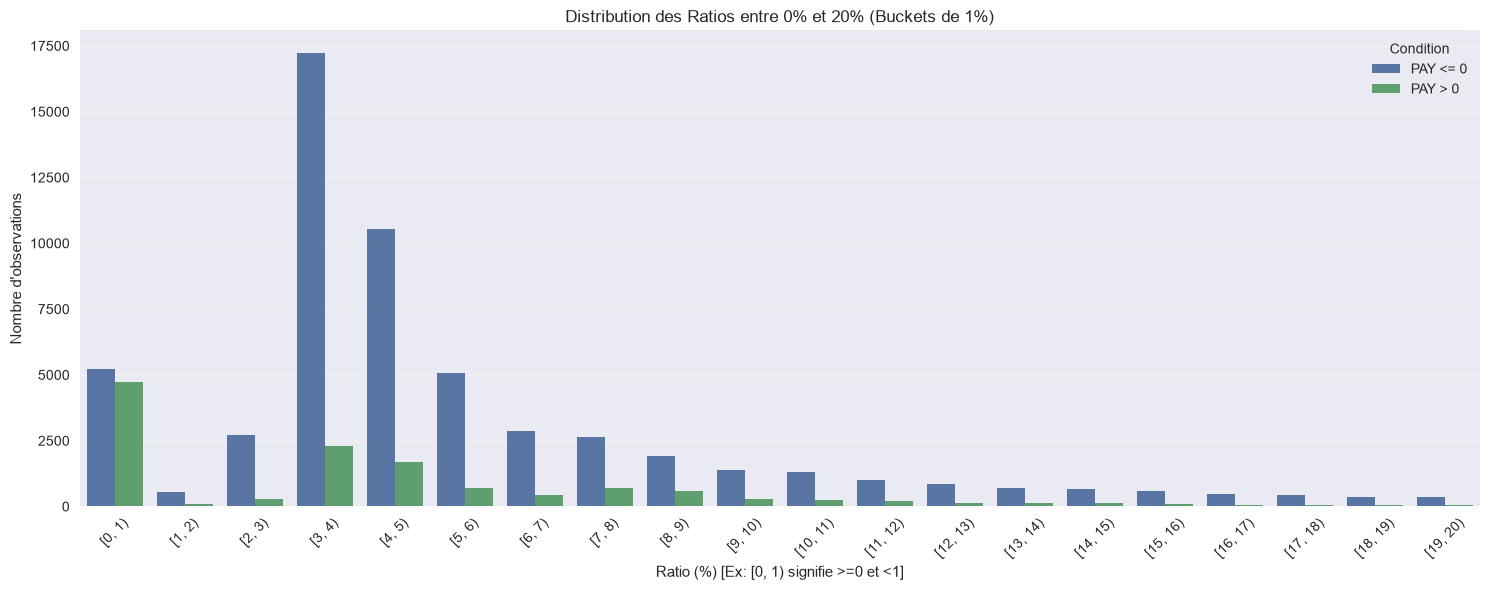


Pourcentage global PAY > 0 avec Ratio >= 20% : 11.15%
Pourcentage global PAY <= 0 avec Ratio >= 20% : 36.14%


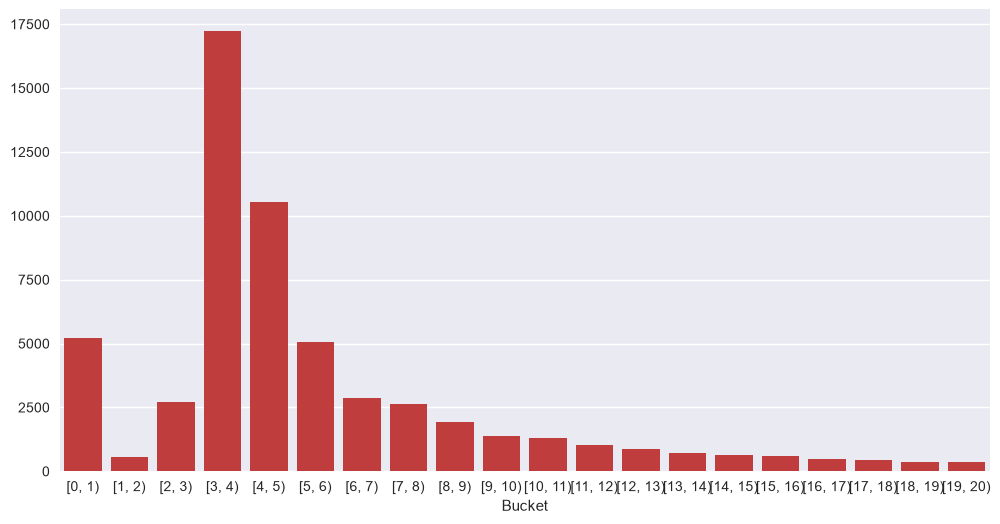

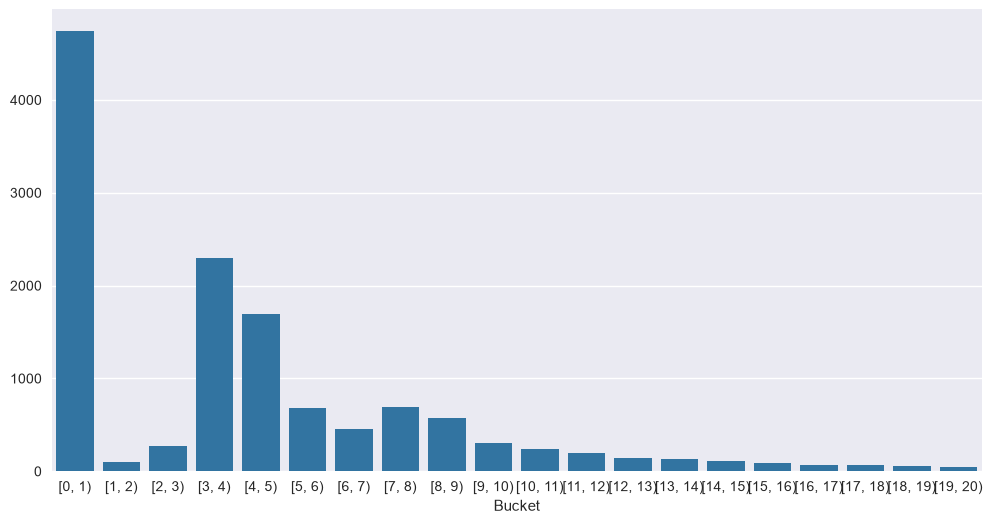

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes définies
ratio_columns = [
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# On prépare une liste plate pour stocker toutes les lignes de données
data_all = []
print("--- Analyse Focus Zone 0-20% ---")

for col_ratio in ratio_columns:
    # 1. Identifier la colonne PAY associée
    pay_part = col_ratio.split('_to_')[0] 
    base_pay = pay_part.replace('ratio_', '') 
    n = base_pay.replace('PAY_BILL', '') 
    
    # On construit le nom de la colonne PAY correspondante (ex: 'PAY1')
    col_pay = f"PAY_{n}" 
    
    # Vérification de sécurité avec fallback
    if col_pay not in df.columns:
        col_pay_fallback = f"PAY_AMT{n}"
        if col_pay_fallback in df.columns:
            col_pay = col_pay_fallback
        else:
            print(f"Avertissement: Colonne {col_pay} et {col_pay_fallback} non trouvées pour {col_ratio}")
            continue

    # 2. Extraction des données
    bill_col_target = f'BILL_AMT{int(n)+1}'
    
    # On considère le ratio valide si Bill > 0
    mask_valid = df[col_ratio].notna() & (df[bill_col_target] > 0)
    valid_ratios = df.loc[mask_valid, col_ratio].dropna()
    
    if len(valid_ratios) == 0:
        continue

    # 3. Filtre de la zone d'intérêt (0% à 20%)
    mask_zone = (valid_ratios >= 0) & (valid_ratios < 20)
    ratios_in_zone = valid_ratios[mask_zone]
    
    if len(ratios_in_zone) == 0:
        continue
        
    # 4. Condition sur le paiement PAY_n
    pay_values = df.loc[valid_ratios.index, col_pay]
    
    for is_positive in [True, False]:
        if is_positive:
            cond_name = "PAY > 0"
            cond_mask = pay_values > 0
        else:
            cond_name = "PAY <= 0"
            cond_mask = pay_values <= 0
            
        data_cond = ratios_in_zone[cond_mask]
        
        if len(data_cond) > 0:
            # Création des buckets de 1%
            bins_edges = np.arange(0, 21, 1) 
            buckets = pd.cut(data_cond, bins=bins_edges, right=False, include_lowest=True)
            
            df_temp = pd.DataFrame({
                'Ratio_Value': data_cond.values,
                'Bucket': buckets.astype(str),
                'Condition': cond_name
            })
            data_all.append(df_temp)

# --- Traitement Global et Premier Graphique (Non modifié) ---
if not data_all:
    print("Aucune donnée trouvée dans la zone 0-20%.")
else:
    df_all_buckets = pd.concat(data_all, ignore_index=True)
    
    # Définition de l'ordre explicite des catégories
    levels = [f"[{i}, {i+1})" for i in range(0, 20)]
    df_all_buckets['Bucket'] = pd.Categorical(df_all_buckets['Bucket'], categories=levels, ordered=True)

    # Tableau récapitulatif
    df_counts = df_all_buckets.groupby(['Bucket', 'Condition']).size().unstack(fill_value=0)
    print("Distribution par Bucket (0-20%) :\n")
    print(df_counts.head(15)) 

    # --- GRAPHIQUE 1 : Barplot global 0-20% (PAY > 0 ET PAY <= 0 confondus) ---
    plt.figure(figsize=(15, 6))
    counts = df_all_buckets.value_counts(['Bucket', 'Condition'])
    
    sns.barplot(
        x=counts.index.get_level_values('Bucket'), 
        y=counts.values, 
        hue=counts.index.get_level_values('Condition')
    )
    
    plt.title('Distribution des Ratios entre 0% et 20% (Buckets de 1%)')
    plt.xlabel('Ratio (%) [Ex: [0, 1) signifie >=0 et <1]')
    plt.ylabel('Nombre d\'observations')
    plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45) 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- GRAPHIQUES 2 & 3 : Séparés par Condition avec Statistiques > 20% ---
    
    # Réinitialisation pour cumul brut
    cum_high_pos = 0
    cum_total_pos = 0
    cum_high_neg = 0
    cum_total_neg = 0

    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_BILL', '') 
        col_pay_name = f"PAY_{n_str}"
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio]
            pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
            
            # Groupe PAY > 0
            mask_pos = pay_vals > 0
            cum_total_pos += mask_pos.sum()
            # On compte ceux qui sont >= 20
            vals_pos = valid_ratios_all[mask_pos]
            cum_high_pos += vals_pos[(vals_pos >= 20)].notna().sum()

            # Groupe PAY <= 0
            mask_neg = pay_vals <= 0
            cum_total_neg += mask_neg.sum()
            vals_neg = valid_ratios_all[mask_neg]
            cum_high_neg += vals_neg[(vals_neg >= 20)].notna().sum()

    # Pourcentages finaux
    final_pct_high_pos = (cum_high_pos / cum_total_pos * 100) if cum_total_pos > 0 else 0
    final_pct_high_neg = (cum_high_neg / cum_total_neg * 100) if cum_total_neg > 0 else 0

    print(f"\nPourcentage global PAY > 0 avec Ratio >= 20% : {final_pct_high_pos:.2f}%")
    print(f"Pourcentage global PAY <= 0 avec Ratio >= 20% : {final_pct_high_neg:.2f}%")

    # --- GRAPHIQUE 2 : Zoom pour PAY <= 0 ---
    df_neg = df_all_buckets[df_all_buckets['Condition'] == 'PAY <= 0'].copy()
    if len(df_neg) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_neg['Bucket'] = pd.Categorical(df_neg['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_neg = df_neg.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_neg.index.get_level_values('Bucket'), 
            y=counts_neg.values, 
            color='#d62728' # Rouge
        )
        
    # --- GRAPHIQUE 3 : Zoom pour PAY > 0 ---
    df_pos = df_all_buckets[df_all_buckets['Condition'] == 'PAY > 0'].copy()
    if len(df_pos) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_pos['Bucket'] = pd.Categorical(df_pos['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_pos = df_pos.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_pos.index.get_level_values('Bucket'), 
            y=counts_pos.values, 
            color='#1f77b4' # Bleu
        )


C'est intéressant mais on regarde également le ratio payé par des gens qui sont suceptibles d'agraver ou de diminuer leur retard.  
Tentons de regarder le ratio selon que les gens n'agravent pas leur retard ou l'agravent

--- Analyse Focus Zone 0-20% (Comparaison PAY_n vs PAY_{n+1}) ---

% Global Groupe 'Stagnant/Baisse' >= 20% : 33.37%
% Global Groupe 'Hausse' >= 20%           : 20.70%


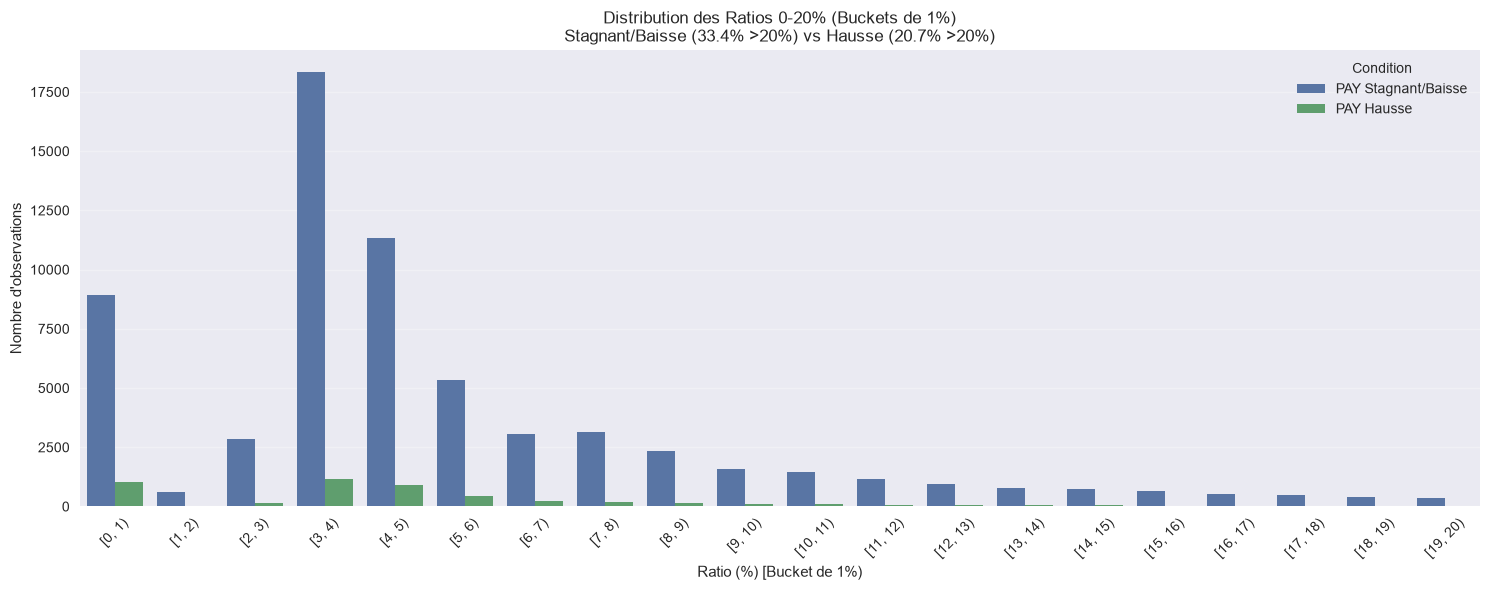

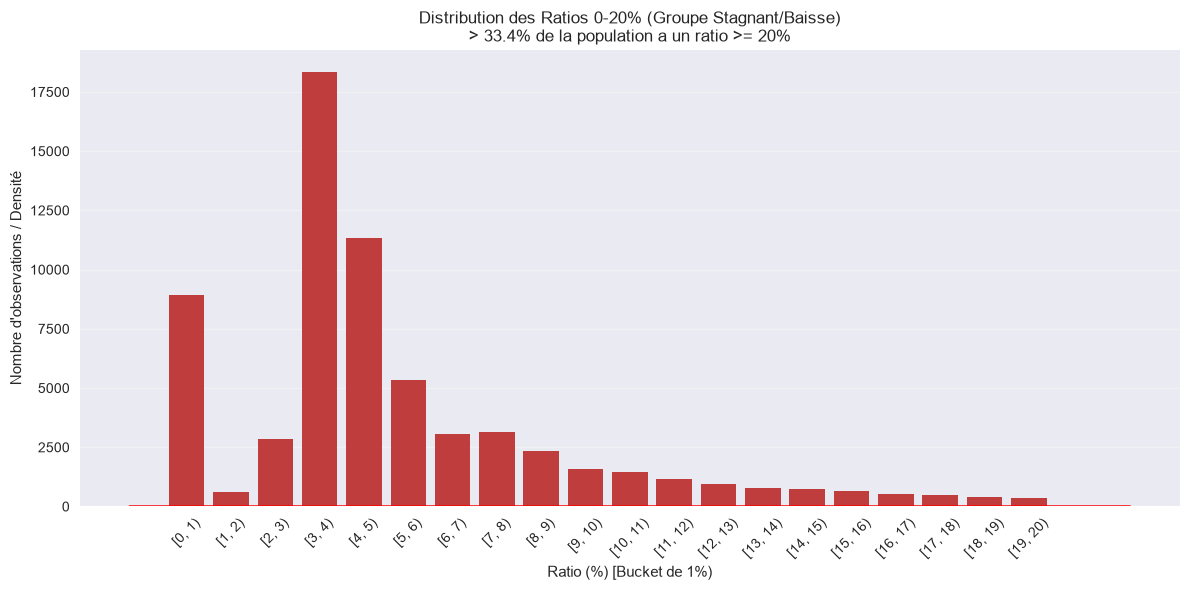

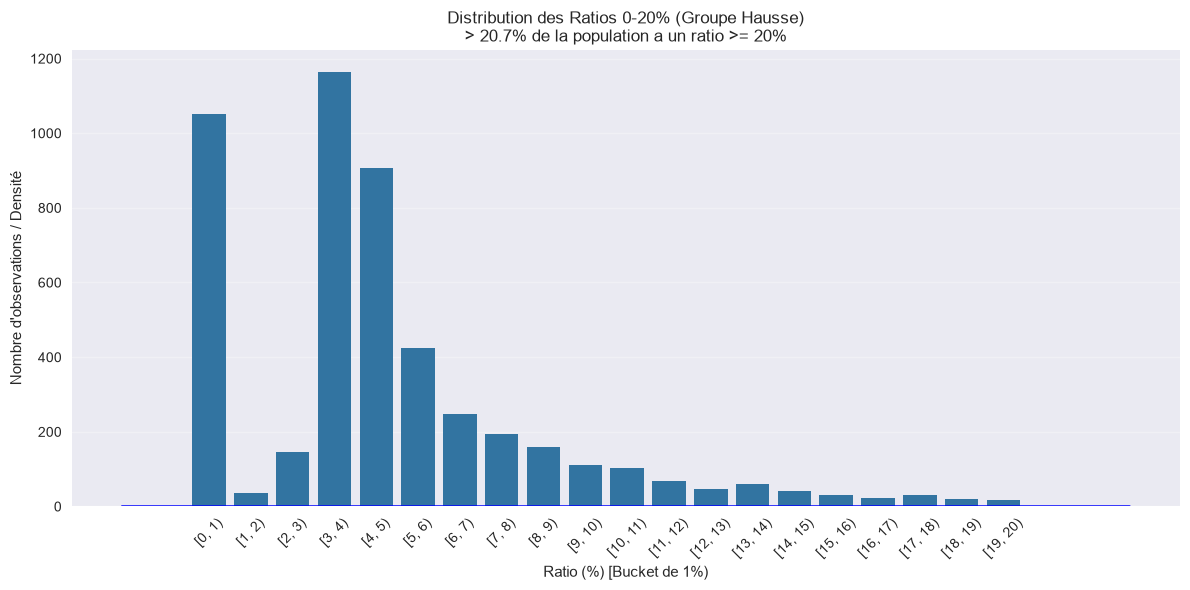

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes définies
ratio_columns = [
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

data_all = []
print("--- Analyse Focus Zone 0-20% (Comparaison PAY_n vs PAY_{n+1}) ---")

# Pour calculer le % global > 20% par groupe à la fin
stats_globales = {
    'PAY Stagnant/Baisse': {'total': 0, 'high': 0},
    'PAY Hausse': {'total': 0, 'high': 0}
}

for col_ratio in ratio_columns:
    # 1. Identifier la colonne PAY associée (PAY_n)
    pay_part = col_ratio.split('_to_')[0] 
    base_pay = pay_part.replace('ratio_', '') 
    n_str = base_pay.replace('PAY_BILL', '') 
    
    col_pay_n = f"PAY_{n_str}"
    if col_pay_n not in df.columns:
        col_pay_n = f"PAY_AMT{n_str}" # Fallback
    
    if col_pay_n not in df.columns:
        continue

    # 2. Identifier la colonne PAY_{n+1}
    n_next = int(n_str) + 1
    col_pay_next = f"PAY_{n_next}"
    
    if col_pay_next not in df.columns:
        col_pay_next_fallback = f"PAY_AMT{n_next}"
        if col_pay_next_fallback in df.columns:
            col_pay_next = col_pay_next_fallback
        else:
            continue # Si la colonne suivante n'existe pas, on passe cette boucle

    # 3. Extraction : On ne garde que les ratios qui existent (non-NaN)
    mask_valid = df[col_ratio].notna() & (df[f'BILL_AMT{int(n_str) + 1}'] > 0)  # affichage : factures exigibles seulement
    df_subset = df[mask_valid]
    
    if len(df_subset) == 0:
        continue

    ratios = df_subset[col_ratio]
    pay_n_vals = df_subset[col_pay_n]
    pay_next_vals = df_subset[col_pay_next]

    # --- Logique de groupement dynamique ---
    # On ne compare que si PAY_{n+1} existe aussi (sinon pas de comparaison possible)
    valid_dynamic_mask = pay_next_vals.notna()
    
    pay_n_comp = pay_n_vals[valid_dynamic_mask]
    pay_next_comp = pay_next_vals[valid_dynamic_mask]
    ratios_comp = ratios[valid_dynamic_mask]

    # Groupe A : STAGNANT / BAISSE (PAY_n <= 0 OU PAY_n <= PAY_{n+1})
    mask_stagnant = (pay_n_comp <= 0) | (pay_n_comp <= pay_next_comp)
    
    # Groupe B : HAUSSE (PAY_n > 0 ET PAY_n > PAY_{n+1})
    mask_hausse = (pay_n_comp > 0) & (pay_n_comp > pay_next_comp)

    # --- Stats Globales pour le % > 20% (sur tout le groupe, pas juste < 20%) ---
    stats_globales['PAY Stagnant/Baisse']['total'] += mask_stagnant.sum()
    stats_globales['PAY Stagnant/Baisse']['high'] += ratios_comp[mask_stagnant][ratios_comp[mask_stagnant] >= 20].notna().sum()
    
    stats_globales['PAY Hausse']['total'] += mask_hausse.sum()
    stats_globales['PAY Hausse']['high'] += ratios_comp[mask_hausse][ratios_comp[mask_hausse] >= 20].notna().sum()

    # --- Filtrage Zone [0, 20%) pour les graphiques ---
    
    def process_group(ratios_grp, cond_name):
        if len(ratios_grp) == 0:
            return None
        
        # Filtre zone 0-20
        mask_zone = (ratios_grp >= 0) & (ratios_grp < 20)
        vals_in_zone = ratios_grp[mask_zone]
        
        if len(vals_in_zone) == 0:
            return None
        
        bins_edges = np.arange(0, 21, 1) 
        buckets = pd.cut(vals_in_zone, bins=bins_edges, right=False, include_lowest=True)
        
        # On retourne un dataframe propre pour que seaborn soit content
        df_res = pd.DataFrame({
            'Bucket': buckets.astype(str),
            'Condition': cond_name,
            'Ratio_Value': vals_in_zone.values
        })
        return df_res

    df_stag = process_group(ratios_comp[mask_stagnant], "PAY Stagnant/Baisse")
    if df_stag is not None:
        data_all.append(df_stag)

    df_haut = process_group(ratios_comp[mask_hausse], "PAY Hausse")
    if df_haut is not None:
        data_all.append(df_haut)

# --- Calculs finaux des % > 20% ---
pct_stag_gt_20 = (stats_globales['PAY Stagnant/Baisse']['high'] / stats_globales['PAY Stagnant/Baisse']['total'] * 100) if stats_globales['PAY Stagnant/Baisse']['total'] > 0 else 0
pct_haut_gt_20 = (stats_globales['PAY Hausse']['high'] / stats_globales['PAY Hausse']['total'] * 100) if stats_globales['PAY Hausse']['total'] > 0 else 0

print(f"\n% Global Groupe 'Stagnant/Baisse' >= 20% : {pct_stag_gt_20:.2f}%")
print(f"% Global Groupe 'Hausse' >= 20%           : {pct_haut_gt_20:.2f}%")

# --- Graphiques ---

if not data_all:
    print("Aucune donnée dans la zone 0-20%.")
else:
    df_all_buckets = pd.concat(data_all, ignore_index=True)
    levels = [f"[{i}, {i+1})" for i in range(0, 20)]
    df_all_buckets['Bucket'] = pd.Categorical(df_all_buckets['Bucket'], categories=levels, ordered=True)

    # GRAPHIQUE 1 : Global (Les deux groupes comparés)
    plt.figure(figsize=(15, 6))
    
    # On utilise value_counts pour avoir un comptage propre par bucket et condition
    counts = df_all_buckets.value_counts(['Bucket', 'Condition'])
    
    sns.barplot(
        x=counts.index.get_level_values('Bucket'), 
        y=counts.values, 
        hue=counts.index.get_level_values('Condition') # Ici c'est OK car on passe le dataframe complet via index
    )
    plt.title(f'Distribution des Ratios 0-20% (Buckets de 1%)\nStagnant/Baisse ({pct_stag_gt_20:.1f}% >20%) vs Hausse ({pct_haut_gt_20:.1f}% >20%)')
    plt.xlabel('Ratio (%) [Bucket de 1%)')
    plt.ylabel('Nombre d\'observations')
    plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45) 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # GRAPHIQUE 2 : Zoom Stagnant/Baisse
    df_stag_only = df_all_buckets[df_all_buckets['Condition'] == "PAY Stagnant/Baisse"]
    
    if len(df_stag_only) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_stag_only['Bucket'] = pd.Categorical(df_stag_only['Bucket'], categories=levels, ordered=True)
        
        plt.figure(figsize=(12, 6))
        
        # Comptage propre pour le barplot
        counts_neg = df_stag_only.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_neg.index.get_level_values('Bucket'), 
            y=counts_neg.values, 
            color='#d62728'
        )
        
        # KDE sur les valeurs brutes de ce groupe (fibrées à < 20)
        sns.kdeplot(data=df_stag_only[df_stag_only['Ratio_Value'] < 20], x='Ratio_Value', color='red')
        
        plt.title(f'Distribution des Ratios 0-20% (Groupe Stagnant/Baisse)\n> {pct_stag_gt_20:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    # GRAPHIQUE 3 : Zoom Hausse
    df_haut_only = df_all_buckets[df_all_buckets['Condition'] == "PAY Hausse"]
    
    if len(df_haut_only) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_haut_only['Bucket'] = pd.Categorical(df_haut_only['Bucket'], categories=levels, ordered=True)
        
        plt.figure(figsize=(12, 6))
        
        # Comptage propre pour le barplot
        counts_pos = df_haut_only.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_pos.index.get_level_values('Bucket'), 
            y=counts_pos.values, 
            color='#1f77b4'
        )
        
        # KDE sur les valeurs brutes de ce groupe (filtrées à < 20)
        sns.kdeplot(data=df_haut_only[df_haut_only['Ratio_Value'] < 20], x='Ratio_Value', color='blue')
        
        plt.title(f'Distribution des Ratios 0-20% (Groupe Hausse)\n> {pct_haut_gt_20:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

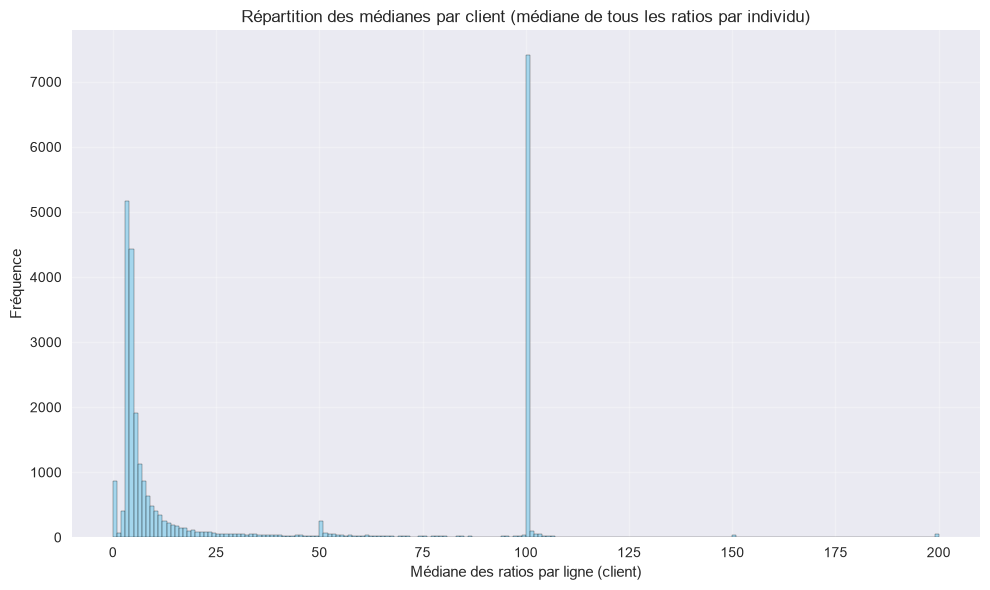

Statistiques de la répartition des médianes par client :
Nombre total de clients : 28590
Moyenne des médianes : 36.1739
Médiane : 7.3601
Écart-type : 43.1257
Minimum : 0.0000
Maximum : 200.0000


In [49]:
import matplotlib.pyplot as plt

# Définir les colonnes des ratios
ratio_columns = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# Calculer la médiane de chaque ligne (médiane des ratios pour chaque client)
# Colonne créée : définition unique (docs/colonnes_creees.md)
df['ratio_PAY_to_BILL_median'] = df[ratio_columns].median(axis=1)
# Graphique : médiane des seuls mois avec une facture exigible
row_medians = ratios_affichables(df, ratio_columns).median(axis=1).dropna()

# Enregistrer la médiane dans une nouvelle colonne du DataFrame

# Créer l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(row_medians, bins=200, color='skyblue', edgecolor='black', alpha=0.7)

# Ajouter les étiquettes et le titre
plt.xlabel('Médiane des ratios par ligne (client)')
plt.ylabel('Fréquence')
plt.title('Répartition des médianes par client (médiane de tous les ratios par individu)')
plt.grid(True, alpha=0.3)

# Afficher le graphique
plt.tight_layout()
plt.show()

# Afficher quelques statistiques descriptives
print("Statistiques de la répartition des médianes par client :")
print(f"Nombre total de clients : {len(row_medians)}")
print(f"Moyenne des médianes : {row_medians.mean():.4f}")
print(f"Médiane : {row_medians.median():.4f}")
print(f"Écart-type : {row_medians.std():.4f}")
print(f"Minimum : {row_medians.min():.4f}")
print(f"Maximum : {row_medians.max():.4f}")

**Interprétation**  
2 comportements de paiement distincts :
- le paiement par mensualité, le client rembourse des intérets et une partie du capital
- le paiement comptant à l'échéance, le client paie l'intégralité de ses dépenses du mois

Même en essayant de filter les clients qui n'augmentent pas leur retard / restent à jour de ceux qui augmentent leur retard, la tendance est la même mais pas de fracture nette de paiement ou de non paiement.  
Autre constat : un groupe important de clients paient entre 3 et 5% de la somme due comme mensualité.  
Le graphe conforte un point : le client ne tombe pas en incident codifié dans PAY_n quand il n'a pas payé sur un seul mois.  
Y a-t-il une codification spécifique pour les clients qui ont payé en retard ou que la banque a comptabilisé tardivement le paiement ?

=== Médiane des PAY_ par groupe ===
Médiane des PAY_ pour ratio_PAY_to_BILL_median [90; 110] : -1.0000
Médiane des PAY_ pour ratio_PAY_to_BILL_median > 90 : -1.0000


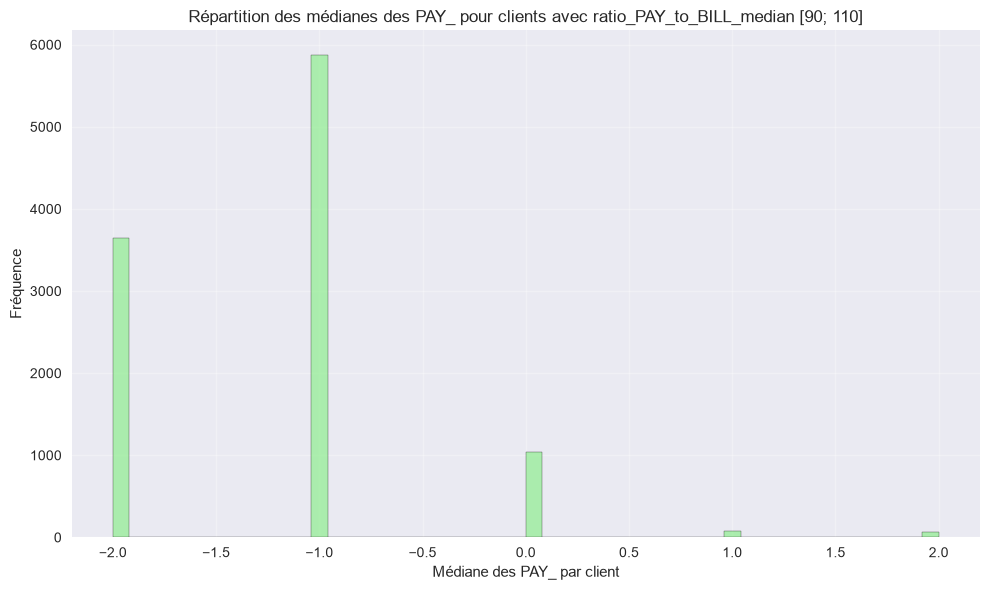

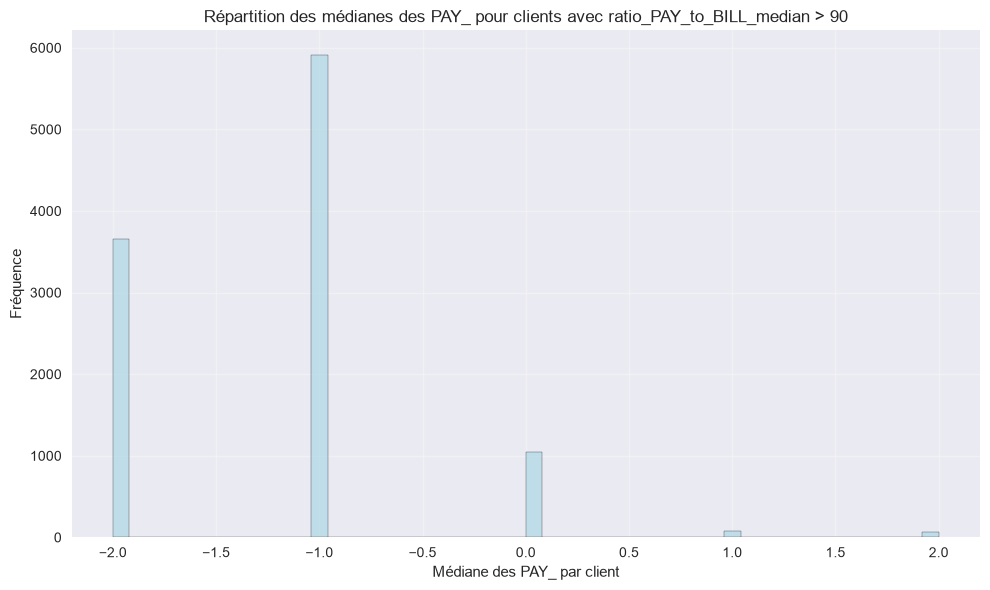

In [50]:
import matplotlib.pyplot as plt

# Définir les colonnes PAY_
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']

# Calculer la médiane des PAY_ pour les clients avec ratio_PAY_to_BILL_median compris entre 90 et 110
mask_90_110 = (df['ratio_PAY_to_BILL_median'] >= 90) & (df['ratio_PAY_to_BILL_median'] <= 110)
median_pay_90_110 = df.loc[mask_90_110, pay_columns].median(axis=1).median()

# Calculer la médiane des PAY_ pour les clients avec ratio_PAY_to_BILL_median > 90
mask_gt_90 = df['ratio_PAY_to_BILL_median'] > 90
median_pay_gt_90 = df.loc[mask_gt_90, pay_columns].median(axis=1).median()

# Afficher les résultats
print("=== Médiane des PAY_ par groupe ===")
print(f"Médiane des PAY_ pour ratio_PAY_to_BILL_median [90; 110] : {median_pay_90_110:.4f}")
print(f"Médiane des PAY_ pour ratio_PAY_to_BILL_median > 90 : {median_pay_gt_90:.4f}")

# Créer un histogramme de la distribution des PAY_ pour le groupe [90; 110]
if mask_90_110.sum() > 0:
    pay_medians_90_110 = df.loc[mask_90_110, pay_columns].median(axis=1)
    plt.figure(figsize=(10, 6))
    plt.hist(pay_medians_90_110, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.xlabel('Médiane des PAY_ par client')
    plt.ylabel('Fréquence')
    plt.title('Répartition des médianes des PAY_ pour clients avec ratio_PAY_to_BILL_median [90; 110]')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Créer un histogramme de la distribution des PAY_ pour le groupe > 90
if mask_gt_90.sum() > 0:
    pay_medians_gt_90 = df.loc[mask_gt_90, pay_columns].median(axis=1)
    plt.figure(figsize=(10, 6))
    plt.hist(pay_medians_gt_90, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Médiane des PAY_ par client')
    plt.ylabel('Fréquence')
    plt.title('Répartition des médianes des PAY_ pour clients avec ratio_PAY_to_BILL_median > 90')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

=== Valeur la plus fréquente des PAY_ par groupe ===
Valeur la plus fréquente pour ratio_PAY_to_BILL_median [90; 110] : -1.0000
Valeur la plus fréquente pour ratio_PAY_to_BILL_median > 90 : -1.0000


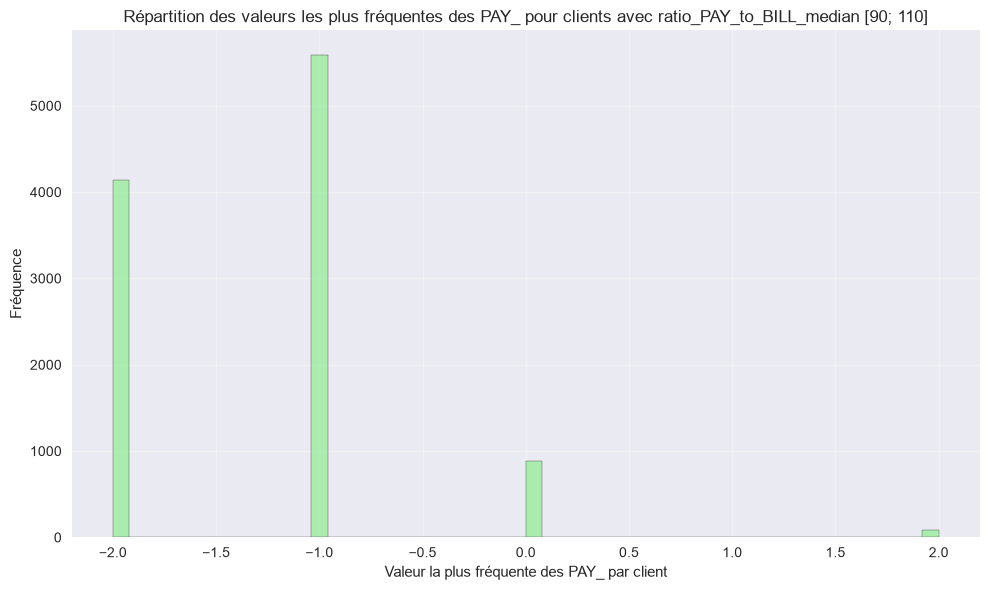

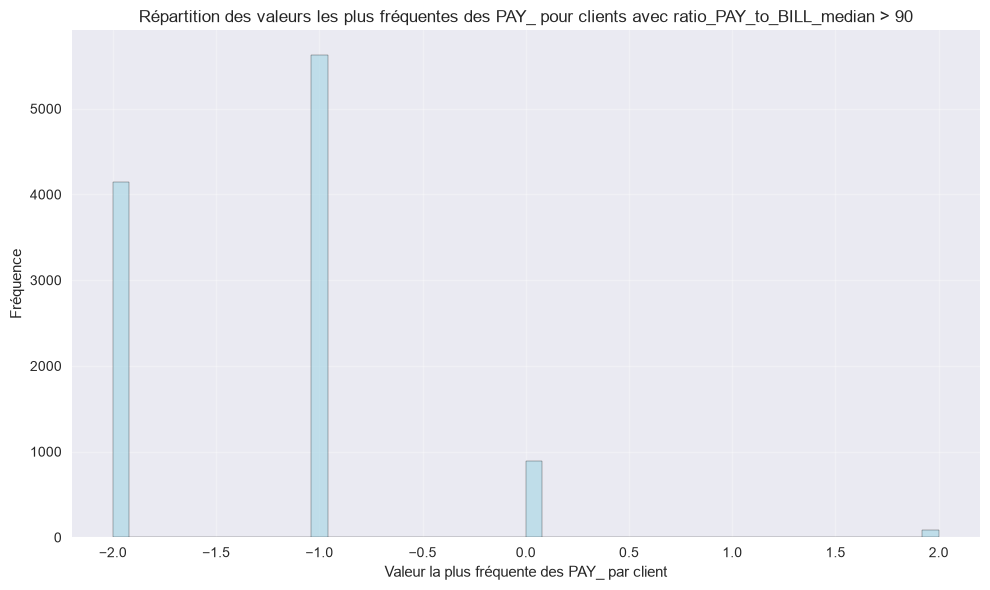

In [51]:
import matplotlib.pyplot as plt
from scipy.stats import mode

# Définir les colonnes PAY_
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']

# Calculer la valeur la plus fréquente des PAY_ pour les clients avec ratio_PAY_to_BILL_median compris entre 90 et 110
mask_90_110 = (df['ratio_PAY_to_BILL_median'] >= 90) & (df['ratio_PAY_to_BILL_median'] <= 110)
# Pour chaque client, on calcule le mode de ses PAY_ valeurs
mode_pay_90_110 = []
for idx in df.loc[mask_90_110].index:
    client_values = df.loc[idx, pay_columns]
    # On prend toutes les valeurs sans exclusion
    if len(client_values) > 0:
        mode_result = mode(client_values, keepdims=True)
        mode_pay_90_110.append(mode_result.mode[0])
    else:
        mode_pay_90_110.append(0)

# Calculer la valeur la plus fréquente globale
mode_pay_90_110 = pd.Series(mode_pay_90_110).mode()[0] if len(mode_pay_90_110) > 0 else 0

# Calculer la valeur la plus fréquente des PAY_ pour les clients avec ratio_PAY_to_BILL_median > 90
mask_gt_90 = df['ratio_PAY_to_BILL_median'] > 90
mode_pay_gt_90 = []
for idx in df.loc[mask_gt_90].index:
    client_values = df.loc[idx, pay_columns]
    # On prend toutes les valeurs sans exclusion
    if len(client_values) > 0:
        mode_result = mode(client_values, keepdims=True)
        mode_pay_gt_90.append(mode_result.mode[0])
    else:
        mode_pay_gt_90.append(0)

# Calculer la valeur la plus fréquente globale
mode_pay_gt_90 = pd.Series(mode_pay_gt_90).mode()[0] if len(mode_pay_gt_90) > 0 else 0

# Afficher les résultats
print("=== Valeur la plus fréquente des PAY_ par groupe ===")
print(f"Valeur la plus fréquente pour ratio_PAY_to_BILL_median [90; 110] : {mode_pay_90_110:.4f}")
print(f"Valeur la plus fréquente pour ratio_PAY_to_BILL_median > 90 : {mode_pay_gt_90:.4f}")

# Créer un histogramme de la distribution des valeurs les plus fréquentes pour le groupe [90; 110]
if mask_90_110.sum() > 0:
    # Recalculer les modes pour chaque client dans ce groupe
    pay_modes_90_110 = []
    for idx in df.loc[mask_90_110].index:
        client_values = df.loc[idx, pay_columns]
        if len(client_values) > 0:
            mode_result = mode(client_values, keepdims=True)
            pay_modes_90_110.append(mode_result.mode[0])
        else:
            pay_modes_90_110.append(0)
    
    plt.figure(figsize=(10, 6))
    plt.hist(pay_modes_90_110, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.xlabel('Valeur la plus fréquente des PAY_ par client')
    plt.ylabel('Fréquence')
    plt.title('Répartition des valeurs les plus fréquentes des PAY_ pour clients avec ratio_PAY_to_BILL_median [90; 110]')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Créer un histogramme de la distribution des valeurs les plus fréquentes pour le groupe > 90
if mask_gt_90.sum() > 0:
    # Recalculer les modes pour chaque client dans ce groupe
    pay_modes_gt_90 = []
    for idx in df.loc[mask_gt_90].index:
        client_values = df.loc[idx, pay_columns]
        if len(client_values) > 0:
            mode_result = mode(client_values, keepdims=True)
            pay_modes_gt_90.append(mode_result.mode[0])
        else:
            pay_modes_gt_90.append(0)
    
    plt.figure(figsize=(10, 6))
    plt.hist(pay_modes_gt_90, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Valeur la plus fréquente des PAY_ par client')
    plt.ylabel('Fréquence')
    plt.title('Répartition des valeurs les plus fréquentes des PAY_ pour clients avec ratio_PAY_to_BILL_median > 90')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

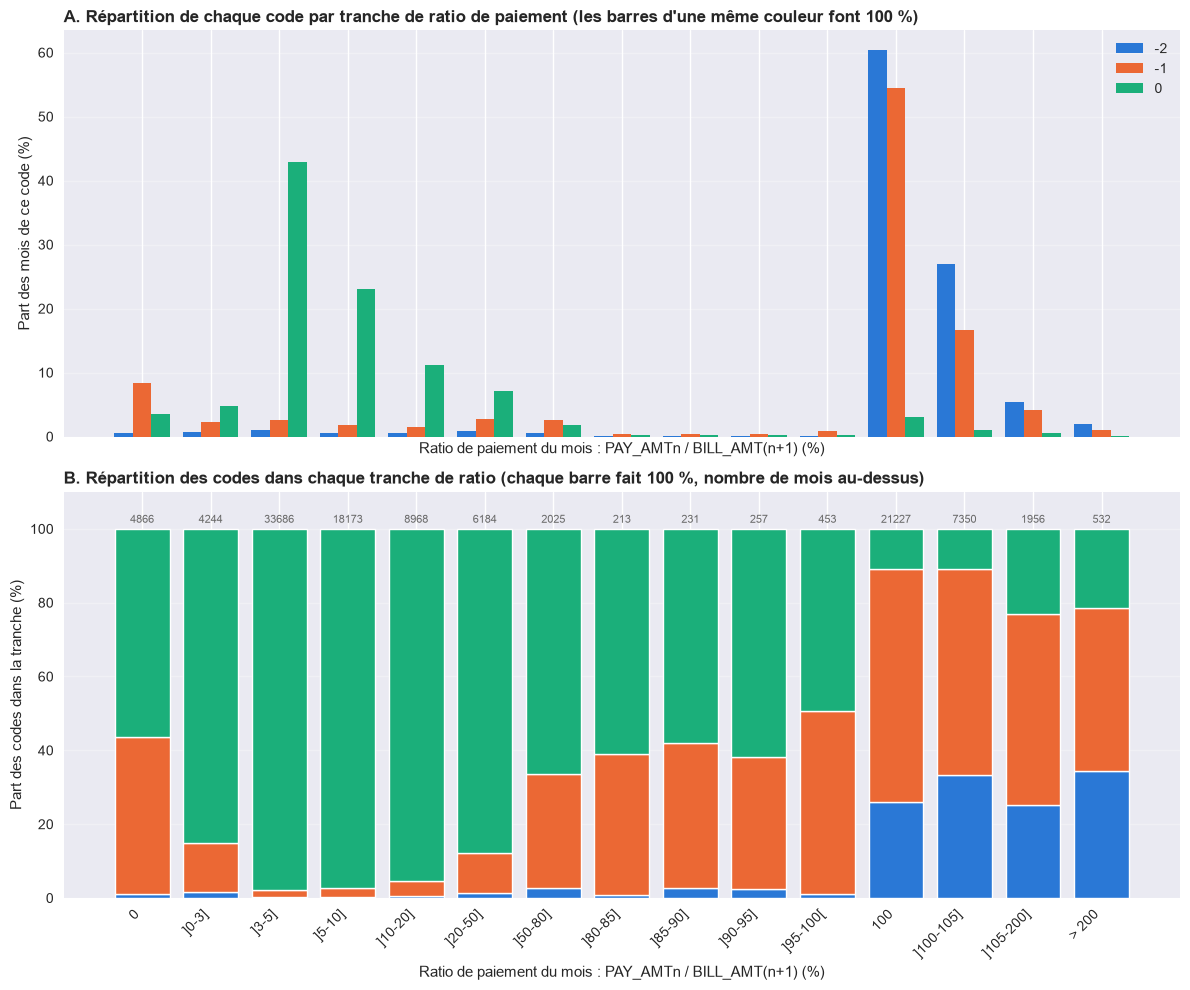

Quartiles du ratio de paiement par code (%) :


,0.10,0.25,0.50,0.75,0.90
Code,,,,,
-2,100.0,100.0,100.0,100.4,101.8
-1,2.0,100.0,100.0,100.0,100.6
0,3.2,3.7,4.9,10.3,33.0


In [52]:
# Frontière de ratio de paiement entre les codes sains -2, -1 et 0 (données brutes, sans dpnm)
# Paires d'un même mois : PAY_n, PAY_AMTn et la facture qu'il rembourse, BILL_AMT(n+1) (n = 1 à 5)
# Seuls les mois avec une facture exigible positive sont gardés (sinon pas de ratio)
lignes = []
for n in range(1, 6):
    facture = df[f'BILL_AMT{n+1}']
    ok = facture > 0
    lignes.append(pd.DataFrame({
        'Code': df.loc[ok, f'PAY_{n}'],
        'Ratio': df.loc[ok, f'PAY_AMT{n}'] / facture[ok] * 100,
    }))
paires = pd.concat(lignes, ignore_index=True)
paires = paires[paires['Code'].isin([-2, -1, 0])]

codes = [-2, -1, 0]
couleurs = {-2: '#2a78d6', -1: '#eb6834', 0: '#1baf7a'}
libelles = {-2: '-2', -1: '-1', 0: '0'}

# Tranches de ratio (%) : fines autour du paiement minimum et autour de 100 %
bornes = [-0.1, 0, 3, 5, 10, 20, 50, 80, 85, 90, 95, 99.9, 100.1, 105, 200, np.inf]
noms = ['0', ']0-3]', ']3-5]', ']5-10]', ']10-20]', ']20-50]', ']50-80]', ']80-85]', ']85-90]',
        ']90-95]', ']95-100[', '100', ']100-105]', ']105-200]', '> 200']
tranche = pd.cut(paires['Ratio'], bornes, labels=noms)

# A. Répartition du ratio pour chaque code (chaque colonne fait 100 %)
repartition = pd.crosstab(tranche, paires['Code'], normalize='columns') * 100
# B. Part de chaque code dans chaque tranche de ratio (chaque ligne fait 100 %)
part_codes = pd.crosstab(tranche, paires['Code'], normalize='index') * 100
effectifs = tranche.value_counts().reindex(noms)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex = True)
x = np.arange(len(noms))
largeur = 0.27
for i, code in enumerate(codes):
    ax1.bar(x + (i - 1) * largeur, repartition[code], width=largeur, color=couleurs[code], label=libelles[code])
ax1.set_ylabel('Part des mois de ce code (%)')
ax1.set_title('A. Répartition de chaque code par tranche de ratio de paiement (les barres d\'une même couleur font 100 %)',
              fontweight='bold', loc='left')
ax1.set_xticks(x)
ax1.set_xticklabels(noms, rotation=45, ha='right')
ax1.set_xlabel('Ratio de paiement du mois : PAY_AMTn / BILL_AMT(n+1) (%)')

ax1.legend(frameon=False)
ax1.grid(axis='y', alpha=0.3)

bas = np.zeros(len(noms))
for code in codes:
    ax2.bar(x, part_codes[code], bottom=bas, color=couleurs[code], edgecolor='white', linewidth=1, label=libelles[code])
    bas += part_codes[code].values
for xi, nb in zip(x, effectifs):
    ax2.text(xi, 101, f'{nb}', ha='center', va='bottom', fontsize=8, color='dimgrey')
ax2.set_ylim(0, 110)
ax2.set_ylabel('Part des codes dans la tranche (%)')
ax2.set_title('B. Quel code pour quel ratio ? (nombre de mois au-dessus des barres)', fontweight='bold', loc='left')
ax2.set_xticks(x)
ax2.set_xticklabels(noms, rotation=45, ha='right')
ax2.set_xlabel('Ratio de paiement du mois : PAY_AMTn / BILL_AMT(n+1) (%)')
ax2.set_title('B. Répartition des codes dans chaque tranche de ratio (chaque barre fait 100 %, nombre de mois au-dessus)',
              fontweight='bold', loc='left')

ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Quartiles du ratio de paiement par code (%) :")
display(paires.groupby('Code')['Ratio'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack().round(1))


Plage [0 ; 105[ en 100 bins de 1.05 points : 107876 mois retenus, 2489 hors plage


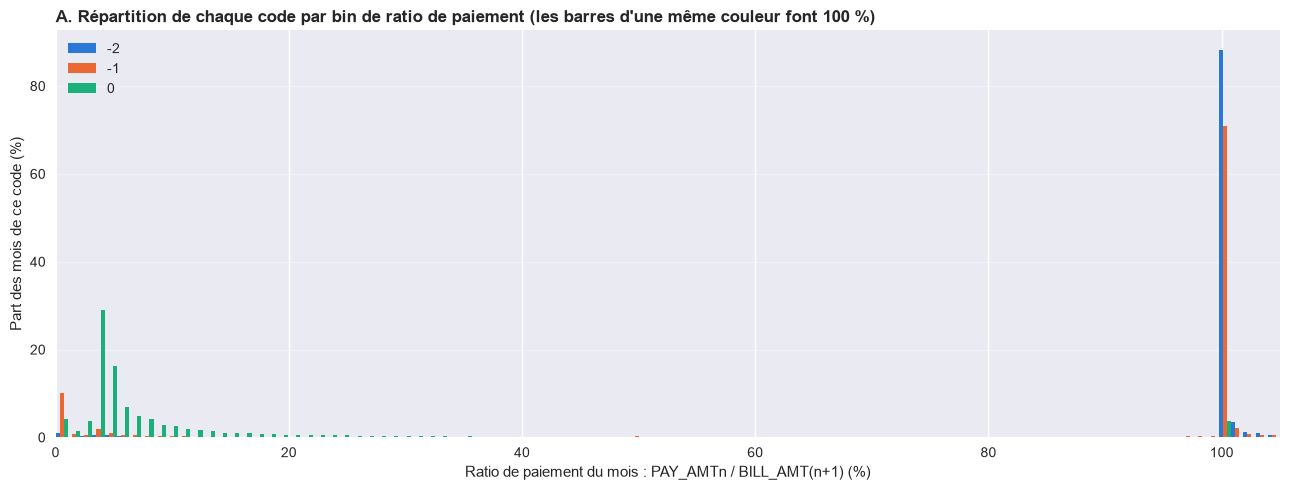

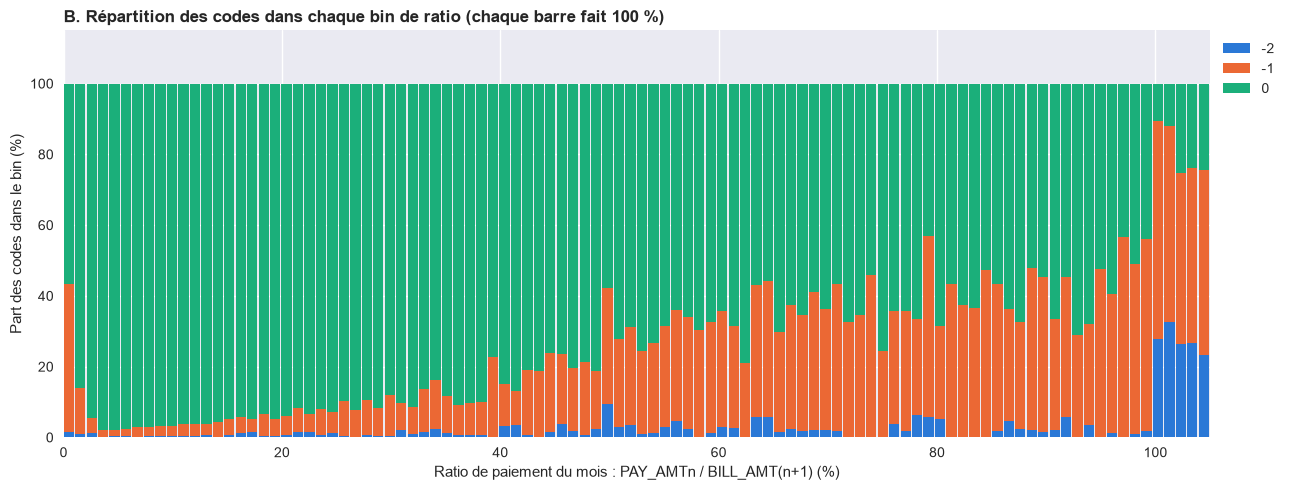

In [53]:
# Paramètres à ajuster pour affiner les frontières
debut, fin = 0, 105   # plage de ratio étudiée (%)
nb_bins = 100           # nombre de bins de même largeur sur la plage

# Ratios réels uniquement : mois avec une facture exigible positive (BILL_AMT(n+1) > 0)
# (sans facture, ratio_PAY_BILLn vaut 100 % par convention : ces mois sont exclus)
lignes = []
for n in range(1, 6):
    facture_due = df[f'BILL_AMT{n+1}'] > 0
    lignes.append(pd.DataFrame({'Code': df.loc[facture_due, f'PAY_{n}'],
                                'Ratio': df.loc[facture_due, f'ratio_PAY_BILL{n}']}))
paires = pd.concat(lignes, ignore_index=True)
paires = paires[paires['Code'].isin(codes)]

bornes = np.linspace(debut, fin, nb_bins + 1)
largeur_bin = (fin - debut) / nb_bins
# Bins fermés à gauche : [a, b[ (un ratio de 100 % tombe dans le bin qui commence à 100)
dans_plage = paires[(paires['Ratio'] >= debut) & (paires['Ratio'] < fin)]
bin_gauche = pd.cut(dans_plage['Ratio'], bornes, right=False, labels=bornes[:-1]).astype(float)
print(f"Plage [{debut} ; {fin}[ en {nb_bins} bins de {largeur_bin:g} points : "
      f"{len(dans_plage)} mois retenus, {len(paires) - len(dans_plage)} hors plage")

# A. Pour chaque code, répartition de ses mois par bin (les barres d'une même couleur font 100 %)
repartition = pd.crosstab(bin_gauche, dans_plage['Code'], normalize='columns').reindex(bornes[:-1], fill_value=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
for i, code in enumerate(codes):
    ax.bar(repartition.index + i * largeur_bin / 3, repartition[code], width=largeur_bin / 3, align='edge',
           color=couleurs[code], label=libelles[code])
ax.set_title("A. Répartition de chaque code par bin de ratio de paiement (les barres d'une même couleur font 100 %)",
             fontweight='bold', loc='left')
ax.set_xlabel('Ratio de paiement du mois : PAY_AMTn / BILL_AMT(n+1) (%)')
ax.set_ylabel('Part des mois de ce code (%)')
ax.set_xlim(debut, fin)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# B. Dans chaque bin, part de chaque code (chaque barre fait 100 %)
part_codes = pd.crosstab(bin_gauche, dans_plage['Code'], normalize='index').reindex(columns=codes, fill_value=0) * 100
effectifs = bin_gauche.value_counts().reindex(part_codes.index)

fig, ax = plt.subplots(figsize=(13, 5))
bas = np.zeros(len(part_codes))
for code in codes:
    ax.bar(part_codes.index, part_codes[code], bottom=bas, width=0.9 * largeur_bin, align='edge',
           color=couleurs[code], label=libelles[code])
    bas += part_codes[code].values
# Nombre de mois au-dessus des barres, seulement si les bins ne sont pas trop nombreux
if nb_bins <= 40:
    for x, nb in effectifs.items():
        ax.text(x + largeur_bin / 2, 101, f'{nb}', ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=90)
ax.set_title('B. Répartition des codes dans chaque bin de ratio (chaque barre fait 100 %)', fontweight='bold', loc='left')
ax.set_xlabel('Ratio de paiement du mois : PAY_AMTn / BILL_AMT(n+1) (%)')
ax.set_ylabel('Part des codes dans le bin (%)')
ax.set_xlim(debut, fin)
ax.set_ylim(0, 115)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


**Interprétation**  
0 semble correspondre à une utilisation à crédit, paiement par mensualité  
-1 est présent sue tous les ratios mais très présent autour de 100%, il est difficile de comprendre la signification de ce code, il semble très utilisé autour du ratio de 100% également  
-2 est présent surtout à partir de 100% de ratio, semble correspondre à une utilisation au comptant  
Je regarde maintenant sur le comportement médian du client pour voir si des délimitations ou des comportements sont plus tranchés.  

Clients sans code dominant (égalité) : 1575 | code dominant hors -2, -1, 0 : 2622
Plage [0 ; 100] en 10 bins de 10 points : 24287 clients retenus, 1512 hors plage


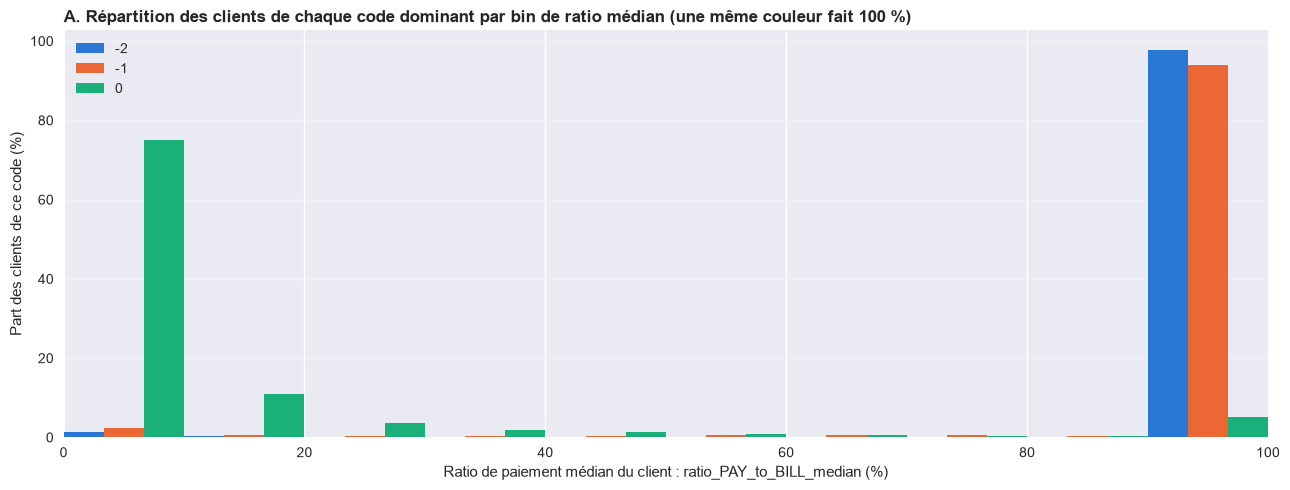

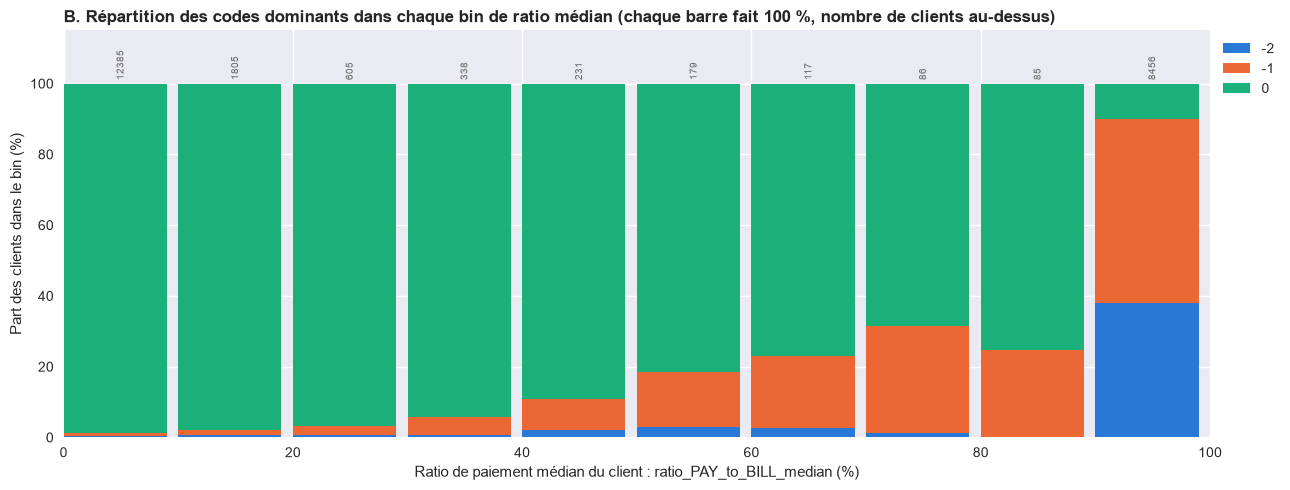

In [54]:
# Paramètres à ajuster pour affiner les frontières
debut, fin = 0, 100     # plage de ratio médian étudiée (%)
nb_bins = 10         # nombre de bins de même largeur sur la plage

codes = [-2, -1, 0]
couleurs = {-2: '#2a78d6', -1: '#eb6834', 0: '#1baf7a'}
libelles = {-2: '-2', -1: '-1', 0: '0'}
titre_x = 'Ratio de paiement médian du client : ratio_PAY_to_BILL_median (%)'

# Un client = une ligne : son ratio médian et son code dominant de PAY_1 à PAY_5
# (code le plus fréquent ; en cas d'égalité, pas de profil net : client exclu)
codes_mois = df[[f'PAY_{n}' for n in range(1, 6)]]
modes = codes_mois.mode(axis=1)
egalite = modes.shape[1] > 1 and True
code_dominant = modes[0].where(modes.iloc[:, 1:].isna().all(axis=1)) if modes.shape[1] > 1 else modes[0]
clients = pd.DataFrame({'Code': code_dominant, 'Ratio': df['ratio_PAY_to_BILL_median']})
print(f"Clients sans code dominant (égalité) : {code_dominant.isna().sum()} | "
      f"code dominant hors -2, -1, 0 : {(code_dominant.notna() & ~code_dominant.isin(codes)).sum()}")
clients = clients[clients['Code'].isin(codes)]

bornes = np.linspace(debut, fin, nb_bins + 1)
largeur_bin = (fin - debut) / nb_bins
# Bins fermés à gauche : [a, b[ (fin incluse pour garder les ratios écrêtés à 200 %)
dans_plage = clients[(clients['Ratio'] >= debut) & (clients['Ratio'] <= fin)]
bin_gauche = pd.cut(dans_plage['Ratio'].clip(upper=fin - 1e-9), bornes, right=False, labels=bornes[:-1]).astype(float)
print(f"Plage [{debut} ; {fin}] en {nb_bins} bins de {largeur_bin:g} points : "
      f"{len(dans_plage)} clients retenus, {len(clients) - len(dans_plage)} hors plage")

# A. Pour chaque code dominant, répartition de ses clients par bin (les barres d'une même couleur font 100 %)
repartition = pd.crosstab(bin_gauche, dans_plage['Code'], normalize='columns').reindex(bornes[:-1], fill_value=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
for i, code in enumerate(codes):
    ax.bar(repartition.index + i * largeur_bin / 3, repartition[code], width=largeur_bin / 3, align='edge',
           color=couleurs[code], label=libelles[code])
ax.set_title("A. Répartition des clients de chaque code dominant par bin de ratio médian (une même couleur fait 100 %)",
             fontweight='bold', loc='left')
ax.set_xlabel(titre_x)
ax.set_ylabel('Part des clients de ce code (%)')
ax.set_xlim(debut, fin)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# B. Dans chaque bin, part de chaque code dominant (chaque barre fait 100 %)
part_codes = pd.crosstab(bin_gauche, dans_plage['Code'], normalize='index').reindex(columns=codes, fill_value=0) * 100
effectifs = bin_gauche.value_counts().reindex(part_codes.index)

fig, ax = plt.subplots(figsize=(13, 5))
bas = np.zeros(len(part_codes))
for code in codes:
    ax.bar(part_codes.index, part_codes[code], bottom=bas, width=0.9 * largeur_bin, align='edge',
           color=couleurs[code], label=libelles[code])
    bas += part_codes[code].values
# Nombre de clients au-dessus des barres, seulement si les bins ne sont pas trop nombreux
if nb_bins <= 40:
    for x, nb in effectifs.items():
        ax.text(x + largeur_bin / 2, 101, f'{nb}', ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=90)
ax.set_title('B. Répartition des codes dominants dans chaque bin de ratio médian (chaque barre fait 100 %, nombre de clients au-dessus)',
             fontweight='bold', loc='left')
ax.set_xlabel(titre_x)
ax.set_ylabel('Part des clients dans le bin (%)')
ax.set_xlim(debut, fin)
ax.set_ylim(0, 115)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


Certains ratios médians sont très peu représentés.  
La codification -1 pour un ratio médian à 0 semble importante mais elle ne représente que 161 clients


In [55]:
# Test : le code -1 correspond-il à un paiement différé d'un mois ?
# Nomenclature du dataset : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble (PAY_AMTn rembourse normalement BILL_AMT(n+1)).
# Si -1 était un paiement différé d'un mois, PAY_AMTn rembourserait plutôt BILL_AMT(n+2), la facture d'un mois plus ancien.
# n = 1 à 4 (BILL_AMT(n+2) doit exister) ; on garde les mois où les deux factures sont positives.
lignes = []
for n in range(1, 5):
    ok = (df[f'BILL_AMT{n+1}'] > 0) & (df[f'BILL_AMT{n+2}'] > 0)
    lignes.append(pd.DataFrame({
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'PAY_AMTn': df.loc[ok, f'PAY_AMT{n}'],
        'BILL_AMT(n+1)': df.loc[ok, f'BILL_AMT{n+1}'],
        'BILL_AMT(n+2)': df.loc[ok, f'BILL_AMT{n+2}'],
    }))
test = pd.concat(lignes, ignore_index=True)
test = test[test['PAY_n'].isin([-2, -1, 0])]

ratio_n1 = test['PAY_AMTn'] / test['BILL_AMT(n+1)']
ratio_n2 = test['PAY_AMTn'] / test['BILL_AMT(n+2)']
# Cas ambigu : deux factures identiques (aucune activité), on ne peut pas savoir laquelle est remboursée
factures_distinctes = test['BILL_AMT(n+1)'] != test['BILL_AMT(n+2)']

questions = {
    'Nombre de mois observés': pd.Series(1, index=test.index),
    'BILL_AMT(n+1) = BILL_AMT(n+2) : factures identiques, cas ambigu (%)': ~factures_distinctes,
    'PAY_AMTn = BILL_AMT(n+1) au centime près : cas normal (%)': factures_distinctes & (test['PAY_AMTn'] == test['BILL_AMT(n+1)']),
    'PAY_AMTn = BILL_AMT(n+2) au centime près : paiement différé (%)': factures_distinctes & (test['PAY_AMTn'] == test['BILL_AMT(n+2)']),
    'PAY_AMTn >= 90 % de BILL_AMT(n+1) : cas normal (%)': ratio_n1 >= 0.9,
    'PAY_AMTn >= 90 % de BILL_AMT(n+2) : paiement différé (%)': ratio_n2 >= 0.9,
    'PAY_AMTn solde BILL_AMT(n+2) mais pas BILL_AMT(n+1) : différé seul (%)': (ratio_n2 >= 0.9) & (ratio_n1 < 0.9),
}
noms_codes = {-2: 'PAY_n = -2', -1: 'PAY_n = -1', 0: 'PAY_n = 0'}

tableau = pd.DataFrame({q: (s.groupby(test['PAY_n']).sum() if q.startswith('Nombre') else s.groupby(test['PAY_n']).mean() * 100)
                        for q, s in questions.items()}).T
tableau = tableau.rename(columns=noms_codes).round(1)
display(tableau.rename_axis('Pour les mois avec ce code PAY_n, part des cas où...'))

print("Lecture : chaque colonne = les mois portant ce code PAY_n ; chaque ligne = quelle facture le paiement PAY_AMTn rembourse.\n"
      "Si -1 était un paiement différé d'un mois, les lignes « BILL_AMT(n+2) » seraient plus fortes que les lignes « BILL_AMT(n+1) » pour les -1.")


PAY_n,PAY_n = -2,PAY_n = -1,PAY_n = 0
"Pour les mois avec ce code PAY_n, part des cas où...",,,
Nombre de mois observés,6114.0,17993.0,59085.0
"BILL_AMT(n+1) = BILL_AMT(n+2) : factures identiques, cas ambigu (%)",8.3,11.9,0.5
PAY_AMTn = BILL_AMT(n+1) au centime près : cas normal (%),45.5,39.6,1.9
PAY_AMTn = BILL_AMT(n+2) au centime près : paiement différé (%),0.1,0.7,0.1
PAY_AMTn >= 90 % de BILL_AMT(n+1) : cas normal (%),94.1,77.7,4.2
PAY_AMTn >= 90 % de BILL_AMT(n+2) : paiement différé (%),57.5,51.0,4.6
PAY_AMTn solde BILL_AMT(n+2) mais pas BILL_AMT(n+1) : différé seul (%),0.8,2.3,1.9


Lecture : chaque colonne = les mois portant ce code PAY_n ; chaque ligne = quelle facture le paiement PAY_AMTn rembourse.
Si -1 était un paiement différé d'un mois, les lignes « BILL_AMT(n+2) » seraient plus fortes que les lignes « BILL_AMT(n+1) » pour les -1.


le tableau en l'état n'est pas probant, il montre juste que la codification -2 est payée à +90% pour 94% des mois  
La codification -1 a aussi un ratio de paiement élevé moyen, 78% des mensualités sont payés à +90% le mois suivant

In [56]:
# Test du paiement différé
# Nomenclature : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble (PAY_AMTn rembourse la facture BILL_AMT(n+1)).
# Exemple n = 2 : facture BILL_AMT3 (relevé de M-3), payée par PAY_AMT2 (paiement de M-2), code PAY_2.
#   Si rien n'est payé en M-2, la facture se reporte dans le relevé suivant BILL_AMT2 (avec intérêts et nouveaux achats),
#   qui est payé par PAY_AMT1 (paiement de M-1). Relevé suivant soldé = différé d'un mois.
# n = 2 à 5 (le paiement du mois suivant PAY_AMT(n-1) doit exister) ; seulement les factures dues : BILL_AMT(n+1) > 0
lignes = []
for n in range(2, 6):
    ok = df[f'BILL_AMT{n+1}'] > 0
    lignes.append(pd.DataFrame({
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'ratio_n': df.loc[ok, f'PAY_AMT{n}'] / df.loc[ok, f'BILL_AMT{n+1}'],
        'PAY_AMTn': df.loc[ok, f'PAY_AMT{n}'],
        'releve_suivant_solde': df.loc[ok, f'PAY_AMT{n-1}'] >= 0.9 * df.loc[ok, f'BILL_AMT{n}'].clip(lower=0),
    }))
test = pd.concat(lignes, ignore_index=True)
test = test[test['PAY_n'].isin([-2, -1, 0])]

comportement = pd.Series(np.select(
    [test['ratio_n'] >= 0.9,
     (test['PAY_AMTn'] == 0) & test['releve_suivant_solde'],
     test['PAY_AMTn'] > 0,
     test['PAY_AMTn'] == 0],
    ['1. PAY_AMTn solde BILL_AMT(n+1) (>= 90 %)',
     '2. PAY_AMTn = 0, puis PAY_AMT(n-1) solde BILL_AMT(n) : différé d\'un mois',
     '3. PAY_AMTn partiel (> 0 et < 90 % de BILL_AMT(n+1))',
     '4. PAY_AMTn = 0, et PAY_AMT(n-1) ne solde pas BILL_AMT(n) : impayé'],
    default='autre'), index=test.index)

nb = pd.crosstab(comportement, test['PAY_n'])
nb.loc['Total'] = nb.sum()
total_ligne = nb.sum(axis=1)

# Chaque case : nombre de cas (part de la ligne en %)
tableau = pd.DataFrame({'Nb de cas': total_ligne})
for code in [-2, -1, 0]:
    tableau[f'PAY_n = {code}'] = [f"{n} ({n / t * 100:.1f} %)" for n, t in zip(nb[code], total_ligne)]
display(tableau.rename_axis('Comportement de paiement au mois n (facture due)'))

print("Lecture : une ligne = un comportement de paiement ; « Nb de cas » = nombre de mois (client x mois) concernés ;\n"
      "chaque case = nombre de cas avec ce code PAY_n (part de la ligne, les % d'une ligne font 100 %).")


,Nb de cas,PAY_n = -2,PAY_n = -1,PAY_n = 0
Comportement de paiement au mois n (facture due),,,,
1. PAY_AMTn solde BILL_AMT(n+1) (>= 90 %),25596,6969 (27.2 %),15117 (59.1 %),3510 (13.7 %)
"2. PAY_AMTn = 0, puis PAY_AMT(n-1) solde BILL_AMT(n) : différé d'un mois",1668,24 (1.4 %),1596 (95.7 %),48 (2.9 %)
3. PAY_AMTn partiel (> 0 et < 90 % de BILL_AMT(n+1)),59029,291 (0.5 %),2751 (4.7 %),55987 (94.8 %)
"4. PAY_AMTn = 0, et PAY_AMT(n-1) ne solde pas BILL_AMT(n) : impayé",2829,20 (0.7 %),111 (3.9 %),2698 (95.4 %)
Total,89122,7304 (8.2 %),19575 (22.0 %),62243 (69.8 %)


Lecture : une ligne = un comportement de paiement ; « Nb de cas » = nombre de mois (client x mois) concernés ;
chaque case = nombre de cas avec ce code PAY_n (part de la ligne, les % d'une ligne font 100 %).


In [57]:
# Codes avant et après un -1 : différés d'un mois comparés aux -1 soldés dans le mois
# Nomenclature : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble ; code d'avant = PAY_(n+1) (mois plus ancien),
# code d'après = PAY_(n-1) (mois suivant). n = 2 à 5, factures dues seulement : BILL_AMT(n+1) > 0
lignes = []
for n in range(2, 6):
    ok = df[f'BILL_AMT{n+1}'] > 0
    lignes.append(pd.DataFrame({
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'Code avant PAY_(n+1)': df.loc[ok, f'PAY_{n+1}'],
        'Code après PAY_(n-1)': df.loc[ok, f'PAY_{n-1}'],
        'ratio_n': df.loc[ok, f'PAY_AMT{n}'] / df.loc[ok, f'BILL_AMT{n+1}'],
        'PAY_AMTn': df.loc[ok, f'PAY_AMT{n}'],
        'releve_suivant_solde': df.loc[ok, f'PAY_AMT{n-1}'] >= 0.9 * df.loc[ok, f'BILL_AMT{n}'].clip(lower=0),
    }))
test = pd.concat(lignes, ignore_index=True)

moins_1 = test['PAY_n'] == -1
groupes = {
    '-1 différé (PAY_AMTn = 0, relevé suivant soldé)': moins_1 & (test['PAY_AMTn'] == 0) & test['releve_suivant_solde'],
    '-1 soldé dans le mois (PAY_AMTn >= 90 %)': moins_1 & (test['ratio_n'] >= 0.9),
}

def compte_pct(serie):
    # Nombre de cas par code (part du groupe en %)
    nb = serie.value_counts().sort_index()
    return pd.Series([f"{n} ({n / nb.sum() * 100:.1f} %)" for n in nb], index=nb.index)

for colonne in ['Code avant PAY_(n+1)', 'Code après PAY_(n-1)']:
    print(f"{colonne} :")
    display(pd.DataFrame({f"{nom} - {m.sum()} cas": compte_pct(test.loc[m, colonne]) for nom, m in groupes.items()})
            .fillna('0 (0.0 %)').rename_axis(colonne))

# Enchaînement complet avant -> -1 -> après pour les différés (les plus fréquents)
differe = groupes['-1 différé (PAY_AMTn = 0, relevé suivant soldé)']
enchainement = (test.loc[differe, 'Code avant PAY_(n+1)'].astype(str) + ' -> -1 -> '
                + test.loc[differe, 'Code après PAY_(n-1)'].astype(str))
print("Enchaînements les plus fréquents pour les -1 différés :")

display(compte_pct(enchainement).loc[enchainement.value_counts().index].head(10).rename('Nb de cas (%)').to_frame())


Code avant PAY_(n+1) :


,"-1 différé (PAY_AMTn = 0, relevé suivant soldé) - 1596 cas",-1 soldé dans le mois (PAY_AMTn >= 90 %) - 15117 cas
Code avant PAY_(n+1),,
-2,5 (0.3 %),168 (1.1 %)
-1,45 (2.8 %),14683 (97.1 %)
0,851 (53.3 %),259 (1.7 %)
2,658 (41.2 %),7 (0.0 %)
3,33 (2.1 %),0 (0.0 %)
4,3 (0.2 %),0 (0.0 %)
6,1 (0.1 %),0 (0.0 %)


Code après PAY_(n-1) :


,"-1 différé (PAY_AMTn = 0, relevé suivant soldé) - 1596 cas",-1 soldé dans le mois (PAY_AMTn >= 90 %) - 15117 cas
Code après PAY_(n-1),,
-2,215 (13.5 %),611 (4.0 %)
-1,975 (61.1 %),12431 (82.2 %)
0,151 (9.5 %),1278 (8.5 %)
1,72 (4.5 %),289 (1.9 %)
2,183 (11.5 %),508 (3.4 %)


Enchaînements les plus fréquents pour les -1 différés :


,Nb de cas (%)
0 -> -1 -> -1,586 (36.7 %)
2 -> -1 -> -1,344 (21.6 %)
2 -> -1 -> -2,102 (6.4 %)
0 -> -1 -> -2,99 (6.2 %)
0 -> -1 -> 2,96 (6.0 %)
2 -> -1 -> 0,75 (4.7 %)
2 -> -1 -> 2,74 (4.6 %)
0 -> -1 -> 0,69 (4.3 %)
2 -> -1 -> 1,63 (3.9 %)
-1 -> -1 -> -1,28 (1.8 %)


-1 et -2 se ressemblent sur bon nombre de leur fonctionnement, leur différence est difficile à appréhender, il s'agity peut etre d'une codification de risque interne différentiante entre les 2 clientèles qui paient au comptant  

Mois en retard le mois précédent (facture due) : 13469
  - exclus car PAY_n = 1 ou PAY_(n-1) = 1 (indéterminé) : 1049
  = mois étudiés : 12420
Plage [0.5 ; 200] en 50 bins de 3.99 points : 5526 mois retenus, 6894 sous 0.5 % (rien ou presque payé)

Issue lue dans PAY_n (le mois même du paiement) : Reste en retard (code >= 2) : 4564 (82.6 %) | Sortie du retard (code <= 0) : 962 (17.4 %)


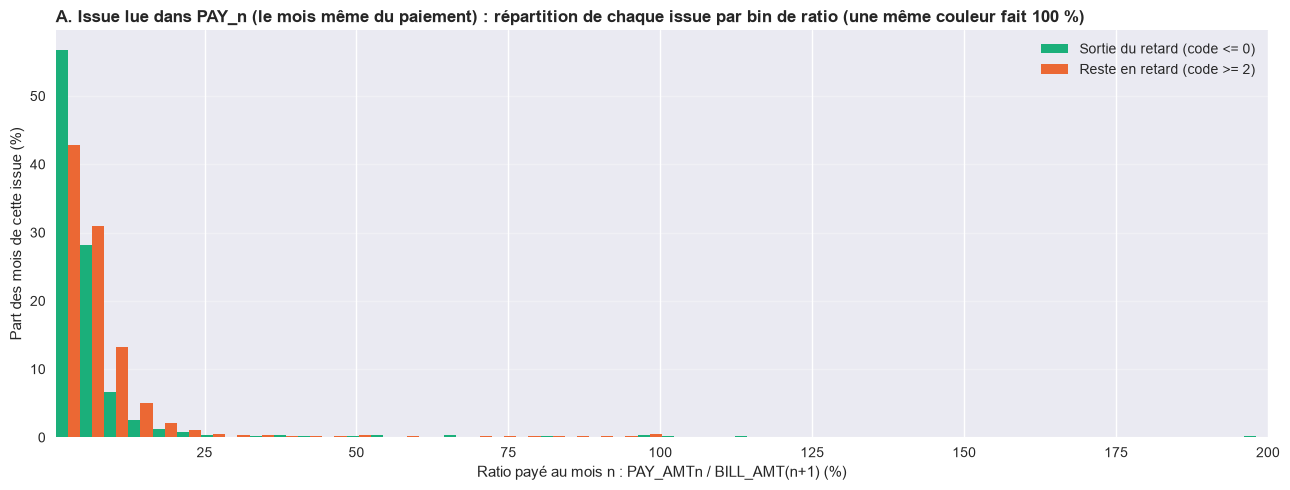

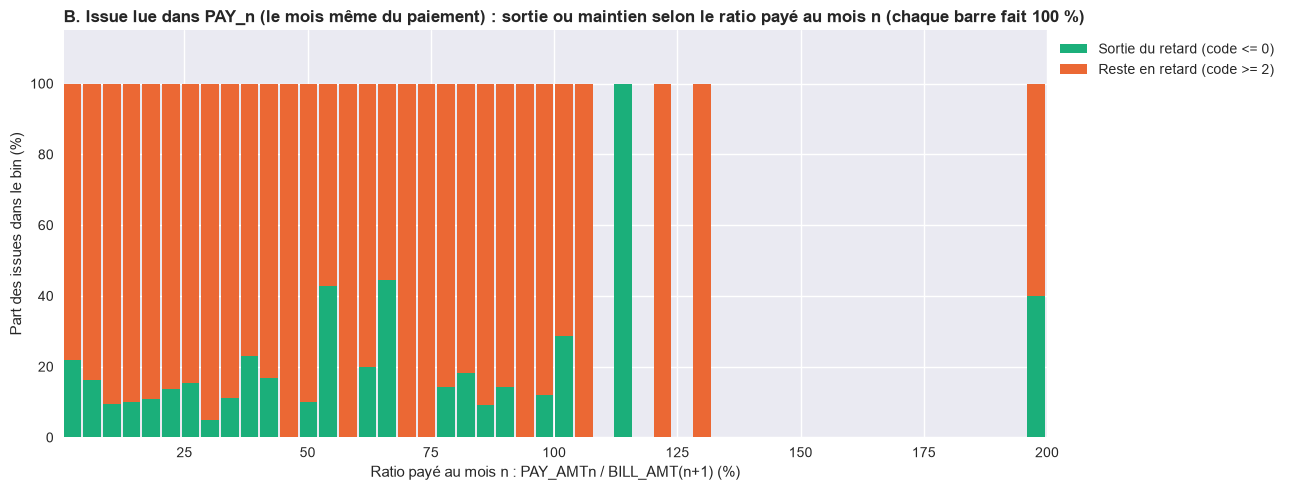


Issue lue dans PAY_(n-1) (le mois suivant le paiement) : Reste en retard (code >= 2) : 3902 (70.6 %) | Sortie du retard (code <= 0) : 1624 (29.4 %)


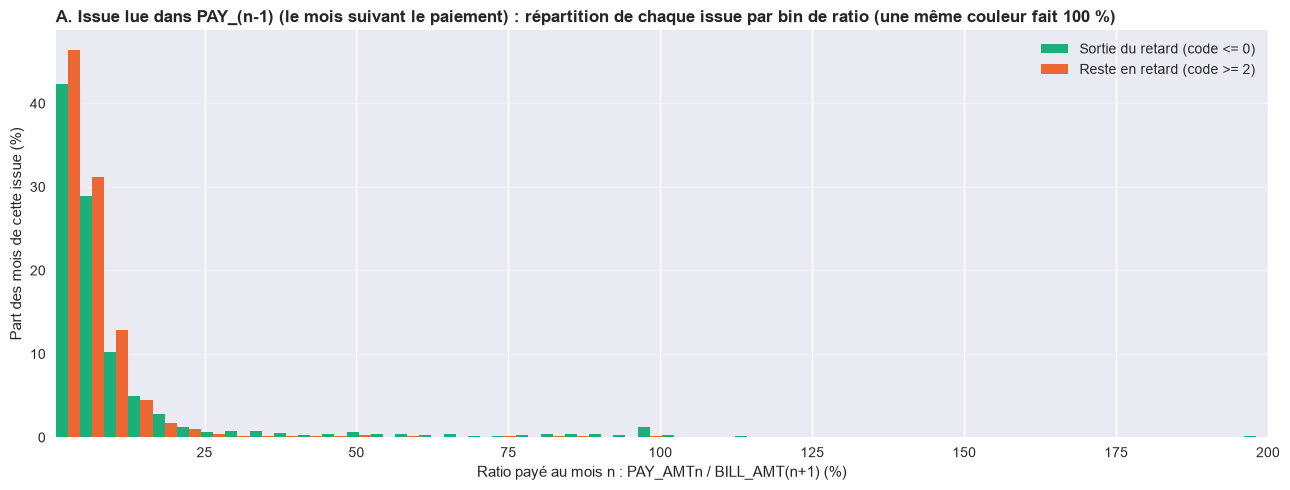

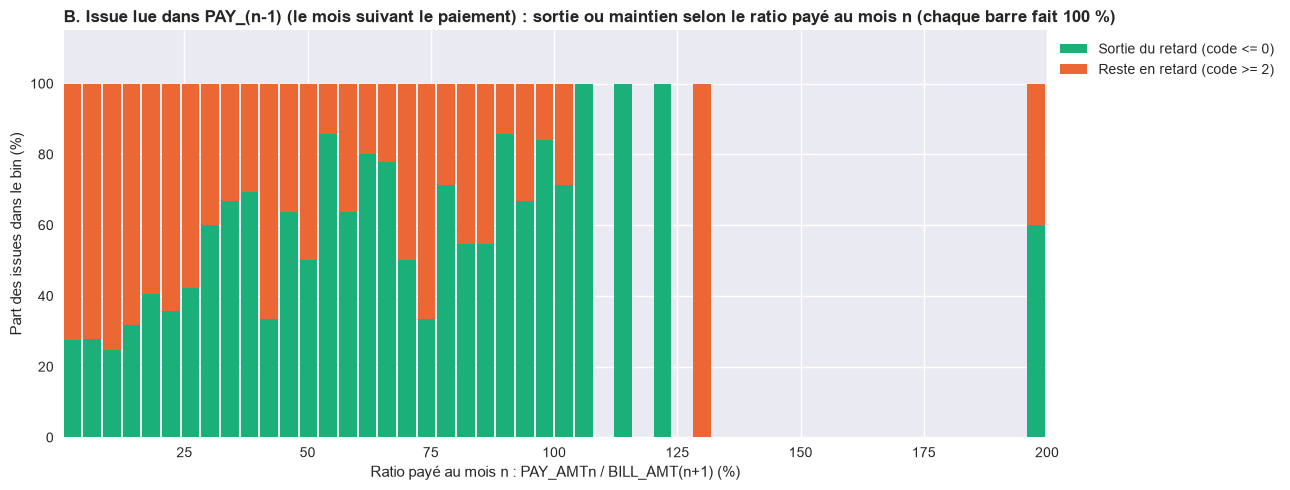

In [58]:
# Sortie du retard : le paiement du mois n se voit-il dans le code du mois même (PAY_n) ou du mois suivant (PAY_(n-1)) ?
# Nomenclature : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble. Départ : client en retard le mois précédent (PAY_(n+1) >= 2).
# Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1). Issue lue deux fois : dans PAY_n puis dans PAY_(n-1).
# n = 2 à 5 (PAY_(n-1) doit exister) ; factures dues seulement : BILL_AMT(n+1) > 0 ;
# cas exclus si PAY_n = 1 ou PAY_(n-1) = 1 (indéterminé), pour comparer les deux issues sur la même population

# Paramètres à ajuster pour affiner les frontières
debut, fin = 0.5, 200     # plage de ratio étudiée (%)
nb_bins = 50            # nombre de bins de même largeur sur la plage

lignes = []
for n in range(2, 6):
    ok = (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+1}'] > 0)
    lignes.append(pd.DataFrame({
        'n': n,
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'PAY_(n-1)': df.loc[ok, f'PAY_{n-1}'],
        'Ratio': df.loc[ok, f'PAY_AMT{n}'] / df.loc[ok, f'BILL_AMT{n+1}'] * 100,
    }))
sorties = pd.concat(lignes, ignore_index=True)

code_1 = (sorties['PAY_n'] == 1) | (sorties['PAY_(n-1)'] == 1)
nb_depart = len(sorties)
sorties = sorties[~code_1]
print(f"Mois en retard le mois précédent (facture due) : {nb_depart}\n"
      f"  - exclus car PAY_n = 1 ou PAY_(n-1) = 1 (indéterminé) : {code_1.sum()}\n"
      f"  = mois étudiés : {len(sorties)}")

bornes = np.linspace(debut, fin, nb_bins + 1)
largeur_bin = (fin - debut) / nb_bins
# Bins fermés à gauche : [a, b[ (ratios au-delà de fin regroupés dans le dernier bin)
dans_plage = sorties[sorties['Ratio'] >= debut]
bin_gauche = pd.cut(dans_plage['Ratio'].clip(upper=fin - 1e-9), bornes, right=False, labels=bornes[:-1]).astype(float)
print(f"Plage [{debut} ; {fin}] en {nb_bins} bins de {largeur_bin:g} points : {len(dans_plage)} mois retenus, "
      f"{len(sorties) - len(dans_plage)} sous {debut} % (rien ou presque payé)")

couleurs_issue = {'Sortie du retard (code <= 0)': '#1baf7a', 'Reste en retard (code >= 2)': '#eb6834'}
effectifs = bin_gauche.value_counts().reindex(bornes[:-1], fill_value=0)

for code_issue, moment in [('PAY_n', 'le mois même du paiement'), ('PAY_(n-1)', 'le mois suivant le paiement')]:
    issue = pd.Series(np.where(dans_plage[code_issue] <= 0, 'Sortie du retard (code <= 0)', 'Reste en retard (code >= 2)'),
                      index=dans_plage.index)
    nb_issues = issue.value_counts()
    print(f"\nIssue lue dans {code_issue} ({moment}) : "
          + " | ".join(f"{k} : {v} ({v / len(issue) * 100:.1f} %)" for k, v in nb_issues.items()))

    # A. Pour chaque issue, répartition de ses mois par bin (les barres d'une même couleur font 100 %)
    repartition = pd.crosstab(bin_gauche, issue, normalize='columns').reindex(bornes[:-1], fill_value=0) * 100
    fig, ax = plt.subplots(figsize=(13, 5))
    for i, nom in enumerate(couleurs_issue):
        ax.bar(repartition.index + i * largeur_bin / 2, repartition[nom], width=largeur_bin / 2, align='edge',
               color=couleurs_issue[nom], label=nom)
    ax.set_title(f"A. Issue lue dans {code_issue} ({moment}) : répartition de chaque issue par bin de ratio "
                 f"(une même couleur fait 100 %)", fontweight='bold', loc='left')
    ax.set_xlabel('Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1) (%)')
    ax.set_ylabel('Part des mois de cette issue (%)')
    ax.set_xlim(debut, fin)
    ax.legend(frameon=False)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # B. Dans chaque bin, part des sorties et des maintiens en retard (chaque barre fait 100 %)
    part_issues = pd.crosstab(bin_gauche, issue, normalize='index').reindex(columns=list(couleurs_issue), fill_value=0) * 100
    fig, ax = plt.subplots(figsize=(13, 5))
    bas = np.zeros(len(part_issues))
    for nom in couleurs_issue:
        ax.bar(part_issues.index, part_issues[nom], bottom=bas, width=0.9 * largeur_bin, align='edge',
               color=couleurs_issue[nom], label=nom)
        bas += part_issues[nom].values
    # Nombre de mois au-dessus des barres, seulement si les bins ne sont pas trop nombreux
    if nb_bins <= 40:
        for x, nb in effectifs.items():
            if nb > 0:
                ax.text(x + largeur_bin / 2, 101, f'{nb}', ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=90)
    ax.set_title(f'B. Issue lue dans {code_issue} ({moment}) : sortie ou maintien selon le ratio payé au mois n '
                 f'(chaque barre fait 100 %)', fontweight='bold', loc='left')
    ax.set_xlabel('Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1) (%)')
    ax.set_ylabel('Part des issues dans le bin (%)')
    ax.set_xlim(debut, fin)
    ax.set_ylim(0, 115)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()


Mois en retard le mois précédent (facture due) : 13469
  - exclus car PAY_n = 1 ou PAY_(n-1) = 1 (indéterminé) : 1049
  = mois étudiés : 12420
Plage [0.5 ; 200] en 40 bins de 4.9875 points : 5526 mois retenus, 6894 sous 0.5 % (rien ou presque payé)

Issue lue dans PAY_n (mois même du paiement) : Reste en retard (code >= 2) : 4564 (82.6 %) | Sortie du retard (code <= 0) : 962 (17.4 %)


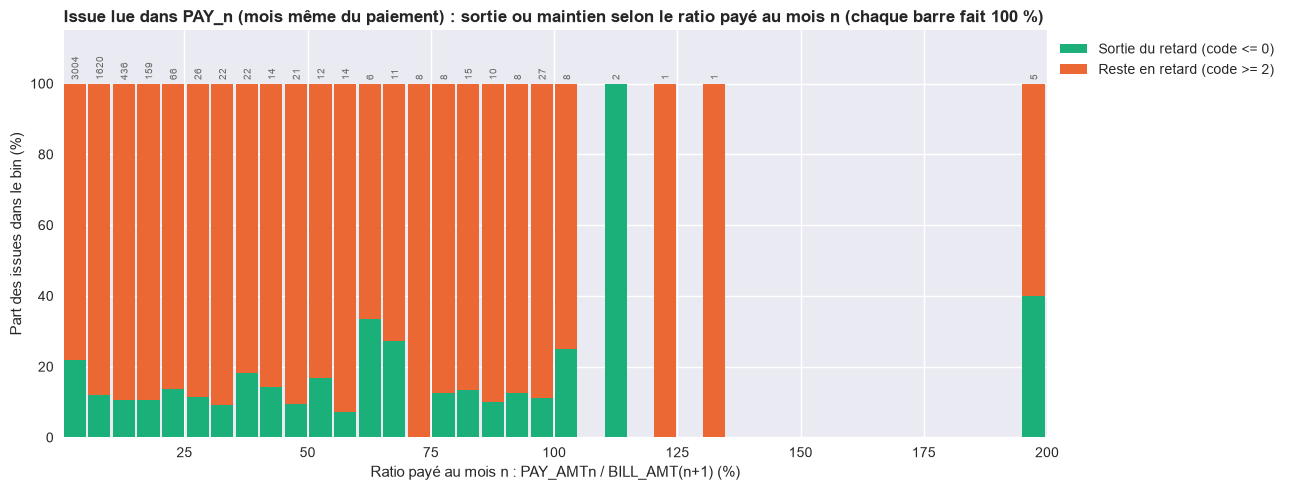


Issue lue dans PAY_(n-1) (mois suivant le paiement) : Reste en retard (code >= 2) : 3902 (70.6 %) | Sortie du retard (code <= 0) : 1624 (29.4 %)


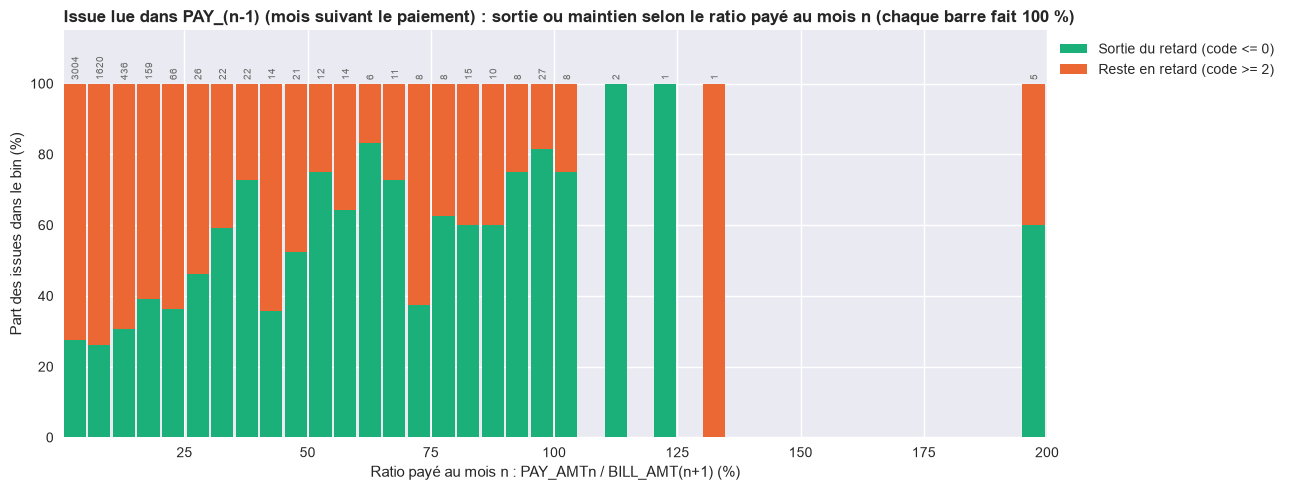


Issue lue dans Meilleur des deux (sorti en PAY_n ou en PAY_(n-1)) : Reste en retard (code >= 2) : 3894 (70.5 %) | Sortie du retard (code <= 0) : 1632 (29.5 %)


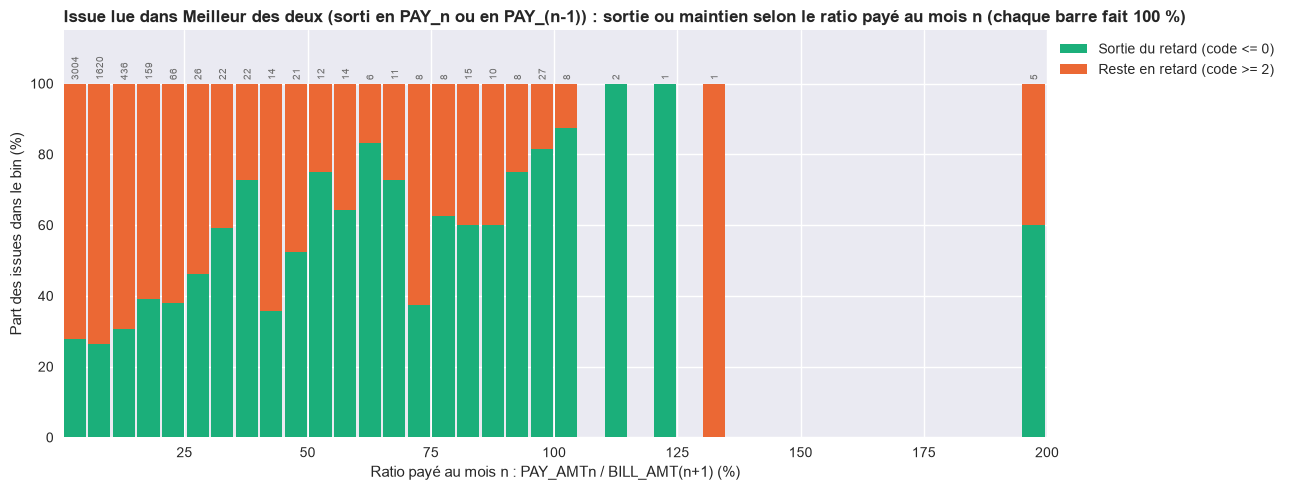

,Nb de cas,Sortie lue dans PAY_n (%),Sortie lue dans PAY_(n-1) (%),Sortie lue dans Meilleur des deux (%)
Ratio payé au mois n (%),,,,
0,6431,40.2,46.1,47.3
]0-3],856,46.1,52.2,53.3
]3-5],2419,19.3,24.8,24.8
]5-10],1742,13.8,26.6,26.7
]10-20],654,10.2,32.3,32.3
]20-50],180,13.9,47.8,48.3
]50-90],86,14.0,64.0,64.0
>= 90,52,19.2,76.9,78.8


In [59]:
# Sortie du retard : le paiement du mois n se voit-il dans PAY_n, dans PAY_(n-1), ou dans le meilleur des deux ?
# Nomenclature : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble. Départ : client en retard le mois précédent (PAY_(n+1) >= 2).
# Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1). Issue lue trois fois :
#   - PAY_n (mois même du paiement), PAY_(n-1) (mois suivant),
#   - meilleur des deux = min(PAY_n, PAY_(n-1)) : sorti si le code est <= 0 à l'un des deux mois (une rechute ensuite reste possible)
# n = 2 à 5 (PAY_(n-1) doit exister) ; factures dues seulement : BILL_AMT(n+1) > 0 ;
# cas exclus si PAY_n = 1 ou PAY_(n-1) = 1 (indéterminé), pour comparer les trois lectures sur la même population

# Paramètres à ajuster pour affiner les frontières
debut, fin = 0.5, 200     # plage de ratio étudiée (%)
nb_bins = 40              # nombre de bins de même largeur sur la plage

lignes = []
for n in range(2, 6):
    ok = (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+1}'] > 0)
    lignes.append(pd.DataFrame({
        'n': n,
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'PAY_(n-1)': df.loc[ok, f'PAY_{n-1}'],
        'Ratio': df.loc[ok, f'PAY_AMT{n}'] / df.loc[ok, f'BILL_AMT{n+1}'] * 100,
    }))
sorties = pd.concat(lignes, ignore_index=True)

code_1 = (sorties['PAY_n'] == 1) | (sorties['PAY_(n-1)'] == 1)
nb_depart = len(sorties)
sorties = sorties[~code_1].copy()
sorties['Meilleur des deux'] = sorties[['PAY_n', 'PAY_(n-1)']].min(axis=1)
print(f"Mois en retard le mois précédent (facture due) : {nb_depart}\n"
      f"  - exclus car PAY_n = 1 ou PAY_(n-1) = 1 (indéterminé) : {code_1.sum()}\n"
      f"  = mois étudiés : {len(sorties)}")

bornes = np.linspace(debut, fin, nb_bins + 1)
largeur_bin = (fin - debut) / nb_bins
# Bins fermés à gauche : [a, b[ (ratios au-delà de fin regroupés dans le dernier bin)
dans_plage = sorties[sorties['Ratio'] >= debut]
bin_gauche = pd.cut(dans_plage['Ratio'].clip(upper=fin - 1e-9), bornes, right=False, labels=bornes[:-1]).astype(float)
print(f"Plage [{debut} ; {fin}] en {nb_bins} bins de {largeur_bin:g} points : {len(dans_plage)} mois retenus, "
      f"{len(sorties) - len(dans_plage)} sous {debut} % (rien ou presque payé)")

couleurs_issue = {'Sortie du retard (code <= 0)': '#1baf7a', 'Reste en retard (code >= 2)': '#eb6834'}
effectifs = bin_gauche.value_counts().reindex(bornes[:-1], fill_value=0)
lectures = [('PAY_n', 'mois même du paiement'), ('PAY_(n-1)', 'mois suivant le paiement'),
            ('Meilleur des deux', 'sorti en PAY_n ou en PAY_(n-1)')]

for code_issue, moment in lectures:
    issue = pd.Series(np.where(dans_plage[code_issue] <= 0, 'Sortie du retard (code <= 0)', 'Reste en retard (code >= 2)'),
                      index=dans_plage.index)
    nb_issues = issue.value_counts()
    print(f"\nIssue lue dans {code_issue} ({moment}) : "
          + " | ".join(f"{k} : {v} ({v / len(issue) * 100:.1f} %)" for k, v in nb_issues.items()))

    # B. Dans chaque bin, part des sorties et des maintiens en retard (chaque barre fait 100 %)
    part_issues = pd.crosstab(bin_gauche, issue, normalize='index').reindex(columns=list(couleurs_issue), fill_value=0) * 100
    fig, ax = plt.subplots(figsize=(13, 5))
    bas = np.zeros(len(part_issues))
    for nom in couleurs_issue:
        ax.bar(part_issues.index, part_issues[nom], bottom=bas, width=0.9 * largeur_bin, align='edge',
               color=couleurs_issue[nom], label=nom)
        bas += part_issues[nom].values
    # Nombre de mois au-dessus des barres, seulement si les bins ne sont pas trop nombreux
    if nb_bins <= 40:
        for x, nb in effectifs.items():
            if nb > 0:
                ax.text(x + largeur_bin / 2, 101, f'{nb}', ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=90)
    ax.set_title(f'Issue lue dans {code_issue} ({moment}) : sortie ou maintien selon le ratio payé au mois n '
                 f'(chaque barre fait 100 %)', fontweight='bold', loc='left')
    ax.set_xlabel('Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1) (%)')
    ax.set_ylabel('Part des issues dans le bin (%)')
    ax.set_xlim(debut, fin)
    ax.set_ylim(0, 115)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# Tableau de synthèse : part des sorties selon la lecture, par tranche de ratio payé (tous les mois étudiés, ratio 0 compris)
tranche = pd.cut(sorties['Ratio'], [-0.1, 0, 3, 5, 10, 20, 50, 90, np.inf],
                 labels=['0', ']0-3]', ']3-5]', ']5-10]', ']10-20]', ']20-50]', ']50-90]', '>= 90'])
synthese = pd.DataFrame({'Nb de cas': sorties.groupby(tranche, observed=False).size()})
for code_issue, _ in lectures:
    synthese[f'Sortie lue dans {code_issue} (%)'] = (sorties[code_issue] <= 0).groupby(tranche, observed=False).mean() * 100
display(synthese.round(1).rename_axis('Ratio payé au mois n (%)'))


Mois en retard le mois précédent (facture due) : 9385
  - exclus car un des trois codes vaut 1 (indéterminé) : 777
  = mois étudiés : 8608
  rechutes neutralisées : 68 au mois + 1, 614 au mois + 2
Plage [0.5 ; 100] en 100 bins de 0.995 points : 3901 mois retenus, 4707 sous 0.5 % (rien ou presque payé)

Sortie jusqu'au mois même : Reste en retard (code >= 2) : 3298 (84.5 %) | Sortie du retard (code <= 0) : 603 (15.5 %)


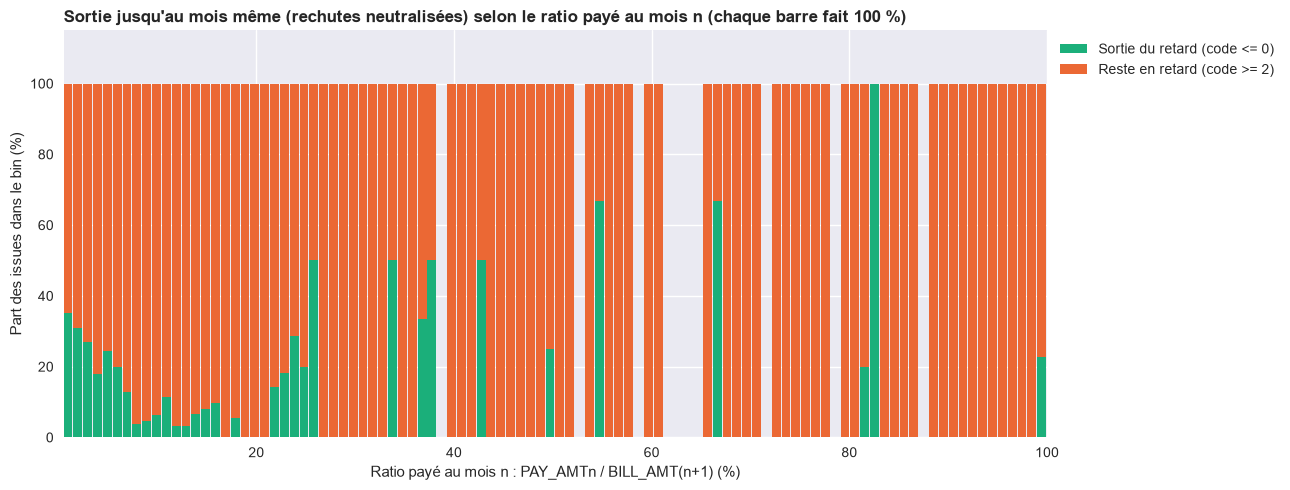


Sortie jusqu'au mois + 1 : Reste en retard (code >= 2) : 2677 (68.6 %) | Sortie du retard (code <= 0) : 1224 (31.4 %)


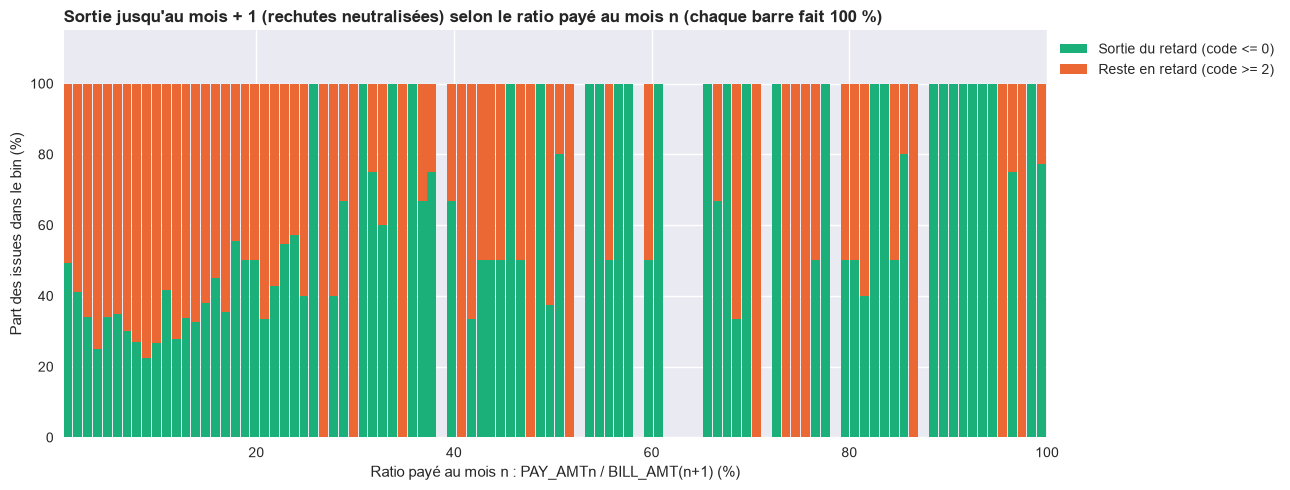


Sortie jusqu'au mois + 2 : Reste en retard (code >= 2) : 2456 (63.0 %) | Sortie du retard (code <= 0) : 1445 (37.0 %)


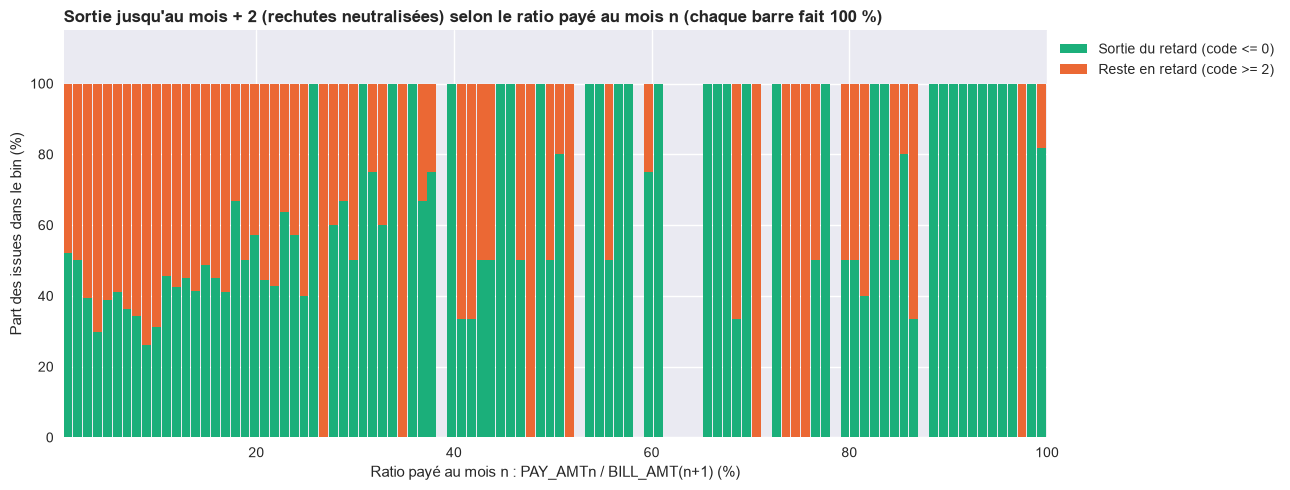

,Nb de cas,Sorti jusqu'au mois même (%),Sorti jusqu'au mois + 1 (%),Sorti jusqu'au mois + 2 (%)
Ratio payé au mois n (%),,,,
0,4434,40.8,49.0,55.9
]0-3],521,44.9,55.7,60.8
]3-5],1780,19.2,26.6,31.5
]5-10],1232,10.3,28.5,34.6
]10-20],417,6.0,37.4,44.8
]20-50],122,12.3,53.3,59.0
]50-90],67,9.0,61.2,67.2
>= 90,35,14.3,77.1,85.7



Payé >= 90 % et jamais sorti jusqu'au mois + 1 : 8 cas ; code au mois + 2 (PAY_(n-2)) :


,Nb de cas (%)
Code au mois + 2,
-1,3 (37.5 %)
2,4 (50.0 %)
3,1 (12.5 %)


In [60]:
# Sortie du retard, rechutes neutralisées : un client compte comme sorti dès que son code est passé <= 0,
# même s'il retombe en retard ensuite (lecture cumulative : meilleur code jusqu'au mois lu)
# Nomenclature : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble. Départ : client en retard le mois précédent (PAY_(n+1) >= 2).
# Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1).
# n = 3 à 5 (PAY_(n-2) doit exister) ; factures dues seulement : BILL_AMT(n+1) > 0 ;
# cas exclus si PAY_n, PAY_(n-1) ou PAY_(n-2) = 1 (indéterminé), pour comparer les trois lectures sur la même population

# Paramètres à ajuster pour affiner les frontières
debut, fin = 0.5, 100     # plage de ratio étudiée (%)
nb_bins = 100             # nombre de bins de même largeur sur la plage

lignes = []
for n in range(3, 6):
    ok = (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+1}'] > 0)
    lignes.append(pd.DataFrame({
        'n': n,
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'PAY_(n-1)': df.loc[ok, f'PAY_{n-1}'],
        'PAY_(n-2)': df.loc[ok, f'PAY_{n-2}'],
        'Ratio': df.loc[ok, f'PAY_AMT{n}'] / df.loc[ok, f'BILL_AMT{n+1}'] * 100,
    }))
sorties = pd.concat(lignes, ignore_index=True)

code_1 = (sorties[['PAY_n', 'PAY_(n-1)', 'PAY_(n-2)']] == 1).any(axis=1)
nb_depart = len(sorties)
sorties = sorties[~code_1].copy()

# Meilleur code atteint jusqu'au mois lu (rechutes neutralisées)
sorties['Jusqu\'au mois même'] = sorties['PAY_n']
sorties['Jusqu\'au mois + 1'] = sorties[['PAY_n', 'PAY_(n-1)']].min(axis=1)
sorties['Jusqu\'au mois + 2'] = sorties[['PAY_n', 'PAY_(n-1)', 'PAY_(n-2)']].min(axis=1)
lectures = ['Jusqu\'au mois même', 'Jusqu\'au mois + 1', 'Jusqu\'au mois + 2']

# Nombre de rechutes neutralisées : sorti à un mois, de nouveau en retard au mois lu
rechute_m1 = (sorties['PAY_n'] <= 0) & (sorties['PAY_(n-1)'] >= 2)
rechute_m2 = (sorties[['PAY_n', 'PAY_(n-1)']].min(axis=1) <= 0) & (sorties['PAY_(n-2)'] >= 2)
print(f"Mois en retard le mois précédent (facture due) : {nb_depart}\n"
      f"  - exclus car un des trois codes vaut 1 (indéterminé) : {code_1.sum()}\n"
      f"  = mois étudiés : {len(sorties)}\n"
      f"  rechutes neutralisées : {rechute_m1.sum()} au mois + 1, {rechute_m2.sum()} au mois + 2")

bornes = np.linspace(debut, fin, nb_bins + 1)
largeur_bin = (fin - debut) / nb_bins
# Bins fermés à gauche : [a, b[ (ratios au-delà de fin regroupés dans le dernier bin)
dans_plage = sorties[sorties['Ratio'] >= debut]
bin_gauche = pd.cut(dans_plage['Ratio'].clip(upper=fin - 1e-9), bornes, right=False, labels=bornes[:-1]).astype(float)
print(f"Plage [{debut} ; {fin}] en {nb_bins} bins de {largeur_bin:g} points : {len(dans_plage)} mois retenus, "
      f"{len(sorties) - len(dans_plage)} sous {debut} % (rien ou presque payé)")

couleurs_issue = {'Sortie du retard (code <= 0)': '#1baf7a', 'Reste en retard (code >= 2)': '#eb6834'}
effectifs = bin_gauche.value_counts().reindex(bornes[:-1], fill_value=0)

for lecture in lectures:
    issue = pd.Series(np.where(dans_plage[lecture] <= 0, 'Sortie du retard (code <= 0)', 'Reste en retard (code >= 2)'),
                      index=dans_plage.index)
    nb_issues = issue.value_counts()
    print(f"\nSortie {lecture.lower()} : "
          + " | ".join(f"{k} : {v} ({v / len(issue) * 100:.1f} %)" for k, v in nb_issues.items()))

    # B. Dans chaque bin, part des sorties et des maintiens en retard (chaque barre fait 100 %)
    part_issues = pd.crosstab(bin_gauche, issue, normalize='index').reindex(columns=list(couleurs_issue), fill_value=0) * 100
    fig, ax = plt.subplots(figsize=(13, 5))
    bas = np.zeros(len(part_issues))
    for nom in couleurs_issue:
        ax.bar(part_issues.index, part_issues[nom], bottom=bas, width=0.9 * largeur_bin, align='edge',
               color=couleurs_issue[nom], label=nom)
        bas += part_issues[nom].values
    # Nombre de mois au-dessus des barres, seulement si les bins ne sont pas trop nombreux
    if nb_bins <= 40:
        for x, nb in effectifs.items():
            if nb > 0:
                ax.text(x + largeur_bin / 2, 101, f'{nb}', ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=90)
    ax.set_title(f'Sortie {lecture.lower()} (rechutes neutralisées) selon le ratio payé au mois n '
                 f'(chaque barre fait 100 %)', fontweight='bold', loc='left')
    ax.set_xlabel('Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1) (%)')
    ax.set_ylabel('Part des issues dans le bin (%)')
    ax.set_xlim(debut, fin)
    ax.set_ylim(0, 115)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# Tableau de synthèse : part des sorties (cumulées) selon le mois de lecture, par tranche de ratio payé (ratio 0 compris)
tranche = pd.cut(sorties['Ratio'], [-0.1, 0, 3, 5, 10, 20, 50, 90, np.inf],
                 labels=['0', ']0-3]', ']3-5]', ']5-10]', ']10-20]', ']20-50]', ']50-90]', '>= 90'])
synthese = pd.DataFrame({'Nb de cas': sorties.groupby(tranche, observed=False).size()})
for lecture in lectures:
    synthese[f'Sorti {lecture.lower()} (%)'] = (sorties[lecture] <= 0).groupby(tranche, observed=False).mean() * 100
display(synthese.round(1).rename_axis('Ratio payé au mois n (%)'))

# Zoom : clients qui ont payé 90 % ou plus et ne sont toujours pas sortis au mois + 1 -> sortent-ils au mois + 2 ?
zoom = sorties[(sorties['Ratio'] >= 90) & (sorties['Jusqu\'au mois + 1'] >= 2)]
print(f"\nPayé >= 90 % et jamais sorti jusqu'au mois + 1 : {len(zoom)} cas ; code au mois + 2 (PAY_(n-2)) :")
nb = zoom['PAY_(n-2)'].value_counts().sort_index()
display(pd.DataFrame({'Nb de cas (%)': [f"{v} ({v / nb.sum() * 100:.1f} %)" for v in nb]}, index=nb.index)
        .rename_axis('Code au mois + 2'))


Mois en retard le mois précédent (facture due) : 9385
  - exclus car un des trois codes vaut 1 (indéterminé) : 777
  = mois étudiés : 8608
  rechutes neutralisées : 68 au mois + 1, 614 au mois + 2
Plage [50 ; 110] en 40 bins de 1.5 points : 107 mois retenus, 8501 sous 50 % (rien ou presque payé)

Sortie jusqu'au mois même : Reste en retard (code >= 2) : 94 (87.9 %) | Sortie du retard (code <= 0) : 13 (12.1 %)


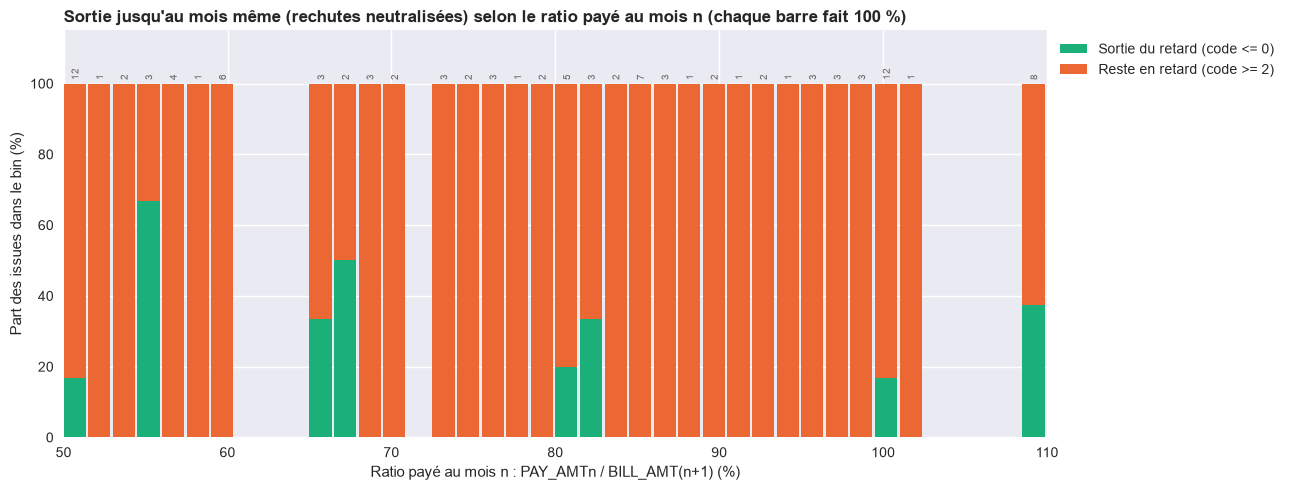


Sortie jusqu'au mois + 1 : Sortie du retard (code <= 0) : 71 (66.4 %) | Reste en retard (code >= 2) : 36 (33.6 %)


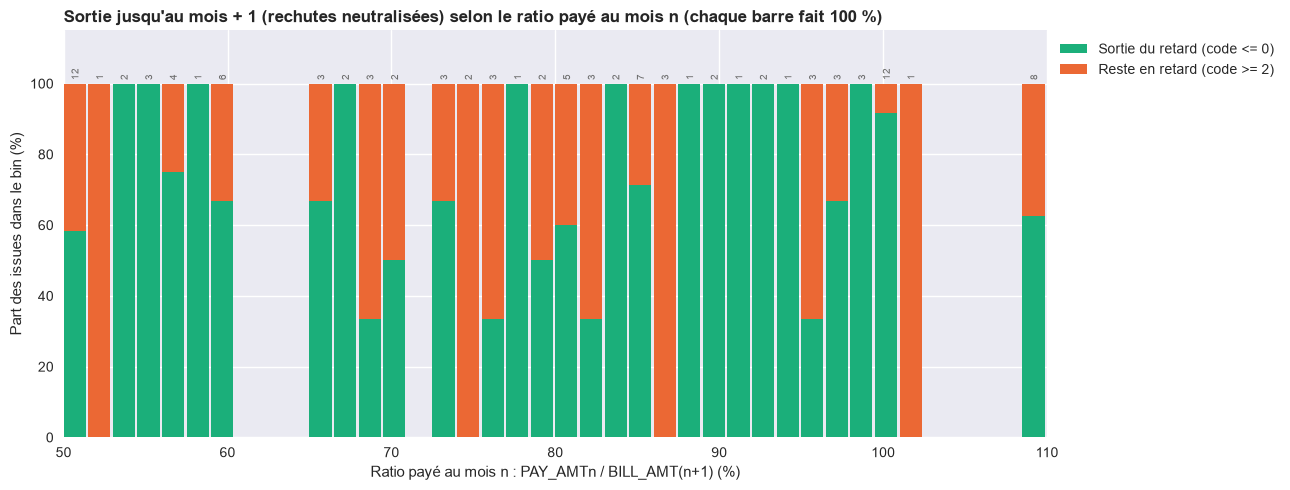


Sortie jusqu'au mois + 2 : Sortie du retard (code <= 0) : 78 (72.9 %) | Reste en retard (code >= 2) : 29 (27.1 %)


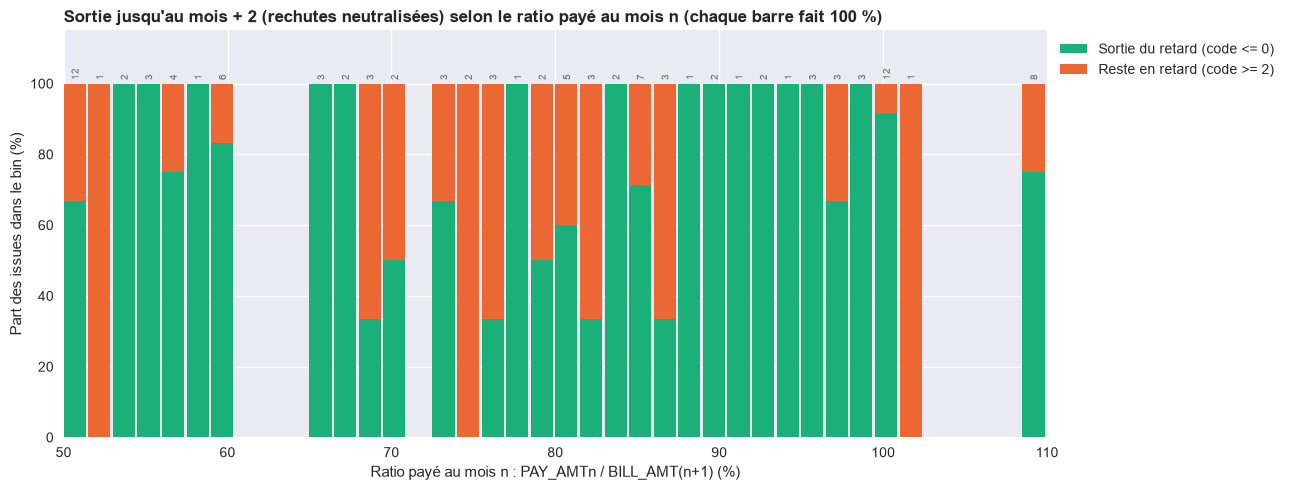

,Nb de cas,Sorti jusqu'au mois même (%),Sorti jusqu'au mois + 1 (%),Sorti jusqu'au mois + 2 (%)
Ratio payé au mois n (%),,,,
0,4434,40.8,49.0,55.9
]0-3],521,44.9,55.7,60.8
]3-5],1780,19.2,26.6,31.5
]5-10],1232,10.3,28.5,34.6
]10-20],417,6.0,37.4,44.8
]20-50],122,12.3,53.3,59.0
]50-90],67,9.0,61.2,67.2
>= 90,35,14.3,77.1,85.7



Payé >= 90 % et jamais sorti jusqu'au mois + 1 : 8 cas ; code au mois + 2 (PAY_(n-2)) :


,Nb de cas (%)
Code au mois + 2,
-1,3 (37.5 %)
2,4 (50.0 %)
3,1 (12.5 %)


In [61]:
# Sortie du retard, rechutes neutralisées : un client compte comme sorti dès que son code est passé <= 0,
# même s'il retombe en retard ensuite (lecture cumulative : meilleur code jusqu'au mois lu)
# Nomenclature : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble. Départ : client en retard le mois précédent (PAY_(n+1) >= 2).
# Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1).
# n = 3 à 5 (PAY_(n-2) doit exister) ; factures dues seulement : BILL_AMT(n+1) > 0 ;
# cas exclus si PAY_n, PAY_(n-1) ou PAY_(n-2) = 1 (indéterminé), pour comparer les trois lectures sur la même population

# Paramètres à ajuster pour affiner les frontières
debut, fin = 50, 110   # plage de ratio étudiée (%)
nb_bins = 40             # nombre de bins de même largeur sur la plage

lignes = []
for n in range(3, 6):
    ok = (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+1}'] > 0)
    lignes.append(pd.DataFrame({
        'n': n,
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'PAY_(n-1)': df.loc[ok, f'PAY_{n-1}'],
        'PAY_(n-2)': df.loc[ok, f'PAY_{n-2}'],
        'Ratio': df.loc[ok, f'PAY_AMT{n}'] / df.loc[ok, f'BILL_AMT{n+1}'] * 100,
    }))
sorties = pd.concat(lignes, ignore_index=True)

code_1 = (sorties[['PAY_n', 'PAY_(n-1)', 'PAY_(n-2)']] == 1).any(axis=1)
nb_depart = len(sorties)
sorties = sorties[~code_1].copy()

# Meilleur code atteint jusqu'au mois lu (rechutes neutralisées)
sorties['Jusqu\'au mois même'] = sorties['PAY_n']
sorties['Jusqu\'au mois + 1'] = sorties[['PAY_n', 'PAY_(n-1)']].min(axis=1)
sorties['Jusqu\'au mois + 2'] = sorties[['PAY_n', 'PAY_(n-1)', 'PAY_(n-2)']].min(axis=1)
lectures = ['Jusqu\'au mois même', 'Jusqu\'au mois + 1', 'Jusqu\'au mois + 2']

# Nombre de rechutes neutralisées : sorti à un mois, de nouveau en retard au mois lu
rechute_m1 = (sorties['PAY_n'] <= 0) & (sorties['PAY_(n-1)'] >= 2)
rechute_m2 = (sorties[['PAY_n', 'PAY_(n-1)']].min(axis=1) <= 0) & (sorties['PAY_(n-2)'] >= 2)
print(f"Mois en retard le mois précédent (facture due) : {nb_depart}\n"
      f"  - exclus car un des trois codes vaut 1 (indéterminé) : {code_1.sum()}\n"
      f"  = mois étudiés : {len(sorties)}\n"
      f"  rechutes neutralisées : {rechute_m1.sum()} au mois + 1, {rechute_m2.sum()} au mois + 2")

bornes = np.linspace(debut, fin, nb_bins + 1)
largeur_bin = (fin - debut) / nb_bins
# Bins fermés à gauche : [a, b[ (ratios au-delà de fin regroupés dans le dernier bin)
dans_plage = sorties[sorties['Ratio'] >= debut]
bin_gauche = pd.cut(dans_plage['Ratio'].clip(upper=fin - 1e-9), bornes, right=False, labels=bornes[:-1]).astype(float)
print(f"Plage [{debut} ; {fin}] en {nb_bins} bins de {largeur_bin:g} points : {len(dans_plage)} mois retenus, "
      f"{len(sorties) - len(dans_plage)} sous {debut} % (rien ou presque payé)")

couleurs_issue = {'Sortie du retard (code <= 0)': '#1baf7a', 'Reste en retard (code >= 2)': '#eb6834'}
effectifs = bin_gauche.value_counts().reindex(bornes[:-1], fill_value=0)

for lecture in lectures:
    issue = pd.Series(np.where(dans_plage[lecture] <= 0, 'Sortie du retard (code <= 0)', 'Reste en retard (code >= 2)'),
                      index=dans_plage.index)
    nb_issues = issue.value_counts()
    print(f"\nSortie {lecture.lower()} : "
          + " | ".join(f"{k} : {v} ({v / len(issue) * 100:.1f} %)" for k, v in nb_issues.items()))

    # B. Dans chaque bin, part des sorties et des maintiens en retard (chaque barre fait 100 %)
    part_issues = pd.crosstab(bin_gauche, issue, normalize='index').reindex(columns=list(couleurs_issue), fill_value=0) * 100
    fig, ax = plt.subplots(figsize=(13, 5))
    bas = np.zeros(len(part_issues))
    for nom in couleurs_issue:
        ax.bar(part_issues.index, part_issues[nom], bottom=bas, width=0.9 * largeur_bin, align='edge',
               color=couleurs_issue[nom], label=nom)
        bas += part_issues[nom].values
    # Nombre de mois au-dessus des barres, seulement si les bins ne sont pas trop nombreux
    if nb_bins <= 40:
        for x, nb in effectifs.items():
            if nb > 0:
                ax.text(x + largeur_bin / 2, 101, f'{nb}', ha='center', va='bottom', fontsize=7, color='dimgrey', rotation=90)
    ax.set_title(f'Sortie {lecture.lower()} (rechutes neutralisées) selon le ratio payé au mois n '
                 f'(chaque barre fait 100 %)', fontweight='bold', loc='left')
    ax.set_xlabel('Ratio payé au mois n : PAY_AMTn / BILL_AMT(n+1) (%)')
    ax.set_ylabel('Part des issues dans le bin (%)')
    ax.set_xlim(debut, fin)
    ax.set_ylim(0, 115)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# Tableau de synthèse : part des sorties (cumulées) selon le mois de lecture, par tranche de ratio payé (ratio 0 compris)
tranche = pd.cut(sorties['Ratio'], [-0.1, 0, 3, 5, 10, 20, 50, 90, np.inf],
                 labels=['0', ']0-3]', ']3-5]', ']5-10]', ']10-20]', ']20-50]', ']50-90]', '>= 90'])
synthese = pd.DataFrame({'Nb de cas': sorties.groupby(tranche, observed=False).size()})
for lecture in lectures:
    synthese[f'Sorti {lecture.lower()} (%)'] = (sorties[lecture] <= 0).groupby(tranche, observed=False).mean() * 100
display(synthese.round(1).rename_axis('Ratio payé au mois n (%)'))

# Zoom : clients qui ont payé 90 % ou plus et ne sont toujours pas sortis au mois + 1 -> sortent-ils au mois + 2 ?
zoom = sorties[(sorties['Ratio'] >= 90) & (sorties['Jusqu\'au mois + 1'] >= 2)]
print(f"\nPayé >= 90 % et jamais sorti jusqu'au mois + 1 : {len(zoom)} cas ; code au mois + 2 (PAY_(n-2)) :")
nb = zoom['PAY_(n-2)'].value_counts().sort_index()
display(pd.DataFrame({'Nb de cas (%)': [f"{v} ({v / nb.sum() * 100:.1f} %)" for v in nb]}, index=nb.index)
        .rename_axis('Code au mois + 2'))


**Interprétation**  
Il apparait évident que les codifications ne sont pas à jour  
on a vu dans EDA_contentieux que les régularisations de code mettent 1 mois, c'est à dire la codification PAY_n-1
plus le ratio de paiement est élevé plus la sortie du retard est importante mais il reste des anomalies (des paiements à+200% non régularisés par exemples)  
Le décalage d'un mois existe : plus le client paie au mois n, plus la sortie apparaît dans le code du mois suivant. Ceux qui ne paient presque rien servent de témoin.  
Il n'y a pas de frontière de ratio nette : la sortie augmente progressivement avec le montant payé. On ne peut donc pas fixer un seuil de sortie nette justifié par les données.  
Payer le solde ne suffit pas toujours : environ un quart de ceux qui paient 90 % ou plus restent en retard le mois suivant, sur de petits effectifs. Cela s'explique par un arriéré qu'on ne voit pas, ou par un décalage plus long.  
Les rechutes ne comptent pas : le « meilleur des deux codes » ne change presque rien.  
**Conclusion** : fixer la sortie du CTX à un paiement de 90 % ou plus du solde est un bon consensus. Au sens métier, le solde est payé, donc il n'y a plus d'arriéré. Les données vont dans le même sens : marche nette à 100 % entre les codes 0 et -1, changement de régime des sorties autour de 86-90 %. Un client qui a remboursé sa dette et reste codé en retard relève d'une anomalie :  
- soit son compte reste figé en incident et il ne peut plus avoir d'encours : il sort du périmètre du ML (pas d'encours en M-1) ;  
- soit il peut de nouveau avoir un encours, et le code de retard est une erreur de codification : la règle « retard payé » (`05_02`) le considère régularisé et le garde dans le ML.
 

In [62]:
# Une baisse du solde fait-elle baisser la codification de retard ? (sans dpnm)
# Nomenclature : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble. Départ : client en retard au mois n+1 (PAY_(n+1) >= 2), facture due.
# Évolution du solde entre le relevé BILL_AMT(n+1) et le relevé suivant BILL_AMTn ;
# codification lue au mois n (M : PAY_n) et au mois suivant (M+1 : PAY_(n-1)). n = 2 à 5 ;
# cas exclus si PAY_n ou PAY_(n-1) = 1 (codification indéterminée)
lignes = []
for n in range(2, 6):
    ok = (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+1}'] > 0)
    lignes.append(pd.DataFrame({
        'PAY_(n+1)': df.loc[ok, f'PAY_{n+1}'],
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'PAY_(n-1)': df.loc[ok, f'PAY_{n-1}'],
        'Évolution du solde (%)': (df.loc[ok, f'BILL_AMT{n}'] - df.loc[ok, f'BILL_AMT{n+1}']) / df.loc[ok, f'BILL_AMT{n+1}'] * 100,
    }))
solde = pd.concat(lignes, ignore_index=True)
indetermine = (solde['PAY_n'] == 1) | (solde['PAY_(n-1)'] == 1)
print(f"Mois avec PAY_(n+1) >= 2 (facture due) : {len(solde)} | exclus car PAY_n ou PAY_(n-1) = 1 : {indetermine.sum()}")
solde = solde[~indetermine]

tranche = pd.cut(solde['Évolution du solde (%)'], [-np.inf, -90, -50, -10, -1, 1, 10, np.inf],
                 labels=['baisse > 90 %', 'baisse 50-90 %', 'baisse 10-50 %', 'baisse 1-10 %', 'stable (± 1 %)',
                         'hausse 1-10 %', 'hausse > 10 %'])
resultat = pd.DataFrame({
    'Nb de cas': solde.groupby(tranche, observed=False).size(),
    'PAY_n < PAY_(n+1) (%)': (solde['PAY_n'] < solde['PAY_(n+1)']).groupby(tranche, observed=False).mean() * 100,
    'PAY_n <= 0 (%)': (solde['PAY_n'] <= 0).groupby(tranche, observed=False).mean() * 100,
    'PAY_(n-1) < PAY_(n+1) (%)': (solde['PAY_(n-1)'] < solde['PAY_(n+1)']).groupby(tranche, observed=False).mean() * 100,
    'PAY_(n-1) <= 0 (%)': (solde['PAY_(n-1)'] <= 0).groupby(tranche, observed=False).mean() * 100,
}).round(1)
display(resultat.rename_axis('Évolution du solde : BILL_AMTn par rapport à BILL_AMT(n+1)'))

print("Lecture : départ PAY_(n+1) >= 2 ; à M (PAY_n) puis à M+1 (PAY_(n-1)), part des cas où la codification a baissé, "
      "et part des cas sortis du retard (codification <= 0).")


Mois avec PAY_(n+1) >= 2 (facture due) : 13469 | exclus car PAY_n ou PAY_(n-1) = 1 : 1049


,Nb de cas,PAY_n < PAY_(n+1) (%),PAY_n <= 0 (%),PAY_(n-1) < PAY_(n+1) (%),PAY_(n-1) <= 0 (%)
Évolution du solde : BILL_AMTn par rapport à BILL_AMT(n+1),,,,,
baisse > 90 %,14,21.4,14.3,92.9,85.7
baisse 50-90 %,59,8.5,8.5,66.1,64.4
baisse 10-50 %,513,11.5,10.1,39.6,38.2
baisse 1-10 %,3707,15.0,13.4,25.3,23.3
stable (± 1 %),1358,29.4,19.4,42.1,23.5
hausse 1-10 %,4958,42.1,37.5,49.6,44.5
hausse > 10 %,1811,62.4,61.9,68.9,68.1


Lecture : départ PAY_(n+1) >= 2 ; à M (PAY_n) puis à M+1 (PAY_(n-1)), part des cas où la codification a baissé, et part des cas sortis du retard (codification <= 0).


In [63]:
# Sortie du retard à M+1 selon l'évolution du solde ET le ratio de paiement (sans dpnm)
# Nomenclature : PAY_n, PAY_AMTn et BILL_AMT(n+1) vont ensemble. Départ : client en retard au mois n+1 (PAY_(n+1) >= 2), facture due.
# Évolution du solde : relevé BILL_AMT(n+1) -> relevé suivant BILL_AMTn ; ratio de paiement du mois n : PAY_AMTn / BILL_AMT(n+1).
# Sortie lue à M+1 : PAY_(n-1) <= 0 (décalage d'un mois). n = 2 à 5 ; cas exclus si PAY_n ou PAY_(n-1) = 1 (codification indéterminée)
lignes = []
for n in range(2, 6):
    ok = (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+1}'] > 0)
    lignes.append(pd.DataFrame({
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'PAY_(n-1)': df.loc[ok, f'PAY_{n-1}'],
        'Évolution du solde (%)': (df.loc[ok, f'BILL_AMT{n}'] - df.loc[ok, f'BILL_AMT{n+1}']) / df.loc[ok, f'BILL_AMT{n+1}'] * 100,
        'Ratio de paiement (%)': df.loc[ok, f'PAY_AMT{n}'] / df.loc[ok, f'BILL_AMT{n+1}'] * 100,
    }))
croise = pd.concat(lignes, ignore_index=True)
croise = croise[(croise['PAY_n'] != 1) & (croise['PAY_(n-1)'] != 1)]

tranche_solde = pd.cut(croise['Évolution du solde (%)'], [-np.inf, -90, -50, -10, -1, 1, 10, 20, np.inf],
                       labels=['baisse > 90 %', 'baisse 50-90 %', 'baisse 10-50 %', 'baisse 1-10 %', 'stable (± 1 %)',
                               'hausse 1-10 %', 'hausse 10-20 %', 'hausse > 20 %'])
tranche_ratio = pd.cut(croise['Ratio de paiement (%)'], [-np.inf, 0, 10, 50, 90, np.inf], right=False,
                       labels=['0 %', '0-10 %', '10-50 %', '50-90 %', '90 % et plus'])
# right=False : bins [a, b[ ; un ratio nul tombe dans « 0 % » grâce à la borne 0 exclue à droite du premier bin
tranche_ratio = tranche_ratio.where(croise['Ratio de paiement (%)'] > 0, '0 %')

def sortie_nb(x):
    # Part des cas sortis du retard à M+1 (nombre de cas)
    return f"{x.mean() * 100:.0f} % ({len(x)})"

tableau = pd.crosstab(tranche_solde, tranche_ratio, values=croise['PAY_(n-1)'] <= 0, aggfunc=sortie_nb).fillna('-')
display(tableau.rename_axis(index='Évolution du solde', columns='Ratio de paiement du mois n'))
print("Lecture : chaque case = part des clients sortis du retard à M+1 (PAY_(n-1) <= 0), et entre parenthèses le nombre de cas.")

Ratio de paiement du mois n,0 %,0-10 %,10-50 %,50-90 %,90 % et plus
Évolution du solde,,,,,
baisse > 90 %,-,-,-,-,86 % (14)
baisse 50-90 %,100 % (1),0 % (1),-,64 % (44),69 % (13)
baisse 10-50 %,67 % (18),50 % (10),35 % (452),62 % (32),100 % (1)
baisse 1-10 %,-,23 % (3415),29 % (289),100 % (1),50 % (2)
stable (± 1 %),15 % (713),33 % (632),50 % (6),50 % (6),100 % (1)
hausse 1-10 %,44 % (4343),48 % (589),39 % (23),0 % (1),0 % (2)
hausse 10-20 %,59 % (326),54 % (115),69 % (13),-,-
hausse > 20 %,72 % (1030),69 % (254),72 % (46),75 % (8),84 % (19)


Lecture : chaque case = part des clients sortis du retard à M+1 (PAY_(n-1) <= 0), et entre parenthèses le nombre de cas.


**Interprétation**  
Départ : client en retard au mois n+1 (PAY_(n+1) >= 2). On suit l'évolution du solde entre les relevés BILL_AMT(n+1) et BILL_AMTn, le ratio de paiement du mois n (PAY_AMTn / BILL_AMT(n+1)), puis la codification au mois n (PAY_n) et au mois suivant (PAY_(n-1)).
- **Une forte baisse du solde ne fait presque pas baisser PAY_n, mais fait baisser PAY_(n-1) dans la majorité des cas** : le client rembourse au mois n, la codification ne suit qu'un mois plus tard. On retrouve, par une autre méthode, le décalage d'un mois déjà mesuré avec les ratios de paiement.
- **Un paiement de 90 % ou plus fait sortir la grande majorité des clients à M+1**, que le solde baisse (dette remboursée) ou monte (dette remboursée puis nouveaux achats, ce qui est normal). En dessous de 90 %, le ratio de paiement du mois ne sépare pas les sorties des maintiens en retard.
- **Données contre-intuitives en l'état** : sans aucun paiement au mois n, plus le solde augmente, plus la sortie du retard est fréquente, comme si dépenser sans payer favorisait la régularisation. Une première lecture l'explique par le décalage : ces clients ont le plus souvent payé une part importante de leur dette le mois précédent (PAY_AMT(n+1)), leur carte a été débloquée, ils refont des achats au mois n et paient de nouveau le mois suivant. La hausse du solde serait alors une conséquence d'un remboursement déjà fait, invisible si l'on ne regarde qu'un mois de paiement. **Point à investiguer davantage.**
- Une hausse modérée du solde peut aussi venir des intérêts et des pénalités de retard qui s'accumulent sans aucun achat : seule une forte hausse signale vraisemblablement une carte réutilisée.

**Conséquence pour la population contentieuse** : parmi les clients au CTX à M (définition 2, train), seule une petite part a un solde en forte hausse en M-1. Pour la plupart, ce n'est pas une régularisation masquée : ils ont beaucoup utilisé leur carte puis manqué leur paiement (retard qui commence, souvent une entrée au CTX en M-1), sans paiement significatif en M-1 ni en M-2. La règle du contentieux (retard payé : facture réglée à 90 % ou plus en M-1 ou M-2) fait donc la régularisation à temps.  
Quelques clients remis à 2 par le recodage du mois de transition avaient PAY_1 = -1 et un solde en forte hausse (paiement différé probable) : cas trop rares pour modifier la règle ; un éventuel modèle sur la population contentieuse pourrait les départager.

In [64]:
# Sortie du retard selon ce qui a été payé en cumul sur 2 mois et l'évolution du solde sur 2 mois (sans dpnm)
# Nomenclature : PAY_k, PAY_AMTk et BILL_AMT(k+1) vont ensemble (PAY_AMTk rembourse le relevé BILL_AMT(k+1)).
# Départ : série d'au moins 2 mois en retard, PAY_(n+2) >= 2 et PAY_(n+1) >= 2.
# Payé sur 2 mois : PAY_AMT(n+1) + PAY_AMTn.
# Dû sur 2 mois : dette de départ BILL_AMT(n+2) + nouveaux achats et frais du mois n+1 = BILL_AMT(n+1) + PAY_AMT(n+1)
#   (un client qui solde tout d'un coup sans nouveaux achats a un ratio de 100 %, pas de 50 % comme avec une moyenne).
# Évolution du solde sur 2 mois : BILL_AMT(n+2) -> BILL_AMTn.
# Régularisation lue à n (PAY_n <= 0) et à n-1 (PAY_(n-1) <= 0, décalage d'un mois). n = 2 à 4 ;
# cas exclus si PAY_n ou PAY_(n-1) = 1 (codification indéterminée).
lignes = []
for n in range(2, 5):
    ok = (df[f'PAY_{n+2}'] >= 2) & (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+2}'] > 0)
    paye = df.loc[ok, f'PAY_AMT{n+1}'] + df.loc[ok, f'PAY_AMT{n}']
    du = df.loc[ok, f'BILL_AMT{n+1}'] + df.loc[ok, f'PAY_AMT{n+1}']
    lignes.append(pd.DataFrame({
        'PAY_n': df.loc[ok, f'PAY_{n}'],
        'PAY_(n-1)': df.loc[ok, f'PAY_{n-1}'],
        'Ratio cumulé sur 2 mois (%)': (paye / du.where(du > 0) * 100).fillna(100),   # rien dû sur la période : considéré soldé
        'Évolution du solde sur 2 mois (%)': (df.loc[ok, f'BILL_AMT{n}'] - df.loc[ok, f'BILL_AMT{n+2}']) / df.loc[ok, f'BILL_AMT{n+2}'] * 100,
    }))
deux_mois = pd.concat(lignes, ignore_index=True)
indetermine = (deux_mois['PAY_n'] == 1) | (deux_mois['PAY_(n-1)'] == 1)
print(f"Séries d'au moins 2 mois en retard (PAY_(n+2) et PAY_(n+1) >= 2) : {len(deux_mois)} "
      f"| exclues car PAY_n ou PAY_(n-1) = 1 : {indetermine.sum()}")
deux_mois = deux_mois[~indetermine]

tranche_solde = pd.cut(deux_mois['Évolution du solde sur 2 mois (%)'], [-np.inf, -90, -50, -10, -1, 1, 10, 20, np.inf],
                       labels=['baisse > 90 %', 'baisse 50-90 %', 'baisse 10-50 %', 'baisse 1-10 %', 'stable (± 1 %)',
                               'hausse 1-10 %', 'hausse 10-20 %', 'hausse > 20 %'])
ratio = deux_mois['Ratio cumulé sur 2 mois (%)']
tranche_ratio = pd.Series(np.select([ratio <= 0, ratio < 10, ratio < 50, ratio < 90], ['0 %', '0-10 %', '10-50 %', '50-90 %'],
                                    default='90 % et plus'), index=deux_mois.index)
tranche_ratio = pd.Categorical(tranche_ratio, categories=['0 %', '0-10 %', '10-50 %', '50-90 %', '90 % et plus'])

def sortie_nb(x):
    # Part des cas régularisés (nombre de cas)
    return f"{x.mean() * 100:.0f} % ({len(x)})" if len(x) else '-'

for code, moment in [('PAY_n', 'à n'), ('PAY_(n-1)', 'à n-1 (décalage d\'un mois)')]:
    print(f"\nRégularisés {moment} : {code} <= 0")
    tableau = pd.crosstab(tranche_solde, tranche_ratio, values=deux_mois[code] <= 0, aggfunc=sortie_nb, dropna=False).fillna('-')
    display(tableau.rename_axis(index='Évolution du solde sur 2 mois', columns='Payé en cumul sur 2 mois / dû sur 2 mois'))
print("Lecture : chaque case = part des clients régularisés, et entre parenthèses le nombre de cas.")

Séries d'au moins 2 mois en retard (PAY_(n+2) et PAY_(n+1) >= 2) : 6776 | exclues car PAY_n ou PAY_(n-1) = 1 : 728

Régularisés à n : PAY_n <= 0


Payé en cumul sur 2 mois / dû sur 2 mois,0 %,0-10 %,10-50 %,50-90 %,90 % et plus
Évolution du solde sur 2 mois,,,,,
baisse > 90 %,-,-,-,-,58 % (12)
baisse 50-90 %,-,-,-,41 % (51),50 % (8)
baisse 10-50 %,0 % (1),36 % (11),18 % (479),41 % (27),50 % (2)
baisse 1-10 %,-,14 % (2069),13 % (838),0 % (1),0 % (1)
stable (± 1 %),2 % (436),21 % (556),15 % (13),0 % (1),-
hausse 1-10 %,13 % (315),23 % (615),30 % (53),0 % (3),-
hausse 10-20 %,25 % (20),33 % (116),29 % (28),0 % (3),-
hausse > 20 %,29 % (83),28 % (201),40 % (85),32 % (19),100 % (1)



Régularisés à n-1 (décalage d'un mois) : PAY_(n-1) <= 0


Payé en cumul sur 2 mois / dû sur 2 mois,0 %,0-10 %,10-50 %,50-90 %,90 % et plus
Évolution du solde sur 2 mois,,,,,
baisse > 90 %,-,-,-,-,75 % (12)
baisse 50-90 %,-,-,-,51 % (51),75 % (8)
baisse 10-50 %,0 % (1),36 % (11),34 % (479),70 % (27),0 % (2)
baisse 1-10 %,-,21 % (2069),24 % (838),100 % (1),0 % (1)
stable (± 1 %),4 % (436),28 % (556),46 % (13),0 % (1),-
hausse 1-10 %,22 % (315),29 % (615),49 % (53),33 % (3),-
hausse 10-20 %,35 % (20),36 % (116),54 % (28),33 % (3),-
hausse > 20 %,28 % (83),35 % (201),55 % (85),53 % (19),100 % (1)


Lecture : chaque case = part des clients régularisés, et entre parenthèses le nombre de cas.


**Interprétation**  
Départ : série d'au moins 2 mois en retard (PAY_(n+2) et PAY_(n+1) >= 2). Payé en cumul sur 2 mois : PAY_AMT(n+1) + PAY_AMTn, rapporté à tout ce qui était dû sur la période (BILL_AMT(n+1) + PAY_AMT(n+1)). Régularisation lue à n (PAY_n <= 0) et à n-1 (PAY_(n-1) <= 0).
- **En cumulant 2 mois de paiement, l'effet contre-intuitif du tableau précédent disparaît en grande partie** : les clients sans paiement au mois n mais au solde en forte hausse avaient le plus souvent payé le mois d'avant ; ils passent dans les tranches de ratio plus élevées. Le décalage de paiement explique l'essentiel du paradoxe.
- **La régularisation augmente avec ce qui a été payé en cumul**, de façon progressive et sans frontière brutale ; au-delà de 90 % du dû, la plupart des clients sortent du retard.
- **Ne rien payer sur 2 mois avec un solde stable ne mène presque jamais à une régularisation** : ce sont les comptes réellement à l'arrêt.
- **Il reste des sorties sans aucun paiement visible sur 2 mois**, même avec un solde qui grossit. Une partie s'explique par un paiement plus ancien (PAY_AMT(n+2)), souvent partiel ; les autres concernent surtout des retards courts (PAY_(n+2) à 2 ou 3) et coïncident avec une reprise des paiements le mois suivant, ce qui évoque un arrangement avec la banque (rééchelonnement, plan de remboursement) non visible dans les données. Effectifs faibles : ce sont des indices, pas des preuves.

**Conclusion** : payer ne semble pas être le seul facteur de sortie de la codification 2. Le montant payé compte, mais l'ancienneté du retard et des éléments absents du dataset (arriéré réel, arrangements, procédure de recouvrement) interviennent aussi.

In [65]:
# Ce qui distingue les séries qui sortent de la codification 2 de celles qui restent (sans dpnm)
# Nomenclature : PAY_k, PAY_AMTk et BILL_AMT(k+1) vont ensemble (PAY_AMTk rembourse le relevé BILL_AMT(k+1)).
# Départ : série d'au moins 2 mois en retard, PAY_(n+2) >= 2 et PAY_(n+1) >= 2 ; n = 2 à 4.
# Issue : sortie du retard si PAY_n <= 0 ou PAY_(n-1) <= 0 (décalage d'un mois, rechutes neutralisées), maintien si les deux sont >= 2 ;
# cas exclus si PAY_n ou PAY_(n-1) = 1 (codification indéterminée).
lignes = []
for n in range(2, 5):
    ok = (df[f'PAY_{n+2}'] >= 2) & (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+2}'] > 0)
    d = df[ok]
    # Durée de la série : mois consécutifs à >= 2 à partir de PAY_(n+1) en remontant vers M-6
    duree = (d[[f'PAY_{k}' for k in range(n + 1, 7)]] >= 2).cumprod(axis=1).sum(axis=1)
    # Codification d'avant la série : premier PAY_k < 2 en remontant (inconnue si la série remonte jusqu'à M-6)
    avant = pd.Series('inconnue (série depuis M-6)', index=d.index)
    a_chercher = pd.Series(True, index=d.index)
    for k in range(n + 1, 7):
        trouve = a_chercher & (d[f'PAY_{k}'] < 2)
        avant[trouve] = d.loc[trouve, f'PAY_{k}'].clip(lower=-2, upper=0).astype(int).astype(str)
        a_chercher &= ~trouve
    paye = d[f'PAY_AMT{n+1}'] + d[f'PAY_AMT{n}']
    du = d[f'BILL_AMT{n+1}'] + d[f'PAY_AMT{n+1}']
    lignes.append(pd.DataFrame({
        'PAY_n': d[f'PAY_{n}'], 'PAY_(n-1)': d[f'PAY_{n-1}'],
        'PAY_(n+1)': d[f'PAY_{n+1}'],
        'Durée de la série (mois)': duree,
        "Codification d'avant la série": avant,
        'Mois avec paiement de M-6 au mois n+1 (%)': (d[[f'PAY_AMT{k}' for k in range(n + 1, 7)]] > 0).mean(axis=1) * 100,
        'Payé en cumul sur 2 mois / dû (%)': (paye / du.where(du > 0) * 100).fillna(100),
        'Évolution du solde sur 2 mois (%)': (d[f'BILL_AMT{n}'] - d[f'BILL_AMT{n+2}']) / d[f'BILL_AMT{n+2}'] * 100,
        'Dette BILL_AMT(n+1) (NT$)': d[f'BILL_AMT{n+1}'],
        'Plafond LIMIT_BAL (NT$)': d['LIMIT_BAL'],
        'Utilisation du plafond BILL_AMT(n+1) / LIMIT_BAL (%)': d[f'BILL_AMT{n+1}'] / d['LIMIT_BAL'] * 100,
    }))
comp = pd.concat(lignes, ignore_index=True)
indetermine = (comp['PAY_n'] == 1) | (comp['PAY_(n-1)'] == 1)
comp = comp[~indetermine]
issue = pd.Series(np.where((comp['PAY_n'] <= 0) | (comp['PAY_(n-1)'] <= 0), 'Sortis du retard', 'Restés en retard'), index=comp.index, name='Issue')
print(f"Séries d'au moins 2 mois en retard : {len(comp)} (exclues car PAY_n ou PAY_(n-1) = 1 : {indetermine.sum()}) | "
      + " | ".join(f"{k} : {v}" for k, v in issue.value_counts().items()))

# 1. Facteurs numériques : médianes
numeriques = ['Durée de la série (mois)', 'Mois avec paiement de M-6 au mois n+1 (%)', 'Payé en cumul sur 2 mois / dû (%)',
              'Évolution du solde sur 2 mois (%)', 'Dette BILL_AMT(n+1) (NT$)', 'Plafond LIMIT_BAL (NT$)',
              'Utilisation du plafond BILL_AMT(n+1) / LIMIT_BAL (%)']
print("\n1. Médianes des facteurs numériques :")
display(comp[numeriques].groupby(issue).median().T.round(1).rename_axis('Facteur'))

# 2. Facteurs catégoriels : répartition dans chaque groupe (chaque colonne fait 100 %)
def repartition(serie):
    nb = pd.crosstab(serie, issue)
    pct = pd.crosstab(serie, issue, normalize='columns') * 100
    return nb.astype(str) + ' (' + pct.round(1).astype(str) + ' %)'

print("2. Niveau de retard au départ, PAY_(n+1) (nombre de cas, part du groupe) :")
display(repartition(comp['PAY_(n+1)'].clip(upper=5).map(lambda x: '5 et plus' if x >= 5 else str(x))))
print("3. Codification d'avant la série (nombre de cas, part du groupe) :")
display(repartition(comp["Codification d'avant la série"]))


Séries d'au moins 2 mois en retard : 6048 (exclues car PAY_n ou PAY_(n-1) = 1 : 728) | Restés en retard : 4490 | Sortis du retard : 1558

1. Médianes des facteurs numériques :


Issue,Restés en retard,Sortis du retard
Facteur,,
Durée de la série (mois),3.0,2.0
Mois avec paiement de M-6 au mois n+1 (%),66.7,66.7
Payé en cumul sur 2 mois / dû (%),7.5,7.9
Évolution du solde sur 2 mois (%),-2.7,-2.5
Dette BILL_AMT(n+1) (NT$),33691.0,28921.0
Plafond LIMIT_BAL (NT$),70000.0,70000.0
Utilisation du plafond BILL_AMT(n+1) / LIMIT_BAL (%),69.9,62.4


2. Niveau de retard au départ, PAY_(n+1) (nombre de cas, part du groupe) :


Issue,Restés en retard,Sortis du retard
PAY_(n+1),,
2,3657 (81.4 %),1414 (90.8 %)
3,399 (8.9 %),119 (7.6 %)
4,194 (4.3 %),20 (1.3 %)
5 et plus,240 (5.3 %),5 (0.3 %)


3. Codification d'avant la série (nombre de cas, part du groupe) :


Issue,Restés en retard,Sortis du retard
Codification d'avant la série,,
-1,30 (0.7 %),43 (2.8 %)
-2,21 (0.5 %),14 (0.9 %)
0,598 (13.3 %),325 (20.9 %)
inconnue (série depuis M-6),3841 (85.5 %),1176 (75.5 %)


**Interprétation**  
seule la gravité de la codification PAY_n semble jouer une différence sur la sortie du statut d'impayé

In [66]:
# Régularisation selon le payé en cumul sur 2 mois et l'évolution du solde sur 2 mois, séparément pour les séries à PAY = 2 et à PAY > 2 (sans dpnm)
# Nomenclature : PAY_k, PAY_AMTk et BILL_AMT(k+1) vont ensemble (PAY_AMTk rembourse le relevé BILL_AMT(k+1)).
# Départ : série d'au moins 2 mois en retard, PAY_(n+2) >= 2 et PAY_(n+1) >= 2 ; n = 2 à 4.
#   série à PAY = 2 : PAY_(n+2) = 2 et PAY_(n+1) = 2 ; série à PAY > 2 : au moins un des deux mois > 2.
# Payé en cumul sur 2 mois : PAY_AMT(n+1) + PAY_AMTn ; dû sur 2 mois : BILL_AMT(n+1) + PAY_AMT(n+1).
# Évolution du solde sur 2 mois : BILL_AMT(n+2) -> BILL_AMTn.
# Régularisation lue à n (PAY_n <= 0) et à n-1 (PAY_(n-1) <= 0, décalage d'un mois) ; cas exclus si PAY_n ou PAY_(n-1) = 1.
lignes = []
for n in range(2, 5):
    ok = (df[f'PAY_{n+2}'] >= 2) & (df[f'PAY_{n+1}'] >= 2) & (df[f'BILL_AMT{n+2}'] > 0)
    d = df[ok]
    paye = d[f'PAY_AMT{n+1}'] + d[f'PAY_AMT{n}']
    du = d[f'BILL_AMT{n+1}'] + d[f'PAY_AMT{n+1}']
    lignes.append(pd.DataFrame({
        'Série': np.where((d[f'PAY_{n+2}'] == 2) & (d[f'PAY_{n+1}'] == 2), 'Série à PAY = 2', 'Série à PAY > 2'),
        'PAY_n': d[f'PAY_{n}'], 'PAY_(n-1)': d[f'PAY_{n-1}'],
        'Ratio cumulé sur 2 mois (%)': (paye / du.where(du > 0) * 100).fillna(100),
        'Évolution du solde sur 2 mois (%)': (d[f'BILL_AMT{n}'] - d[f'BILL_AMT{n+2}']) / d[f'BILL_AMT{n+2}'] * 100,
    }))
niveau = pd.concat(lignes, ignore_index=True)
niveau = niveau[(niveau['PAY_n'] != 1) & (niveau['PAY_(n-1)'] != 1)]

ordre_solde = ['baisse > 90 %', 'baisse 50-90 %', 'baisse 10-50 %', 'baisse 1-10 %', 'stable (± 1 %)',
               'hausse 1-10 %', 'hausse 10-20 %', 'hausse > 20 %']
ordre_ratio = ['0 %', '0-10 %', '10-50 %', '50-90 %', '90 % et plus']
niveau['Tranche solde'] = pd.cut(niveau['Évolution du solde sur 2 mois (%)'], [-np.inf, -90, -50, -10, -1, 1, 10, 20, np.inf],
                                 labels=ordre_solde)
r = niveau['Ratio cumulé sur 2 mois (%)']
niveau['Tranche ratio'] = pd.Categorical(np.select([r <= 0, r < 10, r < 50, r < 90], ordre_ratio[:4], default=ordre_ratio[4]),
                                         categories=ordre_ratio)

def regul_nb(x):
    # Part des cas régularisés (nombre de cas)
    return f"{x.mean() * 100:.0f} % ({len(x)})" if len(x) else '-'

for serie, groupe in niveau.groupby('Série'):
    print(f"\n========== {serie} : {len(groupe)} cas ==========")
    for colonne, moment in [('PAY_n', 'à n : PAY_n <= 0'), ('PAY_(n-1)', "à n-1 : PAY_(n-1) <= 0 (décalage d'un mois)")]:
        regul = groupe[colonne] <= 0
        print(f"\n{serie} - régularisés {moment} : {regul.mean() * 100:.1f} % au total")
        tableau = pd.crosstab(groupe['Tranche solde'], groupe['Tranche ratio'], values=regul, aggfunc=regul_nb,
                              dropna=False).reindex(index=ordre_solde, columns=ordre_ratio).fillna('-')
        display(tableau.rename_axis(index='Évolution du solde sur 2 mois', columns='Payé en cumul sur 2 mois / dû sur 2 mois'))
print("Lecture : chaque case = part des clients régularisés au mois indiqué dans le titre, et entre parenthèses le nombre de cas.")


========== Série à PAY = 2 : 4803 cas ==========

Série à PAY = 2 - régularisés à n : PAY_n <= 0 : 18.6 % au total


Payé en cumul sur 2 mois / dû sur 2 mois,0 %,0-10 %,10-50 %,50-90 %,90 % et plus
Évolution du solde sur 2 mois,,,,,
baisse > 90 %,-,-,-,-,60 % (10)
baisse 50-90 %,-,-,-,49 % (41),57 % (7)
baisse 10-50 %,-,40 % (10),19 % (402),46 % (24),50 % (2)
baisse 1-10 %,-,14 % (1938),13 % (736),-,0 % (1)
stable (± 1 %),5 % (131),22 % (472),15 % (13),0 % (1),-
hausse 1-10 %,75 % (4),25 % (519),31 % (52),0 % (3),-
hausse 10-20 %,-,33 % (105),30 % (27),0 % (3),-
hausse > 20 %,73 % (11),29 % (187),39 % (84),32 % (19),100 % (1)



Série à PAY = 2 - régularisés à n-1 : PAY_(n-1) <= 0 (décalage d'un mois) : 27.9 % au total


Payé en cumul sur 2 mois / dû sur 2 mois,0 %,0-10 %,10-50 %,50-90 %,90 % et plus
Évolution du solde sur 2 mois,,,,,
baisse > 90 %,-,-,-,-,90 % (10)
baisse 50-90 %,-,-,-,56 % (41),71 % (7)
baisse 10-50 %,-,40 % (10),35 % (402),75 % (24),0 % (2)
baisse 1-10 %,-,21 % (1938),25 % (736),-,0 % (1)
stable (± 1 %),11 % (131),30 % (472),46 % (13),0 % (1),-
hausse 1-10 %,75 % (4),31 % (519),50 % (52),33 % (3),-
hausse 10-20 %,-,37 % (105),52 % (27),33 % (3),-
hausse > 20 %,82 % (11),37 % (187),55 % (84),53 % (19),100 % (1)



========== Série à PAY > 2 : 1245 cas ==========

Série à PAY > 2 - régularisés à n : PAY_n <= 0 : 10.0 % au total


Payé en cumul sur 2 mois / dû sur 2 mois,0 %,0-10 %,10-50 %,50-90 %,90 % et plus
Évolution du solde sur 2 mois,,,,,
baisse > 90 %,-,-,-,-,50 % (2)
baisse 50-90 %,-,-,-,10 % (10),0 % (1)
baisse 10-50 %,0 % (1),0 % (1),14 % (77),0 % (3),-
baisse 1-10 %,-,10 % (131),10 % (102),0 % (1),-
stable (± 1 %),0 % (305),13 % (84),-,-,-
hausse 1-10 %,12 % (311),11 % (96),0 % (1),-,-
hausse 10-20 %,25 % (20),27 % (11),0 % (1),-,-
hausse > 20 %,22 % (72),14 % (14),100 % (1),-,-



Série à PAY > 2 - régularisés à n-1 : PAY_(n-1) <= 0 (décalage d'un mois) : 15.6 % au total


Payé en cumul sur 2 mois / dû sur 2 mois,0 %,0-10 %,10-50 %,50-90 %,90 % et plus
Évolution du solde sur 2 mois,,,,,
baisse > 90 %,-,-,-,-,0 % (2)
baisse 50-90 %,-,-,-,30 % (10),100 % (1)
baisse 10-50 %,0 % (1),0 % (1),34 % (77),33 % (3),-
baisse 1-10 %,-,15 % (131),17 % (102),100 % (1),-
stable (± 1 %),0 % (305),17 % (84),-,-,-
hausse 1-10 %,21 % (311),19 % (96),0 % (1),-,-
hausse 10-20 %,35 % (20),27 % (11),100 % (1),-,-
hausse > 20 %,19 % (72),14 % (14),100 % (1),-,-


Lecture : chaque case = part des clients régularisés au mois indiqué dans le titre, et entre parenthèses le nombre de cas.


**Interprétation**  
Départ : série d'au moins 2 mois en retard, séparée selon le niveau de la codification : série à PAY = 2 (PAY_(n+2) et PAY_(n+1) = 2) ou série à PAY > 2 (au moins un des deux mois > 2).
- **Pas de différence flagrante entre les deux types de séries** dans les tableaux croisés : la régularisation suit le même schéma (elle augmente avec le payé en cumul sur 2 mois, sans frontière brutale).
- **Les séries à PAY > 2 se régularisent moins au global, surtout à cause de leur composition** : elles se concentrent sur les remboursements nuls. Un client qui ne paie plus voit sa codification monter mécaniquement ; un client qui paie un peu chaque mois sans rattraper son retard reste à 2. À paiement égal, l'écart entre les deux types de séries est faible, un peu en défaveur des séries à PAY > 2 (retard plus ancien, plus difficile à rattraper).
- **Des régularisations surviennent sans aucun remboursement sur 2 mois**, surtout quand le solde augmente. Hypothèse : une promesse ou un plan de paiement accepté par la banque, qui fait baisser la codification avant que l'argent n'arrive. Hypothèse plausible au sens métier, mais invérifiable avec les données disponibles.

**Conclusion** : aucune règle ne permet d'anticiper une sortie de retard ou de contentieux à partir des données disponibles, en dehors de la règle métier du paiement : une dette réglée à 90 % ou plus (sur la facture du mois, en tenant compte du décalage d'enregistrement d'un mois). C'est la règle retenue pour le contentieux (retard payé en M-1 ou M-2). Les autres sorties dépendent d'éléments absents du dataset (arriéré réel, arrangements, procédure de recouvrement).

## Analyse de PAY_n = -2

In [67]:
import pandas as pd

# 1. Définition des listes de colonnes
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_cols = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Total global de -2 dans le dataset pour chaque colonne
count_neg2_total = df[pay_cols].eq(-2).sum()

# 2. Création de masques exclusifs (non chevauchants)
# Groupe 1 : Ratio < 25
mask_g1 = df['ratio_PAY_to_BILL_median'] < 25

# Groupe 2 : Ratio entre 25 et 90 (inclus) ET pas de ratio < 25
mask_g2 = (df['ratio_PAY_to_BILL_median'] >= 25) & (df['ratio_PAY_to_BILL_median'] <= 90)

# Groupe 3 : Ratio > 90
mask_g3 = df['ratio_PAY_to_BILL_median'] > 90

print("=== Répartition exclusive des '-2' selon le ratio ===")

# Calcul pour le Groupe 1 (< 25)
count_g1 = df.loc[mask_g1, pay_cols].eq(-2).sum()
prop_g1 = (count_g1 / count_neg2_total) * 100

# Calcul pour le Groupe 2 (25 - 90)
count_g2 = df.loc[mask_g2, pay_cols].eq(-2).sum()
prop_g2 = (count_g2 / count_neg2_total) * 100

# Calcul pour le Groupe 3 (> 90)
count_g3 = df.loc[mask_g3, pay_cols].eq(-2).sum()
prop_g3 = (count_g3 / count_neg2_total) * 100

# Affichage propre
for col in pay_cols:
    print(f"\n--- {col} ---")
    print(f"Ratio < 25 : {prop_g1[col]:.2f}%")
    print(f"Ratio 25-90 : {prop_g2[col]:.2f}%")
    print(f"Ratio > 90 : {prop_g3[col]:.2f}%")
    print(f"Somme : {prop_g1[col] + prop_g2[col] + prop_g3[col]:.2f}%")

=== Répartition exclusive des '-2' selon le ratio ===

--- PAY_1 ---
Ratio < 25 : 4.64%
Ratio 25-90 : 2.03%
Ratio > 90 : 93.33%
Somme : 100.00%

--- PAY_2 ---
Ratio < 25 : 2.72%
Ratio 25-90 : 1.14%
Ratio > 90 : 96.14%
Somme : 100.00%

--- PAY_3 ---
Ratio < 25 : 1.35%
Ratio 25-90 : 0.37%
Ratio > 90 : 98.29%
Somme : 100.00%

--- PAY_4 ---
Ratio < 25 : 1.06%
Ratio 25-90 : 0.35%
Ratio > 90 : 98.60%
Somme : 100.00%

--- PAY_5 ---
Ratio < 25 : 1.10%
Ratio 25-90 : 0.37%
Ratio > 90 : 98.53%
Somme : 100.00%



=== Proportions de '-2' dans les colonnes PAY_ ===
Pour les clients avec ratio_PAY_to_BILL_median > 90 :
PAY_1: 93.33% (2574 sur 2758)
PAY_2: 96.14% (3635 sur 3781)
PAY_3: 98.29% (4014 sur 4084)
PAY_4: 98.60% (4286 sur 4347)
PAY_5: 98.53% (4477 sur 4544)


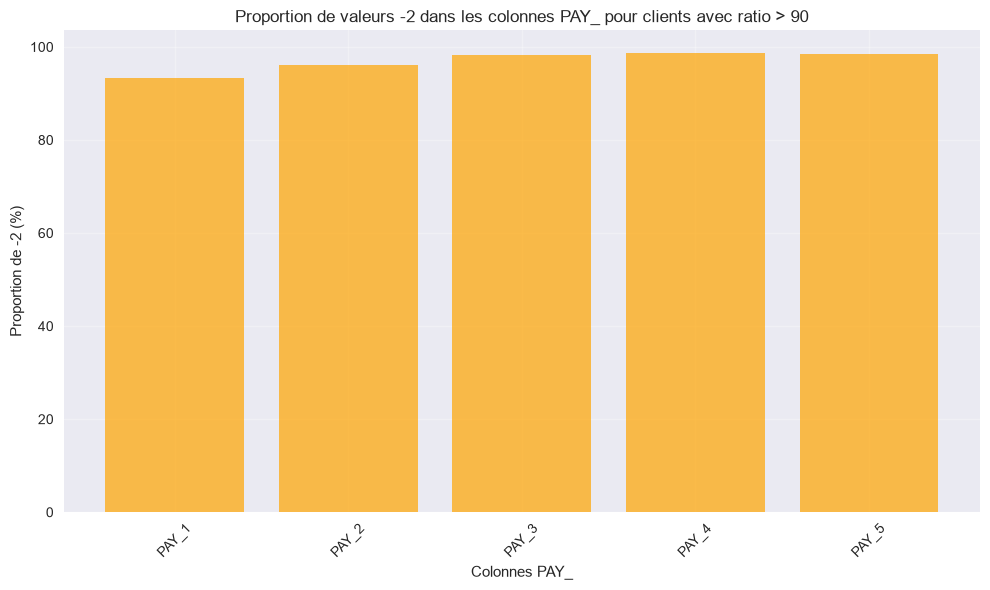

In [68]:
# Calculer la proportion de '-2' dans chaque colonne PAY_ pour les clients avec ratio > 90
if mask_gt_90.sum() > 0:
    # Compter le nombre total de -2 dans chaque colonne PAY_ pour les clients avec ratio > 90
    count_neg2_gt_90 = df.loc[mask_gt_90, pay_columns].eq(-2).sum()
    
    # Compter le nombre total de -2 dans chaque colonne PAY_ dans l'ensemble du dataset
    count_neg2_total = df[pay_columns].eq(-2).sum()
    
    # Calculer les proportions : proportion de -2 des clients avec ratio > 90 par rapport au total
    proportions_gt_90 = (count_neg2_gt_90 / count_neg2_total) * 100
    
    print("\n=== Proportions de '-2' dans les colonnes PAY_ ===")
    print("Pour les clients avec ratio_PAY_to_BILL_median > 90 :")
    for col in pay_columns:
        if count_neg2_total[col] > 0:  # Pour éviter la division par zéro
            print(f"{col}: {proportions_gt_90[col]:.2f}% ({count_neg2_gt_90[col]} sur {count_neg2_total[col]})")
        else:
            print(f"{col}: 0.00% (aucun -2 dans cette colonne)")
    
    # Optionnel : créer un graphique des proportions
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(proportions_gt_90)), proportions_gt_90.values, color='orange', alpha=0.7)
    plt.xlabel('Colonnes PAY_')
    plt.ylabel('Proportion de -2 (%)')
    plt.title('Proportion de valeurs -2 dans les colonnes PAY_ pour clients avec ratio > 90')
    plt.xticks(range(len(proportions_gt_90)), pay_columns, rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Inteprétation**  
La codification -2 semble être lié à une utilisation en paiement comptant de la carte

=== Proportions de '-2' dans chaque PAY_n ===
Condition : ratio_PAY_to_BILL_median > 90 OU BILL_AMT(n+1) <= 0

PAY_1 (avec BILL_AMT2 <= 0) : 94.16% (2597 sur 2758)
PAY_2 (avec BILL_AMT3 <= 0) : 96.19% (3637 sur 3781)
PAY_3 (avec BILL_AMT4 <= 0) : 98.29% (4014 sur 4084)
PAY_4 (avec BILL_AMT5 <= 0) : 98.69% (4290 sur 4347)
PAY_5 (avec BILL_AMT6 <= 0) : 98.68% (4484 sur 4544)


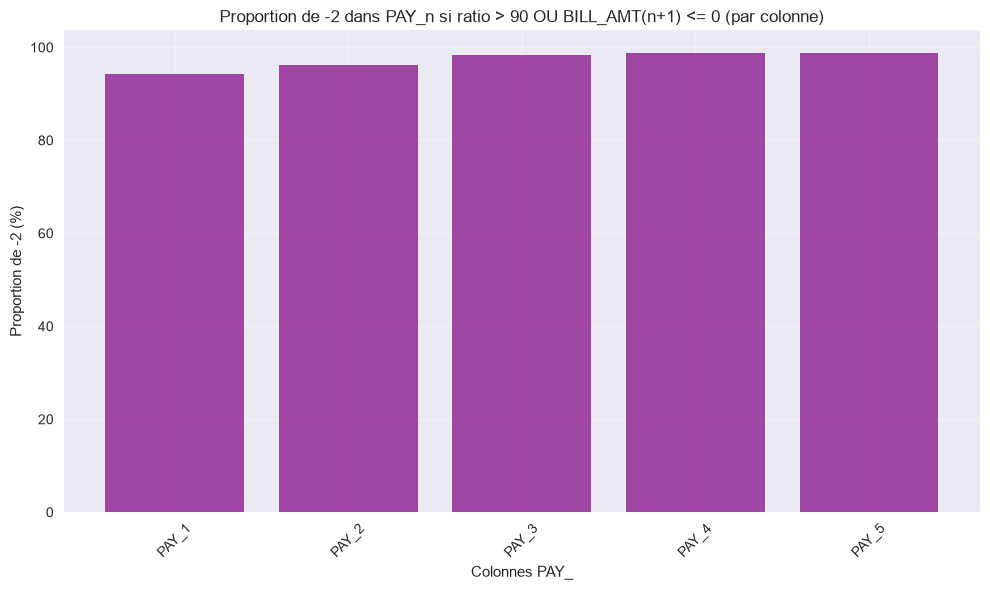

In [69]:
import matplotlib.pyplot as plt

# Définition des paires associées : PAY_n avec BILL_AMT_{n+1}
pairs = [
    ('PAY_1', 'BILL_AMT2'),
    ('PAY_2', 'BILL_AMT3'),
    ('PAY_3', 'BILL_AMT4'),
    ('PAY_4', 'BILL_AMT5'),
    ('PAY_5', 'BILL_AMT6'),
]

mask_gt_90 = df['ratio_PAY_to_BILL_median'] > 90

proportions = {}
counts_neg2 = {}
totals_neg2 = {}

print("=== Proportions de '-2' dans chaque PAY_n ===")
print("Condition : ratio_PAY_to_BILL_median > 90 OU BILL_AMT(n+1) <= 0\n")

for pay_col, bill_col in pairs:
    # Condition spécifique à la colonne n : ratio > 90 OU BILL_AMT(n+1) <= 0
    mask_bill_le_0 = df[bill_col] <= 0
    mask_combined = mask_gt_90 | mask_bill_le_0

    # Total de -2 pour cette colonne sous le filtre
    count_neg2 = df.loc[mask_combined, pay_col].eq(-2).sum()
    # Total de -2 pour cette colonne dans tout le dataset
    total_neg2 = df[pay_col].eq(-2).sum()

    prop = (count_neg2 / total_neg2) * 100 if total_neg2 > 0 else 0

    proportions[pay_col] = prop
    counts_neg2[pay_col] = count_neg2
    totals_neg2[pay_col] = total_neg2

    print(
        f"{pay_col} (avec {bill_col} <= 0) : {prop:.2f}% ({count_neg2} sur {total_neg2})"
    )

# Graphique
plt.figure(figsize=(10, 6))
plt.bar(
    range(len(proportions)),
    list(proportions.values()),
    color="purple",
    alpha=0.7,
)
plt.xlabel("Colonnes PAY_")
plt.ylabel("Proportion de -2 (%)")
plt.title(
    "Proportion de -2 dans PAY_n si ratio > 90 OU BILL_AMT(n+1) <= 0 (par colonne)"
)
plt.xticks(range(len(proportions)), list(proportions.keys()), rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation**  
la condition `ratio_PAY_to_BILL_median > 90 OU BILL_AMT(n+1) <= 0` explique +95% des codifications -2 du dataset
-2 semble etre très fortement corrélée à un usage comptant ou un solde nul ou négatif, autrement dit quand le client n'a pas d'utilisation de crédit sur la carte

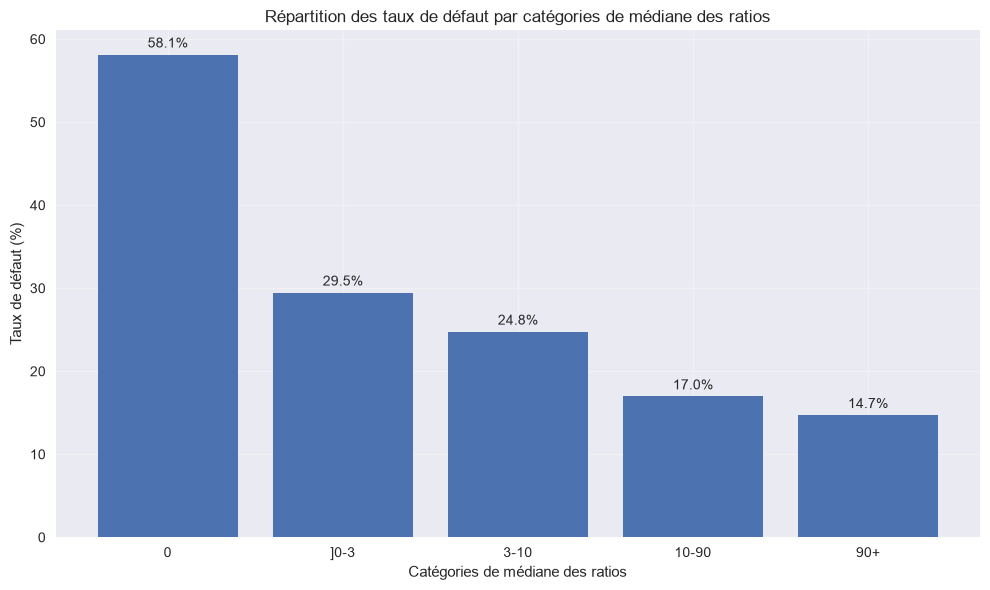

Statistiques de la répartition des taux de DPNM :
Nombre total de clients : 28590

Taux de DPNM par catégorie :
0: 58.13% (454/781 clients défauts/781 total)
]0-3: 29.46% (165/560 clients défauts/560 total)
3-10: 24.76% (3618/14613 clients défauts/14613 total)
10-90: 16.96% (770/4540 clients défauts/4540 total)
90+: 14.71% (1191/8096 clients défauts/8096 total)

Statistiques des médianes par client :
Moyenne des médianes : 36.1739
Médiane des médianes : 7.3601
Écart-type : 43.1257
Minimum : 0.0000
Maximum : 200.0000


In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Définir les colonnes des ratios
ratio_columns = [
'ratio_PAY_BILL1',
'ratio_PAY_BILL2', 
'ratio_PAY_BILL3', 
'ratio_PAY_BILL4', 
'ratio_PAY_BILL5'
]

# Calculer la médiane de chaque ligne (médiane des ratios pour chaque client)
row_medians = ratios_affichables(df, ratio_columns).median(axis=1)

# Créer les catégories DPNM
def categorize_dpnms(median_value):
    if median_value == 0:
        return '0'
    elif median_value < 3 :
        return ']0-3'
    elif median_value < 10:
        return '3-10'
    elif median_value < 90:
        return '10-90'
    else:
        return '90+'

# Appliquer la catégorisation
# Clients sans aucune facture exigible sur la période : pas de médiane affichable, exclus
categories = row_medians.apply(categorize_dpnms).where(row_medians.notna())

# Calculer les taux de DPNM pour chaque catégorie
category_counts = categories.value_counts()
total_clients = int(row_medians.notna().sum())

# Calculer le taux de défaut (DPNM) par catégorie
dpmn_rates = {}
dpnm_counts = {}

for category in ['0',']0-3', '3-10', '10-90', '90+']:
    # Filtrer les clients de cette catégorie
    mask = categories == category
    clients_in_category = df[mask]
    
    # Calculer le taux de défaut (nombre de défauts / nombre total dans la catégorie)
    if len(clients_in_category) > 0:
        dpnm_count = clients_in_category['dpnm'].sum()  # Nombre de défauts
        dpnm_rate = (dpnm_count / len(clients_in_category)) * 100
        dpnm_counts[category] = dpnm_count
    else:
        dpnm_rate = 0
        dpnm_counts[category] = 0
    
    dpmn_rates[category] = dpnm_rate

# Créer le graphique en barres pour les taux de DPNM
plt.figure(figsize=(10, 6))
categories_list = ['0',']0-3', '3-10', '10-90', '90+']
rates = [dpmn_rates[cat] for cat in categories_list]

bars = plt.bar(categories_list, rates)

# Ajouter les étiquettes et le titre
plt.xlabel('Catégories de médiane des ratios')
plt.ylabel('Taux de défaut (%)')
plt.title('Répartition des taux de défaut par catégories de médiane des ratios')
plt.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (bar, rate) in enumerate(zip(bars, rates)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Afficher les statistiques détaillées
print("Statistiques de la répartition des taux de DPNM :")
print(f"Nombre total de clients : {total_clients}")
print("\nTaux de DPNM par catégorie :")
for category, rate in dpmn_rates.items():
    count = category_counts.get(category, 0)
    dpnm_count = dpnm_counts[category]
    print(f"{category}: {rate:.2f}% ({dpnm_count}/{count} clients défauts/{count} total)")

# Afficher également les statistiques sur les médianes
print("\nStatistiques des médianes par client :")
print(f"Moyenne des médianes : {row_medians.mean():.4f}")
print(f"Médiane des médianes : {row_medians.median():.4f}")
print(f"Écart-type : {row_medians.std():.4f}")
print(f"Minimum : {row_medians.min():.4f}")
print(f"Maximum : {row_medians.max():.4f}")

**Interprétation**  
Le type d'usage de la carte a clairement un impact sur le taux de défaut :
- ceux qui ont l'habitude de ne pas payer sont naturellement plus enclins à etre en défaut de paiement
- ceux qui utilisent la carte essentiellement à crédit  ont une taux de défaut plus haut que la moyenne et 2 fois plus important que ceux qui utilisent la carte comme un moyen de paiement standard (différé fin de mois)
- Plus le client a tendance à payer une grosse partie de ce qu'il doit chaque mois moins il a tendance à avoir un impayé

## Analyse de BILL_AMT(n+1) <=0 avec un PAY_n != -2

In [71]:
import pandas as pd

# Alignement des paires PAY_n avec BILL_AMT_{n+1}
pairs = [
    ('PAY_1', 'BILL_AMT2'),
    ('PAY_2', 'BILL_AMT3'),
    ('PAY_3', 'BILL_AMT4'),
    ('PAY_4', 'BILL_AMT5'),
    ('PAY_5', 'BILL_AMT6'),
]

summary = []

for pay_col, bill_next_col in pairs:
    # Filtre sur BILL_AMT(n+1) <= 0 (solde créditeur ou nul)
    mask = df[bill_next_col] <= 0
    total_sub = mask.sum()

    if total_sub > 0:
        val_counts = df.loc[mask, pay_col].value_counts()
        val_pcts = df.loc[mask, pay_col].value_counts(normalize=True) * 100

        for val in val_counts.index:
            summary.append({
                'PAY_n': pay_col,
                'BILL_AMT(n+1)': bill_next_col,
                'Valeur PAY_n': val,
                'Effectif': val_counts[val],
                'Part (%)': f'{val_pcts[val]:.2f}%',
            })

# Création et affichage du DataFrame récapitulatif
df_repartition = pd.DataFrame(summary).sort_values(
    by=['PAY_n', 'Valeur PAY_n']
)
print(
    f'=== Répartition de PAY_n pour BILL_AMT(n+1) <= 0 (Total de lignes : {len(df)}) ===\n'
)
print(df_repartition.to_string(index=False))

=== Répartition de PAY_n pour BILL_AMT(n+1) <= 0 (Total de lignes : 29996) ===

PAY_n BILL_AMT(n+1)  Valeur PAY_n  Effectif Part (%)
PAY_1     BILL_AMT2            -2       951   29.97%
PAY_1     BILL_AMT2            -1       703   22.16%
PAY_1     BILL_AMT2             0       281    8.86%
PAY_1     BILL_AMT2             1      1175   37.03%
PAY_1     BILL_AMT2             2        63    1.99%
PAY_2     BILL_AMT3            -2      1873   53.13%
PAY_2     BILL_AMT3            -1       920   26.10%
PAY_2     BILL_AMT3             0       542   15.38%
PAY_2     BILL_AMT3             1        12    0.34%
PAY_2     BILL_AMT3             2       178    5.05%
PAY_3     BILL_AMT4            -2      2273   58.73%
PAY_3     BILL_AMT4            -1       888   22.95%
PAY_3     BILL_AMT4             0       538   13.90%
PAY_3     BILL_AMT4             2       171    4.42%
PAY_4     BILL_AMT5            -2      2536   60.95%
PAY_4     BILL_AMT5            -1       886   21.29%
PAY_4     BILL_AMT5

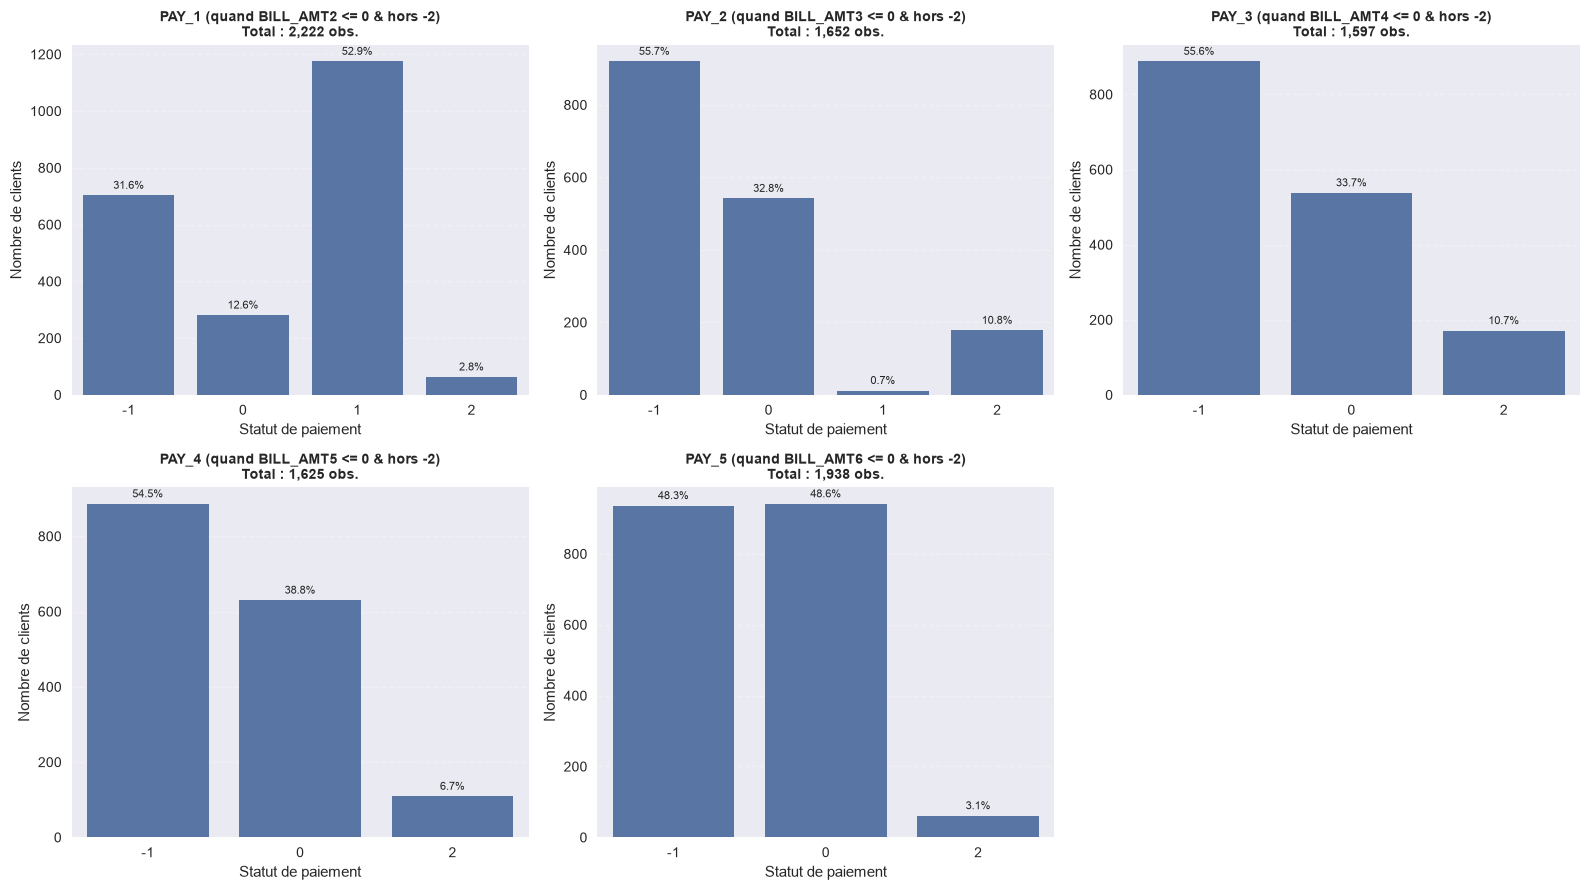

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paires d'alignement M / M+1
pairs = [
    ('PAY_1', 'BILL_AMT2'),
    ('PAY_2', 'BILL_AMT3'),
    ('PAY_3', 'BILL_AMT4'),
    ('PAY_4', 'BILL_AMT5'),
    ('PAY_5', 'BILL_AMT6'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (pay_col, bill_next_col) in enumerate(pairs):
    # Double filtre : BILL_AMT(n+1) <= 0 ET PAY_n != -2
    mask = (df[bill_next_col] <= 0) & (df[pay_col] != -2)
    df_filtered = df[mask]
    total_count = len(df_filtered)

    ax = axes[i]
    if total_count > 0:
        sns.countplot(
            data=df_filtered,
            x=pay_col,
            ax=ax,
            order=sorted(df_filtered[pay_col].unique()),
        )

        ax.set_title(
            f'{pay_col} (quand {bill_next_col} <= 0 & hors -2)\nTotal : {total_count:,} obs.',
            fontsize=10,
            fontweight='bold',
        )
        ax.set_xlabel('Statut de paiement')
        ax.set_ylabel('Nombre de clients')
        ax.grid(True, axis='y', alpha=0.3, linestyle='--')

        # Pourcentages au-dessus des barres
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                percentage = (height / total_count) * 100
                ax.annotate(
                    f'{percentage:.1f}%',
                    (p.get_x() + p.get_width() / 2.0, height),
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    xytext=(0, 3),
                    textcoords='offset points',
                )

# Supprimer le 6ème sous-graphique inutile (puisqu'il y a 5 paires)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Les codifications -2 sont majoritaires et normales d'après l'étude préalable de la codification -2.  
-1 et 0 ne sont pas des anomalies en soit, je n'ai pas encore identifié la signification exacte de ces codifications mais elles n'indiquent pas un retard.  
la codification 2 est un réel problème, minoritaire, qu'il convient d'éclaircir. S'agit_il de dossiers sortis du circuit ? d'anomalies de codification ?

## Analyse du risque et de son évolution
Part des clients en retard mois par mois (PAY_n = 2, PAY_n > 2, PAY_n > 1, PAY_n > 0), sur les données du lab : évolution du risque sur les 6 mois et effet de la codification PAY_1 = 1 sur la lecture du dernier mois.

In [73]:
# Compter le nombre de lignes où PAY_2 = 2
nombre_pay2_2 = (df['PAY_2'] == 2).sum()

# Calculer le pourcentage
total_lignes = len(df)
pourcentage_pay2_2 = (nombre_pay2_2 / total_lignes) * 100

print(f"Nombre de lignes où PAY_2 = 2 : {nombre_pay2_2}")
print(f"Pourcentage de lignes où PAY_2 = 2 : {pourcentage_pay2_2:.2f}%")



Nombre de lignes où PAY_2 = 2 : 3927
Pourcentage de lignes où PAY_2 = 2 : 13.09%


In [74]:
# Calculer directement les pourcentages pour toutes les colonnes PAY_n
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Créer un dictionnaire avec les pourcentages
pourcentages = {}
for col in colonnes_pay:
    pourcentages[col] = (df[col] == 2).mean() * 100

# Afficher les résultats
for col, pct in pourcentages.items():
    print(f"Pourcentage de {col} = 2 : {pct:.2f}%")

Pourcentage de PAY_1 = 2 : 8.89%
Pourcentage de PAY_2 = 2 : 13.09%
Pourcentage de PAY_3 = 2 : 12.73%
Pourcentage de PAY_4 = 2 : 10.53%
Pourcentage de PAY_5 = 2 : 8.75%
Pourcentage de PAY_6 = 2 : 9.22%


**Interprétation**
PAY_2 = 2  est sur représenté par rapport au reste, mais suit une tendance à la suite sur les 5 premiers mois  
Le dernier mois montre un net reflux de cette valeur, qui peut s'expliquer par une présence encore marquée de 1 (statut d'attente ?)  
Corriger cette valeur de PAY_1 = 1 via du ML pourra changer la donne.  

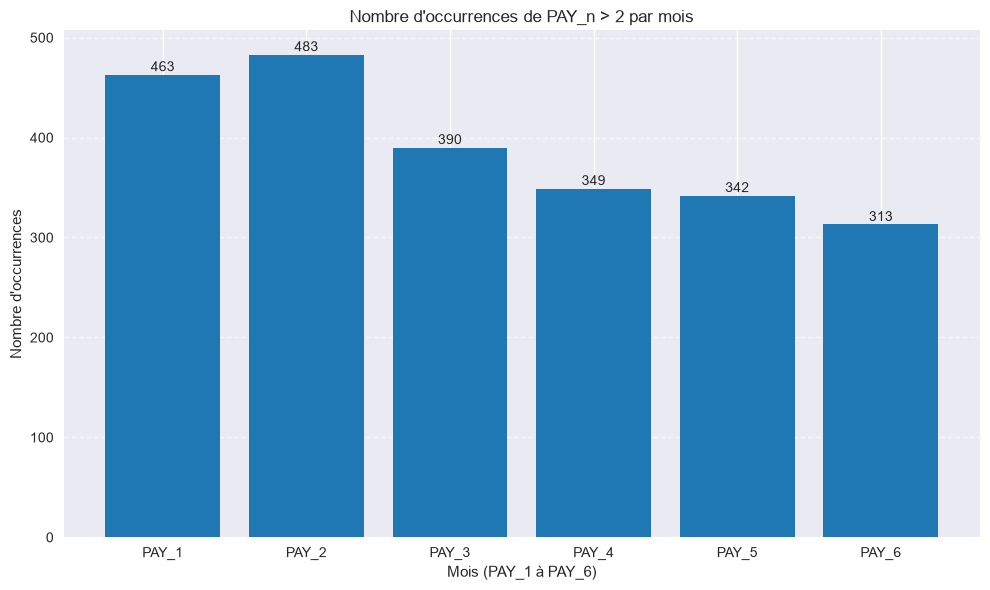

Résumé des occurrences de PAY_n > 2 :
    Mois  Occurrences
0  PAY_1          463
1  PAY_2          483
2  PAY_3          390
3  PAY_4          349
4  PAY_5          342
5  PAY_6          313


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n > 2 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] > 2).sum()
    occurrences[col] = nb_occurrences

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les nombres d'occurrences
mois = list(occurrences.keys())
nb_occurrences = list(occurrences.values())

# Tracer le graphique en barres
bars = plt.bar(mois, nb_occurrences, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (m, nb) in enumerate(zip(mois, nb_occurrences)):
    plt.text(i, nb + 0.5, str(nb), ha='center', va='bottom', fontsize=10)

plt.title('Nombre d\'occurrences de PAY_n > 2 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Nombre d\'occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des occurrences de PAY_n > 2 :")
resultats = pd.DataFrame({
    'Mois': mois,
    'Occurrences': nb_occurrences
})
print(resultats)

**Interprétation**
Hausse du nombre de cliente en incidents graves sur la période (avant correction de PAY_1 et PAY_2) 

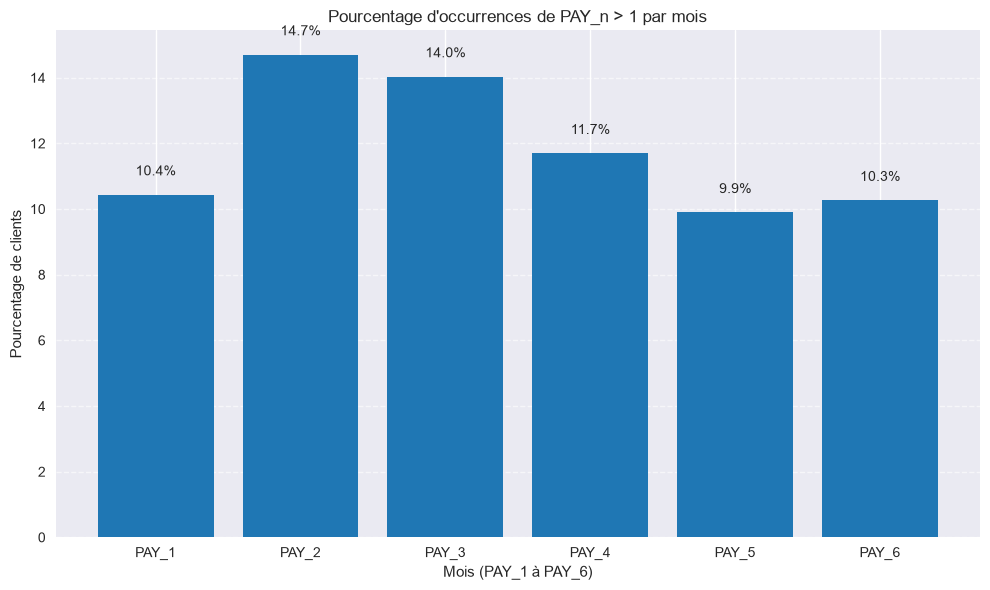

Résumé des pourcentages de PAY_n > 1 :
    Mois  Pourcentage
0  PAY_1    10.434725
1  PAY_2    14.701960
2  PAY_3    14.031871
3  PAY_4    11.694893
4  PAY_5     9.894653
5  PAY_6    10.264702


In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n > 1 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] > 1).sum()
    occurrences[col] = nb_occurrences

# Calculer les pourcentages par rapport au nombre total de clients
total_clients = len(df)
pourcentages = {}
for col, nb in occurrences.items():
    pourcentages[col] = (nb / total_clients) * 100

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les pourcentages
mois = list(pourcentages.keys())
pourcentages_values = list(pourcentages.values())

# Tracer le graphique en barres
bars = plt.bar(mois, pourcentages_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (m, pct) in enumerate(zip(mois, pourcentages_values)):
    plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Pourcentage d\'occurrences de PAY_n > 1 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Pourcentage de clients')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des pourcentages de PAY_n > 1 :")
resultats = pd.DataFrame({
    'Mois': mois,
    'Pourcentage': pourcentages_values
})
print(resultats)

**Interprétation** hausse du défaut de paiement avéré jusque M-2
La codification PAY_1 = 1 pose problème ici

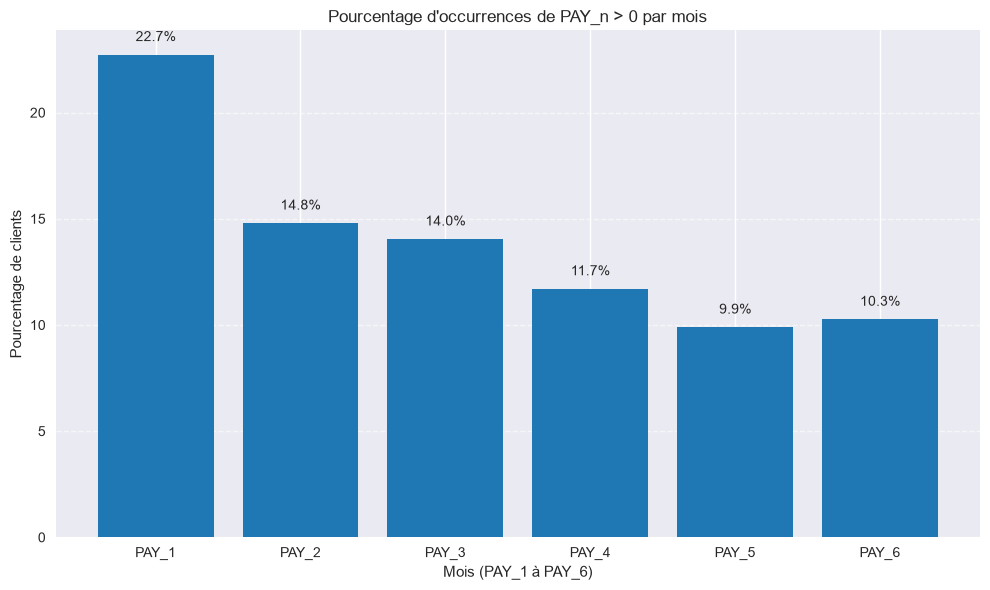

Résumé des pourcentages de PAY_n > 0 :
    Mois  Pourcentage
0  PAY_1    22.729697
1  PAY_2    14.795306
2  PAY_3    14.045206
3  PAY_4    11.701560
4  PAY_5     9.894653
5  PAY_6    10.264702


In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n > 0 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] > 0).sum()
    occurrences[col] = nb_occurrences

# Calculer les pourcentages par rapport au nombre total de clients
total_clients = len(df)
pourcentages = {}
for col, nb in occurrences.items():
    pourcentages[col] = (nb / total_clients) * 100

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les pourcentages
mois = list(pourcentages.keys())
pourcentages_values = list(pourcentages.values())

# Tracer le graphique en barres
bars = plt.bar(mois, pourcentages_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (m, pct) in enumerate(zip(mois, pourcentages_values)):
    plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Pourcentage d\'occurrences de PAY_n > 0 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Pourcentage de clients')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des pourcentages de PAY_n > 0 :")
resultats = pd.DataFrame({
    'Mois': mois,
    'Pourcentage': pourcentages_values
})
print(resultats)

**Interprétation**  
en intégrant la codification 1 comme marqueur de défaut, le taux de défaut s'envole en M-1 et suit globalement une hausse sur les 6 derniers mois, en total harmonie avec le dpnm de 22% de le mois suivant  
La correction logique ici serait de considerer tous les 1 restant comme un risque avéré à codifier en 2.
Eclairons un peu notre chemin pour tenter d'élaborer une logique de correction

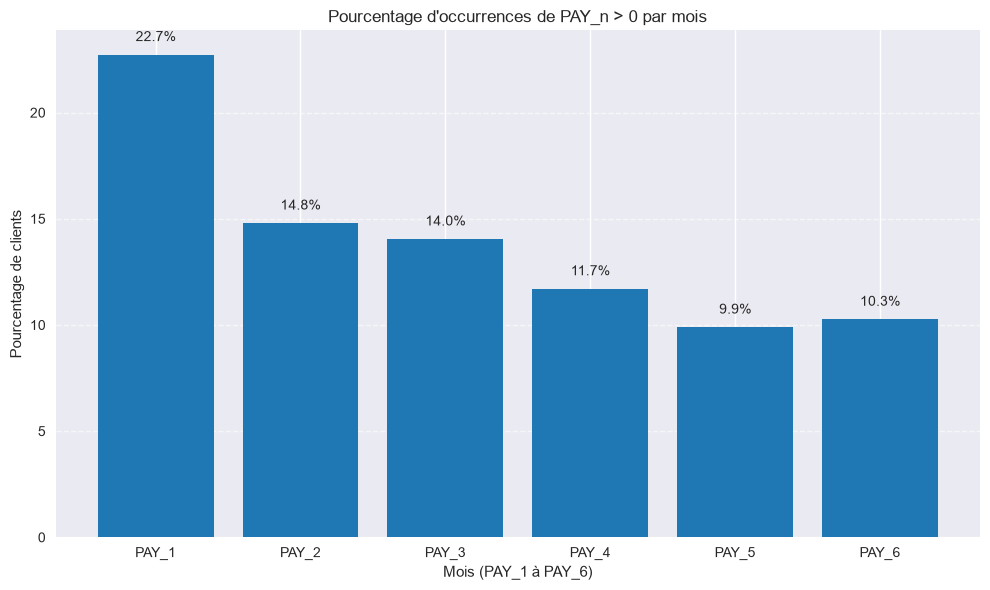

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n > 0 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] > 0).sum()
    occurrences[col] = nb_occurrences

# Calculer les pourcentages par rapport au nombre total de clients
total_clients = len(df)
pourcentages = {}
for col, nb in occurrences.items():
    pourcentages[col] = (nb / total_clients) * 100

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les pourcentages
mois = list(pourcentages.keys())
pourcentages_values = list(pourcentages.values())

# Tracer le graphique en barres
bars = plt.bar(mois, pourcentages_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (mois, pct) in enumerate(zip(mois, pourcentages_values)):
    plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Pourcentage d\'occurrences de PAY_n > 0 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Pourcentage de clients')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


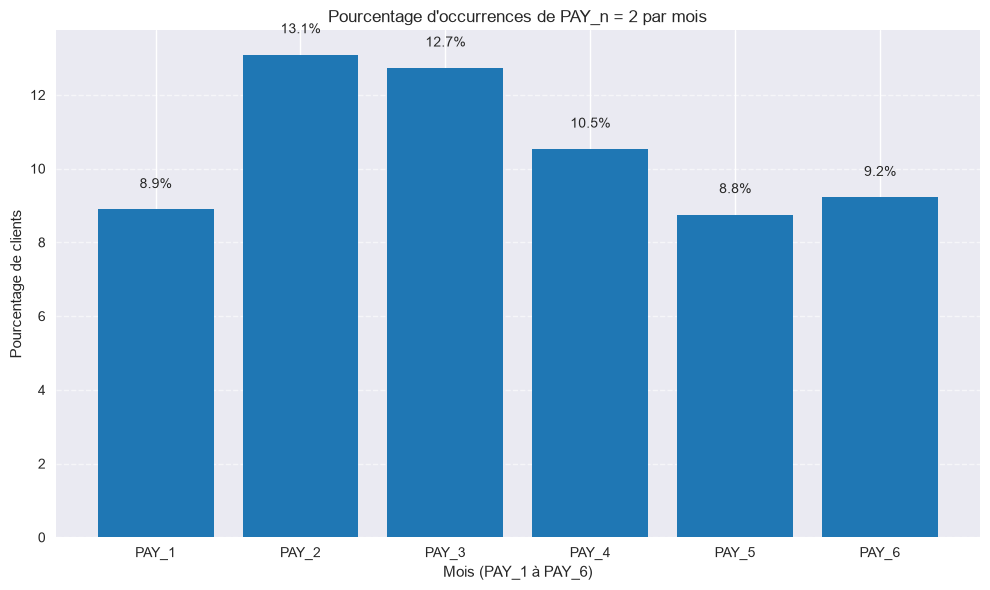

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes PAY_1 à PAY_6
colonnes_pay = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculer le nombre d'occurrences de PAY_n = 2 pour chaque mois
occurrences = {}
for col in colonnes_pay:
    nb_occurrences = (df[col] == 2).sum()
    occurrences[col] = nb_occurrences

# Calculer les pourcentages par rapport au nombre total de clients
total_clients = len(df)
pourcentages = {}
for col, nb in occurrences.items():
    pourcentages[col] = (nb / total_clients) * 100

# Créer le graphique
plt.figure(figsize=(10, 6))

# Extraire les mois et les pourcentages
mois = list(pourcentages.keys())
pourcentages_values = list(pourcentages.values())

# Tracer le graphique en barres
bars = plt.bar(mois, pourcentages_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, (mois, pct) in enumerate(zip(mois, pourcentages_values)):
    plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Pourcentage d\'occurrences de PAY_n = 2 par mois')
plt.xlabel('Mois (PAY_1 à PAY_6)')
plt.ylabel('Pourcentage de clients')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Analyse de PAY_n == 2

In [80]:
import pandas as pd

pairs = [
    ('PAY_1', 'BILL_AMT2'),
    ('PAY_2', 'BILL_AMT3'),
    ('PAY_3', 'BILL_AMT4'),
    ('PAY_4', 'BILL_AMT5'),
    ('PAY_5', 'BILL_AMT6'),
]

pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# 1. Masque global : Clients ayant au moins un cas de PAY_n == 2 avec BILL_AMT(n+1) <= 0
anomaly_masks = [(df[pay] == 2) & (df[bill] <= 0) for pay, bill in pairs]
mask_has_anomaly = pd.concat(anomaly_masks, axis=1).any(axis=1)

df_anomalies = df[mask_has_anomaly].copy()

print(f"=== Analyse approfondie des codifications '2' sur solde <= 0 ===")
print(f"Nombre de clients concernés : {len(df_anomalies)} (sur {len(df)})")
if 'dpnm' in df.columns:
    print(f"Taux de défaut (dpnm) de ce groupe : {df_anomalies['dpnm'].mean() * 100:.2f}% (vs {df['dpnm'].mean() * 100:.2f}% global)")

print("\n--- 1. Répartition du nombre de '2' par client dans ce groupe ---")
print(df_anomalies[pay_cols].eq(2).sum(axis=1).value_counts().sort_index().rename("Nombre de mois à 2"))

print("\n--- 2. Exemples de trajectoires typiques (PAY_1 à PAY_6 + BILL_AMT1 à 6) ---")
cols_to_show = pay_cols + bill_cols + pay_amt_columns
if 'dpnm' in df.columns:
    cols_to_show.append('dpnm')

print(df_anomalies[cols_to_show].head(10).to_string())

=== Analyse approfondie des codifications '2' sur solde <= 0 ===
Nombre de clients concernés : 363 (sur 29996)
Taux de défaut (dpnm) de ce groupe : 44.08% (vs 22.12% global)

--- 1. Répartition du nombre de '2' par client dans ce groupe ---
1      1
2    275
3     50
4     25
5      8
6      4
Name: Nombre de mois à 2, dtype: int64

--- 2. Exemples de trajectoires typiques (PAY_1 à PAY_6 + BILL_AMT1 à 6) ---
      PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  dpnm
ID                                                                                                                                                                      
241       1      2      2     -2     -2     -1      21501      20650          0          0          0       2285         0         0         0         0      2285     0
244      -1     -1      2      2     -1     -1       3139       5853       2821  

Au premier coup d'oeil, il semble y avoir des décalages de régularisation ou de mise en code 2  
ou la banque utilise le code 2 comme alerte  
Le taux de défaut sur cette population est 2 fois supérieure à la moyenne.  Pourtant la codification ne dépasse jamais 2

In [81]:
import pandas as pd

bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# 1. Clients avec un encours <= 0 sur TOUS les 6 mois
mask_all_le_0 = df_anomalies[bill_cols].le(0).all(axis=1)
count_all_le_0 = mask_all_le_0.sum()

# 2. Clients avec un encours strictement stable (identique sur les 6 mois)
# nuique(axis=1) == 1 indique que le montant est exactement le même de BILL_AMT1 à BILL_AMT6
mask_stable_strict = df_anomalies[bill_cols].nunique(axis=1) == 1
count_stable_strict = mask_stable_strict.sum()

# 3. Clients avec encours quasi-stable (ex: variation max <= 100 NT$)
mask_stable_quasi = (df_anomalies[bill_cols].max(axis=1) - df_anomalies[bill_cols].min(axis=1)) <= 100
count_stable_quasi = mask_stable_quasi.sum()

# Affichage des résultats
total_anomalies = len(df_anomalies)

print(f"=== Bilans sur les {total_anomalies} clients détectés ===")
print(f"1. Encours <= 0 sur l'ensemble des 6 mois : {count_all_le_0} ({count_all_le_0 / total_anomalies * 100:.2f}%)")
print(f"2. Encours parfaitement stable (valeur identique 6 mois) : {count_stable_strict} ({count_stable_strict / total_anomalies * 100:.2f}%)")
print(f"3. Encours quasi-stable (variation <= 100 NT$) : {count_stable_quasi} ({count_stable_quasi / total_anomalies * 100:.2f}%)")

=== Bilans sur les 363 clients détectés ===
1. Encours <= 0 sur l'ensemble des 6 mois : 0 (0.00%)
2. Encours parfaitement stable (valeur identique 6 mois) : 0 (0.00%)
3. Encours quasi-stable (variation <= 100 NT$) : 1 (0.28%)


In [82]:
# Colonnes de statut de paiement sur les 6 mois
pay_cols = [c for c in ['PAY_1', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'] if c in df.columns]

# Masque pour sélectionner les lignes où TOUTES les colonnes PAY_n valent 2
mask_always_2 = (df_anomalies[pay_cols] == 2 ).all(axis=1)

# Extraction des 4 clients
df_4_clients = df_anomalies[mask_always_2]

# Sélection des colonnes clés pour l'observation (ID, statuts, encours et cible)
cols_display = [c for c in ['ID'] + ['LIMIT_BAL'] + pay_cols + bill_cols + pay_amt_columns +['PAY_AMT6'] if c in df.columns]

# Affichage complet
df_4_clients[cols_display]

,LIMIT_BAL,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
ID,,,,,,,,,,,,,,,,,,,
11818,30000,2,2,2,2,2,2,26795,29654,28879,30892,30500,0,3300,0,2500,0,0,0
14330,20000,2,2,2,2,2,2,150,150,150,1150,1000,0,0,0,1000,0,0,0
14377,30000,2,2,2,2,2,2,19150,19149,23888,24337,23725,0,600,5229,1000,0,0,0
20992,210000,2,2,2,2,2,2,122157,130309,116004,78564,37154,0,12301,16,5812,218,0,0


Que le client paie ou non, il reste à une codification 2, on n'a pas d'encours à M-6 alors qu'on a déjà un code 2  
Ces codifications 2 atypiques concernent un peu plus de 1% des clients, pas assez pour décontenancer un modèle de ML mais suffisamment pour créer du bruit ou perdre en efficacité

In [83]:
import pandas as pd

# 1. Identification des colonnes de statut de paiement (PAY_1 à PAY_6)
cols_pay = [
    c
    for c in ['PAY_1', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    if c in df.columns
]

# 2. Masque pour interroger la présence continue de la valeur 2
mask_always_2 = (df[cols_pay] == 2).all(axis=1)

# 3. Décompte total dans la base
count_always_2 = mask_always_2.sum()

print(
    f"Nombre total de clients avec PAY_n == 2 sur les 6 mois : {count_always_2}"
)

# 4. Isolement du sous-ensemble de clients
df_always_2 = df[mask_always_2]

# Affichage des colonnes clés
cols_display = [
    c
    for c in ['ID', 'LIMIT_BAL']
    + cols_pay
    + ['BILL_AMT1', 'BILL_AMT6', 'PAY_AMT1', 'dpnm']
    if c in df.columns
]
display(df_always_2[initial_col].head(10))
print(f"taux de défaut sur cette population : {round(df_always_2['dpnm'].sum()/len(df_always_2)*100,2)}%")

Nombre total de clients avec PAY_n == 2 sur les 6 mois : 530


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
63,50000,1,1,2,29,2,2,2,2,2,...,25865,27667,28264,0,2700,0,2225,1200,0,1
72,320000,1,2,2,29,2,2,2,2,2,...,58622,62307,63526,2500,2500,0,4800,2400,1600,1
91,200000,1,1,1,53,2,2,2,2,2,...,144098,147124,149531,6300,5500,5500,5500,5000,5000,1
188,200000,2,3,2,47,2,2,2,2,2,...,196186,200162,189915,8214,7000,6800,7134,0,6836,1
330,150000,1,1,1,40,2,2,2,2,2,...,104975,107147,109428,5200,0,8100,4000,4200,4200,0
400,120000,2,2,2,25,2,2,2,2,2,...,116313,119311,117167,4007,0,8272,5000,0,4400,0
405,160000,2,1,2,29,2,2,2,2,2,...,166893,170098,153800,7500,0,11558,5800,0,5654,1
514,50000,1,2,2,23,2,2,2,2,2,...,31924,32566,33081,2000,1500,1300,1300,1200,1500,1
649,280000,2,2,1,44,2,2,2,2,2,...,195517,199250,195874,0,15000,8000,7000,0,15000,1


taux de défaut sur cette population : 77.55%


J'ai mis le doigt sur quelque chose  
On a une codification gélée en 2 pour 530 clients avec un taux de défaut de 77%, cela ressemble à une gestion contentieuse.  
Puis-je le vérifier ? Ces comptes sont-ils gelés ?

In [84]:
import pandas as pd

# Colonnes de statut
pay_cols = [
    c for c in df.columns if c.startswith('PAY_') and not c.startswith('PAY_AMT')
]

# 1. Cond 1 : PAY == 2 en continu sur les 6 mois
cond1 = (df[pay_cols] == 2).all(axis=1)

# 2. Cond 2 : Faux rétrogradage strict (PAY_n == 2 alors que PAY_{n+1} > 2, avec dette > 0 et paiement = 0)
# Identification dynamique des paires de mois (M_n et M_{n+1})
cond2_mask = pd.Series(False, index=df.index)

# paires de colonnes successives (du mois le plus récent au plus ancien)
for i in range(len(pay_cols) - 1):
    curr_pay = pay_cols[i]  # mois n
    next_pay = pay_cols[i + 1]  # mois n+1 (mois précédent dans le temps)

    # Récupération du numéro de mois pour BILL_AMT et PAY_AMT
    m_num = curr_pay.replace('PAY_', '')
    if m_num == '0':
        m_num = '1'  # Alignement si PAY_0 / BILL_AMT1

    bill_col = f'BILL_AMT{int(m_num) + 1}'  # facture exigible au mois n : PAY_n porte sur BILL_AMT(n+1)
    pay_amt_col = f'PAY_AMT{m_num}'

    if bill_col in df.columns and pay_amt_col in df.columns:
        retrograde_step = (
            (df[curr_pay] == 2)
            & (df[next_pay] > 2)
            & (df[bill_col] > 0)
            & (df[pay_amt_col] == 0)
        )
        cond2_mask = cond2_mask | retrograde_step

cond2 = cond2_mask & (~cond1)

# 3. Trajectoire stricte
df['CTX_Trajectoire'] = '3. Non CTX'
df.loc[cond1, 'CTX_Trajectoire'] = '1. CTX Chronique (6 mois)'
df.loc[cond2, 'CTX_Trajectoire'] = '2. Faux rétrogradage strict (Cond 2)'

# 4. Affichage des volumes corrigés
analyse_stricte = (
    df.groupby('CTX_Trajectoire')
    .agg(
        Nb_Clients=('dpnm', 'count'),
        Pct_Portefeuille=('dpnm', lambda x: len(x) / len(df) * 100),
        Taux_Defaut_Pct=('dpnm', lambda x: x.mean() * 100),
    )
    .reset_index()
)

display(analyse_stricte)

,CTX_Trajectoire,Nb_Clients,Pct_Portefeuille,Taux_Defaut_Pct
0,1. CTX Chronique (6 mois),530,1.766902,77.547170
1,2. Faux rétrogradage strict (Cond 2),393,1.310175,68.702290
2,3. Non CTX,29073,96.922923,20.482922


In [85]:
import pandas as pd

# 1. Sélection des colonnes de statut (PAY_1 à PAY_6)
pay_status_cols = [f'PAY_{i}' for i in range(1, 7)]

# 2. Condition : Au moins un mois avec PAY_n > 2
mask_pay_gt_2 = (df[pay_status_cols] > 2).any(axis=1)

# 3. Calcul des métriques
df_gt_2 = df[mask_pay_gt_2]
nb_clients = len(df_gt_2)
pct_portefeuille = (nb_clients / len(df)) * 100
taux_defaut = df_gt_2['dpnm'].mean() * 100 if 'dpnm' in df.columns else None

# 4. Synthèse des résultats
res_gt2 = pd.DataFrame([
    {
        'Périmètre': 'Au moins un PAY_n > 2 sur 6 mois',
        'Nb Clients': f'{nb_clients:,}'.replace(',', ' '),
        'Part Portefeuille (%)': f'{pct_portefeuille:.2f} %',
        'Taux de Défaut dpnm (%)': (
            f'{taux_defaut:.2f} %' if taux_defaut is not None else 'N/A'
        ),
    }
])

display(res_gt2)

# 5. Ventilation détaillée par statut maximum atteint
df['Max_PAY_6m'] = df[pay_status_cols].max(axis=1)
ventilation = (
    df.groupby('Max_PAY_6m')
    .agg(
        Nb_Clients=('dpnm', 'count'),
        Pct_Portefeuille=('dpnm', lambda x: len(x) / len(df) * 100),
        Taux_Defaut_dpnm=('dpnm', lambda x: x.mean() * 100),
    )
    .reset_index()
)

display(ventilation[ventilation['Max_PAY_6m'] > 2])

,Périmètre,Nb Clients,Part Portefeuille (%),Taux de Défaut dpnm (%)
0,Au moins un PAY_n > 2 sur 6 mois,1 193,3.98 %,62.87 %


,Max_PAY_6m,Nb_Clients,Pct_Portefeuille,Taux_Defaut_dpnm
5,3,789,2.630351,62.230672
6,4,218,0.726764,64.220183
7,5,69,0.230031,50.724638
8,6,25,0.083344,56.000000
9,7,67,0.223363,83.582090
10,8,25,0.083344,56.000000


In [86]:
import pandas as pd

# 1. Sélection des colonnes de statut (PAY_1 à PAY_6)
pay_status_cols = [f'PAY_{i}' for i in range(1, 7)]

# 2. Condition : PAY_n > 2 TOUS LES MOIS sur les 6 mois
mask_gt2_strict_6m = (df[pay_status_cols] > 2).all(axis=1)

# 3. Métriques pour ce segment
df_gt2_6m = df[mask_gt2_strict_6m]
nb_clients = len(df_gt2_6m)
pct_pop = (nb_clients / len(df)) * 100
dpnm_moyen = (
    df_gt2_6m['dpnm'].mean() * 100 if 'dpnm' in df.columns and nb_clients > 0 else 0
)

# 4. Affichage du résultat
print(f'=== SEGMENT STRICT : PAY_n > 2 SUR LES 6 MOIS ===')
print(f'Nb clients : {nb_clients:,}'.replace(',', ' '))
print(f'Part portefeuille : {pct_pop:.2f} %')
print(f'Taux de défaut (dpnm) : {dpnm_moyen:.2f} %')

# 5. Détail par profil exact pour comprendre la structure interne
if nb_clients > 0:
  profils = (
      df_gt2_6m.groupby(pay_status_cols)
      .agg(
          Nb_Clients=('dpnm', 'count'),
          Taux_Defaut_dpnm=('dpnm', lambda x: x.mean() * 100),
      )
      .reset_index()
  )
  display(profils)

=== SEGMENT STRICT : PAY_n > 2 SUR LES 6 MOIS ===
Nb clients : 26
Part portefeuille : 0.09 %
Taux de défaut (dpnm) : 57.69 %


,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,Nb_Clients,Taux_Defaut_dpnm
0,3,3,4,4,4,4,1,0.000000
1,3,3,4,4,5,5,1,0.000000
2,3,3,4,4,5,6,1,100.000000
3,3,4,4,4,4,3,1,100.000000
4,4,3,4,4,4,3,1,100.000000
5,4,4,4,4,4,4,1,100.000000
6,4,4,4,5,4,3,1,0.000000
7,8,7,6,5,4,3,19,57.894737


In [87]:
import pandas as pd

# 1. Sélection dynamique des colonnes
pay_status_cols = [
    c for c in df.columns if c.startswith('PAY_') and not c.startswith('PAY_AMT')
]
pay_amt_cols = sorted([c for c in df.columns if c.startswith('PAY_AMT')])

# 2. Filtrage de la population "PAY_n == 2 tout le temps"
mask_pay2_6m = (df[pay_status_cols] == 2).all(axis=1)
df_chronique = df[mask_pay2_6m].copy()

# 3. Compte du nombre de mois avec PAY_AMT == 0 par client (0 à 6)
zeros_par_client = (df_chronique[pay_amt_cols] == 0).sum(axis=1)

# 4. Distribution et impact sur le taux de défaut (dpnm)
distrib = (
    zeros_par_client.value_counts()
    .sort_index()
    .reset_index()
    .rename(
        columns={
            'index': 'Mois avec PAY_AMT = 0',
            0: 'Mois avec PAY_AMT = 0',
            'count': 'Nb_Clients',
        }
    )
)

distrib['Pct_Population_CTX_%'] = (
    distrib['Nb_Clients'] / len(df_chronique) * 100
).round(2)

if 'dpnm' in df_chronique.columns:
    taux_dpnm = (
        df_chronique.groupby(zeros_par_client)['dpnm'].mean() * 100
    ).round(2)
    distrib['Taux_Defaut_dpnm_%'] = distrib['Mois avec PAY_AMT = 0'].map(
        taux_dpnm
    )

display(distrib)

# 5. Métriques globales
total_cellules_amt = len(df_chronique) * len(pay_amt_cols)
total_zeros = (df_chronique[pay_amt_cols] == 0).sum().sum()

print(f'=== BILAN DES PAIEMENT NULS (POPULATION CTX CHRONIQUE) ===')
print(f'Nombre de clients concernés : {len(df_chronique):,}'.replace(',', ' '))
print(
    f'Total d\'échéances avec PAY_AMT == 0 : {total_zeros:,} sur {total_cellules_amt:,} ({total_zeros/total_cellules_amt*100:.2f} %)'.replace(
        ',', ' '
    )
)
print(
    f'Clients avec ZERO PAIEMENT ABSOLU sur 6 mois (6/6) : {(zeros_par_client == 6).sum()} ({(zeros_par_client == 6).mean()*100:.2f} %)'
)

,Mois avec PAY_AMT = 0,Nb_Clients,Pct_Population_CTX_%,Taux_Defaut_dpnm_%
0,0,135,25.47,78.52
1,1,164,30.94,76.83
2,2,156,29.43,75.00
3,3,58,10.94,82.76
4,4,1,0.19,0.00
5,5,3,0.57,33.33
6,6,13,2.45,100.00


=== BILAN DES PAIEMENT NULS (POPULATION CTX CHRONIQUE) ===
Nombre de clients concernés : 530
Total d'échéances avec PAY_AMT == 0 : 747 sur 3 180 (23.49 %)
Clients avec ZERO PAIEMENT ABSOLU sur 6 mois (6/6) : 13 (2.45 %)


In [88]:
import pandas as pd

# Définition des paires (PAY_n, BILL_AMT_{n+1})
pairs = [
    ('PAY_1', 'BILL_AMT2'),
    ('PAY_2', 'BILL_AMT3'),
    ('PAY_3', 'BILL_AMT4'),
    ('PAY_4', 'BILL_AMT5'),
    ('PAY_5', 'BILL_AMT6'),
]

results = []

for pay_col, bill_next_col in pairs:
    if pay_col in df.columns and bill_next_col in df.columns:
        # Population de base : PAY_n == 2
        mask_pay2 = df[pay_col] == 2
        total_pay2 = mask_pay2.sum()

        # Sous-population : PAY_n == 2 ET BILL_AMT_{n+1} <= 0
        mask_anomaly = mask_pay2 & (df[bill_next_col] <= 0)
        nb_anomaly = mask_anomaly.sum()

        taux_anomaly = (nb_anomaly / total_pay2 * 100) if total_pay2 > 0 else 0

        # Taux de défaut (dpnm) sur ces cas d'anomalie
        taux_defaut = (
            df.loc[mask_anomaly, 'dpnm'].mean() * 100
            if 'dpnm' in df.columns and nb_anomaly > 0
            else None
        )

        results.append({
            'Statut (PAY_n)': pay_col,
            'Facture Précédente (BILL_AMT_n+1)': bill_next_col,
            'Total PAY_n == 2': total_pay2,
            'Nb BILL <= 0': nb_anomaly,
            'Taux Anomalie (%)': round(taux_anomaly, 2),
            'Taux Défaut dpnm (%)': (
                round(taux_defaut, 2) if taux_defaut is not None else 'N/A'
            ),
        })

df_res = pd.DataFrame(results)
display(df_res)

,Statut (PAY_n),Facture Précédente (BILL_AMT_n+1),Total PAY_n == 2,Nb BILL <= 0,Taux Anomalie (%),Taux Défaut dpnm (%)
0,PAY_1,BILL_AMT2,2667,63,2.36,63.49
1,PAY_2,BILL_AMT3,3927,178,4.53,49.44
2,PAY_3,BILL_AMT4,3819,171,4.48,39.77
3,PAY_4,BILL_AMT5,3159,109,3.45,39.45
4,PAY_5,BILL_AMT6,2626,61,2.32,40.98


In [89]:
import pandas as pd

# 1. Alignement des colonnes de statut ordonnées (de M-1 à M-6)
pay_m1 = 'PAY_0' if 'PAY_0' in df.columns else 'PAY_1'
start_idx = 0 if pay_m1 == 'PAY_0' else 1

pay_status_cols = [
    f'PAY_{i}'
    for i in range(start_idx, start_idx + 6)
    if f'PAY_{i}' in df.columns
]

results = []

# 2. Calcul du taux de défaut pour chaque fenêtre consécutive n (de 1 à 6 mois)
for n in range(1, len(pay_status_cols) + 1):
    cols_window = pay_status_cols[:n]

    # Condition : PAY == 2 consécutif de M-1 jusqu'à M-n
    mask_consecutive = (df[cols_window] == 2).all(axis=1)

    nb_clients = mask_consecutive.sum()
    pct_pop = (nb_clients / len(df)) * 100
    dpnm_moyen = (
        df.loc[mask_consecutive, 'dpnm'].mean() * 100 if nb_clients > 0 else 0
    )

    results.append({
        'Série consécutive (depuis M-1)': f'Au moins {n} mois (M-1 à M-{n})',
        'Nb clients': f'{nb_clients:,}'.replace(',', ' '),
        'Part portefeuille (%)': round(pct_pop, 2),
        'Taux de défaut dpnm (%)': round(dpnm_moyen, 2),
    })

# 3. Affichage
df_res = pd.DataFrame(results)
display(df_res)

,Série consécutive (depuis M-1),Nb clients,Part portefeuille (%),Taux de défaut dpnm (%)
0,Au moins 1 mois (M-1 à M-1),2 667,8.89,69.14
1,Au moins 2 mois (M-1 à M-2),1 591,5.30,71.84
2,Au moins 3 mois (M-1 à M-3),1 155,3.85,73.42
3,Au moins 4 mois (M-1 à M-4),840,2.80,74.76
4,Au moins 5 mois (M-1 à M-5),649,2.16,76.73
5,Au moins 6 mois (M-1 à M-6),530,1.77,77.55


In [90]:
import pandas as pd

pay_status_cols = [f'PAY_{i}' for i in range(1, 7)]


# Fonction pour calculer la durée exacte du blocage continu à 2 depuis PAY_1
def duree_exacte_pay2(row):
  count = 0
  for col in pay_status_cols:
    if row[col] == 2:
      count += 1
    else:
      break
  return count


# 1. Calcul de la durée exacte (0 à 6 mois)
df['Duree_PAY2_Consecutif'] = df.apply(duree_exacte_pay2, axis=1)

# 2. Mapping des tranches disjointes
labels = {
    1: '1. Exactement 1 mois (PAY_1=2, PAY_2!=2)',
    2: '2. Exactement 2 mois (PAY_1..2=2, PAY_3!=2)',
    3: '3. Exactement 3 mois (PAY_1..3=2, PAY_4!=2)',
    4: '4. Exactement 4 mois (PAY_1..4=2, PAY_5!=2)',
    5: '5. Exactement 5 mois (PAY_1..5=2, PAY_6!=2)',
    6: '6. 6 mois complets (PAY_1..6=2)',
}

df['Segment_PAY2_Disjoint'] = df['Duree_PAY2_Consecutif'].map(labels)

# 3. Tableau de ventilation étanche
analyse_disjointe = (
    df[df['Duree_PAY2_Consecutif'] > 0]
    .groupby('Segment_PAY2_Disjoint')
    .agg(
        Nb_Clients=('dpnm', 'count'),
        Pct_Portefeuille=('dpnm', lambda x: len(x) / len(df) * 100),
        Taux_Defaut_dpnm=('dpnm', lambda x: x.mean() * 100),
    )
    .reset_index()
)

display(analyse_disjointe)

,Segment_PAY2_Disjoint,Nb_Clients,Pct_Portefeuille,Taux_Defaut_dpnm
0,"1. Exactement 1 mois (PAY_1=2, PAY_2!=2)",1076,3.587145,65.148699
1,"2. Exactement 2 mois (PAY_1..2=2, PAY_3!=2)",436,1.453527,67.660550
2,"3. Exactement 3 mois (PAY_1..3=2, PAY_4!=2)",315,1.050140,69.841270
3,"4. Exactement 4 mois (PAY_1..4=2, PAY_5!=2)",191,0.636752,68.062827
4,"5. Exactement 5 mois (PAY_1..5=2, PAY_6!=2)",119,0.396720,73.109244
5,6. 6 mois complets (PAY_1..6=2),530,1.766902,77.547170


In [91]:
import pandas as pd

# Paires de transition : BILL_AMT_{n+1} - PAY_AMT_n doit égaler BILL_AMT_n
transitions = [
    ('M2 -> M1', 'BILL_AMT2', 'PAY_AMT1', 'BILL_AMT1'),
    ('M3 -> M2', 'BILL_AMT3', 'PAY_AMT2', 'BILL_AMT2'),
    ('M4 -> M3', 'BILL_AMT4', 'PAY_AMT3', 'BILL_AMT3'),
    ('M5 -> M4', 'BILL_AMT5', 'PAY_AMT4', 'BILL_AMT4'),
    ('M6 -> M5', 'BILL_AMT6', 'PAY_AMT5', 'BILL_AMT5'),
]

# Calcul des écarts pour chaque transition
df_diffs = pd.DataFrame(index=df_always_2.index)

for label, bill_next, pay_curr, bill_curr in transitions:
    # Écart = (Encours M+1 - Versement M) - Encours M
    df_diffs[label] = (
        df_always_2[bill_next] - df_always_2[pay_curr]
    ) - df_always_2[bill_curr]

# 1. Égalité stricte (Écart == 0)
exact_match_per_trans = (df_diffs == 0).sum()
exact_match_all_5 = (df_diffs == 0).all(axis=1).sum()

# 2. Égalité avec tolérance de 100 NT$ (pour prendre en compte de légers agios résiduels)
tol_match_per_trans = (df_diffs.abs() <= 100).sum()
tol_match_all_5 = (df_diffs.abs() <= 100).all(axis=1).sum()

total = len(df_always_2)

print(f'=== Vérification de l\'équation de gel sur les {total} clients ===\n')

print('--- Égalité stricte (0 NT$ d\'écart) ---')
for label in df_diffs.columns:
    count = exact_match_per_trans[label]
    print(f'{label} : {count} clients ({count / total * 100:.2f}%)')
print(
    f'\nParfaitement vérifié sur les 5 transitions : {exact_match_all_5} ({exact_match_all_5 / total * 100:.2f}%)\n'
)

print('--- Avec tolérance d\'agios (écart <= 100 NT$) ---')
for label in df_diffs.columns:
    count = tol_match_per_trans[label]
    print(f'{label} : {count} clients ({count / total * 100:.2f}%)')
print(
    f'\nVérifié sur les 5 transitions (avec tolérance) : {tol_match_all_5} ({tol_match_all_5 / total * 100:.2f}%)'
)

=== Vérification de l'équation de gel sur les 530 clients ===

--- Égalité stricte (0 NT$ d'écart) ---
M2 -> M1 : 16 clients (3.02%)
M3 -> M2 : 16 clients (3.02%)
M4 -> M3 : 16 clients (3.02%)
M5 -> M4 : 15 clients (2.83%)
M6 -> M5 : 15 clients (2.83%)

Parfaitement vérifié sur les 5 transitions : 15 (2.83%)

--- Avec tolérance d'agios (écart <= 100 NT$) ---
M2 -> M1 : 17 clients (3.21%)
M3 -> M2 : 16 clients (3.02%)
M4 -> M3 : 19 clients (3.58%)
M5 -> M4 : 16 clients (3.02%)
M6 -> M5 : 16 clients (3.02%)

Vérifié sur les 5 transitions (avec tolérance) : 15 (2.83%)


In [92]:
import pandas as pd

# Transitions M+1 -> M
transitions = [
    ('BILL_AMT2', 'BILL_AMT1', 'PAY_AMT1'),
    ('BILL_AMT3', 'BILL_AMT2', 'PAY_AMT2'),
    ('BILL_AMT4', 'BILL_AMT3', 'PAY_AMT3'),
    ('BILL_AMT5', 'BILL_AMT4', 'PAY_AMT4'),
    ('BILL_AMT6', 'BILL_AMT5', 'PAY_AMT5'),
]

growths = []

for bill_prev, bill_curr, pay_curr in transitions:
    # Isolement des mois sans aucun remboursement
    mask_no_pay = df_always_2[pay_curr] == 0
    # Variation de la dette : BILL_AMT_n - BILL_AMT_{n+1}
    diff = (
        df_always_2.loc[mask_no_pay, bill_curr]
        - df_always_2.loc[mask_no_pay, bill_prev]
    )
    growths.append(diff)

all_growths = pd.concat(growths)

print(
    "=== Variation mensuelle de l'encours sans paiement (df_always_2) ==="
)
print(f"Nombre de mois observés sans paiement : {len(all_growths)}")
print(
    f"Mois avec augmentation de la dette : {(all_growths > 0).mean() * 100:.2f}%"
)
print(
    f"Mois avec dette strictement identique (0 NT$)  : {(all_growths == 0).mean() * 100:.2f}%"
)
print(f"Augmentation médiane mensuelle             : {all_growths.median():.0f} NT$")
print(f"Augmentation moyenne mensuelle             : {all_growths.mean():.0f} NT$")

=== Variation mensuelle de l'encours sans paiement (df_always_2) ===
Nombre de mois observés sans paiement : 592
Mois avec augmentation de la dette : 87.16%
Mois avec dette strictement identique (0 NT$)  : 12.84%
Augmentation médiane mensuelle             : 872 NT$
Augmentation moyenne mensuelle             : 2339 NT$


**Interprétation**  
Il est impossible de déterminer si ces comptes sont gelés, au contentieux ou dans une gestion autre.  
Il est impossible en l'état de comprendre la signification de cette codification 2 constante mais elle a une signification particulière.  
Pour le ML, il faudra créer une variable qui indique au modèle que le client est en code PAY_n=2 constant.  

In [93]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Sélection des colonnes de statut (PAY_1 à PAY_6)
pay_status_cols = [f'PAY_{i}' for i in range(1, 7)]

# 2. Définition de la prédiction par la Hard Rule (PAY_n >= 2 sur au moins 1 mois)
y_pred_hard_rule = (df[pay_status_cols] >= 2).any(axis=1).astype(int)
y_true = df['dpnm']

# 3. Calcul de la matrice de confusion
# Matrice [[TN, FP], [FN, TP]]
cm = confusion_matrix(y_true, y_pred_hard_rule)
tn, fp, fn, tp = cm.ravel()

# 4. Formattage sous forme de DataFrame
df_cm = pd.DataFrame(
    cm,
    index=['Réel : Non-Défaut (0)', 'Réel : Défaut (1)'],
    columns=['Predit : Non-Défaut (0)', 'Predit : Défaut (1)'],
)

display(df_cm)

# 5. Métriques clés
print('=== BILAN PERFORMANCES HARD RULE (PAY_n >= 2) ===')
print(f'Vrais Positifs (TP)  : {tp:,}'.replace(',', ' '))
print(f'Faux Positifs (FP)   : {fp:,} (Sains classés à tort en CTX)'.replace(',', ' '))
print(f'Vrais Négatifs (TN)  : {tn:,}'.replace(',', ' '))
print(f'Faux Négatifs (FN)   : {fn:,} (Défauts manqués par la règle)'.replace(',', ' '))
print('-' * 50)
print(f'Rappel (Sensitivity) : {tp / (tp + fn) * 100:.2f} % (Taux de captation du défaut)')
print(f'Précision            : {tp / (tp + fp) * 100:.2f} % (Taux de vrais défauts dans le CTX)')
print(f'Spécificité          : {tn / (tn + fp) * 100:.2f} % (Taux de protection des clients sains)')
print(f'Taux d\'erreur global : {(fp + fn) / len(df) * 100:.2f} %')

,Predit : Non-Défaut (0),Predit : Défaut (1)
Réel : Non-Défaut (0),18860,4500
Réel : Défaut (1),2756,3880


=== BILAN PERFORMANCES HARD RULE (PAY_n >= 2) ===
Vrais Positifs (TP)  : 3 880
Faux Positifs (FP)   : 4 500 (Sains classés à tort en CTX)
Vrais Négatifs (TN)  : 18 860
Faux Négatifs (FN)   : 2 756 (Défauts manqués par la règle)
--------------------------------------------------
Rappel (Sensitivity) : 58.47 % (Taux de captation du défaut)
Précision            : 46.30 % (Taux de vrais défauts dans le CTX)
Spécificité          : 80.74 % (Taux de protection des clients sains)
Taux d'erreur global : 24.19 %


## Analyse de PAY_n=-1

--- Analyse : Notes PAY_n pour Double Ratio == 0 (Consécutif) ---

Nombre d'observations avec double ratio == 0 : 1411

Répartition des notes PAY_n pour ces clients :
Note_Pay
-2      6
-1    231
 0    188
 2    539
 3    101
 4    148
 5     64
 6     30
 7     99
 8      5
Name: count, dtype: int64


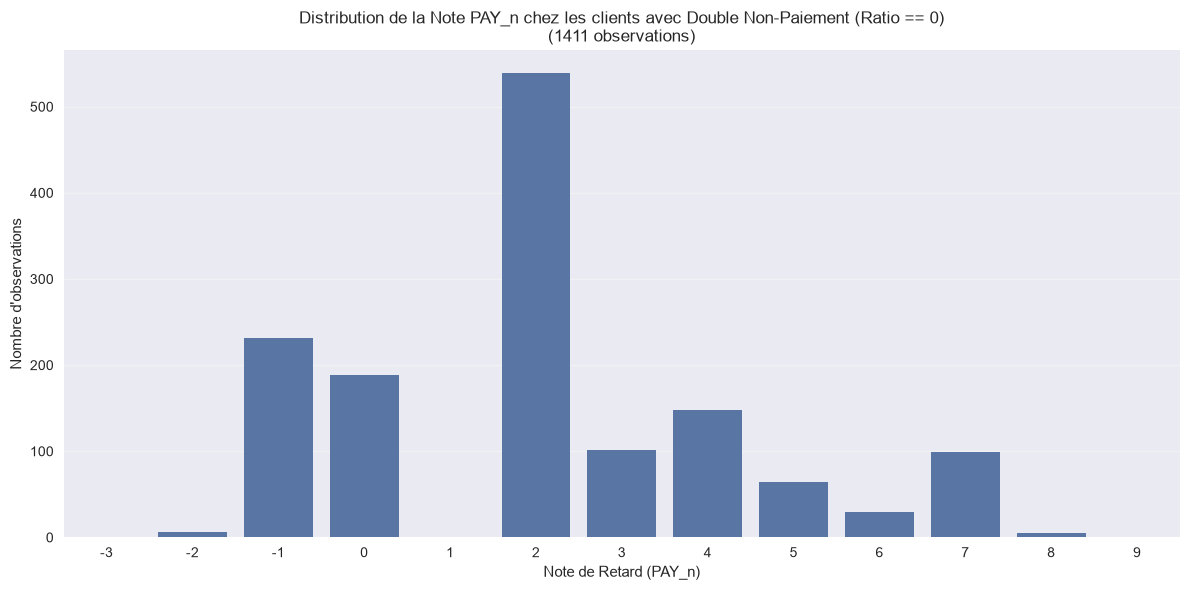

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes de ratio définies
ratio_columns = [
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# Liste pour stocker les notes PAY_n des clients en double non-paiement
notes_double_zero = []

print("--- Analyse : Notes PAY_n pour Double Ratio == 0 (Consécutif) ---")

# On boucle sur les paires de colonnes adjacentes
for i in range(len(ratio_columns) - 1):
    col_r1 = ratio_columns[i]      # Ratio du mois n (ex: ...PAY_AMT2...)
    col_r2 = ratio_columns[i+1]    # Ratio du mois n+1 (ex: ...PAY_AMT3...)

    # Identification de la colonne PAY_n associée au premier ratio
    pay_part = col_r1.split('_to_')[0] 
    n_str = pay_part.replace('ratio_', '').replace('PAY_BILL', '')
    col_pay_n = f"PAY_{n_str}"  # Ex: PAY_2
    
    if col_pay_n not in df.columns:
        continue

    # Condition : Les deux ratios consécutifs sont égaux à 0 (ou quasi-nul)
    # On utilise une petite marge de tolérance pour les flottants
    mask_double_zero = np.logical_and(
        np.abs(df[col_r1]) < 0.01, 
        np.abs(df[col_r2]) < 0.01
    )

    if mask_double_zero.sum() == 0:
        continue

    # On extrait la note PAY_n pour toutes les lignes qui satisfont cette condition
    notes_double_zero.extend(df.loc[mask_double_zero, col_pay_n].tolist())

# --- Analyse et Visualisation ---
if len(notes_double_zero) > 0:
    df_res = pd.DataFrame({'Note_Pay': notes_double_zero})
    
    print(f"\nNombre d'observations avec double ratio == 0 : {len(df_res)}")
    print("\nRépartition des notes PAY_n pour ces clients :")
    print(df_res['Note_Pay'].value_counts().sort_index())

    # Graphique de la distribution
    plt.figure(figsize=(12, 6))
    
    # On s'assure que l'axe X est bien ordonné même si certaines notes sont absentes
    min_note = df_res['Note_Pay'].min() if not df_res.empty else -6
    max_note = df_res['Note_Pay'].max() if not df_res.empty else 8
    
    sns.countplot(data=df_res, x='Note_Pay', order=range(int(min_note)-1, int(max_note)+2))
    
    plt.title(f'Distribution de la Note PAY_n chez les clients avec Double Non-Paiement (Ratio == 0)\n({len(df_res)} observations)')
    plt.xlabel('Note de Retard (PAY_n)')
    plt.ylabel('Nombre d\'observations')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("Aucun client trouvé avec un double ratio == 0 consécutif.")

**Interprétation**  
Pour un encours strictement positif, si un client ne paie rien pendant 2 mois consécutifs, PAY_n est plutot codifié en retard. Mais 400 clients sur 1400 ont toujours une note saine après 2 échéances impayées.  
C'est évidemment incohérent d'un point de vue métier.  
Ce sera problématique pour entraîner les modèles si la note des incidents est fortement faussée.  
Attention : un client peut apparaitre plusieurs fois dans le graphes s'il a plus de 2 ratios de paiement consécutifs impayés

--- Décompte des clients par nombre d'occurrences de Ratio == 0 ---
Nombre de clients avec exactement 0 fois un ratio nul : 22437
Nombre de clients avec exactement 1 fois un ratio nul : 5016
Nombre de clients avec exactement 2 fois un ratio nul : 1849
Nombre de clients avec exactement 3 fois un ratio nul : 407
Nombre de clients avec exactement 4 fois un ratio nul : 113
Nombre de clients avec exactement 5 fois un ratio nul : 174
Nombre de clients avec 6 ou plus de ratios nuls : 0


C:\Users\johan\AppData\Local\Temp\ipykernel_14588\582520041.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_plot, y=values_plot, palette='viridis')


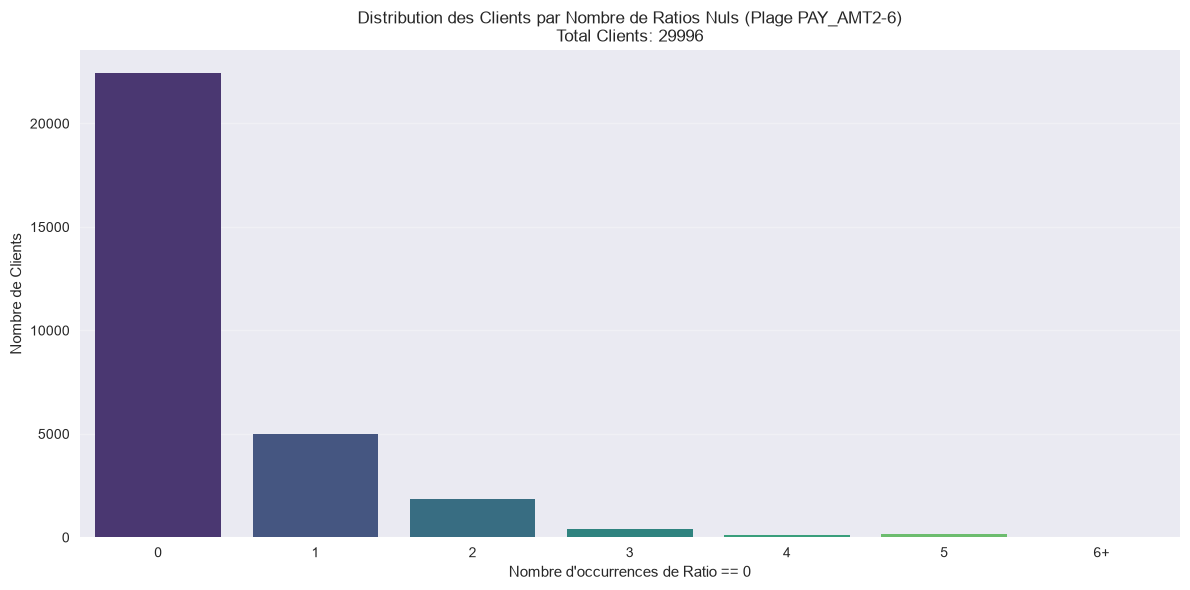

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols_ciblees = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

    
# 2. Création d'un masque booléen : True si le ratio est ~0, False sinon
# On utilise une tolérance très faible (< 0.01) pour éviter les problèmes d'arrondi float
mask_zeros = np.abs(df_ratios) < 0.01

# 3. Comptage des occurrences de zéro PAR CLIENT (par ligne)
# sum(axis=1) additionne les True (valeur 1) pour chaque ligne
zero_counts_per_client = mask_zeros.sum(axis=1)

# 4. Filtrage et Décompte pour les cas spécifiques (0, 1, ..., 5 fois)
# On filtre pour ne garder que les clients qui ont eu au moins un zero, 
# ou on garde tout si tu veux voir ceux à 0 aussi.
# Ici, je vais compter l'histogramme complet de 0 à max(zeros).

# Comptage des effectifs : combien de clients ont eu X occurrences ?
freq_distribution = zero_counts_per_client.value_counts().sort_index()



print("--- Décompte des clients par nombre d'occurrences de Ratio == 0 ---")

for i in range(6): # De 0 à 5
    count_clients = freq_distribution.get(i, 0)
    print(f"Nombre de clients avec exactement {i} fois un ratio nul : {count_clients}")
    
# Pour les cas > 5 (6, 7...)
clients_plus_5 = zero_counts_per_client[zero_counts_per_client >= 6].shape[0]
print(f"Nombre de clients avec 6 ou plus de ratios nuls : {clients_plus_5}")

# --- Visualisation Graphique ---
# On prépare les données pour le graphique en ne gardant que 0 à 5, et on regroupe >5 dans une catégorie "6+"
labels_plot = []
values_plot = []

for i in range(6):
    if i in freq_distribution.index:
        labels_plot.append(str(i))
        values_plot.append(freq_distribution[i])
    else:
        labels_plot.append(str(i))
        values_plot.append(0) # Si aucune donnée pour cette case
        
# Ajout du cas "6+"
labels_plot.append("6+")
values_plot.append(clients_plus_5)

plt.figure(figsize=(12, 6))
sns.barplot(x=labels_plot, y=values_plot, palette='viridis')
plt.title(f'Distribution des Clients par Nombre de Ratios Nuls (Plage PAY_AMT2-6)\nTotal Clients: {len(zero_counts_per_client)}')
plt.xlabel('Nombre d\'occurrences de Ratio == 0')
plt.ylabel('Nombre de Clients')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
import pandas as pd
import numpy as np

# Tes colonnes définies pour le calcul
cols_ciblees = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# 1. Calcul du nombre de zéros par client (ligne)
df_ratios = df[cols_ciblees]
# Masque : True si abs(ratio) < tolérance (pour gérer les flottants proches de 0)
mask_zeros = np.abs(df_ratios) < 0.01

# Somme par ligne -> nombre de colonnes ciblées qui sont ~0 pour ce client
counts_zeros_per_client = mask_zeros.sum(axis=1)

# --- BOUCLE SUR LES CAS DEMANDÉS (3, 4 et 5 fois) ---
cas_cibles = [3, 4, 5]

for nb_zeros in cas_cibles:
    print("\n" + "="*60)
    print(f"--- GROUPE : Clients avec EXACTEMENT {nb_zeros} Ratios Nuls ---")
    print("="*60)
    
    # On filtre l'index original pour le nombre exact de zéros
    idx_groupe = counts_zeros_per_client[counts_zeros_per_client == nb_zeros].index
    
    if len(idx_groupe) > 0:
        print(f"Nombre total de clients dans ce groupe : {len(idx_groupe)}")
        
        # On prend les 10 premières lignes COMPLETES du dataframe original
        df_head = df.loc[idx_groupe].head(10)
        
        print(f"\n--- APERÇU DES 10 PREMIÈRES LIGNES (LIGNES COMPLÈTES) ---")
        # pd.set_option pour afficher toutes les colonnes sans troncature si possible
        with pd.option_context('display.max_columns', None, 'display.width', 1000):
            print(df_head)
        
    else:
        print(f"Aucun client trouvé avec exactement {nb_zeros} ratios nuls.")

# --- RÉCAPITULATIF GLOBAL (pour info) ---
print("\n" + "="*60)
print("--- RÉCAPITULATIF DU NOMBRE DE CLIENTS PAR NOMBRE DE ZEROS ---")
print("="*60)

dist_zeros = counts_zeros_per_client.value_counts().sort_index()

for i in range(0, 6): # De 0 à 5
    count = dist_zeros.get(i, 0)
    print(f"Nombre de clients avec exactement {i} ratio(s) nul(s) : {count}")




--- GROUPE : Clients avec EXACTEMENT 3 Ratios Nuls ---
Nombre total de clients dans ce groupe : 407

--- APERÇU DES 10 PREMIÈRES LIGNES (LIGNES COMPLÈTES) ---
     LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5  ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  ratio_PAY_BILL5  ratio_PAY_to_BILL_median                       CTX_Trajectoire  Max_PAY_6m  Duree_PAY2_Consecutif            Segment_PAY2_Disjoint
ID                                                                                                                                                                                                                                                                                                   

Quand on regarde le détail de quelques lignes, des incohérentes flagrantes sont visibles dans la codification des colonnes 'PAY_n'.  
On observe un changement de codification en PAY_2 avec des incidents qui redescendent à 2 sans payement de la part des clients, et pour lesquels l'encours est stable sur les 6 mois.  
Pour les modèles et pour la visualisation ces changements de codification sont problématiques

Je crée une feature 'ratio_BILL_LIMITn' pour voir l'utilisation par rapport au plafond chaque mois

In [97]:
import pandas as pd
import numpy as np

# Vérification rapide des colonnes BILL_AMT existantes
bill_cols = [col for col in df.columns if col.startswith('BILL_AMT')]
print(f"Colonnes BILL_AMT trouvées : {bill_cols}")

# Boucle pour créer les 6 nouvelles colonnes de ratio
for i in range(1, 7):
    df[f'ratio_BILL_LIMIT{i}'] = (np.maximum(df[f'BILL_AMT{i}'], 0) / df['LIMIT_BAL']) * 100

# Affichage des premières lignes pour inspection
# On filtre pour ne voir que les colonnes BILL_AMT et ratio_BILL_LIMIT concernées
cols_to_show = bill_cols + [f'ratio_BILL_LIMIT{n}' for n in range(1, 7)]+['LIMIT_BAL']
pd.option_context('display.max_columns', None, 'display.width', 1000)

print("\n--- Aperçu des nouveaux ratios ---")
df[cols_to_show].head(10)

Colonnes BILL_AMT trouvées : ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

--- Aperçu des nouveaux ratios ---


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6,LIMIT_BAL
ID,,,,,,,,,,,,,
1,3913,3102,689,0,0,0,19.565000,15.510000,3.445000,0.000000,0.000000,0.000000,20000
2,2682,1725,2682,3272,3455,3261,2.235000,1.437500,2.235000,2.726667,2.879167,2.717500,120000
3,29239,14027,13559,14331,14948,15549,32.487778,15.585556,15.065556,15.923333,16.608889,17.276667,90000
4,46990,48233,49291,28314,28959,29547,93.980000,96.466000,98.582000,56.628000,57.918000,59.094000,50000
5,8617,5670,35835,20940,19146,19131,17.234000,11.340000,71.670000,41.880000,38.292000,38.262000,50000
6,64400,57069,57608,19394,19619,20024,128.800000,114.138000,115.216000,38.788000,39.238000,40.048000,50000
7,367965,412023,445007,542653,483003,473944,73.593000,82.404600,89.001400,108.530600,96.600600,94.788800,500000
8,11876,380,601,221,-159,567,11.876000,0.380000,0.601000,0.221000,0.000000,0.567000,100000
9,11285,14096,12108,12211,11793,3719,8.060714,10.068571,8.648571,8.722143,8.423571,2.656429,140000


In [98]:
cols_ratio = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# Statistiques descriptives détaillées des 6 colonnes de ratio (transposées pour une meilleure lisibilité)
df[cols_ratio].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T

,count,mean,std,min,5%,25%,50%,75%,90%,95%,99%,max
ratio_BILL_LIMIT1,29996.0,42.395587,41.126764,0.0,0.0,2.203167,31.399386,82.989413,98.162778,101.312412,123.194646,645.530
ratio_BILL_LIMIT2,29996.0,41.138631,40.416234,0.0,0.0,1.832621,29.605750,80.650000,97.840000,101.036584,116.423837,638.050
ratio_BILL_LIMIT3,29996.0,39.202319,39.119409,0.0,0.0,1.602141,27.297667,75.499163,96.975833,100.165417,111.650879,539.140
ratio_BILL_LIMIT4,29996.0,35.990505,36.806109,0.0,0.0,1.429853,24.204586,66.799970,93.953000,98.626417,105.478263,514.685
ratio_BILL_LIMIT5,29996.0,33.346320,35.005624,0.0,0.0,1.113309,21.202632,60.224500,90.056111,97.430000,103.094214,493.550
ratio_BILL_LIMIT6,29996.0,31.902083,34.443932,0.0,0.0,0.780000,18.517267,58.210500,88.634444,97.384062,102.230300,388.555


In [99]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_brut_PAY_BILL1', 'ratio_brut_PAY_BILL2', 'ratio_brut_PAY_BILL3',
       'ratio_brut_PAY_BILL4', 'ratio_brut_PAY_BILL5', 'ratio_PAY_BILL1',
       'ratio_PAY_BILL2', 'ratio_PAY_BILL3', 'ratio_PAY_BILL4',
       'ratio_PAY_BILL5', 'ratio_PAY_to_BILL_median', 'CTX_Trajectoire',
       'Max_PAY_6m', 'Duree_PAY2_Consecutif', 'Segment_PAY2_Disjoint',
       'ratio_BILL_LIMIT1', 'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3',
       'ratio_BILL_LIMIT4', 'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6'],
      dtype='str')

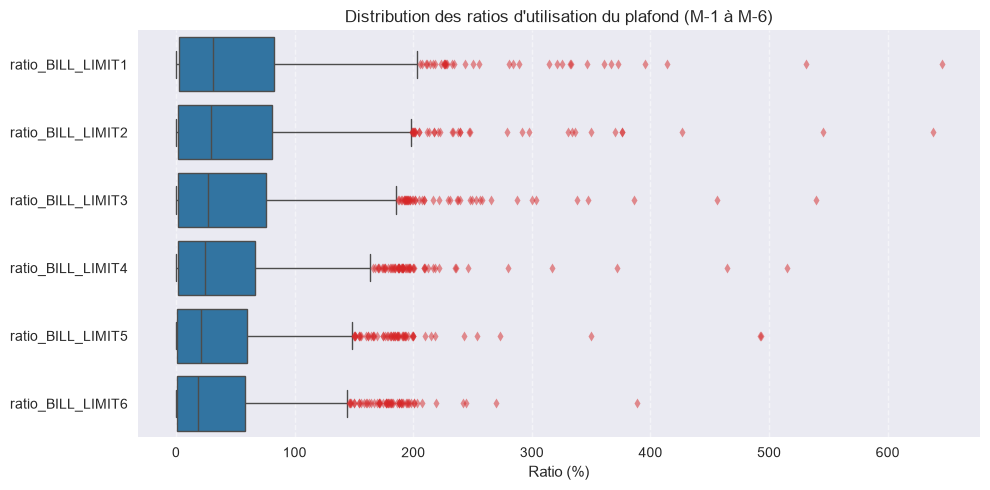

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [
    'ratio_BILL_LIMIT1', 'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3',
    'ratio_BILL_LIMIT4', 'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6'
]

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[ratio_cols],
    orient='h',
    color='#1f77b4',
    flierprops={'marker': 'd', 'markerfacecolor': '#d62728', 'markeredgecolor': 'none', 'alpha': 0.5, 'markersize': 5}
)

plt.title("Distribution des ratios d'utilisation du plafond (M-1 à M-6)")
plt.xlabel('Ratio (%)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interprétation**  
Des valeurs extremes difficilement explicable mais 2 théories non vérifiables :
- plafond baissé par la banque pour problème de paiement ou revue des revenus du client
- erreur de saisie dans le montant à devoir (il arrive que des montants soient multpliés par 100)
On peut essayer de controler si c'est une anomalie temporaire ou systémique chez un client

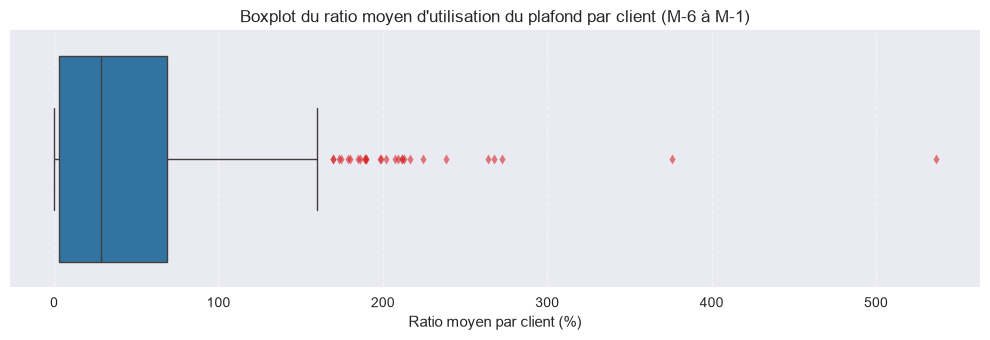

Nombre de clients avec un ratio moyen > 150 % : 37


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6,ratio_mean_client
ID,,,,,,,,,,,,,,
671,30000,99568,32326,31840,37075,37662,36904,331.893333,107.753333,106.133333,123.583333,125.540000,123.013333,152.986111
919,240000,471814,478380,395612,386295,356206,352257,196.589167,199.325000,164.838333,160.956250,148.419167,146.773750,169.483611
969,20000,42784,41009,44267,47149,48497,14774,213.920000,205.045000,221.335000,235.745000,242.485000,73.870000,198.733333
1676,50000,90231,90647,92309,93880,99418,101392,180.462000,181.294000,184.618000,187.760000,198.836000,202.784000,189.292333
2899,20000,66599,67259,69521,16970,17326,17688,332.995000,336.295000,347.605000,84.850000,86.630000,88.440000,212.802500
2917,20000,43340,42619,35381,31539,27409,23567,216.700000,213.095000,176.905000,157.695000,137.045000,117.835000,169.879167
3797,20000,129106,127610,107828,102937,98525,77711,645.530000,638.050000,539.140000,514.685000,492.625000,388.555000,536.430833
4223,30000,69707,71904,62630,57406,46231,73262,232.356667,239.680000,208.766667,191.353333,154.103333,244.206667,211.744444
4383,40000,144397,147924,26974,22710,37977,39347,360.992500,369.810000,67.435000,56.775000,94.942500,98.367500,174.720417


In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# 1. Calcul du ratio moyen et max par client
df['ratio_mean_client'] = df[ratio_cols].mean(axis=1)
df['ratio_max_client'] = df[ratio_cols].max(axis=1)

# 2. Boxplot du ratio moyen par client
plt.figure(figsize=(10, 3.5))
sns.boxplot(
    x=df['ratio_mean_client'],
    color='#1f77b4',
    flierprops={'marker': 'd', 'markerfacecolor': '#d62728', 'markeredgecolor': 'none', 'alpha': 0.6, 'markersize': 5}
)

plt.title("Boxplot du ratio moyen d'utilisation du plafond par client (M-6 à M-1)")
plt.xlabel("Ratio moyen par client (%)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Sélection et affichage des lignes des clients avec un ratio moyen > 200 %
cols_cles = ['LIMIT_BAL'] + [f'BILL_AMT{i}' for i in range(1, 7)] + ratio_cols + ['ratio_mean_client']
clients_sup_150 = df[df['ratio_mean_client'] > 150][cols_cles]

print(f"Nombre de clients avec un ratio moyen > 150 % : {len(clients_sup_150)}")
clients_sup_150

Ces valeurs semblent etre un comportement d'usage excessif volontaaire des clients et non une anomalie  
j'écrête ces valeurs à 200 % (0 en bas pour les encours négatifs), comme dans le storytelling, Streamlit et le ML, pour éviter les distorsions.
Je créerai une feature 'usage_excessif' pour les clients ayant un ratio_BILL_LIMIT conséquent (à partir de 120 ou 150)

In [102]:
ratio_cols = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# Écrêtage directement sur les colonnes d'origine
for col in ratio_cols:
    df[col] = df[col].clip(lower=0, upper=200)

# Recalcul des métriques agrégées par client
df['ratio_mean_client'] = df[ratio_cols].mean(axis=1)
df['ratio_max_client'] = df[ratio_cols].max(axis=1)

# Vérification : le maximum doit désormais être à 200.00
df[ratio_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ratio_BILL_LIMIT1,29996.0,42.288866,40.463846,0.0,2.203167,31.399386,82.989413,200.0
ratio_BILL_LIMIT2,29996.0,41.047089,39.817960,0.0,1.832621,29.605750,80.650000,200.0
ratio_BILL_LIMIT3,29996.0,39.137840,38.720131,0.0,1.602141,27.297667,75.499163,200.0
ratio_BILL_LIMIT4,29996.0,35.951729,36.530494,0.0,1.429853,24.204586,66.799970,200.0
ratio_BILL_LIMIT5,29996.0,33.314724,34.756724,0.0,1.113309,21.202632,60.224500,200.0
ratio_BILL_LIMIT6,29996.0,31.889608,34.361416,0.0,0.780000,18.517267,58.210500,200.0


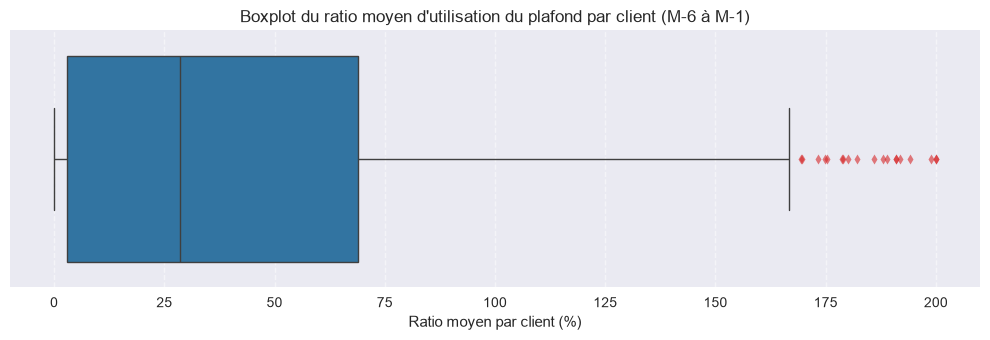

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# 1. Calcul du ratio moyen et max par client
df['ratio_mean_client'] = df[ratio_cols].mean(axis=1)
df['ratio_max_client'] = df[ratio_cols].max(axis=1)

# 2. Boxplot du ratio moyen par client
plt.figure(figsize=(10, 3.5))
sns.boxplot(
    x=df['ratio_mean_client'],
    color='#1f77b4',
    flierprops={'marker': 'd', 'markerfacecolor': '#d62728', 'markeredgecolor': 'none', 'alpha': 0.6, 'markersize': 5}
)

plt.title("Boxplot du ratio moyen d'utilisation du plafond par client (M-6 à M-1)")
plt.xlabel("Ratio moyen par client (%)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


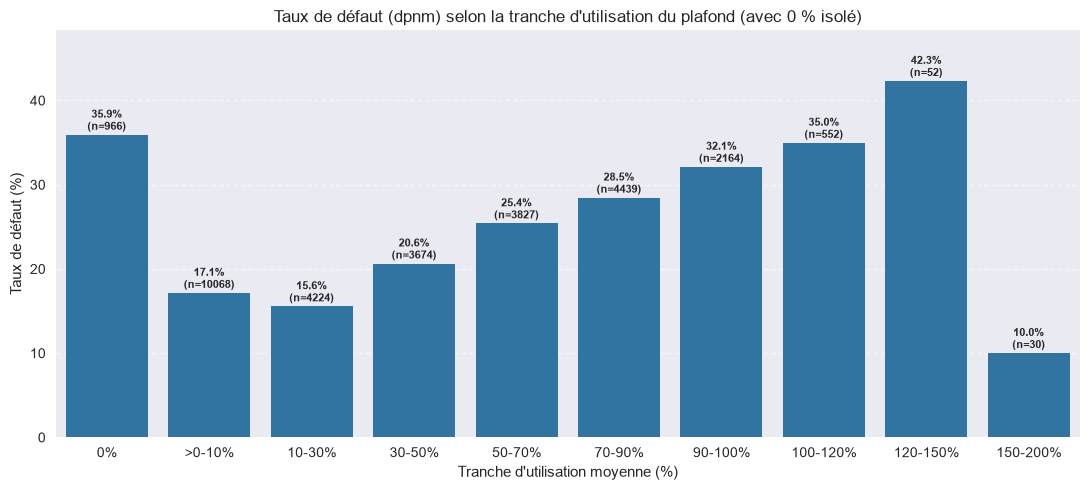

,ratio_mean_bin,nb_clients,taux_defaut
0,0%,966,35.921325
1,>0-10%,10068,17.143425
2,10-30%,4224,15.553977
3,30-50%,3674,20.631464
4,50-70%,3827,25.398484
5,70-90%,4439,28.452354
6,90-100%,2164,32.116451
7,100-120%,552,34.963768
8,120-150%,52,42.307692
9,150-200%,30,10.000000


In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Redéfinition des tranches en isolant exactement la valeur 0 %
bins = [-0.01, 0.0, 10, 30, 50, 70, 90, 100, 120, 150, 200]
labels = ['0%', '>0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%', '100-120%', '120-150%', '150-200%']

df['ratio_mean_bin'] = pd.cut(df['ratio_mean_client'], bins=bins, labels=labels)

# 2. Agrégation : effectifs et taux de défaut moyen (dpnm)
stats_defaut = df.groupby('ratio_mean_bin', observed=False)['dpnm'].agg(
    nb_clients='count',
    taux_defaut=lambda x: x.mean() * 100
).reset_index()

# 3. Tracé du graphique avec le bin 0 % isolé
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=stats_defaut, x='ratio_mean_bin', y='taux_defaut', color='#1f77b4')

plt.title("Taux de défaut (dpnm) selon la tranche d'utilisation du plafond (avec 0 % isolé)")
plt.xlabel("Tranche d'utilisation moyenne (%)")
plt.ylabel("Taux de défaut (%)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotation du taux de défaut et du nombre de clients par barre
for i, row in stats_defaut.iterrows():
    if not pd.isna(row['taux_defaut']):
        plt.text(
            i, 
            row['taux_defaut'] + 0.6, 
            f"{row['taux_defaut']:.1f}%\n(n={int(row['nb_clients'])})", 
            ha='center', 
            fontsize=8, 
            fontweight='bold'
        )

plt.ylim(0, max(stats_defaut['taux_defaut'].dropna(), default=30) + 6)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
stats_defaut

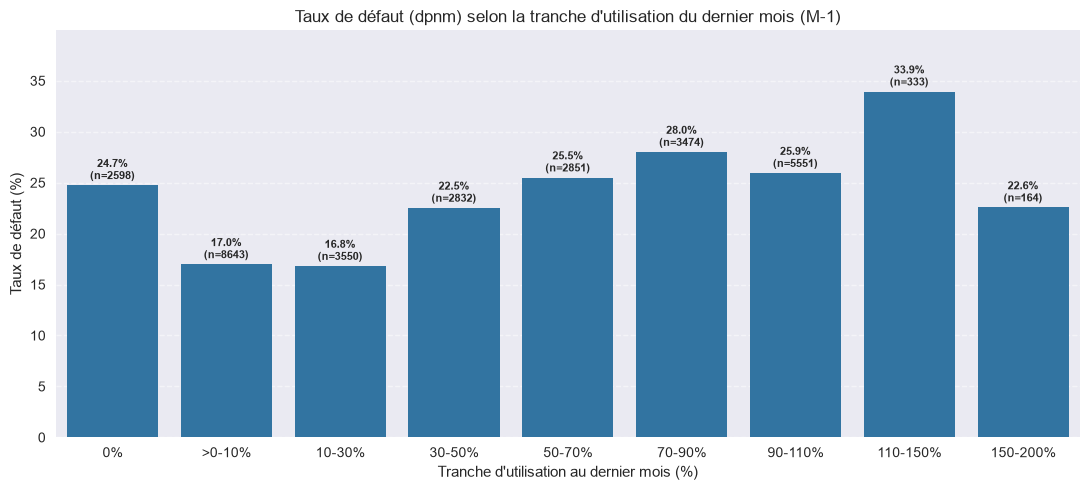

,ratio_m1_bin,nb_clients,taux_defaut
0,0%,2598,24.749808
1,>0-10%,8643,16.984843
2,10-30%,3550,16.816901
3,30-50%,2832,22.528249
4,50-70%,2851,25.499825
5,70-90%,3474,28.008060
6,90-110%,5551,25.941272
7,110-150%,333,33.933934
8,150-200%,164,22.560976


In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tranches d'utilisation uniquement sur le dernier mois (ratio_BILL_LIMIT1)
bins = [-0.01, 0.0, 10, 30, 50, 70, 90, 110, 150, 200]
labels = ['0%', '>0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-110%', '110-150%', '150-200%']

df['ratio_m1_bin'] = pd.cut(df['ratio_BILL_LIMIT1'], bins=bins, labels=labels)

# 2. Agrégation : effectifs et taux de défaut (dpnm) sur M-1
stats_defaut_m1 = df.groupby('ratio_m1_bin', observed=False)['dpnm'].agg(
    nb_clients='count',
    taux_defaut=lambda x: x.mean() * 100
).reset_index()

# 3. Tracé du graphique
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=stats_defaut_m1, x='ratio_m1_bin', y='taux_defaut', color='#1f77b4')

plt.title("Taux de défaut (dpnm) selon la tranche d'utilisation du dernier mois (M-1)")
plt.xlabel("Tranche d'utilisation au dernier mois (%)")
plt.ylabel("Taux de défaut (%)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotation des barres
for i, row in stats_defaut_m1.iterrows():
    if not pd.isna(row['taux_defaut']):
        plt.text(
            i, 
            row['taux_defaut'] + 0.6, 
            f"{row['taux_defaut']:.1f}%\n(n={int(row['nb_clients'])})", 
            ha='center', 
            fontsize=8, 
            fontweight='bold'
        )

plt.ylim(0, max(stats_defaut_m1['taux_defaut'].dropna(), default=30) + 6)
plt.tight_layout()
plt.show()

# Tableau récapitulatif M-1
stats_defaut_m1

**Interprétation**  
Hausse du défaut de paiement en fonction de l'utilisation du plafond.  
2598 clients sans encours ayant un défaut de paiement, certains ayant meme un encours <=0 sur les 6 derniers mois.  
Pour rappel : les 30 000 clients, y compris inactifs, sont présents dans cet EDA  
C'est techniquement impossible d'avoir un incident si on n'a pas d'encours -> il s'agit d'une anomalie ou ce défaut de paiement futur est un autre type de défaut (administratif, impayé sur un dossier géré au contentieux)

In [106]:
import pandas as pd

# 1. Calcul du ratio moyen par client si non déjà présent dans le DataFrame
cols_ratio = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]
df['ratio_mean_client'] = df[cols_ratio].mean(axis=1)

# 2. Filtrage des clients ayant une moyenne de ratio strictement égale à 0
df_ratio_zero = df[df['ratio_mean_client'] == 0].copy()

# 3. Sélection des colonnes pertinentes pour une inspection claire
cols_a_afficher = (
    ['LIMIT_BAL'] +
    [f'PAY_{i}' for i in range(1, 7) if f'PAY_{i}' in df.columns] +
    [f'BILL_AMT{i}' for i in range(1, 7)] +
    [f'PAY_AMT{i}' for i in range(1, 7)] +
    ['dpnm']
)

print(f"Nombre de clients avec ratio moyen = 0 % : {len(df_ratio_zero)}")

# Affichage du sous-ensemble de données
df_ratio_zero[cols_a_afficher]

Nombre de clients avec ratio moyen = 0 % : 966


,LIMIT_BAL,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,
19,360000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
20,180000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
46,210000,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
80,240000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
110,360000,1,-2,-2,-2,-2,-2,-103,-103,-103,-103,-103,-103,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29910,360000,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
29923,150000,1,-2,-2,-2,-2,-2,-18,-18,-18,-18,-18,-18,0,0,0,0,0,0,0
29974,230000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1


In [107]:
import pandas as pd

cols_pay = [f'PAY_{i}' for i in range(1, 7) if f'PAY_{i}' in df.columns]
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]

# 1. Isolation des clients ayant -2 sur l'ensemble des 6 mois
mask_always_minus2 = (df[cols_pay] == -2).all(axis=1)

# 2. Séparation : Avec au moins un encours positif VS strictement aucun encours
mask_has_positive_bill = (df[cols_bill] > 0).any(axis=1)

# Groupe 1 : Faux inactifs (PAY_n = -2 continu MAIS BILL_AMT > 0)
df_faux_inactifs = df[mask_always_minus2 & mask_has_positive_bill]

# Groupe 2 : Vrais inactifs (PAY_n = -2 ET BILL_AMT <= 0 partout)
df_vrais_inactifs = df[mask_always_minus2 & ~mask_has_positive_bill]

print("--- Décomposition des clients à PAY_n == -2 continu ---")
print(f"1. Vrais inactifs (Encours <= 0) : {len(df_vrais_inactifs)} clients | Taux de défaut : {df_vrais_inactifs['dpnm'].mean()*100:.2f}%")
print(f"2. Faux inactifs (Encours > 0)  : {len(df_faux_inactifs)} clients | Taux de défaut : {df_faux_inactifs['dpnm'].mean()*100:.2f}%")

--- Décomposition des clients à PAY_n == -2 continu ---
1. Vrais inactifs (Encours <= 0) : 361 clients | Taux de défaut : 32.69%
2. Faux inactifs (Encours > 0)  : 1748 clients | Taux de défaut : 9.50%


In [108]:
# Vérification des PAY_AMTn pour les vrais inactifs
cols_pay_amt = [f'PAY_AMT{i}' for i in range(1, 7)]

# Sont-ils tous à 0 ou <= 0 sur les 6 mois ?
all_pay_amt_zero = (df_vrais_inactifs[cols_pay_amt] <= 0).all(axis=1).sum()

print(f"Sur les 361 vrais inactifs :")
print(f"- Nombre avec des PAY_AMT <= 0 sur toute la période : {all_pay_amt_zero}")
print(f"- Nombre avec au moins un PAY_AMT > 0 : {len(df_vrais_inactifs) - all_pay_amt_zero}")

Sur les 361 vrais inactifs :
- Nombre avec des PAY_AMT <= 0 sur toute la période : 320
- Nombre avec au moins un PAY_AMT > 0 : 41


In [109]:
import pandas as pd

# 1. Calcul du ratio moyen par client si non déjà présent dans le DataFrame
cols_ratio = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]
df['ratio_mean_client'] = df[cols_ratio].mean(axis=1)

# 2. Filtrage des clients ayant une moyenne de ratio strictement égale à 0
df_ratio_zero = df[df['ratio_mean_client'] == 0].copy()

# 3. Sélection des colonnes pertinentes pour une inspection claire
cols_a_afficher = (
    ['LIMIT_BAL'] +
    [f'PAY_{i}' for i in range(1, 7) if f'PAY_{i}' in df.columns] +
    [f'BILL_AMT{i}' for i in range(1, 7)] +
    [f'PAY_AMT{i}' for i in range(1, 7)] +
    ['dpnm']
)

print(f"Nombre de clients avec ratio moyen = 0 % : {len(df_ratio_zero)}")

# Affichage du sous-ensemble de données
df_ratio_zero[cols_a_afficher]

Nombre de clients avec ratio moyen = 0 % : 966


,LIMIT_BAL,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,
19,360000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
20,180000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
46,210000,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
80,240000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
110,360000,1,-2,-2,-2,-2,-2,-103,-103,-103,-103,-103,-103,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29910,360000,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
29923,150000,1,-2,-2,-2,-2,-2,-18,-18,-18,-18,-18,-18,0,0,0,0,0,0,0
29974,230000,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1


In [110]:
import pandas as pd

results = []

for n in range(1, 6):
    pay_col = f'PAY_{n}'
    bill_col = f'BILL_AMT{n+1}'
    
    if pay_col in df.columns and bill_col in df.columns:
        mask_minus2 = (df[pay_col] == -2)
        total_minus2 = mask_minus2.sum()
        
        if total_minus2 > 0:
            # Encours positif ( > 0 ) pour un statut -2
            count_positive = (mask_minus2 & (df[bill_col] > 0)).sum()
            rate_positive = (count_positive / total_minus2) * 100
            
            # Encours nul ou négatif ( <= 0 ) pour un statut -2 (les "vrais" inactifs)
            count_le_zero = (mask_minus2 & (df[bill_col] <= 0)).sum()
            rate_le_zero = (count_le_zero / total_minus2) * 100
            
            results.append({
                'Mois': f'M-{n} (PAY_{n} & BILL_{n})',
                'Total PAY_n = -2': total_minus2,
                'Encours > 0 (Faux inactifs) %': round(rate_positive, 2),
                'Encours <= 0 (Vrais inactifs) %': round(rate_le_zero, 2)
            })

df_Bilan_Minus2 = pd.DataFrame(results)
df_Bilan_Minus2

,Mois,Total PAY_n = -2,Encours > 0 (Faux inactifs) %,Encours <= 0 (Vrais inactifs) %
0,M-1 (PAY_1 & BILL_1),2758,65.52,34.48
1,M-2 (PAY_2 & BILL_2),3781,50.46,49.54
2,M-3 (PAY_3 & BILL_3),4084,44.34,55.66
3,M-4 (PAY_4 & BILL_4),4347,41.66,58.34
4,M-5 (PAY_5 & BILL_5),4544,39.04,60.96


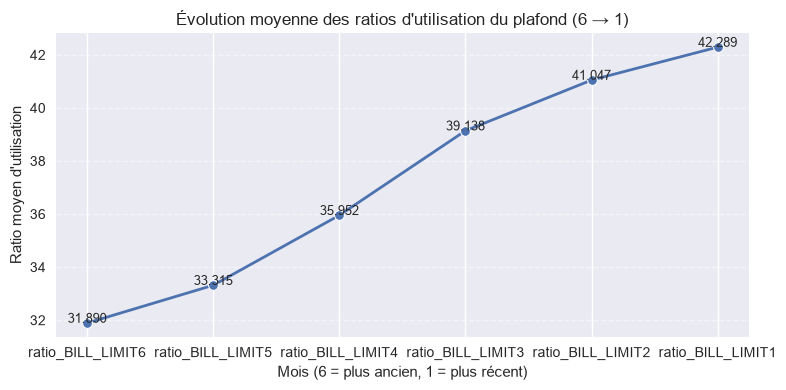

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Liste des colonnes dans l'ordre souhaité (6 -> 1)
colonnes = [
    'ratio_BILL_LIMIT6', 
    'ratio_BILL_LIMIT5', 
    'ratio_BILL_LIMIT4', 
    'ratio_BILL_LIMIT3', 
    'ratio_BILL_LIMIT2', 
    'ratio_BILL_LIMIT1'
]

# Filtrer pour ne garder que celles qui existent dans ton dataframe
colonnes_presentes = [c for c in colonnes if c in df.columns]

if colonnes_presentes:
    # 2. Calcul de la moyenne par colonne
    moyennes = df[colonnes_presentes].mean()

    # 3. Visualisation simple (courbe linéaire pour voir l'évolution)
    plt.figure(figsize=(8, 4))
    
    # On utilise les index (6,5,4...) pour l'axe X et les valeurs moyennes pour l'axe Y
    sns.lineplot(x=moyennes.index, y=moyennes.values, marker='o', linewidth=2)
    
    plt.title('Évolution moyenne des ratios d\'utilisation du plafond (6 → 1)')
    plt.xlabel('Mois (6 = plus ancien, 1 = plus récent)')
    plt.ylabel('Ratio moyen d\'utilisation')
    
    # Ajouter les valeurs sur les points pour plus de clarté
    for i, v in enumerate(moyennes.values):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Vérifie les noms des colonnes dans ton dataframe.")

**Interprétation**
Sur les 6 mois, le taux d'utilisation des cartes actives a bondi de 10 points en moyenne

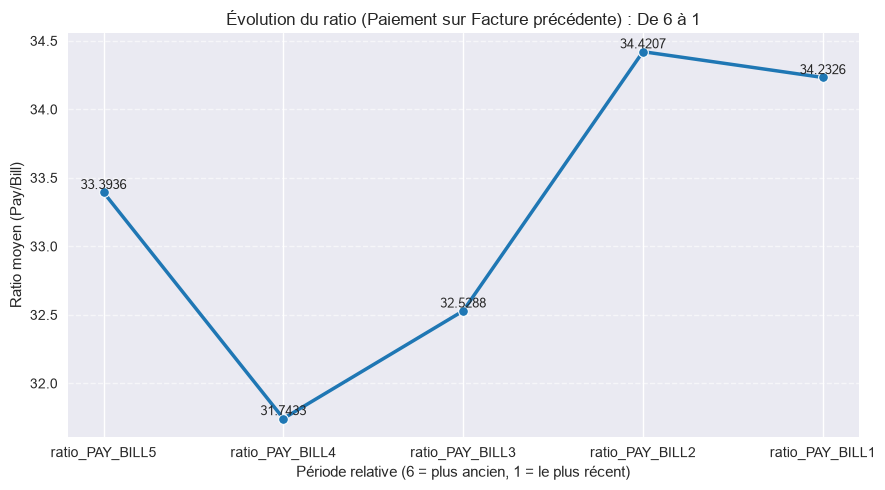

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition de l'ordre d'affichage souhaité (de 6 à 1)
# On construit la liste en partant du suffixe 6 jusqu'à 1
ordre_souhaite = [f'ratio_PAY_BILL{i}' for i in range(5, 0, -1)]

# Filtrer pour ne garder que les colonnes réellement présentes dans le dataframe
colonnes_actives = [col for col in ordre_souhaite if col in df.columns]

if len(colonnes_actives) > 0:
    # 2. Extraction des données et calcul de la moyenne par mois
    # On prend les colonnes dans l'ordre du graphique (6 -> 1)
    df_temp = ratios_affichables(df, colonnes_actives)
    
    # Calcul des moyennes
    moyennes = df_temp.mean()

    # 3. Visualisation
    plt.figure(figsize=(9, 5))
    
    # sns.lineplot prend les index (6,5,4...) comme axe X et les valeurs moyennes en Y
    sns.lineplot(
        x=moyennes.index, 
        y=moyennes.values, 
        marker='o', 
        linewidth=2.5,
        color='#1f77b4'  # Bleu standard pour la clarté
    )

    plt.title('Évolution du ratio (Paiement sur Facture précédente) : De 6 à 1')
    plt.xlabel('Période relative (6 = plus ancien, 1 = le plus récent)')
    plt.ylabel('Ratio moyen (Pay/Bill)')
    
    # Ajout des valeurs textuelles pour précision
    for i, val in enumerate(moyennes.values):
        plt.text(i, val + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print(f"Attention : Aucune des colonnes de la liste '{ordre_souhaite}' n'a été trouvée.")

**Interprétation**  
pas de tendance  
Mais la moyenne est très affectée par des valeurs aberrantes, je regarde plutot la médiane pour cette valeur :

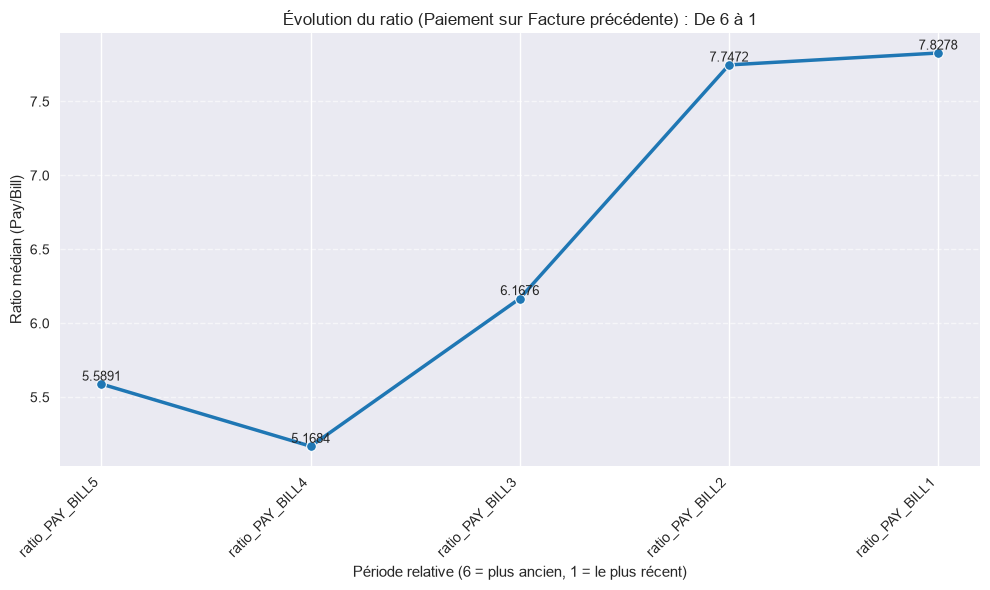

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition de l'ordre d'affichage souhaité (de 6 à 1)
ordre_souhaite = [f'ratio_PAY_BILL{i}' for i in range(5, 0, -1)]

# Filtrer pour ne garder que les colonnes réellement présentes dans le dataframe
colonnes_actives = [col for col in ordre_souhaite if col in df.columns]

if len(colonnes_actives) > 0:
    # 2. Extraction des données et calcul de la médiane par période
    df_temp = ratios_affichables(df, colonnes_actives)
    medianes = df_temp.median()

    # 3. Visualisation
    plt.figure(figsize=(10, 6))
    
    # Tracer la ligne avec les médianes
    sns.lineplot(
        x=medianes.index,
        y=medianes.values,
        marker='o',
        linewidth=2.5,
        color='#1f77b4'
    )

    plt.title('Évolution du ratio (Paiement sur Facture précédente) : De 6 à 1')
    plt.xlabel('Période relative (6 = plus ancien, 1 = le plus récent)')
    plt.ylabel('Ratio médian (Pay/Bill)')

    # Ajout des valeurs textuelles
    for i, val in enumerate(medianes.values):
        plt.text(i, val + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    # Ajuster les ticks sur l'axe X pour améliorer la lisibilité
    plt.xticks(rotation=45, ha='right')

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print(f"Attention : Aucune des colonnes de la liste '{ordre_souhaite}' n'a été trouvée.")

**Interprétation**
Evolution en hausse sur les 3 derniers mois

C:\Users\johan\AppData\Local\Temp\ipykernel_14588\9591273.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proportions_pct.index, y=proportions_pct.values, palette='viridis')


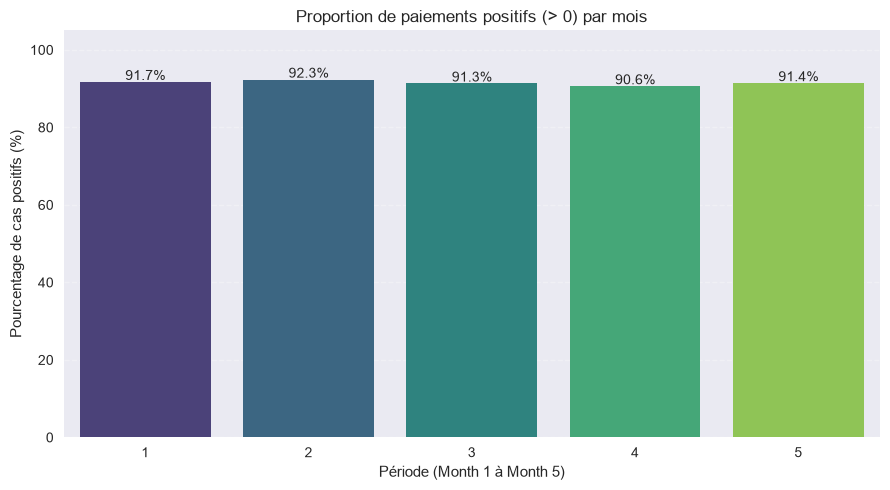

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des colonnes dans l'ordre "1 vers 5" (comme demandé : Month 1 à Month 5)
# Note: Month 1 est le plus récent, Month 5 est le plus ancien de cet ensemble
colonnes = [
    'ratio_PAY_BILL1',  # Month 1
    'ratio_PAY_BILL2',  # Month 2
    'ratio_PAY_BILL3',  # Month 3
    'ratio_PAY_BILL4',  # Month 4
    'ratio_PAY_BILL5'   # Month 5
]

# Filtrer pour ne garder que les colonnes présentes
colonnes_actives = [c for c in colonnes if c in df.columns]

if len(colonnes_actives) >= 2:
    # 2. Calcul de la proportion de valeurs > 0 pour chaque colonne
    # .mean() sur un booléen (condition > 0) donne la fraction de True (positifs)
    proportions = ratios_affichables(df, colonnes_actives).apply(lambda x: (x.dropna() > 0).mean())

    # Normalisation en pourcentage pour l'affichage
    proportions_pct = proportions * 100

    # 3. Visualisation en histogramme (bar chart)
    plt.figure(figsize=(9, 5))
    
    sns.barplot(x=proportions_pct.index, y=proportions_pct.values, palette='viridis')
    
    # Ajouter les valeurs sur les barres pour plus de clarté
    for i, val in enumerate(proportions_pct.values):
        plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

    plt.title('Proportion de paiements positifs (> 0) par mois')
    plt.xlabel('Période (Month 1 à Month 5)')
    plt.ylabel('Pourcentage de cas positifs (%)')
    
    # Personnalisation de l'axe X pour être très clair
    labels = [c.replace('ratio_PAY_BILL', '') for c in proportions_pct.index]
    plt.xticks(range(len(proportions_pct.index)), labels)

    plt.ylim(0, 105) # Petit marge au dessus
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Il manque des colonnes pour réaliser l'analyse.")

**Interprétation**  
La proportion de clients qui paient tout ou partie de leur échéance augmente.  
Il faut aussi y voir que 20% des échéances ne sont pas honorées dans les 30 jours !

C:\Users\johan\AppData\Local\Temp\ipykernel_14588\1244666821.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proportions_pct.index, y=proportions_pct.values, palette='viridis')


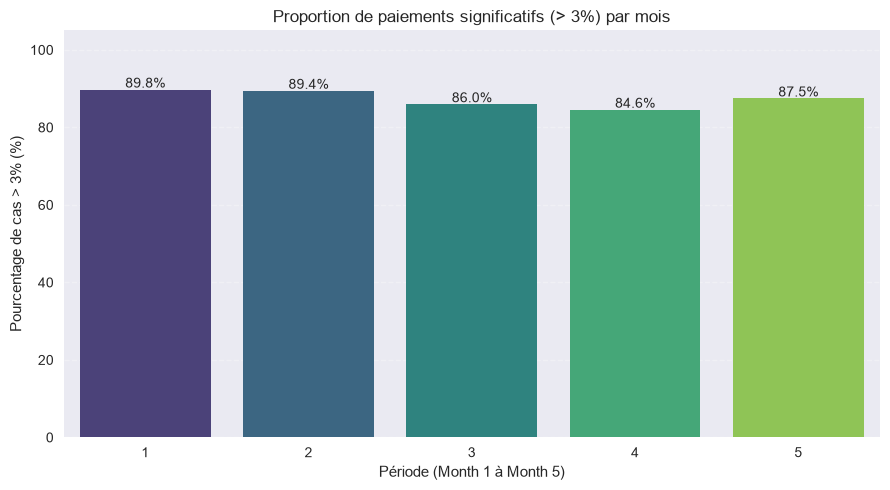

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des colonnes (Month 1 à Month 5)
colonnes = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2',
    'ratio_PAY_BILL3',
    'ratio_PAY_BILL4',
    'ratio_PAY_BILL5'
]

# Filtrer pour ne garder que les colonnes présentes
colonnes_actives = [c for c in colonnes if c in df.columns]

if len(colonnes_actives) >= 2:
    # 2. Calcul de la proportion où le ratio est STRICTEMENT SUPÉRIEUR à 0.03 (3%)
    # On applique la condition > 0.03 colonne par colonne
    proportions = ratios_affichables(df, colonnes_actives).apply(lambda x: (x.dropna() > 3).mean())

    # En pourcentage
    proportions_pct = proportions * 100

    # 3. Visualisation en histogramme
    plt.figure(figsize=(9, 5))
    
    # On garde la même palette ou on change selon ta préférence (ici 'viridis' reste lisible)
    sns.barplot(x=proportions_pct.index, y=proportions_pct.values, palette='viridis')
    
    # Ajout des valeurs sur les barres
    for i, val in enumerate(proportions_pct.values):
        plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

    plt.title('Proportion de paiements significatifs (> 3%) par mois')
    plt.xlabel('Période (Month 1 à Month 5)')
    plt.ylabel('Pourcentage de cas > 3% (%)')
    
    # Labels X clairs (1, 2, 3, 4, 5)
    labels = [c.replace('ratio_PAY_BILL', '') for c in proportions_pct.index]
    plt.xticks(range(len(proportions_pct.index)), labels)

    plt.ylim(0, 105) 
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Colonnes manquantes pour l'analyse.")

**Interprétation**  
Même tendance, mais on voit qu'une part des clients (2 à 5% selon les mois) paient partiellement leur échéance

C:\Users\johan\AppData\Local\Temp\ipykernel_14588\2196768509.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_x, y=taux_activation_globale, palette='coolwarm')


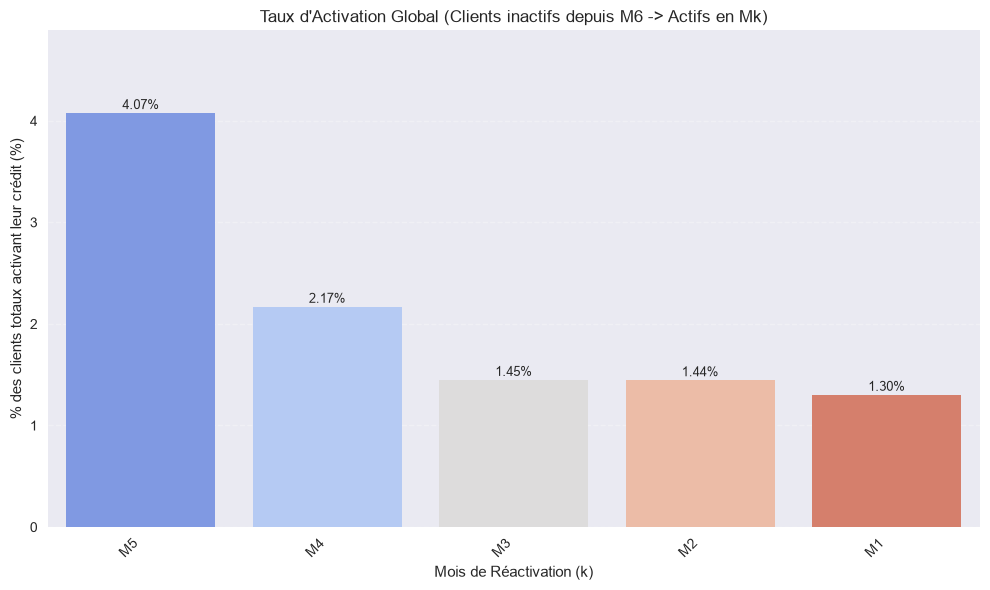

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des colonnes BILL_AMT
colonnes_bill = [f'BILL_AMT{i}' for i in range(6, 0, -1)]
cols_existantes = [c for c in colonnes_bill if c in df.columns]

if len(cols_existantes) < 2:
    print("Pas assez de colonnes BILL_AMT disponibles.")
else:
    taux_activation_globale = []
    labels_x = []
    n_total_clients = len(df)

    # On calcule pour chaque mois k (de 5 down to 1) la probabilité qu'un client :
    # 1. Ait BILL_AMT == 0 pour tous les mois de 6 à k+1 (inactivité prolongée)
    # 2. Aie BILL_AMT > 0 en mois k (réactivation)
    
    for k in range(5, 0, -1):
        col_activ = f'BILL_AMT{k}'
        
        if col_activ not in df.columns:
            taux_activation_globale.append(0)
            labels_x.append(f'M{k} (missing)')
            continue

        # Masque d'inactivité prolongée : 0 pour tous les mois [6, k+1]
        mask_inactif = pd.Series([True] * n_total_clients, index=df.index)
        
        for m in range(6, k, -1):
            col_m = f'BILL_AMT{m}'
            if col_m in df.columns:
                # On applique la condition stricte : solde nul
                mask_inactif &= (df[col_m] == 0)
        
        # Masque de réactivation : > 0 en mois k
        mask_reactivation = df[col_activ] > 0
        
        # Intersection : Les deux conditions doivent être vraies
        # Note: Si un client n'a pas de données pour l'un des mois (NaN), 
        # il ne sera pas compté comme "inactif avec certitude" ni "réactivé". 
        # C'est la méthode stricte.
        
        mask_total = mask_inactif & mask_reactivation
        
        # Calcul du taux par rapport à l'ENSEMBLE du dataset
        count_activation = mask_total.sum()
        taux_global = (count_activation / n_total_clients) * 100
        
        taux_activation_globale.append(taux_global)
        labels_x.append(f'M{k}')

    # 2. Visualisation
    plt.figure(figsize=(10, 6))
    
    sns.barplot(x=labels_x, y=taux_activation_globale, palette='coolwarm')
    
    # Ajout des valeurs
    for i, val in enumerate(taux_activation_globale):
        if val > 0: # Afficher seulement si > 0 pour éviter le bruit
            plt.text(i, val + (max(taux_activation_globale)*0.01 if max(taux_activation_globale)>0 else 0.1), 
                     f'{val:.2f}%', ha='center', fontsize=9)

    plt.title('Taux d\'Activation Global (Clients inactifs depuis M6 -> Actifs en Mk)')
    plt.xlabel('Mois de Réactivation (k)')
    plt.ylabel('% des clients totaux activant leur crédit (%)')
    
    # Ajustement Y
    max_val = max(taux_activation_globale) if taux_activation_globale else 1
    plt.ylim(0, max_val * 1.2 if max_val > 0 else 5)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Interprétation**
Le taux d'activation ou réactivation de comptes diminue fortement entre M-5 et M-3 pour atteindre un taux de 1.3% sur le mois le plus récent.  
Attention, la statistique de M-5 peut être augmentée par une non utilisation succinte en M-6.  
On peut aussi interpréter cette statistiques comme : moins de compte sortent de recouvrement/contentieux s'il s'agit ici de compte gelés pour défaut de paiement excessif

C:\Users\johan\AppData\Local\Temp\ipykernel_14588\1488307515.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_x, y=taux_decongestion, palette='Reds')


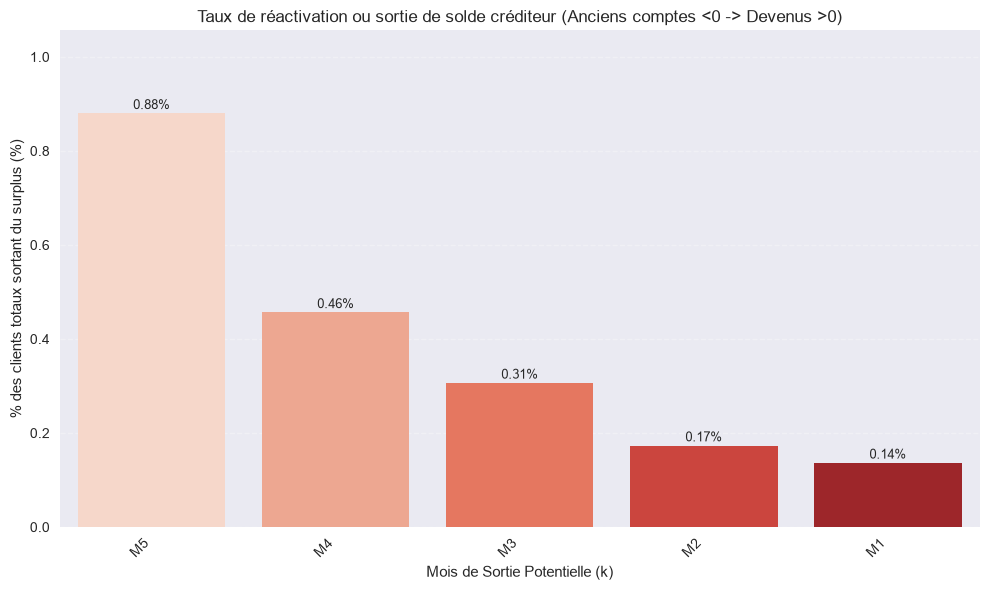

Taux de 'décongestion' calculé : passage de solde négatif vers positif.


In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des colonnes BILL_AMT (6 à 1)
colonnes_bill = [f'BILL_AMT{i}' for i in range(6, 0, -1)]
cols_existantes = [c for c in colonnes_bill if c in df.columns]

if len(cols_existantes) < 2:
    print("Pas assez de colonnes BILL_AMT disponibles.")
else:
    taux_decongestion = []
    labels_x = []
    n_total_clients = len(df)

    # On cherche la sortie de l'état "< 0" vers "> 0"
    # Le "gel" ou surplus commence à M6.
    
    for k in range(5, 0, -1):
        col_sortie = f'BILL_AMT{k}'       # Mois où on espère un retour à > 0
        
        if col_sortie not in df.columns:
            taux_decongestion.append(0)
            labels_x.append(f'M{k} (missing)')
            continue

        # Masque d'inactivité en surplus : < 0 pour tous les mois [6, k+1]
        # Note: On traite les NaN comme "pas de donnée", donc on exclut ceux qui ont des trous.
        mask_surplus = pd.Series([True] * n_total_clients, index=df.index)
        
        for m in range(6, k, -1):
            col_m = f'BILL_AMT{m}'
            if col_m in df.columns:
                # Condition stricte : Solde négatif (débit versé > dette)
                mask_surplus &= (df[col_m] < 0)
        
        # Masque de sortie de surplus : > 0 en mois k
        mask_sortie = df[col_sortie] > 0
        
        # Intersection : Étaient tous en négatif ET sont maintenant en positif
        mask_total = mask_surplus & mask_sortie
        
        # Calcul du taux par rapport à l'ENSEMBLE du dataset
        count_decongeste = mask_total.sum()
        taux_global = (count_decongeste / n_total_clients) * 100
        
        taux_decongestion.append(taux_global)
        labels_x.append(f'M{k}')

    # 2. Visualisation
    plt.figure(figsize=(10, 6))
    
    # Palette différente pour marquer le contraste (ex: rouge/orange pour le "décongé")
    sns.barplot(x=labels_x, y=taux_decongestion, palette='Reds')
    
    # Ajout des valeurs
    for i, val in enumerate(taux_decongestion):
        if val > 0:
            plt.text(i, val + (max(taux_decongestion)*0.01 if max(taux_decongestion)>0 else 0.1), 
                     f'{val:.2f}%', ha='center', fontsize=9)

    plt.title('Taux de réactivation ou sortie de solde créditeur (Anciens comptes <0 -> Devenus >0)')
    plt.xlabel('Mois de Sortie Potentielle (k)')
    plt.ylabel('% des clients totaux sortant du surplus (%)')
    
    # Ajustement Y
    max_val = max(taux_decongestion) if taux_decongestion else 1
    plt.ylim(0, max_val * 1.2 if max_val > 0 else 5)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Taux de 'décongestion' calculé : passage de solde négatif vers positif.")

**Interpétation**  
Ici aussi 2 inteprétations possibles selon que le compte est réellement en état de surpaiement du client ou géré dans une autre phase.  
Taux globalement très faible mais on remarque que comme pour les comptes à 0, le taux de sortie des comptes en négatifs diminue fortement entre M-5 et M-3.  
2 possibilités face aux 2 précédents constats :
- la banque régularise moins de comptes, les clients ont moins la possibilités de régulariser un défaut important à mesure que les banques restreignent l'accès au crédit
- la banque autorise moins d'ouvertures de comptes à mesure que les défaillances se font sentir

In [118]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes BILL_AMT de 1 à 6
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes = [c for c in cols_bill if c in df.columns]

if len(cols_presentes) == 6:
    # On prend uniquement les colonnes d'intérêt pour le calcul
    df_bill = df[cols_presentes]
    
    # 2. Identification des lignes où BILL_AMT est constant sur les 6 mois
    # Si l'écart-type (std) est nul, toutes les valeurs sont identiques.
    std_per_row = df_bill.std(axis=1)
    mask_constant = std_per_row == 0
    
    nb_total_constantes = mask_constant.sum()
    
    if nb_total_constantes > 0:
        # On extrait ces lignes spécifiques pour analyse
        df_constants = df.loc[mask_constant].copy()
        
        # Puisque std=0, la valeur est identique sur les 6 mois.
        # On peut se baser sur n'importe quelle colonne (ex: BILL_AMT1) pour classer la ligne.
        val_constante = df_constants['BILL_AMT1']
        
        # Catégorisation
        mask_negatif = val_constante < 0
        mask_nul = val_constante == 0
        mask_positif = val_constante > 0
        
        nb_negatif = mask_negatif.sum()
        nb_nul = mask_nul.sum()
        nb_positif = mask_positif.sum()
        
        # Vérification de la cohérence (somme des parties = tout)
        if nb_negatif + nb_nul + nb_positif == nb_total_constantes:
            print("--- Analyse des Soldes BILL_AMT Constants sur 6 Mois ---")
            print(f"Total lignes avec BILL_AMT constant : {nb_total_constantes}")
            print(f"  - Strictement Nuls (== 0) : {nb_nul} ({(nb_nul/nb_total_constantes)*100:.2f}%)")
            print(f"  - Positifs (> 0) : {nb_positif} ({(nb_positif/nb_total_constantes)*100:.2f}%)")
            print(f"  - Négatifs (< 0) : {nb_negatif} ({(nb_negatif/nb_total_constantes)*100:.2f}%)")
            
        else:
            print("Erreur de cohérence dans le comptage.")

else:
    print(f"Impossible : Seules {len(cols_presentes)} colonnes BILL_AMT sur 6 sont présentes.")

--- Analyse des Soldes BILL_AMT Constants sur 6 Mois ---
Total lignes avec BILL_AMT constant : 1227
  - Strictement Nuls (== 0) : 866 (70.58%)
  - Positifs (> 0) : 298 (24.29%)
  - Négatifs (< 0) : 63 (5.13%)


In [119]:
import pandas as pd

cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]

# 1. Condition : tous les PAY_AMTn sont égaux à 0 sur les 6 mois
mask_pay_zero = (df[cols_pay] == 0).all(axis=1)

# 2. Condition : BILL_AMTn est strictement constant sur les 6 mois
mask_bill_const = df[cols_bill].std(axis=1) == 0

# 3. Intersection des deux règles
mask_target = mask_bill_const & mask_pay_zero
df_filtered = df[mask_target]

# 4. Ventilation selon la valeur du solde constant (BILL_AMT1 sert de référence)
val_bill = df_filtered['BILL_AMT1']

nb_positif = (val_bill > 0).sum()
nb_nul = (val_bill == 0).sum()
nb_negatif = (val_bill < 0).sum()
total = len(df_filtered)

print("--- DÉCOMPTE : BILL_AMT constant ET PAY_AMT == 0 sur 6 mois ---")
print(f"Total clients concernés : {total}")
if total > 0:
    print(f"  • Facture constante > 0 : {nb_positif} ({nb_positif / total * 100:.2f} %)")
    print(f"  • Facture constante == 0 : {nb_nul} ({nb_nul / total * 100:.2f} %)")
    print(f"  • Facture constante < 0 : {nb_negatif} ({nb_negatif / total * 100:.2f} %)")

--- DÉCOMPTE : BILL_AMT constant ET PAY_AMT == 0 sur 6 mois ---
Total clients concernés : 954
  • Facture constante > 0 : 111 (11.64 %)
  • Facture constante == 0 : 795 (83.33 %)
  • Facture constante < 0 : 48 (5.03 %)


795 clients sont clairement dormants au sens bancaire du terme : aucune opération créditrice ou débitrice sur les 6 mois. Ou selon le SI et ses artéfacts, ils peuvent être en gestion contentieuse.  
**=> Au pire, on les supprime du jeu de données pour ne s'intéresser qu'aux clients actifs en gestion normale, au mieux on masque ces lignes lors des graphiques et de l'apprentissage automatique.**
Il faut creuser sur les autres catégories

In [120]:
import pandas as pd
import numpy as np

# 1. Colonnes concernées
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_presentes = [c for c in cols_bill + cols_pay if c in df.columns]

if len(cols_presentes) == 12:
    # Condition globale : TOUT est constant (BILL et PAY) ET PAY est partout à 0
    mask_constant_pay_zero = (df[cols_pay].apply(lambda x: (x == 0).all(), axis=1)) & \
                             (df[cols_bill].std(axis=1) == 0)
    
    df_cibles = df[mask_constant_pay_zero]
    
    if len(df_cibles) > 0:
        # On utilise BILL_AMT1 pour classifier
        val_bill = df_cibles['BILL_AMT1']
        
        # --- CAS 1 : NÉGATIF (< 0) ---
        mask_negatif = val_bill < 0
        if mask_negatif.any():
            print("--- Aperçu : BILL Constant Négatif & PAY Toujours 0 (Top 10) ---")
            display_neg = df_cibles.loc[mask_negatif].head(10)
            # Affichage des colonnes clés + les 6 BILL + les 6 PAY pour voir la constance
            cols_affichage = ['LIMIT_BAL'] + [c for c in df.columns if 'PAY' in c or 'BILL' in c]
            cols_affichage = [c for c in cols_affichage if c in display_neg.columns]
            print(display_neg[cols_affichage].to_string())
            
        # --- CAS 2 : POSITIF (> 0) ---
        mask_positif = val_bill > 0
        if mask_positif.any():
            print("\n--- Aperçu : BILL Constant Positif & PAY Toujours 0 (Top 10) ---")
            display_pos = df_cibles.loc[mask_positif].head(10)
            cols_affichage = ['LIMIT_BAL'] + [c for c in df.columns if 'PAY' in c or 'BILL' in c]
            cols_affichage = [c for c in cols_affichage if c in display_pos.columns]
            print(display_pos[cols_affichage].to_string())

    else:
        print("Aucune ligne avec PAY=0 et BILL constant trouvé.")
else:
    print("Colonnes manquantes.")

--- Aperçu : BILL Constant Négatif & PAY Toujours 0 (Top 10) ---
      LIMIT_BAL  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5  ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  ratio_PAY_BILL5  ratio_PAY_to_BILL_median  Max_PAY_6m  Duree_PAY2_Consecutif Segment_PAY2_Disjoint  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                                                                                                                                                                                                                                                                                                                                                     

Les 2 cas de figure sont très intéressants.  
1. Dans le cas des encours négatifs constants sans paiement, le compte est considéré comme sain et inactif (codification -2). Pas de dette au sens métier du terme envers la banque. La codification de PAY_1 à '1' interpelle et est de toute évidence une anomalie temporaire que le SI aurait corrigé à '-2' le mois suivant.
On a trouvé une petite correction ici pour la codification PAY_1 =1 : si compte inactif avec encours négatifs stable et PAYn antérieurs à '-2' alors on corrige par '-2'.  
Ces lignes sont clairement des clients inactifs sans dette ou une anomalie du SI.  
**=> je classe des clients en inactifs qu'il faut retirer des analyses et apprentissages automatiques**  
2. Dans le cas des non payeurs avec dette constante, leur retard semble figé dans les colonnes PAY_n (sauf PAY_2 qui contient des anomalies déjà vues).  
J'ai besoin d'analyser plus en détail la population des non payeurs pour voir si cette confirguration spécifique est isolée, cohérente, standard

In [121]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes_pay = [c for c in cols_pay if c in df.columns]
cols_presentes_bill = [c for c in cols_bill if c in df.columns]

if len(cols_presentes_pay) == 6 and len(cols_presentes_bill) == 6:
    # --- Étape 1 : Identifier les non-payeurs sur 6 mois (PAY=0 partout) ---
    mask_no_payment = df[cols_presentes_pay].apply(lambda x: (x == 0).all(), axis=1)
    
    nb_non_payeurs = mask_no_payment.sum()
    
    if nb_non_payeurs > 0:
        # On isole les lignes concernées
        df_non_payeurs = df[mask_no_payment].copy()
        
        # --- Étape 2 : Analyser la stabilité de BILL_AMT ---
        std_bill = df_non_payeurs[cols_presentes_bill].std(axis=1)
        
        mask_stable = std_bill == 0
        mask_instable = std_bill != 0
        
        # --- Étape 3 : Appliquer la condition STRICTE sur la stabilité (BILL > 0) ---
        # Pour les stables : on veut que BILL soit > 0
        # On vérifie si toutes les valeurs de BILL sont > 0 pour ces lignes stables
        mask_stable_positif = False
        if mask_stable.any():
            # On prend les sous-ensemble stable et on teste (>0) partout
            df_stable_part = df_non_payeurs.loc[mask_stable]
            # Si une ligne a au moins un BILL <= 0, elle n'est pas "strictement positive"
            # Donc on garde uniquement celles où TOUTES les colonnes BILL > 0
            mask_stable_positif = (df_stable_part[cols_presentes_bill] > 0).all(axis=1)
            
        # --- Comptage et Affichage ---
        nb_stable_total = mask_stable.sum()
        nb_stable_positif = mask_stable_positif.sum() if mask_stable.any() else 0
        
        # Pour les instables, on garde tout ce qui est stable != 0 (comme avant)
        nb_instable = mask_instable.sum()

        print("--- Analyse des clients sans paiement (PAY=0) ---")
        print(f"Total non-payeurs : {nb_non_payeurs}")
        print(f"  - Dette STABLE ET STRICTEMENT POSITIVE (>0) : {nb_stable_positif} ({(nb_stable_positif/nb_non_payeurs)*100:.2f}%)")
        print(f"  - Dette INSTABLE (variable) : {nb_instable} ({(nb_instable/nb_non_payeurs)*100:.2f}%)")
        
        # Optionnel : Affichage des instables (comme demandé précédemment)
        if nb_instable > 0:
            print(f"\n--- Aperçu des cas INSTABLES (10 lignes) ---")
            df_instables = df.loc[mask_no_payment & mask_instable].head(10)
            cols_affichage = [c for c in df_instables.columns if 'BILL' in c or 'PAY' in c]
            print(df_instables[cols_affichage].to_string())

else:
    print("Colonnes manquantes.")

--- Analyse des clients sans paiement (PAY=0) ---
Total non-payeurs : 1432
  - Dette STABLE ET STRICTEMENT POSITIVE (>0) : 111 (7.75%)
  - Dette INSTABLE (variable) : 478 (33.38%)

--- Aperçu des cas INSTABLES (10 lignes) ---
     PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5  ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  ratio_PAY_BILL5  ratio_PAY_to_BILL_median  Max_PAY_6m  Duree_PAY2_Consecutif                        Segment_PAY2_Disjoint  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                                                                                                                                                                         

On a des encours négatifs qui varient : ces cas seront exclus des prédictions de facto, mais ce sont des clients actifs à maintenir dans les analyses et l'apprentissage.  
Néanmoins on voit que ces dossier sont topés PAY_1 = 1 alors que encours négatif  
**=> on trouve ici une correction élargie par rapport à la règle trouvée plus haut : si PAY_1 = 1 et encours négatifs avec des PAY_n antérieurs à -2 alors on corrige PAY_1 = -2**  
On a de nombreux clients inactifs jusque M-2 qui deviennent actifs en M-1. Ce sont des clients sans historique de paiement, nous n'avons donc aucun historique du comportement
**=> pour le ML, on pourra tester la création d'une feature 'client_récent'**  
Ce ne sont pas ici des clients non payeurs contrairement à ceux dont on a vus la dette figée et existante sur les 6 mois.  
Nous avons environ 390 nouveaux clients actifs sur le dernier mois, ils représentent donc la majorité des clients sans paiement avec un encours qui évolue.  

J'ai besoin de voir de vrais clients en incidents sur la période pour comparer avec ceux dont la dette est figée

In [122]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes_pay = [c for c in cols_pay if c in df.columns]
cols_presentes_bill = [c for c in cols_bill if c in df.columns]

if len(cols_presentes_pay) == 6 and len(cols_presentes_bill) == 6:
    # --- Étape 1 : Identifier les non-payeurs sur 6 mois (PAY=0 partout) ---
    mask_no_payment = df[cols_presentes_pay].apply(lambda x: (x == 0).all(), axis=1)
    
    if mask_no_payment.any():
        df_non_payeurs = df[mask_no_payment].copy()
        
        # --- Étape 2 : Filtrer les dettes positives sur AU MOINS 2 mois ---
        # On compte combien de mois ont une dette > 0 pour chaque client
        nb_mois_dettes_positives = (df_non_payeurs[cols_presentes_bill] > 0).sum(axis=1)
        
        # Condition : Au moins 2 mois avec dettes positives
        mask_dette_partielle = nb_mois_dettes_positives >= 2
        
        if mask_dette_partielle.any():
            df_cibles = df.loc[mask_no_payment & mask_dette_partielle].copy()
            
            # Statistiques sur les mois de dette positive
            print("--- Analyse : Sans paiement, mais dette > 0 sur ≥ 2 mois ---")
            print(f"Total non-payeurs ayant une dette > 0 sur au moins 2 mois : {len(df_cibles)}")
            
            # Distribution du nombre de mois avec dette positive
            mois_dist = nb_mois_dettes_positives.loc[mask_dette_partielle].value_counts().sort_index()
            print("\nRépartition du nombre de mois avec dette > 0 :")
            for mois, count in mois_dist.items():
                print(f"  - {mois} mois : {count} clients ({(count/len(df_cibles))*100:.1f}%)")

            # --- Visualisation des 10 premiers cas (Top par nombre de mois de dette) ---
            print(f"\n--- Exemples de ces profils (Top 10) ---")
            
            # Tri pour voir ceux qui ont le plus de dettes en premier
            df_cibles_sorted = df_cibles.loc[mask_dette_partielle & nb_mois_dettes_positives.sort_values(ascending=False).index] if len(df_cibles) > 0 else pd.DataFrame()

            if not df_cibles.empty:
                # On affiche les colonnes clés pour voir l'évolution de la dette sans paiement
                cols_affichage = [c for c in df_cibles_sorted.columns if 'BILL' in c or 'PAY' in c]
                print(df_cibles_sorted.head(10)[cols_affichage].to_string())

        else:
            print("Aucun non-payeur avec une dette > 0 sur au moins 2 mois.")

else:
    print("Colonnes manquantes.")

--- Analyse : Sans paiement, mais dette > 0 sur ≥ 2 mois ---
Total non-payeurs ayant une dette > 0 sur au moins 2 mois : 206

Répartition du nombre de mois avec dette > 0 :
  - 2 mois : 43 clients (20.9%)
  - 3 mois : 4 clients (1.9%)
  - 4 mois : 3 clients (1.5%)
  - 5 mois : 5 clients (2.4%)
  - 6 mois : 151 clients (73.3%)

--- Exemples de ces profils (Top 10) ---
      PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_brut_PAY_BILL1  ratio_brut_PAY_BILL2  ratio_brut_PAY_BILL3  ratio_brut_PAY_BILL4  ratio_brut_PAY_BILL5  ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  ratio_PAY_BILL5  ratio_PAY_to_BILL_median  Max_PAY_6m  Duree_PAY2_Consecutif                        Segment_PAY2_Disjoint  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                        

2 comportements de colonne PAY_n sur les 6 mois :
- soit elle évolue de 1 par mois non payé et la dette accumule des agios et des frais de retard
- soit elle est stable et passe à 2 en PAY_2 quand la dette est stable, comme si le client était sorti du circuit
C'est indéniablement un problème pour l'apprentissage, les analyses, on a des clients potentiellement sortis du circuit, des notes de retard décorrélés de la réalité qui vont présenter un profil de risque et un taux de défaillance, que les prédictions incluront également car on a une dette réelle.  
Volontairement, je n'affiche plus le dpnm pour ne pas être moi-meme influencé dans mes stratégies.  
On pourrait mettre en place un filtre complexe pour sortir ces clients présumés en recouvrement, mais je n'ai qu'une intuition de par mon expérience bancaire et l'analyse fine de certaines lignes pour lesquelles on détecte 2 comportements d'évolution d'encours de PAY_n. Pas de preuve scientifique, pas de preuve statistique, pas d'info sur la nomenclature du dataset donc cela sera compliqué de nettoyer.
Par contre, je peux prendre en compte cette intuition dans la classification que je peux donner à PAY_n = 2

In [123]:
# Définir la condition : PAY_2 = 2, PAY_3 = -2 et BILL_AMT3 <= 0
condition = (df['PAY_2'] == 2) & (df['PAY_3'] == -2) & (df['BILL_AMT3'] <= 0)

# Compter le nombre de lignes qui remplissent cette condition
nombre_lignes = condition.sum()

# Calculer le pourcentage
total_lignes = len(df)
pourcentage = (nombre_lignes / total_lignes) * 100

print(f"Nombre de lignes répondant à la condition : {nombre_lignes}")
print(f"Pourcentage de ce nombre par rapport au total : {pourcentage:.2f}%")


Nombre de lignes répondant à la condition : 53
Pourcentage de ce nombre par rapport au total : 0.18%


In [124]:
import numpy as np
import pandas as pd

# 1. Isolement de la sous-population
condition = (df['PAY_2'] == 2) & (df['PAY_3'] == -2) & (df['BILL_AMT3'] <= 0)
df_sub = df[condition].copy()

# 2. Calcul des indicateurs de paiement
# Part des clients ayant effectué au moins un paiement (PAY_AMT > 0)
pct_payeurs_m2 = (df_sub['PAY_AMT2'] > 0).mean() * 100
pct_payeurs_m1 = (df_sub['PAY_AMT1'] > 0).mean() * 100

# Montants moyens versés
moy_pay_m2 = df_sub['PAY_AMT2'].mean()
moy_pay_m1 = df_sub['PAY_AMT1'].mean()

# Taux de couverture de la dette à M-2 (PAY_AMT2 / BILL_AMT2)
mask_bill_m2_pos = df_sub['BILL_AMT2'] > 0
ratio_couverture_m2 = (
    (
        df_sub.loc[mask_bill_m2_pos, 'PAY_AMT2']
        / df_sub.loc[mask_bill_m2_pos, 'BILL_AMT2']
    ).mean()
    * 100
    if mask_bill_m2_pos.sum() > 0
    else 0
)

# Taux de défaut (dpnm)
taux_defaut = df_sub['dpnm'].mean() * 100 if 'dpnm' in df_sub.columns else None

# 3. Synthèse des résultats
res_df = pd.DataFrame([
    {
        'Indicateur': 'Effectif sous-population',
        'Valeur': f'{len(df_sub):,}'.replace(',', ' '),
    },
    {
        'Indicateur': 'Taux de clients payeurs à M-2 (PAY_AMT2 > 0)',
        'Valeur': f'{pct_payeurs_m2:.2f} %',
    },
    {
        'Indicateur': 'Taux de clients payeurs à M-1 (PAY_AMT1 > 0)',
        'Valeur': f'{pct_payeurs_m1:.2f} %',
    },
    {
        'Indicateur': 'Montant moyen versé à M-2 (PAY_AMT2)',
        'Valeur': f'{moy_pay_m2:,.2f}'.replace(',', ' '),
    },
    {
        'Indicateur': 'Montant moyen versé à M-1 (PAY_AMT1)',
        'Valeur': f'{moy_pay_m1:,.2f}'.replace(',', ' '),
    },
    {
        'Indicateur': 'Taux de couverture moyen du solde M-2',
        'Valeur': f'{ratio_couverture_m2:.2f} %',
    },
    {
        'Indicateur': 'Taux de défaut final (dpnm)',
        'Valeur': (
            f'{taux_defaut:.2f} %' if taux_defaut is not None else 'N/A'
        ),
    },
])

display(res_df)

,Indicateur,Valeur
0,Effectif sous-population,53
1,Taux de clients payeurs à M-2 (PAY_AMT2 > 0),0.00 %
2,Taux de clients payeurs à M-1 (PAY_AMT1 > 0),9.43 %
3,Montant moyen versé à M-2 (PAY_AMT2),0.00
4,Montant moyen versé à M-1 (PAY_AMT1),76.34
5,Taux de couverture moyen du solde M-2,0.00 %
6,Taux de défaut final (dpnm),60.38 %


Un saut brutal de codification négatif vers positif est une alerte à prendre en compte

**Codification 1 (PAY_n = 1)** : analyses et interprétations déplacées dans [05_04_EDA_codification1.ipynb](05_04_EDA_codification1.ipynb) (annexe), où cette codification est étudiée en détail.

### Répartition des plafonds

Nombre de clients par tranche de plafond :
        0 à 50 k : 7676
      50 à 100 k : 4822
     100 à 150 k : 3902
     150 à 200 k : 3978
     200 à 250 k : 2905
     250 à 300 k : 2154
     300 à 350 k : 1206
     350 à 400 k : 1553
     400 à 450 k : 573
     450 à 500 k : 1025
     500 à 550 k : 76
     550 à 600 k : 51
     600 à 650 k : 37
     650 à 700 k : 19
     700 à 750 k : 17
     750 à 800 k : 5
     800 à 850 k : 0
     850 à 900 k : 0
     900 à 950 k : 0
    950 à 1000 k : 1

Clients avec un plafond de 500 000 NT$ pile : 722
Clients avec un plafond > 500 000 NT$ : 206 sur 30000 (0.69 %)
Plafond médian de l'ensemble des clients : 140,000 NT$
Plafond médian des clients > 500 000 NT$ : 580,000 NT$
Plafond maximum : 1,000,000 NT$ (1 client(s))


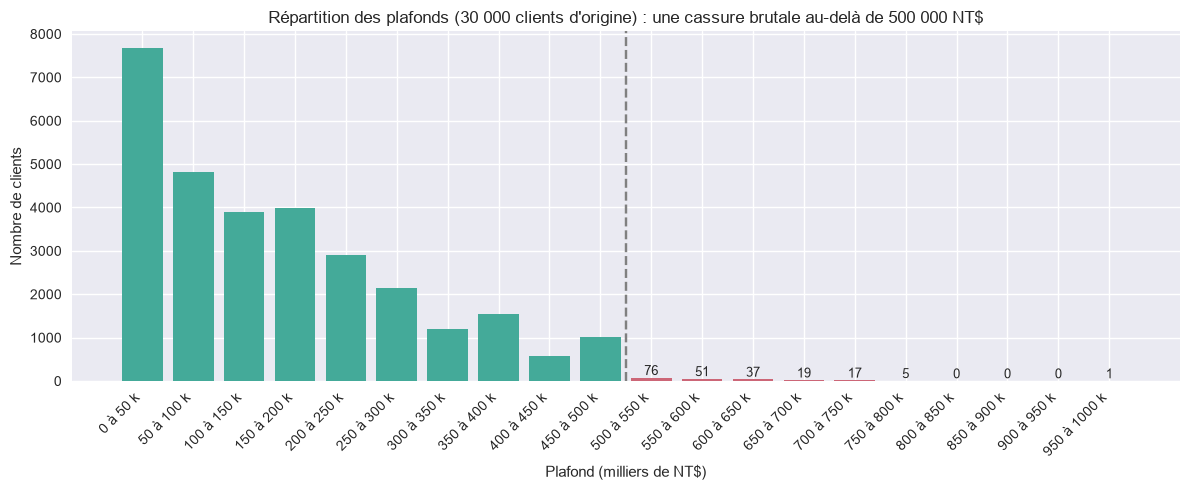

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Répartition des plafonds sur les 30 000 clients d'origine (df_initial, avant retrait des 4 paiements géants)
# Tranches de 50 000 NT$, borne haute incluse : la tranche « 450 à 500 k » contient les plafonds de 500 000 NT$
bornes = np.arange(0, 1_050_000, 50_000)
tranches = pd.cut(df_initial['LIMIT_BAL'], bins=bornes)
repartition = tranches.value_counts().sort_index()
libelles = [f"{int(i.left) // 1000} à {int(i.right) // 1000} k" for i in repartition.index]

print("Nombre de clients par tranche de plafond :")
for libelle, n in zip(libelles, repartition.values):
    print(f"  {libelle:>14} : {n}")

seuil = 500_000
au_dela = df_initial['LIMIT_BAL'] > seuil
print(f"\nClients avec un plafond de 500 000 NT$ pile : {(df_initial['LIMIT_BAL'] == seuil).sum()}")
print(f"Clients avec un plafond > 500 000 NT$ : {au_dela.sum()} sur {len(df_initial)} ({au_dela.mean() * 100:.2f} %)")
print(f"Plafond médian de l'ensemble des clients : {df_initial['LIMIT_BAL'].median():,.0f} NT$")
print(f"Plafond médian des clients > 500 000 NT$ : {df_initial.loc[au_dela, 'LIMIT_BAL'].median():,.0f} NT$")
print(f"Plafond maximum : {df_initial['LIMIT_BAL'].max():,.0f} NT$ ({(df_initial['LIMIT_BAL'] == df_initial['LIMIT_BAL'].max()).sum()} client(s))")

couleurs = ['#44AA99' if i.right <= seuil else '#CC6677' for i in repartition.index]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(libelles, repartition.values, color=couleurs)
for x, n, i in zip(libelles, repartition.values, repartition.index):
    if i.right > seuil:
        ax.text(x, n, str(n), ha='center', va='bottom', fontsize=9)
ax.axvline(9.5, linestyle='--', color='grey')
ax.set_title("Répartition des plafonds (30 000 clients d'origine) : une cassure brutale au-delà de 500 000 NT$")
ax.set_xlabel("Plafond (milliers de NT$)")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [129]:
# Usage maximal du plafond sur les 6 mois : facture la plus élevée (BILL_AMT1 à BILL_AMT6) / plafond, en %
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
usage_max = df_initial[bill_cols].max(axis=1) / df_initial['LIMIT_BAL'] * 100
groupe = np.where(df_initial['LIMIT_BAL'] > 500_000, "Plafond > 500 000 NT$", "Plafond <= 500 000 NT$")

synthese = pd.DataFrame({'usage_max': usage_max, 'groupe': groupe}).groupby('groupe')['usage_max'].agg(
    clients='size',
    usage_max_median=lambda s: round(s.median(), 1),
    jamais_plus_de_10_pct=lambda s: round((s < 10).mean() * 100, 1),
    au_moins_50_pct=lambda s: round((s >= 50).mean() * 100, 1),
)
print("Usage maximal du plafond sur les 6 mois (en %) :")
display(synthese)


Usage maximal du plafond sur les 6 mois (en %) :


,clients,usage_max_median,jamais_plus_de_10_pct,au_moins_50_pct
groupe,,,,
Plafond <= 500 000 NT$,29794,43.3,28.9,46.7
Plafond > 500 000 NT$,206,21.1,35.9,30.1
